In [15]:
# Kernal: r-reticulate (Python 3.10.14)

# pip installs - only needed once in the notebook
%pip install xgboost scikeras tensorflow shap pandas matplotlib seaborn scikit-learn imblearn pdpbox scikit-optimize ipywidgets tabulate

from imblearn.over_sampling import SMOTE
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler

from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import shap


class CustomKerasClassifier(KerasClassifier):
    def __sklearn_tags__(self):
        return {"estimator_type": "classifier"}

# Set relative path to data directory
DATA_DIR = "../data"

# Load datasets
dat_ml_6m = pd.read_csv(os.path.join(DATA_DIR, "dat_ml_6m.csv"))
dat_ml_1y = pd.read_csv(os.path.join(DATA_DIR, "dat_ml_1y.csv"))
dat_ml_7y = pd.read_csv(os.path.join(DATA_DIR, "dat_ml_7y.csv"))
dat_ml_7y_dep = pd.read_csv(os.path.join(DATA_DIR, "dat_ml_7y_dep.csv"))
dat_ml_7y_never = pd.read_csv(os.path.join(DATA_DIR, "dat_ml_7y_never.csv"))


Note: you may need to restart the kernel to use updated packages.


In [55]:
# Assess data

## 6 months
print(dat_ml_6m.info())


## 1 year
print(dat_ml_1y.info())


## 7 years
print(dat_ml_7y.info())
print(complete_data_7y_dep.info())
print(complete_data_7y_never.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 818 entries, 0 to 817
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   treat                     818 non-null    int64  
 1   newid                     818 non-null    int64  
 2   uc                        818 non-null    int64  
 3   interviewer               818 non-null    int64  
 4   month_int                 818 non-null    int64  
 5   remission_6mo             818 non-null    int64  
 6   depindex_0                818 non-null    float64
 7   depindex_0_f              818 non-null    float64
 8   mo_ht_baseline            818 non-null    float64
 9   mo_bmi_baseline           818 non-null    float64
 10  hamd_baseline             818 non-null    int64  
 11  bdq_baseline              818 non-null    int64  
 12  gaf_baseline              818 non-null    int64  
 13  ses_baseline              818 non-null    int64  
 14  age_baseli

In [16]:
# Imputation
#%pip install miceforest
import os
# Ensure libomp is installed and properly linked
os.environ['DYLD_LIBRARY_PATH'] = '/opt/homebrew/opt/libomp/lib'
os.environ['OMP_NUM_THREADS'] = '1'  # Limit threads to avoid conflicts
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'  # Avoid conflicts with OpenMP
import miceforest as mf

# Function to perform imputation and return/save imputed dataset
def impute_and_save(filepath, output_dir="../data", iterations=5, seed=500):
    df = pd.read_csv(filepath)
    kernel = mf.ImputationKernel(df, random_state=seed)
    kernel.mice(iterations=iterations, n_jobs=-1)
    imputed_df = kernel.complete_data(dataset=0)

    # Save to the same data directory with a new filename
    os.makedirs(output_dir, exist_ok=True)
    filename = os.path.basename(filepath).replace(".csv", "_imputed.csv")
    imputed_path = os.path.join(output_dir, filename)
    imputed_df.to_csv(imputed_path, index=False)

    return imputed_df

# Define relative path to the data directory (from notebooks/)
DATA_DIR = "../data"

# Define file paths relative to the notebook's location
filepaths = {
    "dat_ml_6m": os.path.join(DATA_DIR, "dat_ml_6m.csv"),
    "dat_ml_1y": os.path.join(DATA_DIR, "dat_ml_1y.csv"),
    "dat_ml_7y": os.path.join(DATA_DIR, "dat_ml_7y.csv"),
    "dat_ml_7y_dep": os.path.join(DATA_DIR, "dat_ml_7y_dep.csv"),
    "dat_ml_7y_never": os.path.join(DATA_DIR, "dat_ml_7y_never.csv")
}

# Run imputation, save, and store in a dictionary
imputed_datasets = {}
for name, path in filepaths.items():
    print(f"Imputing and saving {name}...")
    imputed_datasets[name] = impute_and_save(path, output_dir=DATA_DIR)

# Example: access 6-month imputed dataset
dat_ml_6m_imputed = imputed_datasets["dat_ml_6m"]


Imputing and saving dat_ml_6m...
Imputing and saving dat_ml_1y...
Imputing and saving dat_ml_7y...
Imputing and saving dat_ml_7y_dep...
Imputing and saving dat_ml_7y_never...


2025-07-26 18:36:19,211 - INFO - Data loaded: (818, 47)
2025-07-26 18:36:19,229 - INFO - Data validation passed. Shape: (818, 47)
2025-07-26 18:36:19,253 - INFO - Target counts:
remission_6mo
1    489
0    329
Name: count, dtype: int64
2025-07-26 18:36:19,267 - INFO - Missing values: 0
2025-07-26 18:36:19,280 - INFO - Train=654, Hold-out=164
2025-07-26 18:36:19,290 - INFO - → Nested CV: Logistic Regression
2025-07-26 18:36:19,293 - INFO - Processing outer fold 1/5
2025-07-26 18:36:19,295 - INFO - Fold 1 treatment distribution: {1: 271, 0: 252}
2025-07-26 18:36:19,296 - INFO - Fold 1 class distribution: {1: 313, 0: 210}
2025-07-26 18:36:22,712 - INFO - Fold 1: Treatment variable selected! (F-score=83.471, rank=1)
2025-07-26 18:36:22,717 - INFO - Fold 1 AUC: 0.690
2025-07-26 18:36:22,717 - INFO - Processing outer fold 2/5
2025-07-26 18:36:22,721 - INFO - Fold 2 treatment distribution: {0: 262, 1: 261}
2025-07-26 18:36:22,721 - INFO - Fold 2 class distribution: {1: 313, 0: 210}
2025-07-26


Nested CV Performance (with Treatment Selection)
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+------------------+
| Model               |   Accuracy |   Precision |   Recall |   F1 Score |   AUC |   Brier Score |   Folds | Treat_Selected   |
+=====================+============+=============+==========+============+=======+===============+=========+==================+
| Logistic Regression |      0.671 |       0.747 |    0.68  |      0.712 | 0.717 |         0.214 |       5 | 5/5              |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+------------------+
| LASSO Logistic      |      0.662 |       0.756 |    0.642 |      0.694 | 0.724 |         0.214 |       5 | 5/5              |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+------------------+
| Random Forest       |      0.676 |       0.732 |    

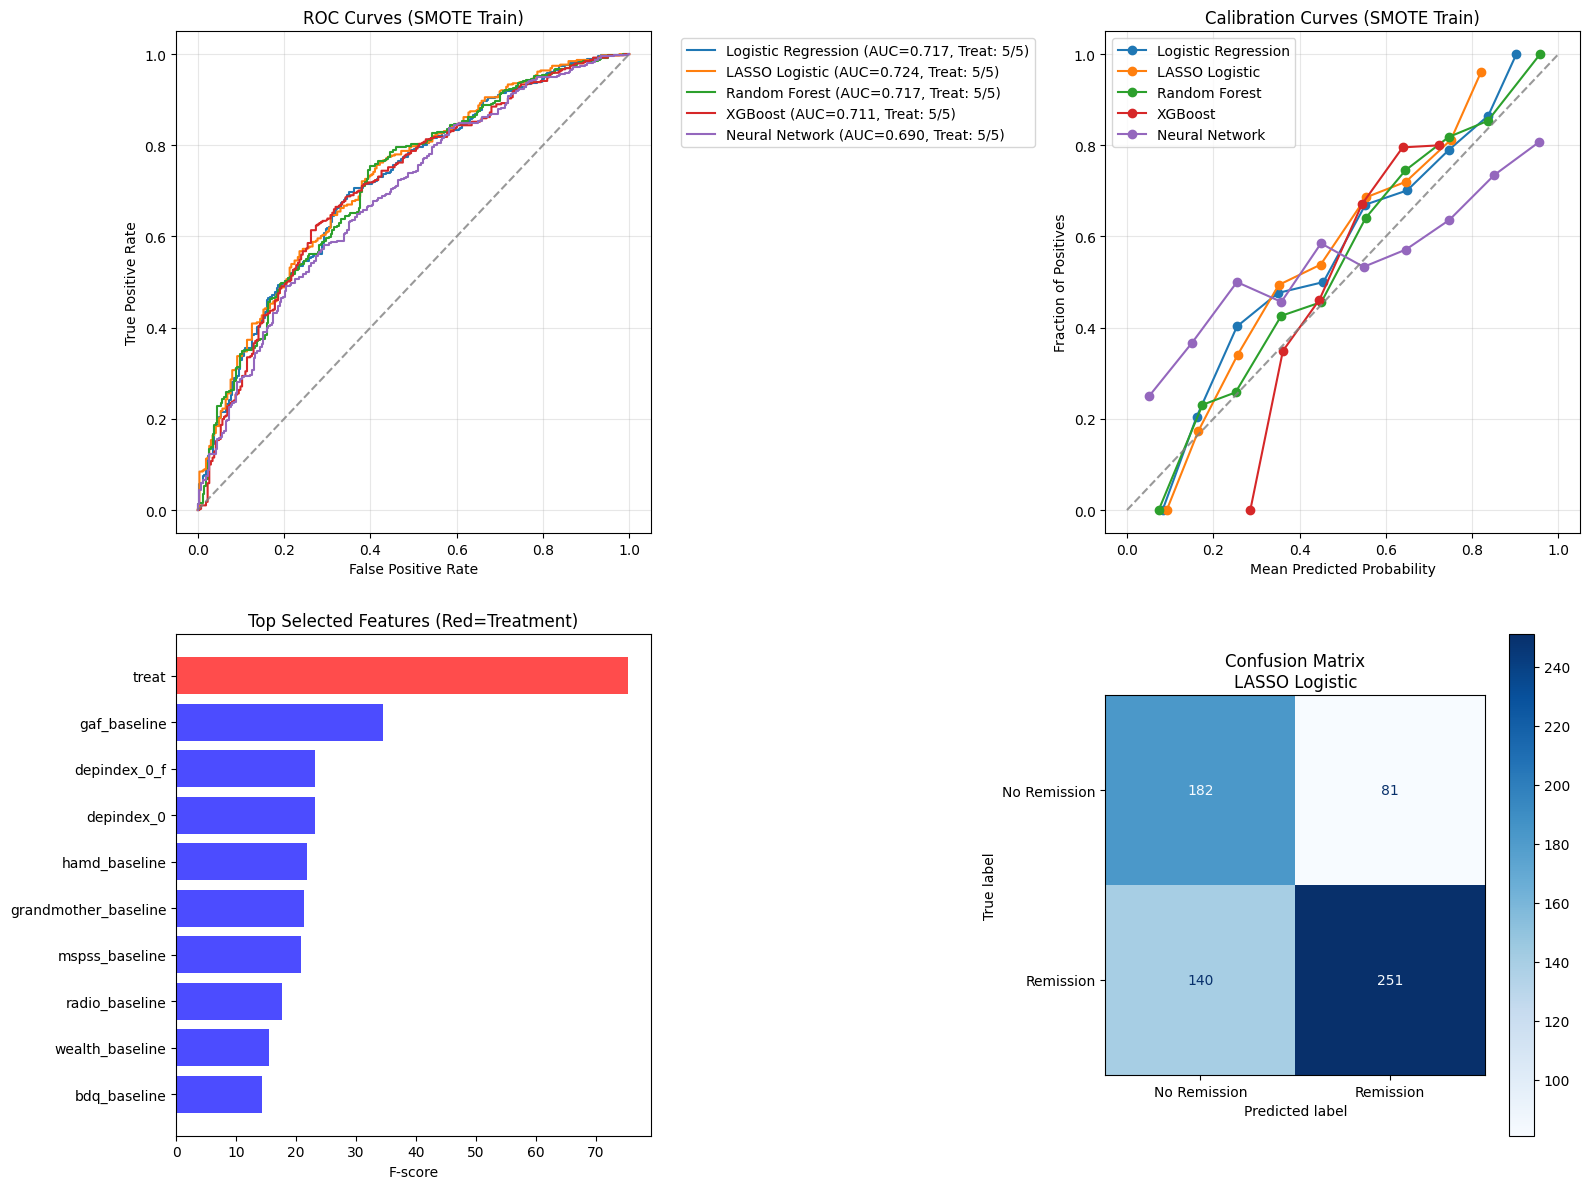

2025-07-26 18:38:31,117 - INFO - Refitted best: LASSO Logistic
2025-07-26 18:38:31,176 - INFO - Calibration on train completed



Hold-out Performance:
Uncalibrated: AUC=0.734, F1=0.720
Calibrated:   AUC=0.736, F1=0.720


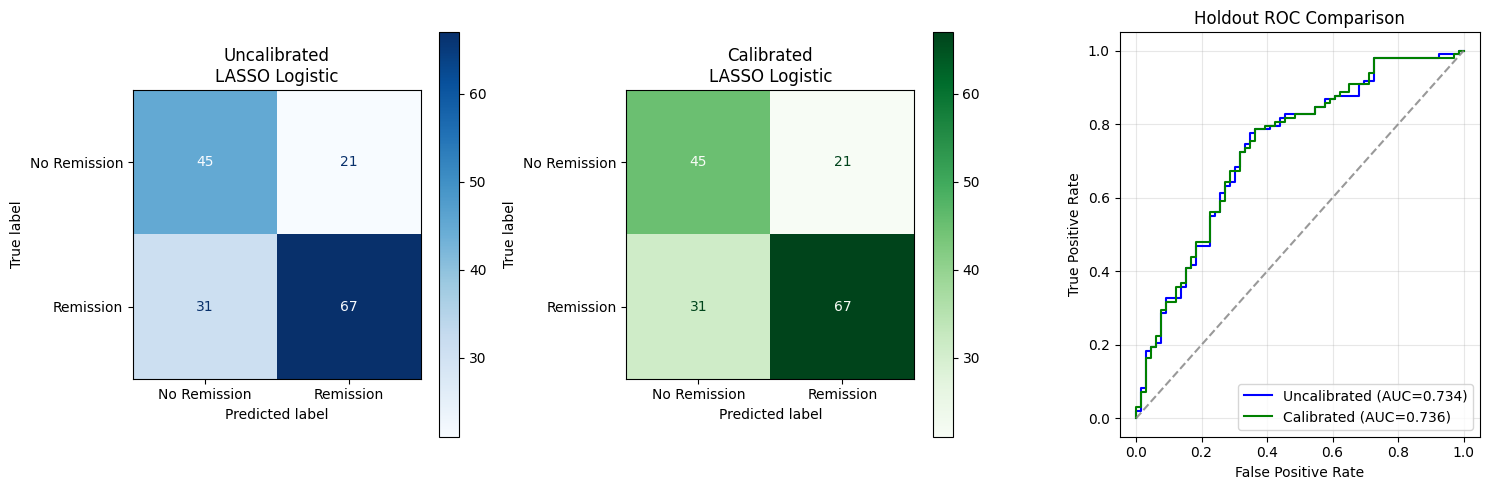

2025-07-26 18:38:31,551 - INFO - Performing SHAP analysis...
2025-07-26 18:38:31,553 - INFO - Treatment variable selected for SHAP: True



Detailed Holdout Metrics:
Metric          Uncalibrated Calibrated  
---------------------------------------
Accuracy        0.683        0.683       
Precision       0.761        0.761       
Recall          0.684        0.684       
F1 Score        0.720        0.720       
AUC             0.734        0.736       
Specificity     0.682        0.682       
Sensitivity     0.684        0.684       

Confusion Matrix Components:
Component       Uncalibrated Calibrated  
---------------------------------------
True Positives  67           67          
False Positives 21           21          
True Negatives  45           45          
False Negatives 31           31          


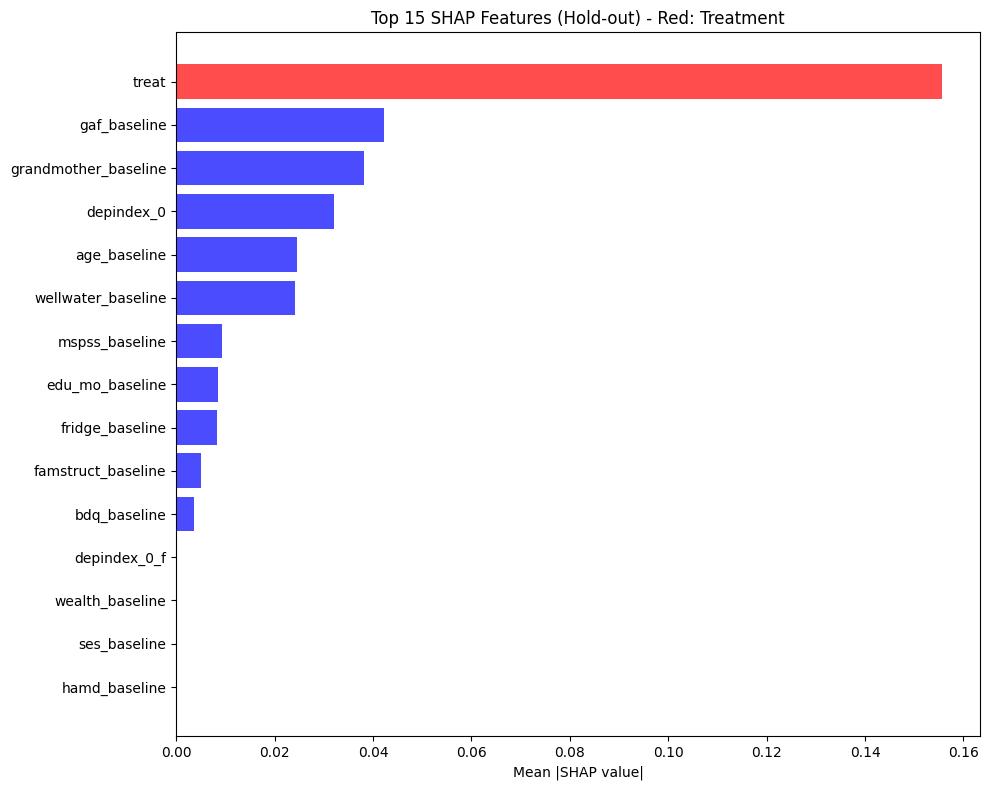

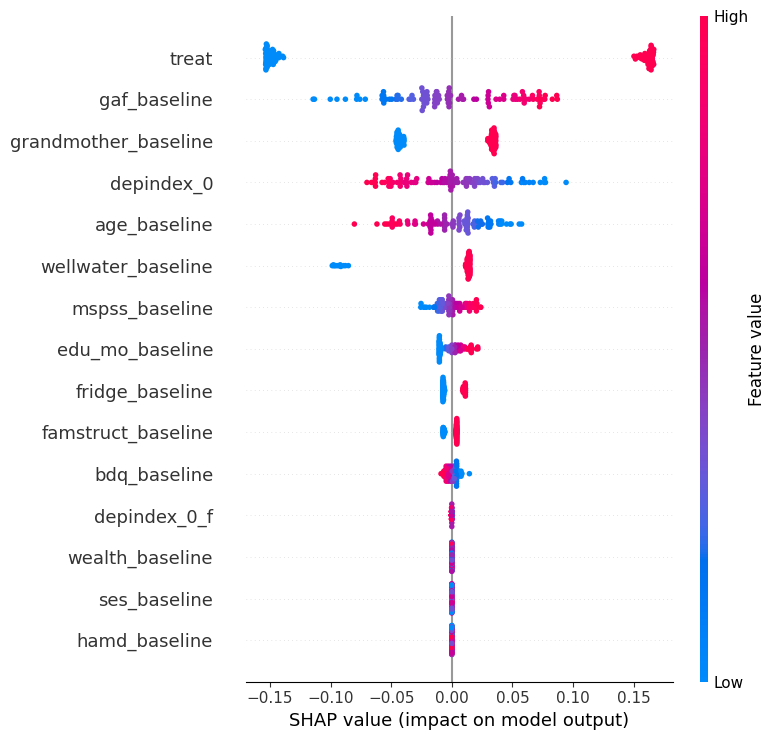


Generating SHAP Personas…
Top 3 SHAP features: ['grandmother_baseline', 'gaf_baseline', 'treat']

Top-3 SHAP Personas:
                                                   Profile  P(remission)
   grandmother_baseline=low & gaf_baseline=low & treat=low         0.271
  grandmother_baseline=low & gaf_baseline=low & treat=high         0.551
  grandmother_baseline=low & gaf_baseline=high & treat=low         0.431
 grandmother_baseline=low & gaf_baseline=high & treat=high         0.715
  grandmother_baseline=high & gaf_baseline=low & treat=low         0.335
 grandmother_baseline=high & gaf_baseline=low & treat=high         0.625
 grandmother_baseline=high & gaf_baseline=high & treat=low         0.507
grandmother_baseline=high & gaf_baseline=high & treat=high         0.774


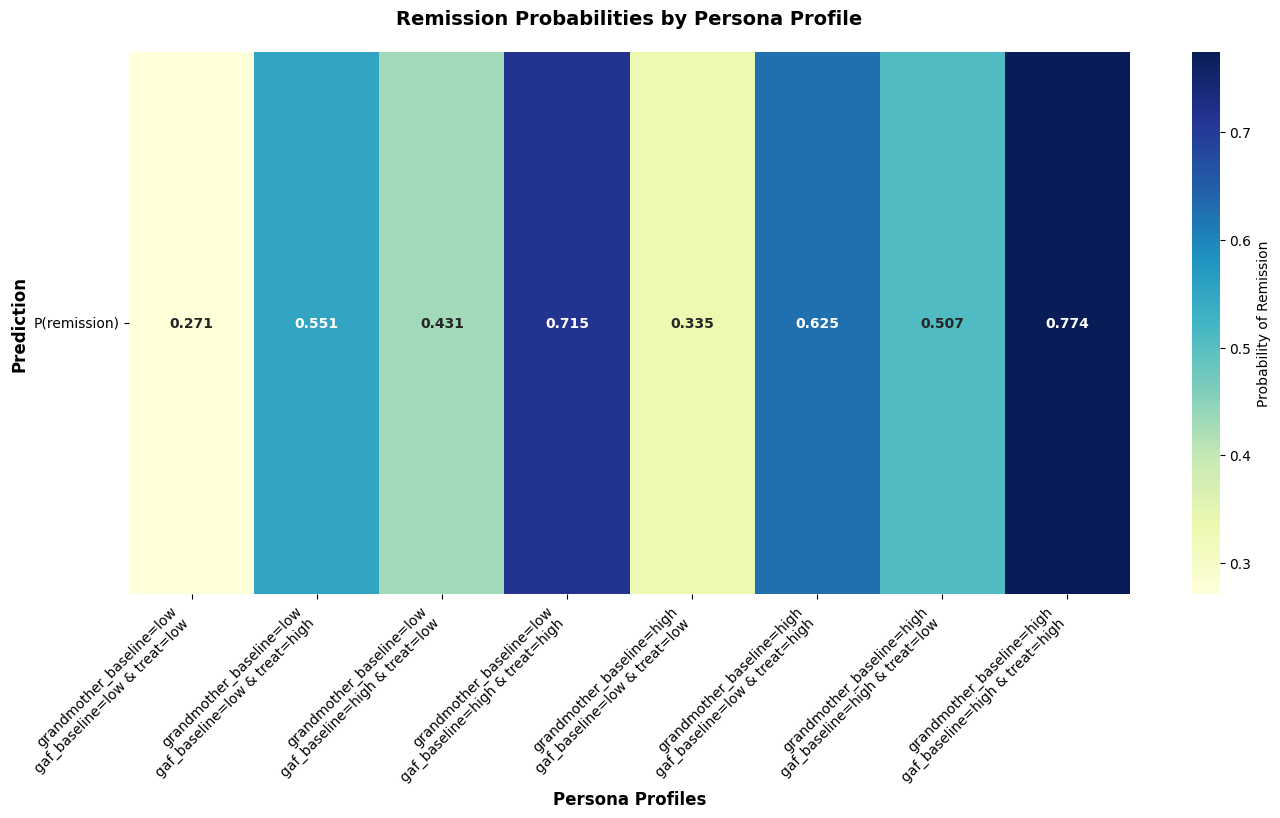

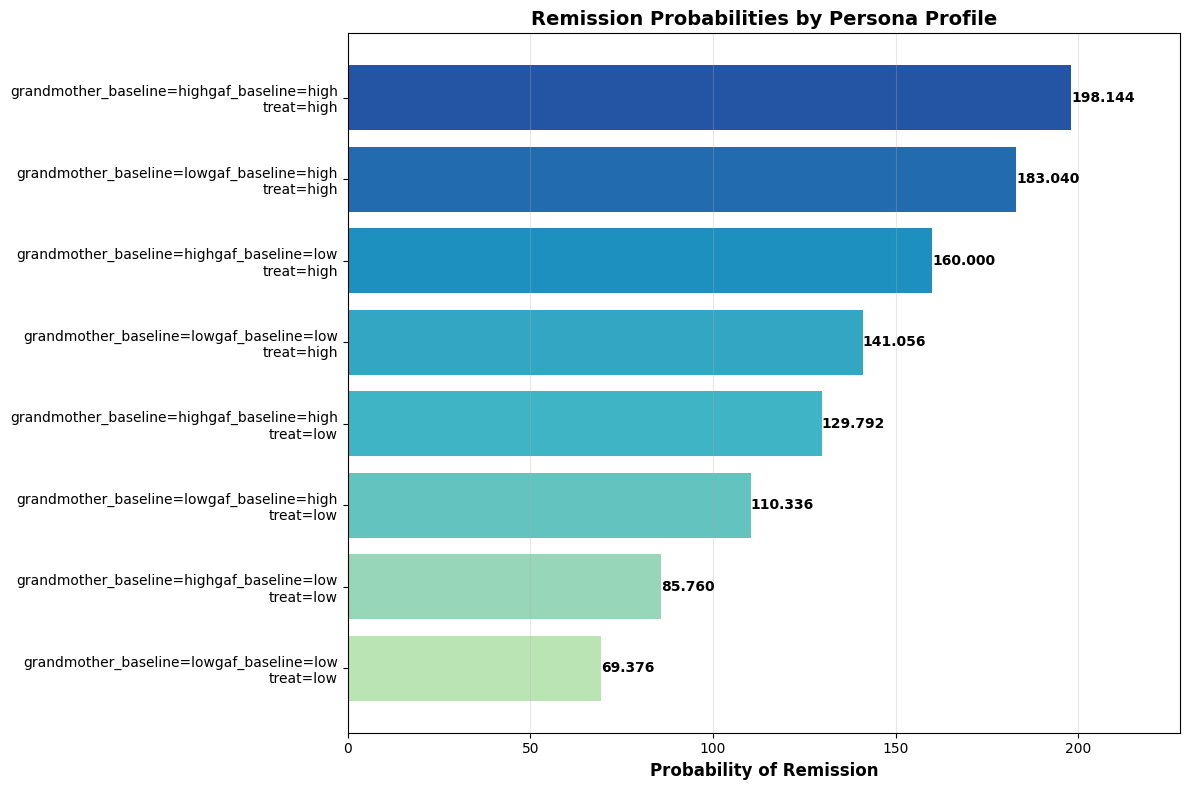


TREATMENT VARIABLE ANALYSIS
Logistic Regression:
  Treatment selected: 5/5 folds
  Average F-score: 76.581
  Average rank: 1.0
LASSO Logistic:
  Treatment selected: 5/5 folds
  Average F-score: 76.581
  Average rank: 1.0
Random Forest:
  Treatment selected: 5/5 folds
  Average F-score: 76.581
  Average rank: 1.0
XGBoost:
  Treatment selected: 5/5 folds
  Average F-score: 76.581
  Average rank: 1.0
Neural Network:
  Treatment selected: 5/5 folds
  Average F-score: 76.581
  Average rank: 1.0

FINAL RESULTS SUMMARY
Best Model: LASSO Logistic
Hold-out Performance (Calibrated):
  Accuracy: 0.683
  Precision: 0.761
  Recall: 0.684
  F1 Score: 0.720
  AUC: 0.736
  Brier Score: 0.207
  True Negatives: 45.000
  False Positives: 21.000
  False Negatives: 31.000
  True Positives: 67.000
  Specificity: 0.682
  Sensitivity: 0.684
✓ Treatment variable was selected by the best model
Overall treatment selection rate: 25/25 (100.0%)


In [103]:
# Remission at 6 months - Nested CV (FIXED VERSION)

# ========= Imports =========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import tensorflow as tf 
import logging
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from skopt import BayesSearchCV

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from tabulate import tabulate
from itertools import product
import warnings
warnings.filterwarnings("ignore")

# ========= Configuration =========
@dataclass
class Config:
    RANDOM_STATE: int = 123
    N_FEATURES: int = 15
    OUTER_SPLITS: int = 5
    INNER_SPLITS: int = 3
    N_ITER: int = 20
    TEST_SIZE: float = 0.2
    TARGET_COL: str = "remission_6mo"
    ID_COL: str = "newid"
    EXCLUDE_COLS: List[str] = None
    
    def __post_init__(self):
        if self.EXCLUDE_COLS is None:
            self.EXCLUDE_COLS = ["remission_6mo"]

config = Config()

# ========= Logging Setup =========
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ========= Data Validation =========
def validate_data(df: pd.DataFrame, target_col: str, required_cols: List[str]) -> None:
    """Validate input data quality"""
    assert not df.empty, "DataFrame is empty"
    assert target_col in df.columns, f"Target column '{target_col}' not found"
    
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    assert df[target_col].nunique() > 1, "Target has only one class"
    logger.info(f"Data validation passed. Shape: {df.shape}")

# ========= UPDATED: SMOTE Pipeline Builder =========
def build_smote_pipeline(base_model, config: Config, include_oversampling: bool = True):
    """
    Build a pipeline that uses SMOTE for oversampling instead of stratified approach
    """
    if include_oversampling:
        # Use imblearn pipeline with SMOTE
        pipeline = ImbPipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('oversample', SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)),
            ('select', SelectKBest(score_func=f_classif, k=config.N_FEATURES)),
            ('model', base_model)
        ])
    else:
        # Standard pipeline without oversampling
        pipeline = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('select', SelectKBest(score_func=f_classif, k=config.N_FEATURES)),
            ('model', base_model)
        ])
    
    return pipeline

# ========= UPDATED: Nested CV with SMOTE =========
def run_nested_cv_smote(model, param_distributions: Dict, X: pd.DataFrame, y: np.ndarray, 
                        config: Config, include_oversampling: bool = True) -> Dict[str, Any]:
    """
    Nested CV with SMOTE oversampling instead of stratified oversampling
    """
    outer_cv = StratifiedKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)
    inner_cv = StratifiedKFold(n_splits=config.INNER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)

    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    outer_scores = []
    successful_folds = 0
    feature_importance_dicts = []
    treatment_selected_count = 0
    treatment_scores = []  # Track treatment F-scores

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        logger.info(f"Processing outer fold {fold + 1}/{config.OUTER_SPLITS}")
        
        try:
            # Split data first
            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y[train_idx].copy()
            X_test_fold = X.iloc[test_idx].copy()
            y_test_fold = y[test_idx].copy()

            # Log treatment and class distribution in this fold
            if 'treat' in X_train_fold.columns:
                treat_dist = X_train_fold['treat'].value_counts()
                logger.info(f"Fold {fold+1} treatment distribution: {treat_dist.to_dict()}")
            
            class_dist = pd.Series(y_train_fold).value_counts()
            logger.info(f"Fold {fold+1} class distribution: {class_dist.to_dict()}")

            # Build SMOTE pipeline
            pipe = build_smote_pipeline(model, config, include_oversampling)
            
            # Hyperparameter search on training fold
            search_space = {f'model__{k}': v for k, v in param_distributions.items()}
            
            search = BayesSearchCV(
                pipe,
                search_spaces=search_space,
                n_iter=config.N_ITER,
                scoring='roc_auc',
                cv=inner_cv,
                n_jobs=1,
                random_state=config.RANDOM_STATE,
                error_score='raise'
            )
            
            search.fit(X_train_fold, y_train_fold)
            best_model = search.best_estimator_

            # Check if treatment was selected as a feature
            if hasattr(best_model, 'named_steps') and 'select' in best_model.named_steps:
                selector = best_model.named_steps['select']
                selected_features = X_train_fold.columns[selector.get_support()].tolist()
                feature_scores = dict(zip(X_train_fold.columns, selector.scores_))
                
                # Track treatment selection and scoring
                treat_selected = 'treat' in selected_features
                treat_score = feature_scores.get('treat', 0)
                treat_rank = sorted(feature_scores.values(), reverse=True).index(treat_score) + 1 if 'treat' in feature_scores else len(feature_scores)
                
                if treat_selected:
                    treatment_selected_count += 1
                    logger.info(f"Fold {fold+1}: Treatment variable selected! (F-score={treat_score:.3f}, rank={treat_rank})")
                else:
                    logger.info(f"Fold {fold+1}: Treatment NOT selected (F-score={treat_score:.3f}, rank={treat_rank}/{len(feature_scores)})")
                
                treatment_scores.append({
                    'fold': fold + 1,
                    'treat_score': treat_score,
                    'treat_rank': treat_rank,
                    'treat_selected': treat_selected
                })
                
                # Store feature importance info
                feature_importance_dicts.append({
                    'fold': fold + 1,
                    'selected_features': selected_features,
                    'treatment_selected': treat_selected,
                    'feature_scores': feature_scores
                })

            # Make predictions on test fold
            prob = best_model.predict_proba(X_test_fold)[:, 1]
            pred = (prob > 0.5).astype(int)
            
            y_probs[test_idx] = prob
            y_preds[test_idx] = pred
            outer_scores.append(roc_auc_score(y_test_fold, prob))
            successful_folds += 1
            
            logger.info(f"Fold {fold+1} AUC: {outer_scores[-1]:.3f}")
            
        except Exception as e:
            logger.error(f"Error in fold {fold + 1}: {e}")
            # For failed folds, use neutral predictions
            y_probs[test_idx] = 0.5
            y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
            outer_scores.append(0.5)

    # Validate results
    if successful_folds < config.OUTER_SPLITS // 2:
        raise RuntimeError(f"Too many folds failed: {successful_folds}/{config.OUTER_SPLITS}")

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    # Log treatment selection summary
    logger.info(f"Treatment variable selected in {treatment_selected_count}/{successful_folds} folds")
    if treatment_scores:
        avg_treat_score = np.mean([t['treat_score'] for t in treatment_scores])
        avg_treat_rank = np.mean([t['treat_rank'] for t in treatment_scores])
        logger.info(f"Average treatment F-score: {avg_treat_score:.3f}, average rank: {avg_treat_rank:.1f}")

    return {
        "model": search.best_estimator_ if 'search' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(outer_scores),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": treatment_selected_count,
        "treatment_scores": treatment_scores,
        "feature_importance_info": feature_importance_dicts
    }

# ========= UPDATED: Neural Network CV with SMOTE =========
def run_nn_cv_smote(X: pd.DataFrame, y: np.ndarray, config: Config) -> Dict[str, Any]:
    """Neural network CV with SMOTE oversampling"""
    outer_cv = StratifiedKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)
    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    aucs = []
    successful_folds = 0
    feature_names = X.columns.tolist()
    treatment_selected_count = 0
    treatment_scores = []

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        logger.info(f"Processing NN fold {fold + 1}/{config.OUTER_SPLITS}")
        
        try:
            # Split data first
            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y[train_idx].copy()
            X_test_fold = X.iloc[test_idx].copy()
            y_test_fold = y[test_idx].copy()

            # Apply preprocessing
            imputer = SimpleImputer(strategy='median')
            scaler = StandardScaler()
            
            X_train_imputed = imputer.fit_transform(X_train_fold)
            X_train_scaled = scaler.fit_transform(X_train_imputed)
            X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
            
            # Apply SMOTE oversampling
            smote = SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)
            X_train_df, y_train_fold = smote.fit_resample(X_train_df, y_train_fold)
            
            logger.info(f"NN Fold {fold+1}: After SMOTE - {len(X_train_df)} samples, "
                       f"class distribution: {np.bincount(y_train_fold)}")

            # Feature selection on SMOTE-processed training data
            selector = SelectKBest(score_func=f_classif, k=config.N_FEATURES)
            X_train_selected = selector.fit_transform(X_train_df.values, y_train_fold)
            
            # Check if treatment was selected
            selected_features = X_train_df.columns[selector.get_support()].tolist()
            feature_scores = dict(zip(X_train_df.columns, selector.scores_))
            
            treat_selected = 'treat' in selected_features
            treat_score = feature_scores.get('treat', 0)
            treat_rank = sorted(feature_scores.values(), reverse=True).index(treat_score) + 1 if 'treat' in feature_scores else len(feature_scores)
            
            if treat_selected:
                treatment_selected_count += 1
                logger.info(f"NN Fold {fold+1}: Treatment variable selected! (F-score={treat_score:.3f})")
            else:
                logger.info(f"NN Fold {fold+1}: Treatment NOT selected (F-score={treat_score:.3f}, rank={treat_rank})")
            
            treatment_scores.append({
                'fold': fold + 1,
                'treat_score': treat_score,
                'treat_rank': treat_rank,
                'treat_selected': treat_selected
            })
            
            # Build and train model
            model = build_nn_model(input_dim=X_train_selected.shape[1])
            
            # Compute class weights
            unique_classes = np.unique(y_train_fold)
            if len(unique_classes) > 1:
                cw_vals = compute_class_weight('balanced', classes=unique_classes, y=y_train_fold)
                class_weights = {i: w for i, w in enumerate(cw_vals)}
            else:
                class_weights = None
            
            batch_size = max(8, min(32, len(X_train_selected) // 4))
            
            history = model.fit(
                X_train_selected, y_train_fold,
                validation_split=0.2,
                epochs=100,
                batch_size=batch_size,
                callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
                class_weight=class_weights,
                verbose=0
            )

            # Transform test data and make predictions
            X_test_imputed = imputer.transform(X_test_fold)
            X_test_scaled = scaler.transform(X_test_imputed)
            X_test_selected = selector.transform(X_test_scaled)
            
            prob = model.predict(X_test_selected, verbose=0).ravel()
            pred = (prob > 0.5).astype(int)
            
            y_probs[test_idx] = prob
            y_preds[test_idx] = pred
            aucs.append(roc_auc_score(y_test_fold, prob))
            successful_folds += 1
            
        except Exception as e:
            logger.error(f"Error in NN fold {fold + 1}: {e}")
            y_probs[test_idx] = 0.5
            y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
            aucs.append(0.5)

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid NN predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    logger.info(f"NN: Treatment variable selected in {treatment_selected_count}/{successful_folds} folds")
    if treatment_scores:
        avg_treat_score = np.mean([t['treat_score'] for t in treatment_scores])
        avg_treat_rank = np.mean([t['treat_rank'] for t in treatment_scores])
        logger.info(f"NN: Average treatment F-score: {avg_treat_score:.3f}, average rank: {avg_treat_rank:.1f}")

    return {
        "model": model if 'model' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(aucs),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": treatment_selected_count,
        "treatment_scores": treatment_scores
    }

# ========= Leak-Free Preprocessor (Unchanged) =========
class LeakFreePreprocessor:
    """
    Preprocessing that prevents data leakage by fitting only on training folds
    """
    
    def __init__(self, config: Config):
        self.config = config
        self.imputer = None
        self.scaler = None
        self.label_encoder = None
        self.feature_names = None
        
    def fit(self, X: pd.DataFrame, y: pd.Series) -> 'LeakFreePreprocessor':
        """Fit preprocessor components separately to allow proper CV"""
        self.feature_names = X.columns.tolist()
        
        # Fit components
        self.imputer = SimpleImputer(strategy='median')
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        
        # Fit on training data
        X_imputed = self.imputer.fit_transform(X)
        self.scaler.fit(X_imputed)
        self.label_encoder.fit(y)
        
        logger.info(f"Preprocessor fitted on {X.shape[0]} samples, {X.shape[1]} features")
        return self
    
    def transform_features(self, X):
        """Transform features using fitted preprocessor"""
        if isinstance(X, pd.DataFrame):
            X_ordered = X.reindex(columns=self.feature_names, fill_value=np.nan)
            X_values = X_ordered.values
        else:
            X_values = X
            
        X_imputed = self.imputer.transform(X_values)
        X_scaled = self.scaler.transform(X_imputed)
        return X_scaled
    
    def transform_target(self, y: pd.Series) -> np.ndarray:
        """Transform target using fitted label encoder"""
        return self.label_encoder.transform(y)
    
    def get_feature_names(self) -> List[str]:
        """Get original feature names"""
        return self.feature_names.copy()

# ========= Neural Network Builder (Unchanged) =========
def build_nn_model(input_dim: int, neurons1: int = 64, neurons2: int = 32, 
                   dropout: float = 0.3, learning_rate: float = 1e-3) -> tf.keras.Model:
    """Build neural network with improved architecture"""
    model = Sequential([
        Dense(neurons1, activation='relu', input_dim=input_dim,
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(neurons2, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model

# ========= Utility Functions (Enhanced with Treatment Tracking) =========
def calculate_holdout_metrics(y_true: np.ndarray, y_pred: np.ndarray, 
                            y_proba: np.ndarray) -> Dict[str, float]:
    """Calculate comprehensive holdout metrics including confusion matrix components"""
    cm = confusion_matrix(y_true, y_pred)
    
    # Extract confusion matrix components
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true, y_proba),
        'Brier Score': brier_score_loss(y_true, y_proba),
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0
    }

# ========= Enhanced plot_performance_curves Function =========
def plot_performance_curves(results: Dict, y_true: np.ndarray, feature_names, title_suffix: str = ""):
    """Generate ROC, calibration curves, and confusion matrix with treatment selection info"""
    plt.figure(figsize=(16, 12))  # Adjusted size for 2x2 layout
    
    # ROC Curves (Top Left)
    plt.subplot(2, 2, 1)
    for name, res in results.items():
        if res and 'y_probs' in res:
            try:
                valid_mask = res['y_probs'] >= 0
                if np.any(valid_mask):
                    y_valid = y_true[valid_mask]
                    probs_valid = res['y_probs'][valid_mask]
                    fpr, tpr, _ = roc_curve(y_valid, probs_valid)
                    auc = roc_auc_score(y_valid, probs_valid)
                    
                    # Enhanced label with treatment selection info
                    treat_count = res.get('treatment_selected_count', 0)
                    total_folds = res.get('successful_folds', 0)
                    label = f"{name} (AUC={auc:.3f}, Treat: {treat_count}/{total_folds})"
                    
                    plt.plot(fpr, tpr, label=label)
                        
            except Exception as e:
                logger.warning(f"Error plotting ROC for {name}: {e}")
    
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves {title_suffix}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)

    # Calibration Curves (Top Right)
    plt.subplot(2, 2, 2)
    for name, res in results.items():
        if res and 'y_probs' in res:
            try:
                valid_mask = res['y_probs'] >= 0
                if np.any(valid_mask):
                    y_valid = y_true[valid_mask]
                    probs_valid = res['y_probs'][valid_mask]
                    fraction_of_positives, mean_predicted_value = calibration_curve(
                        y_valid, probs_valid, n_bins=10
                    )
                    plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label=name)
            except Exception as e:
                logger.warning(f"Error plotting calibration for {name}: {e}")
    
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title(f"Calibration Curves {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Feature Importance (Bottom Left)
    plt.subplot(2, 2, 3)
    best_model_name = max(results.keys(), key=lambda k: results[k]['metrics']['AUC'] 
                         if results[k] and 'metrics' in results[k] else 0)
    best_model = results[best_model_name]['model']
    
    if best_model and hasattr(best_model, 'named_steps'):
        try:
            selector = best_model.named_steps['select']
            scores = selector.scores_
            top_idx = np.argsort(scores)[-10:]
            top_feats = [feature_names[i] for i in top_idx]
            
            # Highlight treatment variable if selected
            colors = ['red' if feat == 'treat' else 'blue' for feat in top_feats]
            plt.barh(range(len(top_idx)), scores[top_idx], color=colors, alpha=0.7)
            
            plt.yticks(range(len(top_idx)), top_feats)
            plt.xlabel("F-score")
            plt.title("Top Selected Features (Red=Treatment)")
        except Exception:
            plt.text(0.5, 0.5, "Feature importance\nnot available", 
                    ha='center', va='center', transform=plt.gca().transAxes)
    
    # Confusion Matrix for Best Model (Bottom Right)
    plt.subplot(2, 2, 4)
    if best_model_name in results and results[best_model_name]:
        try:
            res = results[best_model_name]
            valid_mask = res['y_probs'] >= 0
            if np.any(valid_mask):
                y_valid = y_true[valid_mask]
                y_pred_valid = res['y_preds'][valid_mask]
                
                cm = confusion_matrix(y_valid, y_pred_valid)
                disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                            display_labels=['No Remission', 'Remission'])
                disp.plot(ax=plt.gca(), cmap='Blues', values_format='d')
                plt.title(f"Confusion Matrix\n{best_model_name}")
        except Exception as e:
            logger.warning(f"Error plotting confusion matrix: {e}")
            plt.text(0.5, 0.5, "Confusion Matrix\nnot available", 
                    ha='center', va='center', transform=plt.gca().transAxes)
    
    plt.tight_layout()
    plt.show()

# ========= Holdout Confusion Matrix Function =========

def plot_holdout_confusion_matrices(y_true, preds_unc, preds_cal, probs_unc, probs_cal, best_name):
    """Plot confusion matrices for holdout predictions"""
    plt.figure(figsize=(15, 5))
    
    # Uncalibrated Confusion Matrix
    plt.subplot(1, 3, 1)
    cm_unc = confusion_matrix(y_true, preds_unc)
    disp_unc = ConfusionMatrixDisplay(confusion_matrix=cm_unc, 
                                     display_labels=['No Remission', 'Remission'])
    disp_unc.plot(ax=plt.gca(), cmap='Blues', values_format='d')
    plt.title(f"Uncalibrated\n{best_name}")
    
    # Calibrated Confusion Matrix
    plt.subplot(1, 3, 2)
    cm_cal = confusion_matrix(y_true, preds_cal)
    disp_cal = ConfusionMatrixDisplay(confusion_matrix=cm_cal, 
                                     display_labels=['No Remission', 'Remission'])
    disp_cal.plot(ax=plt.gca(), cmap='Greens', values_format='d')
    plt.title(f"Calibrated\n{best_name}")
    
    # ROC Comparison
    plt.subplot(1, 3, 3)
    fpr_unc, tpr_unc, _ = roc_curve(y_true, probs_unc)
    fpr_cal, tpr_cal, _ = roc_curve(y_true, probs_cal)
    
    auc_unc = roc_auc_score(y_true, probs_unc)
    auc_cal = roc_auc_score(y_true, probs_cal)
    
    plt.plot(fpr_unc, tpr_unc, label=f'Uncalibrated (AUC={auc_unc:.3f})', color='blue')
    plt.plot(fpr_cal, tpr_cal, label=f'Calibrated (AUC={auc_cal:.3f})', color='green')
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Holdout ROC Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def perform_shap_analysis(best_model, X_holdout: np.ndarray, feature_names: List[str],
                         preprocessor: LeakFreePreprocessor, holdout_raw: pd.DataFrame):
    """Perform SHAP analysis with proper error handling"""
    try:
        logger.info("Performing SHAP analysis...")
        
        model_obj = best_model.named_steps['model']
        if not hasattr(model_obj, 'predict_proba'):
            logger.warning("Model doesn't support probability prediction, skipping SHAP")
            return None
        
        selector = best_model.named_steps['select']
        X_selected = selector.transform(X_holdout)
        selected_feature_names = [feature_names[i] for i in selector.get_support(indices=True)]
        
        # Highlight if treatment is selected
        treat_selected = 'treat' in selected_feature_names
        logger.info(f"Treatment variable selected for SHAP: {treat_selected}")
        
        n_background = min(100, X_selected.shape[0])
        background_data = X_selected[:n_background]
        
        if hasattr(model_obj, 'tree_'):
            explainer = shap.TreeExplainer(model_obj)
            shap_values = explainer.shap_values(background_data)
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        else:
            explainer = shap.Explainer(model_obj.predict_proba, background_data)
            shap_values = explainer(background_data)
            if hasattr(shap_values, 'values'):
                shap_values = shap_values.values[:, :, 1]
        
        shap_abs = np.abs(shap_values).mean(axis=0)
        top_n = min(15, len(selected_feature_names))
        top_idx = np.argsort(shap_abs)[-top_n:]
        
        plt.figure(figsize=(10, 8))
        colors = ['red' if selected_feature_names[i] == 'treat' else 'blue' for i in top_idx]
        plt.barh(range(len(top_idx)), shap_abs[top_idx], color=colors, alpha=0.7)
        plt.yticks(range(len(top_idx)), [selected_feature_names[i] for i in top_idx])
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"Top {top_n} SHAP Features (Hold-out) - Red: Treatment")
        plt.tight_layout()
        plt.show()
        
        try:
            shap.summary_plot(
                shap_values, 
                features=background_data, 
                feature_names=selected_feature_names,
                show=False
            )
            plt.tight_layout()
            plt.show()
        except Exception as e:
            logger.warning(f"Error creating SHAP summary plot: {e}")
            
    except Exception as e:
        logger.error(f"Error in SHAP analysis: {e}")
        return None

    return {
        'selector': selector,
        'shap_values': shap_values if 'shap_values' in locals() else None,
        'selected_feature_names': selected_feature_names if 'selected_feature_names' in locals() else []
    }

# ========= FIXED: Main Pipeline =========
def main():
    """FIXED: Main execution pipeline without data leakage"""

    # 1. Load & validate
    try:
        df = pd.read_csv("complete_data_mice_6m.csv")
        logger.info(f"Data loaded: {df.shape}")
        required = [config.TARGET_COL, config.ID_COL] + config.EXCLUDE_COLS + ['treat']
        validate_data(df, config.TARGET_COL, required)
    except Exception as e:
        logger.error(f"Loading/validation error: {e}")
        return

    # 2. Quick QC
    logger.info(f"Target counts:\n{df[config.TARGET_COL].value_counts()}")
    logger.info(f"Missing values: {df.isnull().sum().sum()}")

    # 3. CRITICAL: Train/hold-out split FIRST, before any processing
    train_df, holdout_df = train_test_split(
        df,
        test_size=config.TEST_SIZE,
        stratify=df[config.TARGET_COL],
        random_state=config.RANDOM_STATE
    )
    logger.info(f"Train={len(train_df)}, Hold-out={len(holdout_df)}")

    # 4. Prepare training data (keep as DataFrame to preserve column names)
    X_train = train_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    y_train = train_df[config.TARGET_COL].values
    feature_names = X_train.columns.tolist()

    # 5. Define models & parameters
    models_and_params = {
        "Logistic Regression": (
            LogisticRegression(max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.01, 0.1, 1.0, 10.0]}
        ),
        "LASSO Logistic": (
            LogisticRegression(penalty='l1', solver='liblinear',
                               max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.001, 0.01, 0.1, 1, 10]}
        ),
        "Random Forest": (
            RandomForestClassifier(class_weight='balanced',
                                   random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "max_depth": [3, 5, 10],
             "min_samples_split": [5, 10],
             "min_samples_leaf": [2, 5]}
        ),
        "XGBoost": (
            XGBClassifier(use_label_encoder=False,
                          eval_metric='logloss',
                          random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "learning_rate": [0.01, 0.1],
             "max_depth": [3, 6],
             "subsample": [0.8, 1.0]}
        )
    }

    # 6. Run nested CV with SMOTE (using the correct function names)
    results = {}
    for name, (model, params) in models_and_params.items():
        logger.info(f"→ Nested CV: {name}")
        try:
            results[name] = run_nested_cv_smote(
                model, params, X_train, y_train, config, include_oversampling=True
            )
            logger.info(f"   AUC={results[name]['metrics']['AUC']:.3f}")
        except Exception as e:
            logger.error(f"   {name} failed: {e}")

    # 7. Neural network with SMOTE
    try:
        logger.info("→ Nested CV: Neural Network")
        results['Neural Network'] = run_nn_cv_smote(X_train, y_train, config)
        logger.info(f"   AUC={results['Neural Network']['metrics']['AUC']:.3f}")
    except Exception as e:
        logger.error(f"   NN failed: {e}")

    # 8. Show performance table with treatment selection info
    perf_rows = []
    for m, res in results.items():
        if res and 'metrics' in res:
            row = {"Model": m}
            row.update({k: round(v, 3) for k, v in res['metrics'].items()})
            row["Folds"] = res.get('successful_folds', 'N/A')
            row["Treat_Selected"] = f"{res.get('treatment_selected_count', 0)}/{res.get('successful_folds', 0)}"
            perf_rows.append(row)
    perf_df = pd.DataFrame(perf_rows)
    print("\nNested CV Performance (with Treatment Selection)")
    print(tabulate(perf_df, headers='keys', tablefmt='grid', showindex=False))

    # 9. Fit preprocessor on full training data for final model preparation
    preprocessor = LeakFreePreprocessor(config)
    preprocessor.fit(X_train, train_df[config.TARGET_COL])
    
    # Transform training data
    X_train_proc = preprocessor.transform_features(X_train)
    X_train_df = pd.DataFrame(X_train_proc, columns=feature_names)
    y_train_processed = preprocessor.transform_target(train_df[config.TARGET_COL])
    
    # Apply SMOTE oversampling for final model training
    smote = SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)
    X_train_final, y_res = smote.fit_resample(X_train_df, y_train_processed)
    logger.info(f"Final training data after SMOTE: {X_train_final.shape}, class distribution: {np.bincount(y_res)}")

    # 10. Plot OOF ROC + calibration
    plot_performance_curves(results, y_train, feature_names, title_suffix="(SMOTE Train)")

    # 11. Refit best pipeline on full SMOTE-resampled train data
    if not results:
        logger.error("No successful models to select from")
        return
        
    best_name = max(results, key=lambda k: results[k]['metrics']['AUC'] if results[k] else 0)
    best_result = results[best_name]
    
    if not best_result or 'model' not in best_result:
        logger.error(f"Best model {best_name} has no trained model")
        return
        
    # Build and fit new pipeline on full resampled data
    best_pipe = build_smote_pipeline(
        models_and_params[best_name][0], config, include_oversampling=False
    )
    best_pipe.fit(X_train_final, y_res)
    logger.info(f"Refitted best: {best_name}")

    # 12. Calibrate via Platt scaling
    X_sel_train = best_pipe.named_steps['select'].transform(X_train_final)
    calibrator = CalibratedClassifierCV(
        best_pipe.named_steps['model'],
        method='sigmoid',
        cv=3  # Use CV instead of prefit since we have enough data
    )
    calibrator.fit(X_sel_train, y_res)
    logger.info("Calibration on train completed")

    # 13. Prepare hold-out
    X_hold = holdout_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    X_hold_proc = preprocessor.transform_features(X_hold)  # (n_hold, n_feats)
    y_hold = preprocessor.transform_target(holdout_df[config.TARGET_COL])

    # 14a) uncalibrated on full pipeline:
    probs_unc = best_pipe.predict_proba(X_hold_proc)[:,1]

    # 14b) calibrated: first select, then calibrator
    selector = best_pipe.named_steps['select']
    X_hold_sel = selector.transform(X_hold_proc)  # (n_hold, k_features)
    probs_cal = calibrator.predict_proba(X_hold_sel)[:, 1]

    # 15) threshold & metrics
    preds_unc = (probs_unc > 0.5).astype(int)
    preds_cal = (probs_cal > 0.5).astype(int)
    hold_unc = calculate_holdout_metrics(y_hold, preds_unc, probs_unc)
    hold_cal = calculate_holdout_metrics(y_hold, preds_cal, probs_cal)
    
    print(f"\nHold-out Performance:")
    print(f"Uncalibrated: AUC={hold_unc['AUC']:.3f}, F1={hold_unc['F1 Score']:.3f}")
    print(f"Calibrated:   AUC={hold_cal['AUC']:.3f}, F1={hold_cal['F1 Score']:.3f}")

    # Plot holdout confusion matrices
    plot_holdout_confusion_matrices(y_hold, preds_unc, preds_cal, probs_unc, probs_cal, best_name)
    
    # Print detailed confusion matrix metrics
    print(f"\nDetailed Holdout Metrics:")
    print(f"{'Metric':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC', 'Specificity', 'Sensitivity']:
        print(f"{metric:<15} {hold_unc[metric]:<12.3f} {hold_cal[metric]:<12.3f}")
    
    print(f"\nConfusion Matrix Components:")
    print(f"{'Component':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for component in ['True Positives', 'False Positives', 'True Negatives', 'False Negatives']:
        print(f"{component:<15} {hold_unc[component]:<12} {hold_cal[component]:<12}")

    # 16. SHAP + Personas
    shap_info = perform_shap_analysis(
    best_pipe,
    X_hold_proc,
    feature_names,
    preprocessor,
    holdout_df
)

    if shap_info and shap_info['shap_values'] is not None:
        selector_ = shap_info['selector']
        sv = shap_info['shap_values']
        feats = shap_info['selected_feature_names']
        abs_mean = np.abs(sv).mean(axis=0)
        
        if len(feats) >= 3:
            print("\nGenerating SHAP Personas…")
            raw_df = train_df.drop(columns=config.EXCLUDE_COLS + [config.ID_COL])
            raw_median = raw_df.median()
            raw_min = raw_df.min()
            raw_max = raw_df.max()
            
            # pick top-3 by |SHAP|
            top3_idx = np.argsort(abs_mean)[-3:]
            top3_feats = [feats[i] for i in top3_idx]
            
            print(f"Top 3 SHAP features: {top3_feats}")
            
            # Create a custom preprocessor-selector-calibrator pipeline for personas
            class PersonaPipeline:
                def __init__(self, preprocessor, selector, calibrator):
                    self.preprocessor = preprocessor
                    self.selector = selector
                    self.calibrator = calibrator
                
                def predict_proba(self, X_raw):
                    # Preprocess raw data
                    X_proc = self.preprocessor.transform_features(X_raw)
                    # Select features
                    X_sel = self.selector.transform(X_proc)
                    # Get calibrated probabilities
                    return self.calibrator.predict_proba(X_sel)
            
            final_pipe = PersonaPipeline(preprocessor, selector_, calibrator)
            
            prototypes = []
            for combo in product(['low','high'], repeat=3):
                row = raw_median.copy()
                desc = []
                for feat, lvl in zip(top3_feats, combo):
                    row[feat] = raw_min[feat] if lvl=='low' else raw_max[feat]
                    desc.append(f"{feat}={lvl}")
                
                # Create DataFrame with correct column order matching feature_names
                arr_df = pd.DataFrame([row.reindex(feature_names)])
                try:
                    p = final_pipe.predict_proba(arr_df)[0,1]
                    prototypes.append({
                        'Profile': ' & '.join(desc),
                        'P(remission)': round(p, 3)
                    })
                except Exception as e:
                    logger.warning(f"Error generating persona for {desc}: {e}")
            
            if prototypes:
                proto_df = pd.DataFrame(prototypes)
                print("\nTop-3 SHAP Personas:")
                print(proto_df.to_string(index=False))
                
                try:
                    # Create figure with larger size to accommodate labels
                    plt.figure(figsize=(14, 8))
                    
                    # Function to format long labels with line breaks
                    def format_label(label, max_chars_per_line=30):
                        """Break long labels into multiple lines"""
                        parts = label.split(' & ')
                        formatted_parts = []
                        current_line = ""
                        
                        for part in parts:
                            if len(current_line + part) <= max_chars_per_line:
                                current_line += part + " & " if current_line else part
                            else:
                                if current_line:
                                    formatted_parts.append(current_line.rstrip(" & "))
                                current_line = part + " & "
                        
                        if current_line:
                            formatted_parts.append(current_line.rstrip(" & "))
                        
                        return '\n'.join(formatted_parts)
                    
                    # Format the profile labels
                    formatted_labels = [format_label(profile) for profile in proto_df['Profile']]
                    
                    # Create the heatmap with formatted labels
                    heatmap_data = proto_df.set_index('Profile')[['P(remission)']].T
                    heatmap_data.columns = formatted_labels
                    
                    ax = sns.heatmap(
                        heatmap_data,
                        annot=True, 
                        cmap='YlGnBu', 
                        fmt='.3f',
                        cbar_kws={'label': 'Probability of Remission'},
                        annot_kws={'size': 10, 'weight': 'bold'}
                    )
                    
                    # Rotate x-axis labels for better readability
                    plt.xticks(rotation=45, ha='right')
                    plt.yticks(rotation=0)
                    
                    # Adjust layout and titles
                    plt.title("Remission Probabilities by Persona Profile", 
                            fontsize=14, fontweight='bold', pad=20)
                    plt.xlabel("Persona Profiles", fontsize=12, fontweight='bold')
                    plt.ylabel("Prediction", fontsize=12, fontweight='bold')
                    
                    # Adjust layout to prevent label cutoff
                    plt.tight_layout()
                    plt.subplots_adjust(bottom=0.25)  # Add extra space at bottom for labels
                    
                    plt.show()
                    
                    # Alternative: Create a horizontal bar chart for better label visibility
                    plt.figure(figsize=(12, 8))
                    
                    # Sort by probability for better visualization
                    sorted_df = proto_df.sort_values('P(remission)', ascending=True)
                    formatted_labels_sorted = [format_label(profile, max_chars_per_line=50) 
                                            for profile in sorted_df['Profile']]
                    
                    bars = plt.barh(range(len(sorted_df)), sorted_df['P(remission)'], 
                                color=plt.cm.YlGnBu(sorted_df['P(remission)']))
                    
                    # Add value labels on bars
                    for i, (bar, prob) in enumerate(zip(bars, sorted_df['P(remission)'])):
                        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                                f'{prob:.3f}', va='center', fontweight='bold')
                    
                    plt.yticks(range(len(sorted_df)), formatted_labels_sorted)
                    plt.xlabel('Probability of Remission', fontsize=12, fontweight='bold')
                    plt.title('Remission Probabilities by Persona Profile', 
                            fontsize=14, fontweight='bold')
                    plt.grid(axis='x', alpha=0.3)
                    
                    # Set x-axis limits for better visibility
                    plt.xlim(0, max(sorted_df['P(remission)']) * 1.15)
                    
                    plt.tight_layout()
                    plt.show()
                    
                except Exception as e:
                    logger.warning(f"Error creating persona visualizations: {e}")
    else:
        logger.warning("SHAP analysis failed or returned no results. Skipping persona generation.")

    # 17. Treatment analysis summary
    print(f"\n{'='*60}")
    print("TREATMENT VARIABLE ANALYSIS")
    print(f"{'='*60}")
    
    for model_name, result in results.items():
        if result and 'treatment_scores' in result:
            treat_count = result.get('treatment_selected_count', 0)
            total_folds = result.get('successful_folds', 0)
            treat_scores = result.get('treatment_scores', [])
            
            if treat_scores:
                avg_score = np.mean([t['treat_score'] for t in treat_scores])
                avg_rank = np.mean([t['treat_rank'] for t in treat_scores])
                print(f"{model_name}:")
                print(f"  Treatment selected: {treat_count}/{total_folds} folds")
                print(f"  Average F-score: {avg_score:.3f}")
                print(f"  Average rank: {avg_rank:.1f}")
    
    # 18. Final summary
    print(f"\n{'='*60}")
    print("FINAL RESULTS SUMMARY")
    print(f"{'='*60}")
    print(f"Best Model: {best_name}")
    print(f"Hold-out Performance (Calibrated):")
    for metric, value in hold_cal.items():
        print(f"  {metric}: {value:.3f}")
    
    # Check if treatment was selected in best model
    if shap_info and 'selected_feature_names' in shap_info and 'treat' in shap_info['selected_feature_names']:
        print("✓ Treatment variable was selected by the best model")
    else:
        print("⚠ Treatment variable was NOT selected by the best model")
    
    # Overall treatment selection rate
    total_treat_selections = sum(r.get('treatment_selected_count', 0) for r in results.values() if r)
    total_folds = sum(r.get('successful_folds', 0) for r in results.values() if r)
    if total_folds > 0:
        overall_rate = total_treat_selections / total_folds
        print(f"Overall treatment selection rate: {total_treat_selections}/{total_folds} ({overall_rate:.1%})")
    
    print(f"{'='*60}")

if __name__ == "__main__":
    main()

2025-07-29 17:06:19,849 - INFO - Data loaded: (818, 47)
2025-07-29 17:06:19,868 - INFO - Data validation passed. Shape: (818, 47)
2025-07-29 17:06:19,869 - INFO - Clusters: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40)]
2025-07-29 17:06:19,871 - INFO - Cluster sizes: min=16, max=24, mean=20.4
2025-07-29 17:06:19,872 - INFO - Target distribution: {1: 489, 0: 329}
2025-07-29 17:06:19,874 - INFO - Target counts:
remission_6mo
1    489
0    329
Name: count, dtype: int64
2025-07-29 17:06:19,878 


Nested CV Performance (Group Stratified)
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+
| Model               |   Accuracy |   Precision |   Recall |   F1 Score |   AUC |   Brier Score |   Folds |
+=====================+============+=============+==========+============+=======+===============+=========+
| Logistic Regression |      0.635 |       0.744 |    0.621 |      0.677 | 0.706 |         0.218 |       5 |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+
| LASSO Logistic      |      0.652 |       0.763 |    0.631 |      0.691 | 0.72  |         0.218 |       5 |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+
| Random Forest       |      0.671 |       0.735 |    0.726 |      0.731 | 0.707 |         0.214 |       5 |
+---------------------+------------+-------------+----------+------------+-------+----

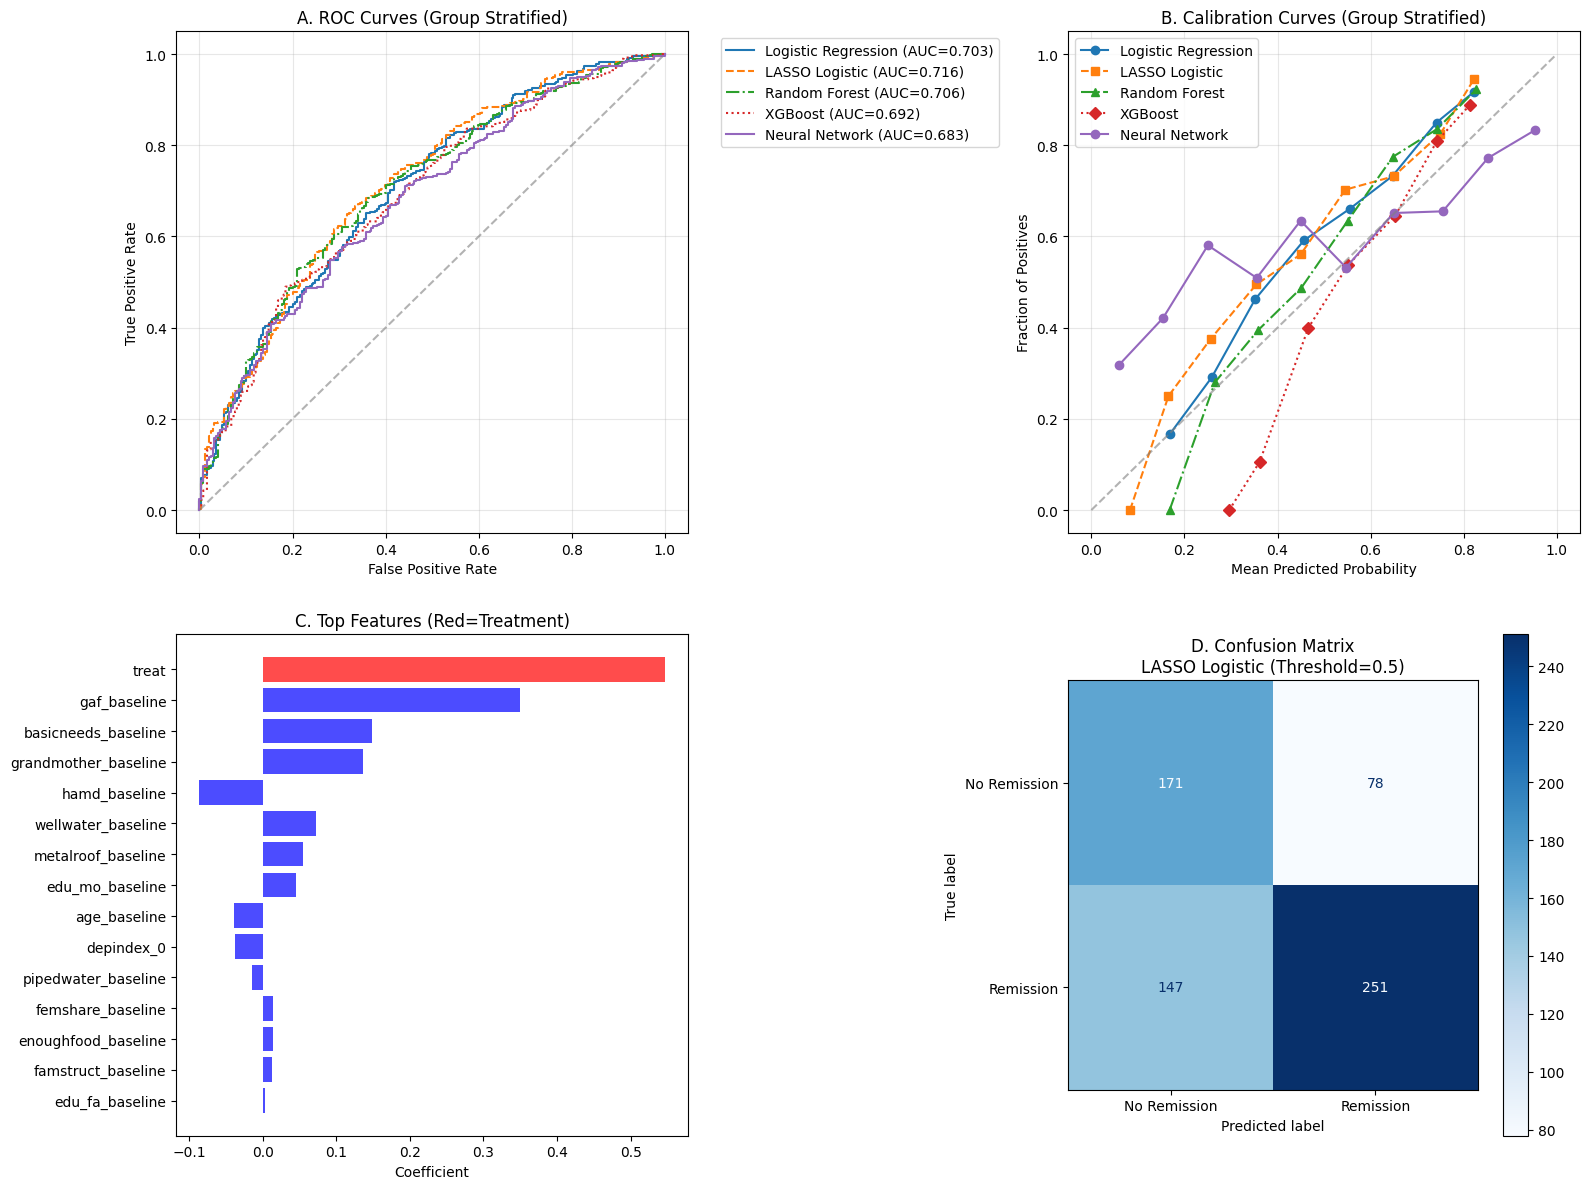

2025-07-29 17:08:31,689 - INFO - Refitted best: LASSO Logistic
2025-07-29 17:08:31,698 - INFO - Calibration on train completed


Spearman correlation between calibrated and uncalibrated probabilities: 0.8830

Hold-out Performance:
Uncalibrated: AUC=0.682, F1=0.000
Calibrated:   AUC=0.720, F1=0.709


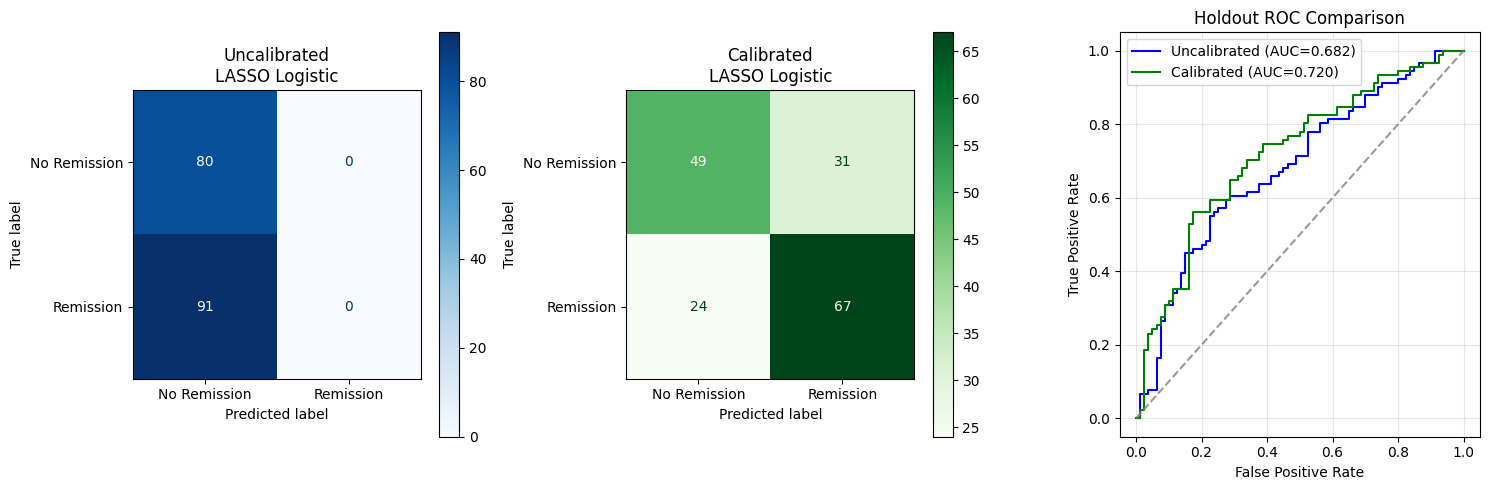

2025-07-29 17:08:31,881 - INFO - Performing SHAP analysis...
2025-07-29 17:08:31,881 - INFO - Treatment variable included in SHAP: True



Detailed Holdout Metrics:
Metric          Uncalibrated Calibrated  
---------------------------------------
Accuracy        0.468        0.678       
Precision       0.000        0.684       
Recall          0.000        0.736       
F1 Score        0.000        0.709       
AUC             0.682        0.720       
Specificity     1.000        0.613       
Sensitivity     0.000        0.736       

Confusion Matrix Components:
Component       Uncalibrated Calibrated  
---------------------------------------
True Positives  0            67          
False Positives 0            31          
True Negatives  80           49          
False Negatives 91           24          


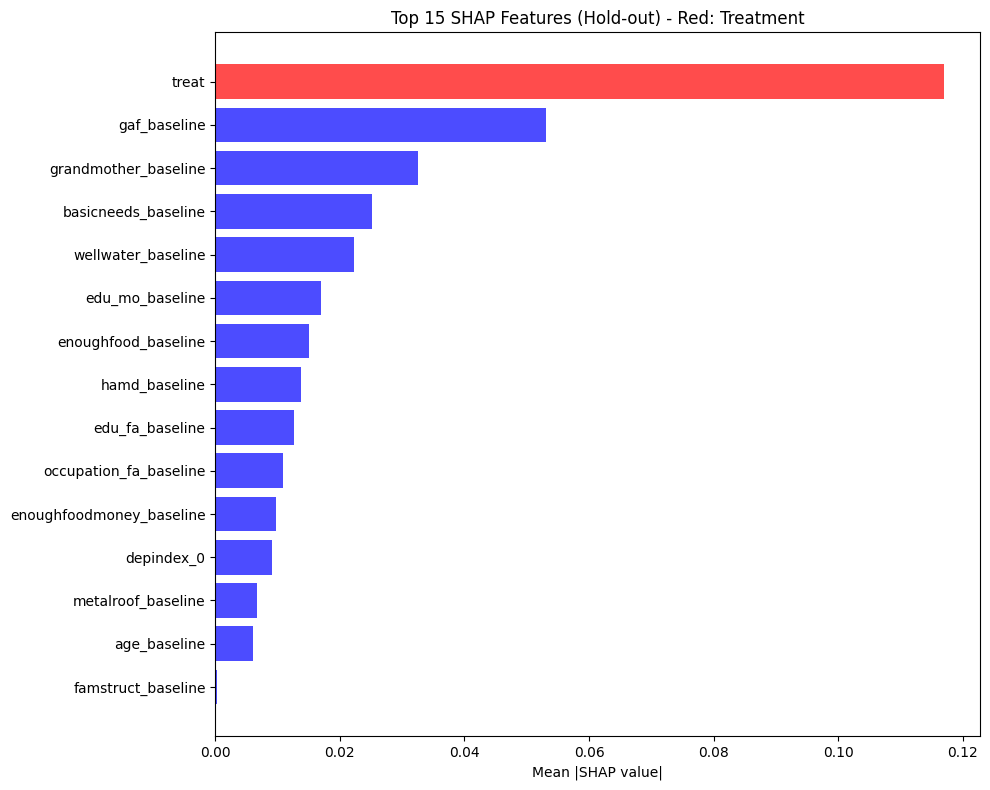

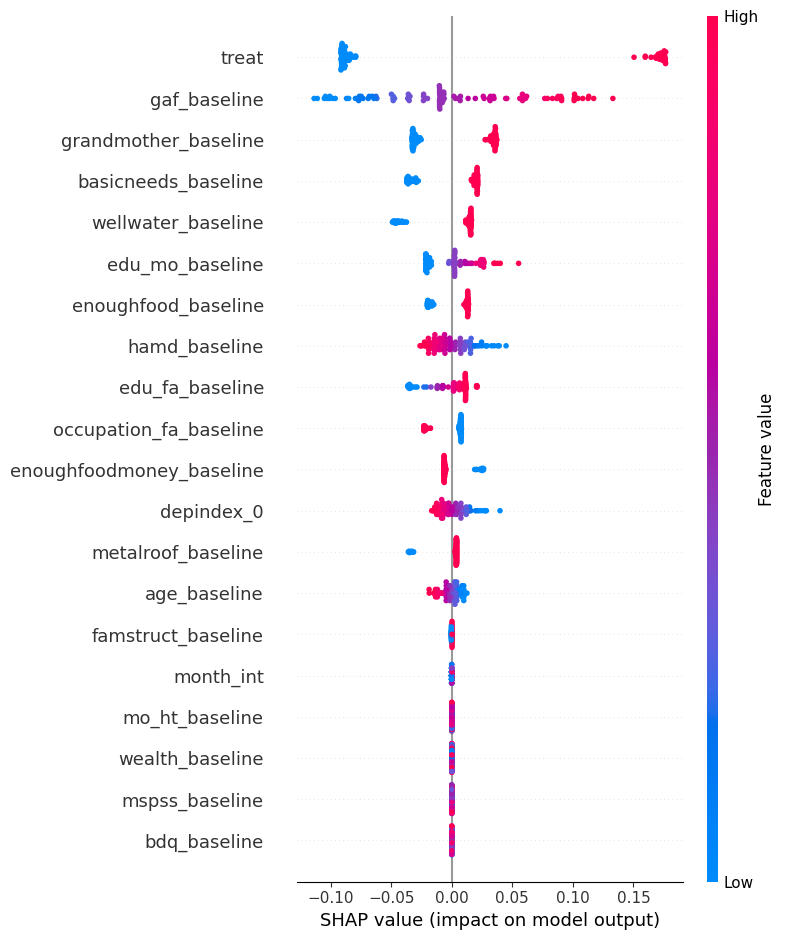


Generating SHAP Personas...
Top 3 SHAP features: ['grandmother_baseline', 'gaf_baseline', 'treat']

Top-3 SHAP Personas:
                                                   Profile  P(remission)
   grandmother_baseline=low & gaf_baseline=low & treat=low         0.367
  grandmother_baseline=low & gaf_baseline=low & treat=high         0.633
  grandmother_baseline=low & gaf_baseline=high & treat=low         0.621
 grandmother_baseline=low & gaf_baseline=high & treat=high         0.831
  grandmother_baseline=high & gaf_baseline=low & treat=low         0.418
 grandmother_baseline=high & gaf_baseline=low & treat=high         0.676
 grandmother_baseline=high & gaf_baseline=high & treat=low         0.670
grandmother_baseline=high & gaf_baseline=high & treat=high         0.858


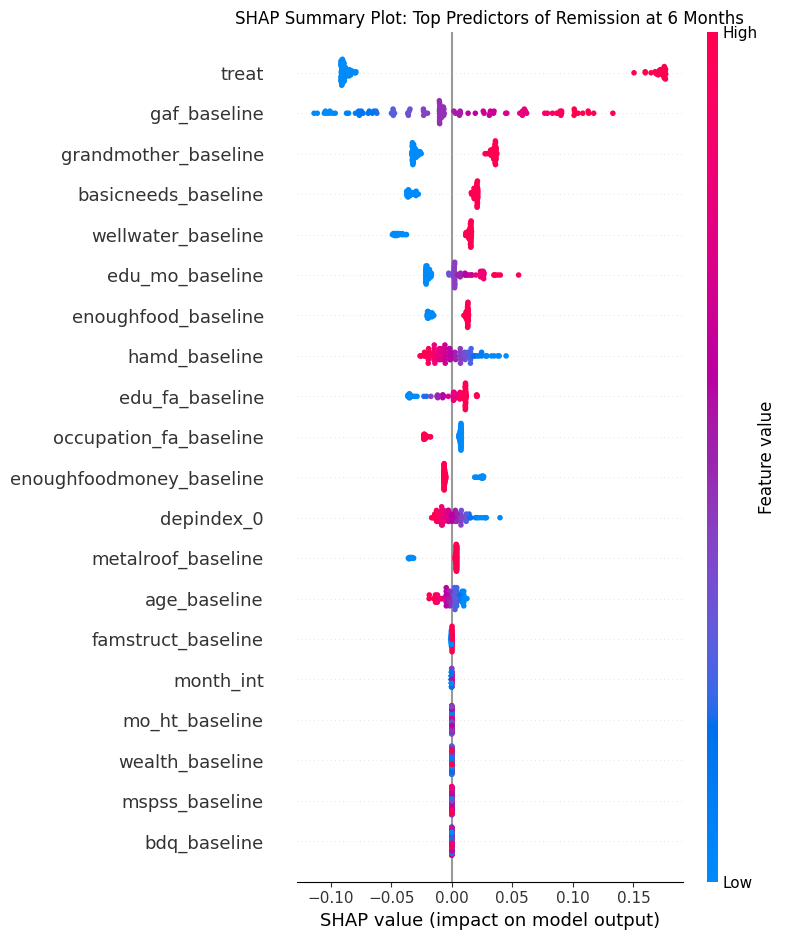

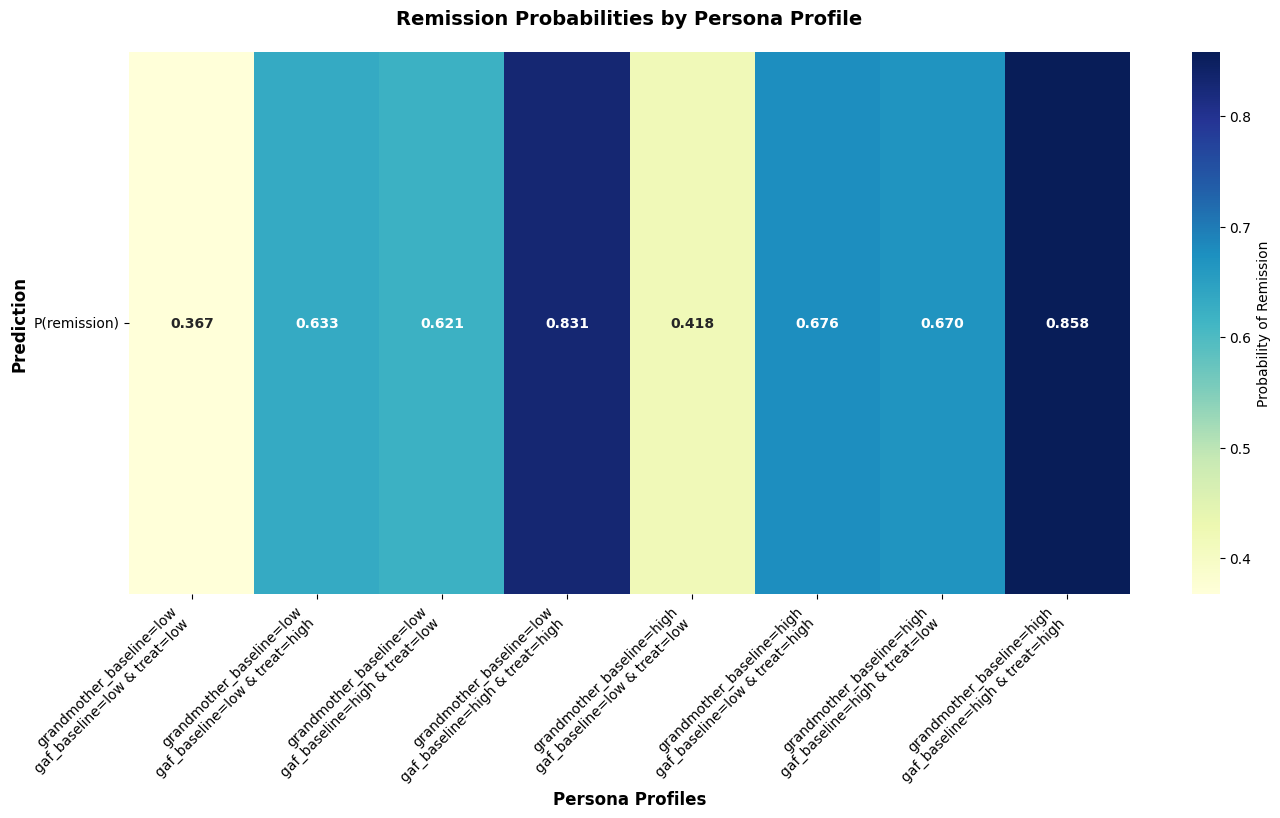


Debugging - Horizontal bar chart data:
Original proto_df:
                                             Profile  P(remission)
0  grandmother_baseline=low & gaf_baseline=low & ...         0.367
1  grandmother_baseline=low & gaf_baseline=low & ...         0.633
2  grandmother_baseline=low & gaf_baseline=high &...         0.621
3  grandmother_baseline=low & gaf_baseline=high &...         0.831
4  grandmother_baseline=high & gaf_baseline=low &...         0.418
5  grandmother_baseline=high & gaf_baseline=low &...         0.676
6  grandmother_baseline=high & gaf_baseline=high ...         0.670
7  grandmother_baseline=high & gaf_baseline=high ...         0.858

Sorted data for horizontal chart:
                                             Profile  P(remission)
0  grandmother_baseline=low & gaf_baseline=low & ...         0.367
4  grandmother_baseline=high & gaf_baseline=low &...         0.418
2  grandmother_baseline=low & gaf_baseline=high &...         0.621
1  grandmother_baseline=low & gaf_b

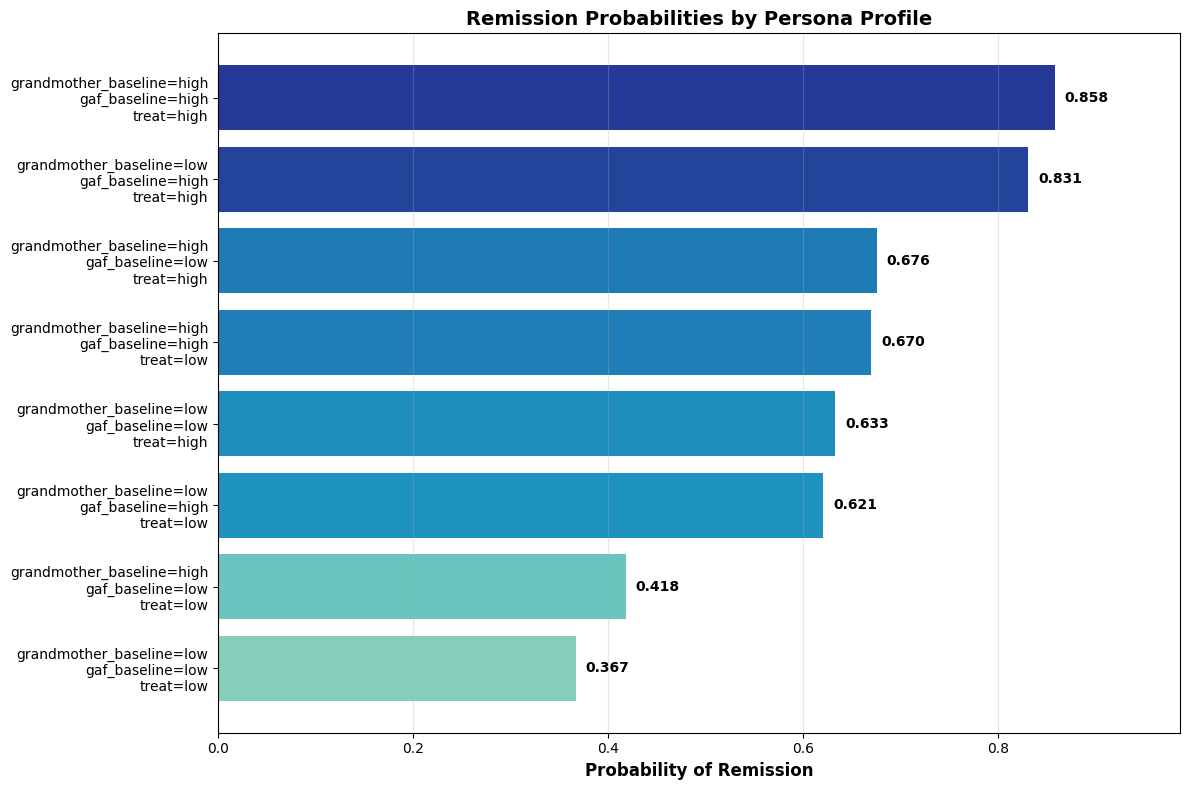

In [105]:
# Remission at 6 months - no SMOTE, no univariate selection, cluster-stratified CV

# ========= Imports =========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import shap
import joblib
import tensorflow as tf 
import logging
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GroupKFold, StratifiedGroupKFold
from skopt import BayesSearchCV

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from tabulate import tabulate
from itertools import product
import warnings
warnings.filterwarnings("ignore")

# ========= Configuration =========
@dataclass
class Config:
    RANDOM_STATE: int = 123
    N_FEATURES: int = 15
    OUTER_SPLITS: int = 5
    INNER_SPLITS: int = 3
    N_ITER: int = 20
    TEST_SIZE: float = 0.2
    TARGET_COL: str = "remission_6mo"
    CLUSTER_COL: str = "uc"  # cluster column for stratification
    ID_COL: str = "newid"
    EXCLUDE_COLS: List[str] = None
    MIN_CLUSTER_SIZE: int = 2  # Minimum samples per cluster for valid splits
    
    def __post_init__(self):
        if self.EXCLUDE_COLS is None:
            self.EXCLUDE_COLS = ["remission_6mo", "uc"]  # Exclude cluster from features

config = Config()

# ========= Logging Setup =========
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ========= Data Validation =========
def validate_data(df: pd.DataFrame, target_col: str, cluster_col: str, required_cols: List[str]) -> None:
    """Validate input data quality"""
    assert not df.empty, "DataFrame is empty"
    assert target_col in df.columns, f"Target column '{target_col}' not found"
    assert cluster_col in df.columns, f"Cluster column '{cluster_col}' not found"
    
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    assert df[target_col].nunique() > 1, "Target has only one class"
    
    # Validate cluster distribution
    cluster_sizes = df[cluster_col].value_counts()
    min_cluster_size = cluster_sizes.min()
    logger.info(f"Data validation passed. Shape: {df.shape}")
    logger.info(f"Clusters: {sorted(df[cluster_col].unique())}")
    logger.info(f"Cluster sizes: min={min_cluster_size}, max={cluster_sizes.max()}, mean={cluster_sizes.mean():.1f}")
    logger.info(f"Target distribution: {df[target_col].value_counts().to_dict()}")
    
    if min_cluster_size < config.MIN_CLUSTER_SIZE:
        logger.warning(f"Some clusters have <{config.MIN_CLUSTER_SIZE} samples, which may cause CV issues")

def validate_cluster_separation(train_clusters: np.ndarray, test_clusters: np.ndarray, 
                              fold_num: int = None) -> bool:
    """Validate that train and test clusters are completely separated"""
    train_set = set(train_clusters)
    test_set = set(test_clusters)
    overlap = train_set & test_set
    
    if overlap:
        logger.error(f"Fold {fold_num}: Cluster overlap detected: {overlap}")
        return False
    
    logger.info(f"Fold {fold_num}: Cluster separation validated. "
                f"Train clusters: {len(train_set)}, Test clusters: {len(test_set)}")
    return True

# ========= FIXED: Stratified Group Train/Test Split =========
def create_stratified_group_split(df: pd.DataFrame, target_col: str, cluster_col: str, 
                                test_size: float, random_state: int) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Create train/test split that maintains complete cluster separation while balancing target distribution
    """
    np.random.seed(random_state)
    
    # Calculate target distribution within each cluster
    cluster_stats = df.groupby(cluster_col)[target_col].agg(['count', 'mean']).reset_index()
    cluster_stats['target_ratio'] = cluster_stats['mean']
    cluster_stats = cluster_stats.sort_values('target_ratio')
    
    logger.info(f"Cluster target distribution:\n{cluster_stats}")
    
    # Stratified sampling of clusters based on target ratio
    total_clusters = len(cluster_stats)
    n_test_clusters = max(1, int(total_clusters * test_size))
    
    # Divide clusters into strata based on target ratio quartiles
    cluster_stats['stratum'] = pd.qcut(cluster_stats['target_ratio'], 
                                     q=min(4, total_clusters), 
                                     labels=False, 
                                     duplicates='drop')
    
    test_clusters = []
    for stratum in cluster_stats['stratum'].unique():
        stratum_clusters = cluster_stats[cluster_stats['stratum'] == stratum][cluster_col].values
        n_from_stratum = max(1, int(len(stratum_clusters) * test_size))
        selected = np.random.choice(stratum_clusters, n_from_stratum, replace=False)
        test_clusters.extend(selected)
    
    # Ensure we have the right number of test clusters
    if len(test_clusters) < n_test_clusters:
        remaining_clusters = cluster_stats[~cluster_stats[cluster_col].isin(test_clusters)][cluster_col].values
        additional = np.random.choice(remaining_clusters, 
                                    n_test_clusters - len(test_clusters), 
                                    replace=False)
        test_clusters.extend(additional)
    elif len(test_clusters) > n_test_clusters:
        test_clusters = np.random.choice(test_clusters, n_test_clusters, replace=False)
    
    test_clusters = list(test_clusters)
    train_clusters = [c for c in df[cluster_col].unique() if c not in test_clusters]
    
    # Create splits
    train_df = df[df[cluster_col].isin(train_clusters)].copy()
    test_df = df[df[cluster_col].isin(test_clusters)].copy()
    
    # Validate separation
    if not validate_cluster_separation(train_df[cluster_col].values, test_df[cluster_col].values, "HOLDOUT"):
        raise ValueError("Failed to create properly separated train/test split")
    
    # Log distributions
    logger.info(f"Train: {len(train_df)} samples, {len(train_clusters)} clusters")
    logger.info(f"Test: {len(test_df)} samples, {len(test_clusters)} clusters")
    logger.info(f"Train target dist: {train_df[target_col].value_counts().to_dict()}")
    logger.info(f"Test target dist: {test_df[target_col].value_counts().to_dict()}")
    
    return train_df, test_df

# ========= FIXED: Custom CV Class with Proper Validation =========
class ValidatedGroupKFold:
    """
    GroupKFold wrapper with validation and fallback mechanisms
    """
    def __init__(self, n_splits: int = 5, shuffle: bool = True, random_state: int = None):
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state
        self.group_kfold = GroupKFold(n_splits=n_splits)
    
    def split(self, X, y, groups):
        """Generate validated group-based splits"""
        if groups is None:
            raise ValueError("Groups cannot be None for GroupKFold")
        
        # Convert to numpy arrays for consistency
        if hasattr(X, 'shape'):
            n_samples = X.shape[0]
        else:
            n_samples = len(X)
        
        y = np.asarray(y)
        groups = np.asarray(groups)
        
        # Check if we have enough unique groups
        unique_groups = np.unique(groups)
        if len(unique_groups) < self.n_splits:
            logger.warning(f"Only {len(unique_groups)} groups for {self.n_splits} splits. "
                         f"Falling back to StratifiedKFold")
            skf = StratifiedKFold(n_splits=min(self.n_splits, len(unique_groups)), 
                                shuffle=self.shuffle, random_state=self.random_state)
            yield from skf.split(X, y)
            return
        
        # Use StratifiedGroupKFold for better target distribution balance
        try:
            sgkf = StratifiedGroupKFold(n_splits=self.n_splits, shuffle=self.shuffle, 
                                      random_state=self.random_state)
            splits = list(sgkf.split(X, y, groups))
        except (ValueError, Exception) as e:
            logger.warning(f"StratifiedGroupKFold failed: {e}. Falling back to GroupKFold")
            splits = list(self.group_kfold.split(X, y, groups))
        
        # Validate each split
        valid_splits = []
        for fold_idx, (train_idx, test_idx) in enumerate(splits):
            train_groups = groups[train_idx]
            test_groups = groups[test_idx]
            
            # Validate cluster separation
            if validate_cluster_separation(train_groups, test_groups, fold_idx + 1):
                # Additional validation: ensure both train and test have samples
                if len(train_idx) > 0 and len(test_idx) > 0:
                    # Check target distribution in both sets
                    train_targets = y[train_idx]
                    test_targets = y[test_idx]
                    
                    if len(np.unique(train_targets)) > 1 and len(np.unique(test_targets)) > 1:
                        valid_splits.append((train_idx, test_idx))
                        logger.info(f"Fold {fold_idx + 1}: Train={len(train_idx)}, Test={len(test_idx)}, "
                                  f"Train target ratio={train_targets.mean():.3f}, "
                                  f"Test target ratio={test_targets.mean():.3f}")
                    else:
                        logger.warning(f"Fold {fold_idx + 1}: Insufficient target diversity, skipping")
                else:
                    logger.warning(f"Fold {fold_idx + 1}: Empty train or test set, skipping")
            else:
                logger.warning(f"Fold {fold_idx + 1}: Failed cluster separation validation, skipping")
        
        if len(valid_splits) < 2:
            raise ValueError(f"Only {len(valid_splits)} valid folds generated, need at least 2")
        
        logger.info(f"Generated {len(valid_splits)} valid folds out of {len(splits)} attempted")
        yield from valid_splits
    
    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

# ========= FIXED: Simple Pipeline Builder =========
def build_simple_pipeline(base_model, config: Config):
    """Build a simple pipeline with only preprocessing and model"""
    pipeline = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('model', base_model)
    ])
    return pipeline

# ========= FIXED: Nested CV with Proper GroupKFold =========
def run_nested_cv_group_stratified(model, param_distributions: Dict, X: pd.DataFrame, y: np.ndarray, 
                                  groups: np.ndarray, config: Config) -> Dict[str, Any]:
    """
    FIXED: Nested CV with proper GroupKFold implementation
    """
    # Initialize CV splitters
    outer_cv = ValidatedGroupKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                                  random_state=config.RANDOM_STATE)
    inner_cv = ValidatedGroupKFold(n_splits=config.INNER_SPLITS, shuffle=True, 
                                  random_state=config.RANDOM_STATE + 1)

    # Convert DataFrame to numpy for consistent indexing
    X_values = X.values if hasattr(X, 'values') else X
    y = np.asarray(y)
    groups = np.asarray(groups)
    
    # Initialize results arrays
    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    outer_scores = []
    successful_folds = 0
    treatment_scores = []

    try:
        # Generate outer CV splits
        outer_splits = list(outer_cv.split(X_values, y, groups))
        logger.info(f"Generated {len(outer_splits)} outer CV folds")
        
        for fold, (train_idx, test_idx) in enumerate(outer_splits):
            logger.info(f"Processing outer fold {fold + 1}/{len(outer_splits)}")
            
            try:
                # Extract fold data
                X_train_fold = X.iloc[train_idx] if hasattr(X, 'iloc') else X_values[train_idx]
                y_train_fold = y[train_idx]
                groups_train_fold = groups[train_idx]
                X_test_fold = X.iloc[test_idx] if hasattr(X, 'iloc') else X_values[test_idx]
                y_test_fold = y[test_idx]

                # Log fold statistics
                logger.info(f"Fold {fold+1}: Train={len(train_idx)}, Test={len(test_idx)}")
                if hasattr(X, 'columns') and 'treat' in X.columns:
                    treat_col_idx = X.columns.get_loc('treat')
                    if hasattr(X, 'iloc'):
                        treat_dist = X.iloc[train_idx, treat_col_idx].value_counts()
                    else:
                        treat_dist = pd.Series(X_values[train_idx, treat_col_idx]).value_counts()
                    logger.info(f"Fold {fold+1} treatment distribution: {treat_dist.to_dict()}")

                # Build pipeline
                pipe = build_simple_pipeline(model, config)
                
                # FIXED: Properly configure BayesSearchCV with explicit CV
                search_space = {f'model__{k}': v for k, v in param_distributions.items()}
                
                # Generate inner CV splits for this fold
                try:
                    inner_splits = list(inner_cv.split(X_train_fold, y_train_fold, groups_train_fold))
                    logger.info(f"Fold {fold+1}: Generated {len(inner_splits)} inner CV splits")
                except Exception as e:
                    logger.warning(f"Fold {fold+1}: Inner CV failed: {e}. Using 3-fold StratifiedKFold")
                    inner_splits = list(StratifiedKFold(n_splits=3, shuffle=True, 
                                                      random_state=config.RANDOM_STATE).split(X_train_fold, y_train_fold))
                
                search = BayesSearchCV(
                    pipe,
                    search_spaces=search_space,
                    n_iter=config.N_ITER,
                    scoring='roc_auc',
                    cv=inner_splits,  # FIXED: Pass list of splits, not generator
                    n_jobs=1,
                    random_state=config.RANDOM_STATE,
                    error_score='raise'
                )
                
                # Fit hyperparameter search
                if hasattr(X_train_fold, 'values'):
                    search.fit(X_train_fold, y_train_fold)
                else:
                    # Convert back to DataFrame for proper feature handling
                    X_train_df = pd.DataFrame(X_train_fold, columns=X.columns)
                    search.fit(X_train_df, y_train_fold)
                
                best_model = search.best_estimator_

                # Extract treatment information
                model_obj = best_model.named_steps['model']
                treat_info = {'fold': fold + 1, 'treat_coef': 0, 'treat_importance': 0}
                
                if hasattr(model_obj, 'coef_') and hasattr(X, 'columns') and 'treat' in X.columns:
                    treat_idx = X.columns.get_loc('treat')
                    treat_coef = model_obj.coef_[0][treat_idx]
                    treat_info['treat_coef'] = treat_coef
                    logger.info(f"Fold {fold+1}: Treatment coefficient = {treat_coef:.3f}")
                elif hasattr(model_obj, 'feature_importances_') and hasattr(X, 'columns') and 'treat' in X.columns:
                    treat_idx = X.columns.get_loc('treat')
                    treat_importance = model_obj.feature_importances_[treat_idx]
                    treat_info['treat_importance'] = treat_importance
                    logger.info(f"Fold {fold+1}: Treatment importance = {treat_importance:.3f}")
                
                treatment_scores.append(treat_info)

                # Make predictions
                if hasattr(X_test_fold, 'values'):
                    prob = best_model.predict_proba(X_test_fold)[:, 1]
                else:
                    X_test_df = pd.DataFrame(X_test_fold, columns=X.columns)
                    prob = best_model.predict_proba(X_test_df)[:, 1]
                
                pred = (prob > 0.5).astype(int)
                
                # Store results
                y_probs[test_idx] = prob
                y_preds[test_idx] = pred
                auc_score = roc_auc_score(y_test_fold, prob)
                outer_scores.append(auc_score)
                successful_folds += 1
                
                logger.info(f"Fold {fold+1} AUC: {auc_score:.3f}")
                
            except Exception as e:
                logger.error(f"Error in fold {fold + 1}: {e}")
                # For failed folds, use neutral predictions
                y_probs[test_idx] = 0.5
                y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
                outer_scores.append(0.5)

    except Exception as e:
        logger.error(f"Critical error in nested CV: {e}")
        raise

    # Validate results
    if successful_folds < max(1, config.OUTER_SPLITS // 2):
        raise RuntimeError(f"Too many folds failed: {successful_folds}/{len(outer_splits)}")

    # Calculate metrics on valid predictions only
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    # Log treatment importance summary
    if treatment_scores:
        avg_treat_coef = np.mean([t.get('treat_coef', 0) for t in treatment_scores])
        avg_treat_importance = np.mean([t.get('treat_importance', 0) for t in treatment_scores])
        logger.info(f"Average treatment coefficient: {avg_treat_coef:.3f}")
        logger.info(f"Average treatment importance: {avg_treat_importance:.3f}")

    return {
        "model": search.best_estimator_ if 'search' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(outer_scores),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": 0,  # Legacy compatibility
        "treatment_scores": treatment_scores
    }

# ========= FIXED: Neural Network CV =========
def run_nn_cv_group_stratified(X: pd.DataFrame, y: np.ndarray, groups: np.ndarray, config: Config) -> Dict[str, Any]:
    """FIXED: Neural network CV with proper GroupKFold"""
    outer_cv = ValidatedGroupKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                                  random_state=config.RANDOM_STATE)
    
    # Convert to numpy for consistent indexing
    X_values = X.values if hasattr(X, 'values') else X
    y = np.asarray(y)
    groups = np.asarray(groups)
    
    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    aucs = []
    successful_folds = 0
    feature_names = X.columns.tolist() if hasattr(X, 'columns') else None
    treatment_scores = []

    try:
        outer_splits = list(outer_cv.split(X_values, y, groups))
        logger.info(f"NN: Generated {len(outer_splits)} outer CV folds")
        
        for fold, (train_idx, test_idx) in enumerate(outer_splits):
            logger.info(f"Processing NN fold {fold + 1}/{len(outer_splits)}")
            
            try:
                # Extract fold data
                X_train_fold = X.iloc[train_idx] if hasattr(X, 'iloc') else X_values[train_idx]
                y_train_fold = y[train_idx]
                X_test_fold = X.iloc[test_idx] if hasattr(X, 'iloc') else X_values[test_idx]
                y_test_fold = y[test_idx]

                # Apply preprocessing
                imputer = SimpleImputer(strategy='median')
                scaler = StandardScaler()
                
                X_train_processed = imputer.fit_transform(X_train_fold)
                X_train_scaled = scaler.fit_transform(X_train_processed)
                
                logger.info(f"NN Fold {fold+1}: Training on {len(X_train_scaled)} samples, "
                           f"class distribution: {np.bincount(y_train_fold)}")

                # Track treatment info
                treat_info = {'fold': fold + 1, 'treat_coef': 0, 'treat_importance': 0}
                treatment_scores.append(treat_info)
                
                # Build and train model
                model = build_nn_model(input_dim=X_train_scaled.shape[1])
                
                # Compute class weights
                unique_classes = np.unique(y_train_fold)
                if len(unique_classes) > 1:
                    cw_vals = compute_class_weight('balanced', classes=unique_classes, y=y_train_fold)
                    class_weights = {i: w for i, w in enumerate(cw_vals)}
                else:
                    class_weights = None
                
                batch_size = max(8, min(32, len(X_train_scaled) // 4))
                
                model.fit(
                    X_train_scaled, y_train_fold,
                    validation_split=0.2,
                    epochs=100,
                    batch_size=batch_size,
                    callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
                    class_weight=class_weights,
                    verbose=0
                )

                # Transform test data and predict
                X_test_processed = imputer.transform(X_test_fold)
                X_test_scaled = scaler.transform(X_test_processed)
                
                prob = model.predict(X_test_scaled, verbose=0).ravel()
                pred = (prob > 0.5).astype(int)
                
                y_probs[test_idx] = prob
                y_preds[test_idx] = pred
                auc_score = roc_auc_score(y_test_fold, prob)
                aucs.append(auc_score)
                successful_folds += 1
                
                logger.info(f"NN Fold {fold+1} AUC: {auc_score:.3f}")
                
            except Exception as e:
                logger.error(f"Error in NN fold {fold + 1}: {e}")
                y_probs[test_idx] = 0.5
                y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
                aucs.append(0.5)

    except Exception as e:
        logger.error(f"Critical error in NN CV: {e}")
        raise

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid NN predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    logger.info(f"NN: Completed {successful_folds}/{len(outer_splits)} folds")

    return {
        "model": model if 'model' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(aucs),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": 0,
        "treatment_scores": treatment_scores
    }

# ========= Leak-Free Preprocessor (No changes needed) =========
class LeakFreePreprocessor:
    """Preprocessing that prevents data leakage by fitting only on training folds"""
    
    def __init__(self, config: Config):
        self.config = config
        self.imputer = None
        self.scaler = None
        self.label_encoder = None
        self.feature_names = None
        
    def fit(self, X: pd.DataFrame, y: pd.Series) -> 'LeakFreePreprocessor':
        """Fit preprocessor components separately to allow proper CV"""
        self.feature_names = X.columns.tolist()
        
        # Fit components
        self.imputer = SimpleImputer(strategy='median')
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        
        # Fit on training data
        X_imputed = self.imputer.fit_transform(X)
        self.scaler.fit(X_imputed)
        self.label_encoder.fit(y)
        
        logger.info(f"Preprocessor fitted on {X.shape[0]} samples, {X.shape[1]} features")
        return self
    
    def transform_features(self, X):
        """Transform features using fitted preprocessor"""
        if isinstance(X, pd.DataFrame):
            X_ordered = X.reindex(columns=self.feature_names, fill_value=np.nan)
            X_values = X_ordered.values
        else:
            X_values = X
            
        X_imputed = self.imputer.transform(X_values)
        X_scaled = self.scaler.transform(X_imputed)
        return X_scaled
    
    def transform_target(self, y: pd.Series) -> np.ndarray:
        """Transform target using fitted label encoder"""
        return self.label_encoder.transform(y)
    
    def get_feature_names(self) -> List[str]:
        """Get original feature names"""
        return self.feature_names.copy()

# ========= Neural Network Builder (No changes) =========
def build_nn_model(input_dim: int, neurons1: int = 64, neurons2: int = 32, 
                   dropout: float = 0.3, learning_rate: float = 1e-3) -> tf.keras.Model:
    """Build neural network with improved architecture"""
    model = Sequential([
        Dense(neurons1, activation='relu', input_dim=input_dim,
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(neurons2, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model

# ========= Utility Functions =========
def calculate_holdout_metrics(y_true: np.ndarray, y_pred: np.ndarray, 
                            y_proba: np.ndarray) -> Dict[str, float]:
    """Calculate comprehensive holdout metrics including confusion matrix components"""
    cm = confusion_matrix(y_true, y_pred)
    
    # Extract confusion matrix components
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true, y_proba),
        'Brier Score': brier_score_loss(y_true, y_proba),
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0
    }

# ========= Enhanced plot_performance_curves Function =========
def plot_performance_curves(results: Dict, y_true: np.ndarray, feature_names, title_suffix: str = "", threshold: float = 0.5):
    """Generate annotated ROC, calibration curves, feature importance, and confusion matrix with enhanced readability."""
    import matplotlib.pyplot as plt
    import numpy as np
    from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
    from sklearn.calibration import calibration_curve

    plt.figure(figsize=(16, 12))
    line_styles = ['-', '--', '-.', ':']
    markers = ['o', 's', '^', 'D']
    colors = plt.cm.tab10.colors
    model_names = list(results.keys())

    # ROC Curves
    plt.subplot(2, 2, 1)
    for idx, name in enumerate(model_names):
        res = results[name]
        if res and 'y_probs' in res:
            valid_mask = res['y_probs'] >= 0
            if np.any(valid_mask):
                y_valid = y_true[valid_mask]
                probs_valid = res['y_probs'][valid_mask]
                fpr, tpr, _ = roc_curve(y_valid, probs_valid)
                auc = roc_auc_score(y_valid, probs_valid)
                label = f"{name} (AUC={auc:.3f})"
                plt.plot(fpr, tpr, label=label,
                         linestyle=line_styles[idx % len(line_styles)],
                         color=colors[idx % len(colors)])
    plt.plot([0, 1], [0, 1], '--', color='gray', alpha=0.6)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"A. ROC Curves {title_suffix}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)

    # Calibration Curves
    plt.subplot(2, 2, 2)
    for idx, name in enumerate(model_names):
        res = results[name]
        if res and 'y_probs' in res:
            valid_mask = res['y_probs'] >= 0
            if np.any(valid_mask):
                y_valid = y_true[valid_mask]
                probs_valid = res['y_probs'][valid_mask]
                frac_pos, mean_pred = calibration_curve(y_valid, probs_valid, n_bins=10)
                plt.plot(mean_pred, frac_pos,
                         marker=markers[idx % len(markers)],
                         linestyle=line_styles[idx % len(line_styles)],
                         color=colors[idx % len(colors)],
                         label=name)
    plt.plot([0, 1], [0, 1], '--', color='gray', alpha=0.6)
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title(f"B. Calibration Curves {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Feature Importance
    plt.subplot(2, 2, 3)
    try:
        best_model_name = max(results.keys(), key=lambda k: results[k]['metrics']['AUC'] if results[k] else 0)
        best_model = results[best_model_name]['model']
        if hasattr(best_model, 'named_steps'):
            model_obj = best_model.named_steps['model']
            if hasattr(model_obj, 'coef_'):
                coeffs = model_obj.coef_[0]
                top_idx = np.argsort(np.abs(coeffs))[-15:]
                top_feats = [feature_names[i] for i in top_idx]
                colors_bar = ['red' if feat == 'treat' else 'blue' for feat in top_feats]
                plt.barh(range(len(top_idx)), coeffs[top_idx], color=colors_bar, alpha=0.7)
                plt.yticks(range(len(top_idx)), top_feats)
                plt.xlabel("Coefficient")
                plt.title("C. Top Features (Red=Treatment)")
            elif hasattr(model_obj, 'feature_importances_'):
                importances = model_obj.feature_importances_
                top_idx = np.argsort(importances)[-15:]
                top_feats = [feature_names[i] for i in top_idx]
                colors_bar = ['red' if feat == 'treat' else 'blue' for feat in top_feats]
                plt.barh(range(len(top_idx)), importances[top_idx], color=colors_bar, alpha=0.7)
                plt.yticks(range(len(top_idx)), top_feats)
                plt.xlabel("Importance")
                plt.title("C. Top Features (Red=Treatment)")
            else:
                plt.text(0.5, 0.5, "Feature importance\nnot available",
                         ha='center', va='center', transform=plt.gca().transAxes)
    except Exception as e:
        print(f"Error plotting feature importance: {e}")
        plt.text(0.5, 0.5, "Feature importance\nnot available",
                 ha='center', va='center', transform=plt.gca().transAxes)

    # Confusion Matrix
    plt.subplot(2, 2, 4)
    try:
        res = results[best_model_name]
        valid_mask = res['y_probs'] >= 0
        if np.any(valid_mask):
            y_valid = y_true[valid_mask]
            y_pred_valid = (res['y_probs'][valid_mask] >= threshold).astype(int)
            cm = confusion_matrix(y_valid, y_pred_valid)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Remission', 'Remission'])
            disp.plot(ax=plt.gca(), cmap='Blues', values_format='d')
            plt.title(f"D. Confusion Matrix\n{best_model_name} (Threshold={threshold})")
    except Exception as e:
        print(f"Error plotting confusion matrix: {e}")
        plt.text(0.5, 0.5, "Confusion Matrix\nnot available",
                 ha='center', va='center', transform=plt.gca().transAxes)

    plt.tight_layout()
    plt.show()

# ========= Holdout Confusion Matrix Function =========
def plot_holdout_confusion_matrices(y_true, preds_unc, preds_cal, probs_unc, probs_cal, best_name):
    """Plot confusion matrices for holdout predictions"""
    plt.figure(figsize=(15, 5))
    
    # Uncalibrated Confusion Matrix
    plt.subplot(1, 3, 1)
    cm_unc = confusion_matrix(y_true, preds_unc)
    disp_unc = ConfusionMatrixDisplay(confusion_matrix=cm_unc, 
                                     display_labels=['No Remission', 'Remission'])
    disp_unc.plot(ax=plt.gca(), cmap='Blues', values_format='d')
    plt.title(f"Uncalibrated\n{best_name}")
    
    # Calibrated Confusion Matrix
    plt.subplot(1, 3, 2)
    cm_cal = confusion_matrix(y_true, preds_cal)
    disp_cal = ConfusionMatrixDisplay(confusion_matrix=cm_cal, 
                                     display_labels=['No Remission', 'Remission'])
    disp_cal.plot(ax=plt.gca(), cmap='Greens', values_format='d')
    plt.title(f"Calibrated\n{best_name}")
    
    # ROC Comparison
    plt.subplot(1, 3, 3)
    fpr_unc, tpr_unc, _ = roc_curve(y_true, probs_unc)
    fpr_cal, tpr_cal, _ = roc_curve(y_true, probs_cal)
    
    auc_unc = roc_auc_score(y_true, probs_unc)
    auc_cal = roc_auc_score(y_true, probs_cal)
    
    plt.plot(fpr_unc, tpr_unc, label=f'Uncalibrated (AUC={auc_unc:.3f})', color='blue')
    plt.plot(fpr_cal, tpr_cal, label=f'Calibrated (AUC={auc_cal:.3f})', color='green')
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Holdout ROC Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ========= SHAP Feature Analysis =========
def perform_shap_analysis(best_model, X_holdout: np.ndarray, feature_names: List[str],
                         preprocessor: LeakFreePreprocessor, holdout_raw: pd.DataFrame):
    """Perform SHAP analysis with proper error handling"""
    try:
        logger.info("Performing SHAP analysis...")
        
        model_obj = best_model.named_steps['model']
        if not hasattr(model_obj, 'predict_proba'):
            logger.warning("Model doesn't support probability prediction, skipping SHAP")
            return None
        
        # Use all features - no feature selection
        X_for_shap = X_holdout
        shap_feature_names = feature_names
        
        # Highlight if treatment is included
        treat_included = 'treat' in shap_feature_names
        logger.info(f"Treatment variable included in SHAP: {treat_included}")
        
        n_background = min(100, X_for_shap.shape[0])
        background_data = X_for_shap[:n_background]  # Use this as "features" for SHAP summary plot
        
        if hasattr(model_obj, 'tree_'):
            explainer = shap.TreeExplainer(model_obj)
            shap_values = explainer.shap_values(background_data)
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        else:
            explainer = shap.Explainer(model_obj.predict_proba, background_data)
            shap_values = explainer(background_data)
            if hasattr(shap_values, 'values'):
                shap_values = shap_values.values[:, :, 1]
        
        shap_abs = np.abs(shap_values).mean(axis=0)
        top_n = min(15, len(shap_feature_names))
        top_idx = np.argsort(shap_abs)[-top_n:]
        
        plt.figure(figsize=(10, 8))
        colors = ['red' if shap_feature_names[i] == 'treat' else 'blue' for i in top_idx]
        plt.barh(range(len(top_idx)), shap_abs[top_idx], color=colors, alpha=0.7)
        plt.yticks(range(len(top_idx)), [shap_feature_names[i] for i in top_idx])
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"Top {top_n} SHAP Features (Hold-out) - Red: Treatment")
        plt.tight_layout()
        plt.show()
        
        try:
            shap.summary_plot(
                shap_values, 
                features=background_data, 
                feature_names=shap_feature_names,
                show=False
            )
            plt.tight_layout()
            plt.show()
        except Exception as e:
            logger.warning(f"Error creating SHAP summary plot: {e}")
            
    except Exception as e:
        logger.error(f"Error in SHAP analysis: {e}")
        return None

    return {
    'shap_values': shap_values,
    'feature_names': shap_feature_names,
    'features_used': background_data
}

# ========= UPDATED: Main Pipeline with Fixed GroupKFold =========
def main():
    """UPDATED: Main execution pipeline with fixed GroupKFold implementation"""

    # 1. Load & validate
    try:
        df = imputed_datasets["dat_ml_6m"]
        logger.info(f"Data loaded: {df.shape}")
        required = [config.TARGET_COL, config.CLUSTER_COL, config.ID_COL] + config.EXCLUDE_COLS + ['treat']
        validate_data(df, config.TARGET_COL, config.CLUSTER_COL, required)
    except Exception as e:
        logger.error(f"Loading/validation error: {e}")
        return

    # 2. Quick QC
    logger.info(f"Target counts:\n{df[config.TARGET_COL].value_counts()}")
    logger.info(f"Cluster counts:\n{df[config.CLUSTER_COL].value_counts()}")
    logger.info(f"Missing values: {df.isnull().sum().sum()}")

    # 3. FIXED: Improved cluster-stratified train/hold-out split
    train_df, holdout_df = create_stratified_group_split(
        df, config.TARGET_COL, config.CLUSTER_COL, config.TEST_SIZE, config.RANDOM_STATE
    )
    logger.info(f"Train={len(train_df)}, Hold-out={len(holdout_df)}")

    # 4. Prepare training data (preserve DataFrame structure)
    X_train = train_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    y_train = train_df[config.TARGET_COL].values
    groups_train = train_df[config.CLUSTER_COL].values  # Fixed: use groups instead of clusters
    feature_names = X_train.columns.tolist()
    
    logger.info(f"Training features: {len(feature_names)}")
    logger.info(f"Treatment variable included: {'treat' in feature_names}")
    logger.info(f"Unique groups in training: {len(np.unique(groups_train))}")

    # 5. Define models & parameters
    models_and_params = {
        "Logistic Regression": (
            LogisticRegression(max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.01, 0.1, 1.0, 10.0]}
        ),
        "LASSO Logistic": (
            LogisticRegression(penalty='l1', solver='liblinear',
                               max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.001, 0.01, 0.1, 1, 10]}
        ),
        "Random Forest": (
            RandomForestClassifier(class_weight='balanced',
                                   random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "max_depth": [3, 5, 10],
             "min_samples_split": [5, 10],
             "min_samples_leaf": [2, 5]}
        ),
        "XGBoost": (
            XGBClassifier(use_label_encoder=False,
                          eval_metric='logloss',
                          random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "learning_rate": [0.01, 0.1],
             "max_depth": [3, 6],
             "subsample": [0.8, 1.0]}
        )
    }

    # 6. FIXED: Run nested CV with proper GroupKFold
    results = {}
    for name, (model, params) in models_and_params.items():
        logger.info(f"→ Nested CV: {name}")
        try:
            results[name] = run_nested_cv_group_stratified(
                model, params, X_train, y_train, groups_train, config
            )
            logger.info(f"   AUC={results[name]['metrics']['AUC']:.3f}")
        except Exception as e:
            logger.error(f"   {name} failed: {e}")

    # 7. FIXED: Neural network with GroupKFold
    try:
        logger.info("→ Nested CV: Neural Network")
        results['Neural Network'] = run_nn_cv_group_stratified(X_train, y_train, groups_train, config)
        logger.info(f"   AUC={results['Neural Network']['metrics']['AUC']:.3f}")
    except Exception as e:
        logger.error(f"   NN failed: {e}")

    # 8. Show performance table
    perf_rows = []
    for m, res in results.items():
        if res and 'metrics' in res:
            row = {"Model": m}
            row.update({k: round(v, 3) for k, v in res['metrics'].items()})
            row["Folds"] = res.get('successful_folds', 'N/A')
            perf_rows.append(row)
    
    if not perf_rows:
        logger.error("No successful models to display")
        return
        
    perf_df = pd.DataFrame(perf_rows)
    print("\nNested CV Performance (Group Stratified)")
    print(tabulate(perf_df, headers='keys', tablefmt='grid', showindex=False))

    # 9. Fit preprocessor on full training data
    preprocessor = LeakFreePreprocessor(config)
    preprocessor.fit(X_train, train_df[config.TARGET_COL])
    
    # Transform training data
    X_train_proc = preprocessor.transform_features(X_train)
    y_train_processed = preprocessor.transform_target(train_df[config.TARGET_COL])
    
    logger.info(f"Final training data: {X_train_proc.shape}, class distribution: {np.bincount(y_train_processed)}")

    # 10. Plot OOF performance
    plot_performance_curves(results, y_train, feature_names, title_suffix="(Group Stratified)")

    # 11. Refit best pipeline on full training data
    if not results:
        logger.error("No successful models to select from")
        return

    best_name = max(results, key=lambda k: results[k]['metrics']['AUC'] if results[k] else 0)
    best_result = results[best_name]

    if not best_result or 'model' not in best_result:
        logger.error(f"Best model {best_name} has no trained model")
        return

    # Build and fit new pipeline on full processed data
    best_base_model = models_and_params[best_name][0]
    best_pipe = results[best_name]['model']           
    best_pipe.fit(X_train, y_train)                   
    logger.info(f"Refitted best: {best_name}")

    # 12. Calibrate via Platt scaling
    calibrator = CalibratedClassifierCV(
        estimator=best_pipe.named_steps['model'],
        method='sigmoid',
        cv=3
    )
    calibrator.fit(X_train_proc, y_train_processed)
    logger.info("Calibration on train completed")

    # 13. Prepare hold-out
    X_hold = holdout_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    X_hold_proc = preprocessor.transform_features(X_hold)
    y_hold = preprocessor.transform_target(holdout_df[config.TARGET_COL])

    # 14. Make predictions
    probs_unc = best_pipe.predict_proba(X_hold_proc)[:,1]
    probs_cal = calibrator.predict_proba(X_hold_proc)[:, 1]

    # Verify calibration preserves ranking
    spearman_corr = pd.Series(probs_unc).corr(pd.Series(probs_cal), method='spearman')
    print(f"Spearman correlation between calibrated and uncalibrated probabilities: {spearman_corr:.4f}")

    # 15. Calculate metrics
    preds_unc = (probs_unc > 0.5).astype(int)
    preds_cal = (probs_cal > 0.5).astype(int)
    hold_unc = calculate_holdout_metrics(y_hold, preds_unc, probs_unc)
    hold_cal = calculate_holdout_metrics(y_hold, preds_cal, probs_cal)

    print(f"\nHold-out Performance:")
    print(f"Uncalibrated: AUC={hold_unc['AUC']:.3f}, F1={hold_unc['F1 Score']:.3f}")
    print(f"Calibrated:   AUC={hold_cal['AUC']:.3f}, F1={hold_cal['F1 Score']:.3f}")

    # Plot holdout results
    plot_holdout_confusion_matrices(y_hold, preds_unc, preds_cal, probs_unc, probs_cal, best_name)
    
    # Print detailed metrics
    print(f"\nDetailed Holdout Metrics:")
    print(f"{'Metric':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC', 'Specificity', 'Sensitivity']:
        print(f"{metric:<15} {hold_unc[metric]:<12.3f} {hold_cal[metric]:<12.3f}")
    
    print(f"\nConfusion Matrix Components:")
    print(f"{'Component':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for component in ['True Positives', 'False Positives', 'True Negatives', 'False Negatives']:
        print(f"{component:<15} {hold_unc[component]:<12} {hold_cal[component]:<12}")

    # 16. SHAP & Personas
    shap_info = perform_shap_analysis(
        best_pipe,
        X_hold_proc,
        feature_names,
        preprocessor,
        holdout_df
    )

    if shap_info and shap_info['shap_values'] is not None:
        sv = shap_info['shap_values']
        feats = shap_info['feature_names']
        abs_mean = np.abs(sv).mean(axis=0)

        if len(feats) >= 3:
            print("\nGenerating SHAP Personas...")
            raw_df = train_df.drop(columns=config.EXCLUDE_COLS + [config.ID_COL])
            raw_median = raw_df.median()
            raw_min = raw_df.min()
            raw_max = raw_df.max()

            X_shap_used = shap_info['features_used']  # same 100 rows used for shap_values

            fig_shap_remission = plt.figure(figsize=(10, 8))

            shap.summary_plot(
                sv,
                features=X_shap_used,
                feature_names=feats,
                show=False
            )

            plt.title("SHAP Summary Plot: Top Predictors of Remission at 6 Months")
            plt.tight_layout()
            fig_shap_remission = plt.gcf()

            # Pick top-3 by |SHAP|
            top3_idx = np.argsort(abs_mean)[-3:]
            top3_feats = [feats[i] for i in top3_idx]

            print(f"Top 3 SHAP features: {top3_feats}")

             # Save components with variant suffix
            variant = "remission"
            globals().update({
                f"shap_values_{variant}": sv,
                f"X_{variant}": X_shap_used,
                f"fig_shap_{variant}": fig_shap_remission,
                f"feature_names_{variant}": feats
            })
            
            # Create pipeline for personas
            class PersonaPipeline:
                def __init__(self, preprocessor, calibrator):
                    self.preprocessor = preprocessor
                    self.calibrator = calibrator
                
                def predict_proba(self, X_raw):
                    X_proc = self.preprocessor.transform_features(X_raw)
                    return self.calibrator.predict_proba(X_proc)
            
            final_pipe = PersonaPipeline(preprocessor, calibrator)
            
            prototypes = []
            for combo in product(['low','high'], repeat=3):
                row = raw_median.copy()
                desc = []
                for feat, lvl in zip(top3_feats, combo):
                    row[feat] = raw_min[feat] if lvl=='low' else raw_max[feat]
                    desc.append(f"{feat}={lvl}")
                
                arr_df = pd.DataFrame([row.reindex(feature_names)])
                try:
                    p = final_pipe.predict_proba(arr_df)[0,1]
                    prototypes.append({
                        'Profile': ' & '.join(desc),
                        'P(remission)': round(p, 3)
                    })
                except Exception as e:
                    logger.warning(f"Error generating persona for {desc}: {e}")
            
            if prototypes:
                proto_df = pd.DataFrame(prototypes)
                print("\nTop-3 SHAP Personas:")
                print(proto_df.to_string(index=False))
                
                try:
                    # Create persona visualizations
                    plt.figure(figsize=(14, 8))
                    
                    def format_label(label, max_chars_per_line=30):
                        parts = label.split(' & ')
                        formatted_parts = []
                        current_line = ""
                        
                        for part in parts:
                            if len(current_line + part) <= max_chars_per_line:
                                current_line += part + " & " if current_line else part
                            else:
                                if current_line:
                                    formatted_parts.append(current_line.rstrip(" & "))
                                current_line = part + " & "
                        
                        if current_line:
                            formatted_parts.append(current_line.rstrip(" & "))
                        
                        return '\n'.join(formatted_parts)
                    
                    formatted_labels = [format_label(profile) for profile in proto_df['Profile']]
                    
                    heatmap_data = proto_df.set_index('Profile')[['P(remission)']].T
                    heatmap_data.columns = formatted_labels
                    
                    ax = sns.heatmap(
                        heatmap_data,
                        annot=True, 
                        cmap='YlGnBu', 
                        fmt='.3f',
                        cbar_kws={'label': 'Probability of Remission'},
                        annot_kws={'size': 10, 'weight': 'bold'}
                    )
                    
                    plt.xticks(rotation=45, ha='right')
                    plt.yticks(rotation=0)
                    plt.title("Remission Probabilities by Persona Profile", 
                            fontsize=14, fontweight='bold', pad=20)
                    plt.xlabel("Persona Profiles", fontsize=12, fontweight='bold')
                    plt.ylabel("Prediction", fontsize=12, fontweight='bold')
                    plt.tight_layout()
                    plt.subplots_adjust(bottom=0.25)
                    plt.show()

                    # Function to split label into exactly 3 lines
                    def format_label_three_lines(label):
                        """Split a persona profile label into exactly 3 lines (one per variable)."""
                        parts = label.split(' & ')
                        return '\n'.join(parts[:3])  # Ensures only 3 lines

                    # Alternative horizontal bar chart - with three-line labels
                    fig_persona_barplot_remission = plt.figure(figsize=(12, 8))

                    # Create a copy to avoid modifying the original dataframe
                    chart_df = proto_df.copy()
                    sorted_df = chart_df.sort_values('P(remission)', ascending=True)

                    # Format labels into 3 lines each
                    formatted_labels_sorted = [format_label_three_lines(profile) for profile in sorted_df['Profile']]

                    # Create the bar chart using the correctly sorted probabilities
                    probabilities = sorted_df['P(remission)'].values
                    bars = plt.barh(range(len(sorted_df)), probabilities, 
                    color=plt.cm.YlGnBu(probabilities))
                    for i, (bar, prob) in enumerate(zip(bars, probabilities)):
                        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                                f'{prob:.3f}', va='center', fontweight='bold')
                    plt.yticks(range(len(sorted_df)), formatted_labels_sorted)
                    plt.xlabel('Probability of Remission', fontsize=12, fontweight='bold')
                    plt.title('Remission Probabilities by Persona Profile', fontsize=14, fontweight='bold')
                    plt.grid(axis='x', alpha=0.3)
                    plt.xlim(0, max(probabilities) * 1.15)
                    plt.tight_layout()
                    fig_persona_barplot_remission = plt.gcf()

                    # Optional: Add debugging print statements to verify the data
                    print("\nDebugging - Horizontal bar chart data:")
                    print("Original proto_df:")
                    print(proto_df[['Profile', 'P(remission)']])
                    print("\nSorted data for horizontal chart:")
                    print(sorted_df[['Profile', 'P(remission)']])
                    print(f"\nProbabilities being plotted: {probabilities}")

                    # Add global variant suffix and save components for combined plot
                    variant = "remission"
                    globals().update({
                        f"proto_df_{variant}": proto_df,
                        f"fig_persona_bar_{variant}": fig_persona_barplot_remission,
                        f"probabilities_{variant}": probabilities
                    })
                    
                except Exception as e:
                    logger.warning(f"Error creating persona visualizations: {e}")
    else:
        logger.warning("SHAP analysis failed. Skipping persona generation.")

    # 17. Treatment analysis summary
    print(f"\n{'='*60}")
    print("TREATMENT VARIABLE ANALYSIS")
    print(f"{'='*60}")
    
    for model_name, result in results.items():
        if result and 'treatment_scores' in result:
            treat_scores = result.get('treatment_scores', [])
            total_folds = result.get('successful_folds', 0)
            
            if treat_scores:
                avg_coef = np.mean([t.get('treat_coef', 0) for t in treat_scores])
                avg_importance = np.mean([t.get('treat_importance', 0) for t in treat_scores])
                print(f"{model_name}:")
                print(f"  Total folds: {total_folds}")
                print(f"  Average coefficient: {avg_coef:.3f}")
                print(f"  Average importance: {avg_importance:.3f}")
    
    # 18. Final summary
    print(f"\n{'='*60}")
    print("FINAL RESULTS SUMMARY")
    print(f"{'='*60}")
    print(f"Best Model: {best_name}")
    print(f"Hold-out Performance (Calibrated):")
    for metric, value in hold_cal.items():
        print(f"  {metric}: {value:.3f}")
    
    # Check if treatment was included
    if 'treat' in feature_names:
        print("✓ Treatment variable was included in the model")
        
        # Show treatment coefficient/importance for best model
        best_model_obj = best_pipe.named_steps['model']
        if hasattr(best_model_obj, 'coef_') and 'treat' in feature_names:
            treat_idx = feature_names.index('treat')
            treat_coef = best_model_obj.coef_[0][treat_idx]
            print(f"  Treatment coefficient: {treat_coef:.3f}")
        elif hasattr(best_model_obj, 'feature_importances_') and 'treat' in feature_names:
            treat_idx = feature_names.index('treat')
            treat_importance = best_model_obj.feature_importances_[treat_idx]
            print(f"  Treatment importance: {treat_importance:.3f}")
    else:
        print("⚠ Treatment variable was NOT included in the model")
    
    print(f"Training method: Cluster-stratified CV (no SMOTE, no feature selection)")
    print(f"Number of features used: {len(feature_names)}")
    print(f"{'='*60}")

if __name__ == "__main__":
    main()

In [93]:
# Relapse at 1 year - Nested CV (FIXED VERSION)

# ========= Imports =========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import tensorflow as tf 
import logging
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from skopt import BayesSearchCV

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from tabulate import tabulate
from itertools import product
import warnings
warnings.filterwarnings("ignore")

# ========= Configuration =========
@dataclass
class Config:
    RANDOM_STATE: int = 123
    N_FEATURES: int = 15
    OUTER_SPLITS: int = 5
    INNER_SPLITS: int = 3
    N_ITER: int = 20
    TEST_SIZE: float = 0.2
    TARGET_COL: str = "relapse_1y"
    ID_COL: str = "newid"
    EXCLUDE_COLS: List[str] = None
    
    def __post_init__(self):
        if self.EXCLUDE_COLS is None:
            self.EXCLUDE_COLS = ["relapse_1y", "remission_6mo", "depressed_6m"

            ]

config = Config()

# ========= Logging Setup =========
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ========= Data Validation =========
def validate_data(df: pd.DataFrame, target_col: str, required_cols: List[str]) -> None:
    """Validate input data quality"""
    assert not df.empty, "DataFrame is empty"
    assert target_col in df.columns, f"Target column '{target_col}' not found"
    
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    assert df[target_col].nunique() > 1, "Target has only one class"
    logger.info(f"Data validation passed. Shape: {df.shape}")

# ========= UPDATED: SMOTE Pipeline Builder =========
def build_smote_pipeline(base_model, config: Config, include_oversampling: bool = True):
    """
    Build a pipeline that uses SMOTE for oversampling instead of stratified approach
    """
    if include_oversampling:
        # Use imblearn pipeline with SMOTE
        pipeline = ImbPipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('oversample', SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)),
            ('select', SelectKBest(score_func=f_classif, k=config.N_FEATURES)),
            ('model', base_model)
        ])
    else:
        # Standard pipeline without oversampling
        pipeline = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('select', SelectKBest(score_func=f_classif, k=config.N_FEATURES)),
            ('model', base_model)
        ])
    
    return pipeline

# ========= UPDATED: Nested CV with SMOTE =========
def run_nested_cv_smote(model, param_distributions: Dict, X: pd.DataFrame, y: np.ndarray, 
                        config: Config, include_oversampling: bool = True) -> Dict[str, Any]:
    """
    Nested CV with SMOTE oversampling instead of stratified oversampling
    """
    outer_cv = StratifiedKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)
    inner_cv = StratifiedKFold(n_splits=config.INNER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)

    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    outer_scores = []
    successful_folds = 0
    feature_importance_dicts = []
    treatment_selected_count = 0
    treatment_scores = []  # Track treatment F-scores

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        logger.info(f"Processing outer fold {fold + 1}/{config.OUTER_SPLITS}")
        
        try:
            # Split data first
            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y[train_idx].copy()
            X_test_fold = X.iloc[test_idx].copy()
            y_test_fold = y[test_idx].copy()

            # Log treatment and class distribution in this fold
            if 'treat' in X_train_fold.columns:
                treat_dist = X_train_fold['treat'].value_counts()
                logger.info(f"Fold {fold+1} treatment distribution: {treat_dist.to_dict()}")
            
            class_dist = pd.Series(y_train_fold).value_counts()
            logger.info(f"Fold {fold+1} class distribution: {class_dist.to_dict()}")

            # Build SMOTE pipeline
            pipe = build_smote_pipeline(model, config, include_oversampling)
            
            # Hyperparameter search on training fold
            search_space = {f'model__{k}': v for k, v in param_distributions.items()}
            
            search = BayesSearchCV(
                pipe,
                search_spaces=search_space,
                n_iter=config.N_ITER,
                scoring='roc_auc',
                cv=inner_cv,
                n_jobs=1,
                random_state=config.RANDOM_STATE,
                error_score='raise'
            )
            
            search.fit(X_train_fold, y_train_fold)
            best_model = search.best_estimator_

            # Check if treatment was selected as a feature
            if hasattr(best_model, 'named_steps') and 'select' in best_model.named_steps:
                selector = best_model.named_steps['select']
                selected_features = X_train_fold.columns[selector.get_support()].tolist()
                feature_scores = dict(zip(X_train_fold.columns, selector.scores_))
                
                # Track treatment selection and scoring
                treat_selected = 'treat' in selected_features
                treat_score = feature_scores.get('treat', 0)
                treat_rank = sorted(feature_scores.values(), reverse=True).index(treat_score) + 1 if 'treat' in feature_scores else len(feature_scores)
                
                if treat_selected:
                    treatment_selected_count += 1
                    logger.info(f"Fold {fold+1}: Treatment variable selected! (F-score={treat_score:.3f}, rank={treat_rank})")
                else:
                    logger.info(f"Fold {fold+1}: Treatment NOT selected (F-score={treat_score:.3f}, rank={treat_rank}/{len(feature_scores)})")
                
                treatment_scores.append({
                    'fold': fold + 1,
                    'treat_score': treat_score,
                    'treat_rank': treat_rank,
                    'treat_selected': treat_selected
                })
                
                # Store feature importance info
                feature_importance_dicts.append({
                    'fold': fold + 1,
                    'selected_features': selected_features,
                    'treatment_selected': treat_selected,
                    'feature_scores': feature_scores
                })

            # Make predictions on test fold
            prob = best_model.predict_proba(X_test_fold)[:, 1]
            pred = (prob > 0.5).astype(int)
            
            y_probs[test_idx] = prob
            y_preds[test_idx] = pred
            outer_scores.append(roc_auc_score(y_test_fold, prob))
            successful_folds += 1
            
            logger.info(f"Fold {fold+1} AUC: {outer_scores[-1]:.3f}")
            
        except Exception as e:
            logger.error(f"Error in fold {fold + 1}: {e}")
            # For failed folds, use neutral predictions
            y_probs[test_idx] = 0.5
            y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
            outer_scores.append(0.5)

    # Validate results
    if successful_folds < config.OUTER_SPLITS // 2:
        raise RuntimeError(f"Too many folds failed: {successful_folds}/{config.OUTER_SPLITS}")

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    # Log treatment selection summary
    logger.info(f"Treatment variable selected in {treatment_selected_count}/{successful_folds} folds")
    if treatment_scores:
        avg_treat_score = np.mean([t['treat_score'] for t in treatment_scores])
        avg_treat_rank = np.mean([t['treat_rank'] for t in treatment_scores])
        logger.info(f"Average treatment F-score: {avg_treat_score:.3f}, average rank: {avg_treat_rank:.1f}")

    return {
        "model": search.best_estimator_ if 'search' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(outer_scores),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": treatment_selected_count,
        "treatment_scores": treatment_scores,
        "feature_importance_info": feature_importance_dicts
    }

# ========= UPDATED: Neural Network CV with SMOTE =========
def run_nn_cv_smote(X: pd.DataFrame, y: np.ndarray, config: Config) -> Dict[str, Any]:
    """Neural network CV with SMOTE oversampling"""
    outer_cv = StratifiedKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)
    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    aucs = []
    successful_folds = 0
    feature_names = X.columns.tolist()
    treatment_selected_count = 0
    treatment_scores = []

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        logger.info(f"Processing NN fold {fold + 1}/{config.OUTER_SPLITS}")
        
        try:
            # Split data first
            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y[train_idx].copy()
            X_test_fold = X.iloc[test_idx].copy()
            y_test_fold = y[test_idx].copy()

            # Apply preprocessing
            imputer = SimpleImputer(strategy='median')
            scaler = StandardScaler()
            
            X_train_imputed = imputer.fit_transform(X_train_fold)
            X_train_scaled = scaler.fit_transform(X_train_imputed)
            X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
            
            # Apply SMOTE oversampling
            smote = SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)
            X_train_df, y_train_fold = smote.fit_resample(X_train_df, y_train_fold)
            
            logger.info(f"NN Fold {fold+1}: After SMOTE - {len(X_train_df)} samples, "
                       f"class distribution: {np.bincount(y_train_fold)}")

            # Feature selection on SMOTE-processed training data
            selector = SelectKBest(score_func=f_classif, k=config.N_FEATURES)
            X_train_selected = selector.fit_transform(X_train_df.values, y_train_fold)
            
            # Check if treatment was selected
            selected_features = X_train_df.columns[selector.get_support()].tolist()
            feature_scores = dict(zip(X_train_df.columns, selector.scores_))
            
            treat_selected = 'treat' in selected_features
            treat_score = feature_scores.get('treat', 0)
            treat_rank = sorted(feature_scores.values(), reverse=True).index(treat_score) + 1 if 'treat' in feature_scores else len(feature_scores)
            
            if treat_selected:
                treatment_selected_count += 1
                logger.info(f"NN Fold {fold+1}: Treatment variable selected! (F-score={treat_score:.3f})")
            else:
                logger.info(f"NN Fold {fold+1}: Treatment NOT selected (F-score={treat_score:.3f}, rank={treat_rank})")
            
            treatment_scores.append({
                'fold': fold + 1,
                'treat_score': treat_score,
                'treat_rank': treat_rank,
                'treat_selected': treat_selected
            })
            
            # Build and train model
            model = build_nn_model(input_dim=X_train_selected.shape[1])
            
            # Compute class weights
            unique_classes = np.unique(y_train_fold)
            if len(unique_classes) > 1:
                cw_vals = compute_class_weight('balanced', classes=unique_classes, y=y_train_fold)
                class_weights = {i: w for i, w in enumerate(cw_vals)}
            else:
                class_weights = None
            
            batch_size = max(8, min(32, len(X_train_selected) // 4))
            
            history = model.fit(
                X_train_selected, y_train_fold,
                validation_split=0.2,
                epochs=100,
                batch_size=batch_size,
                callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
                class_weight=class_weights,
                verbose=0
            )

            # Transform test data and make predictions
            X_test_imputed = imputer.transform(X_test_fold)
            X_test_scaled = scaler.transform(X_test_imputed)
            X_test_selected = selector.transform(X_test_scaled)
            
            prob = model.predict(X_test_selected, verbose=0).ravel()
            pred = (prob > 0.5).astype(int)
            
            y_probs[test_idx] = prob
            y_preds[test_idx] = pred
            aucs.append(roc_auc_score(y_test_fold, prob))
            successful_folds += 1
            
        except Exception as e:
            logger.error(f"Error in NN fold {fold + 1}: {e}")
            y_probs[test_idx] = 0.5
            y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
            aucs.append(0.5)

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid NN predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    logger.info(f"NN: Treatment variable selected in {treatment_selected_count}/{successful_folds} folds")
    if treatment_scores:
        avg_treat_score = np.mean([t['treat_score'] for t in treatment_scores])
        avg_treat_rank = np.mean([t['treat_rank'] for t in treatment_scores])
        logger.info(f"NN: Average treatment F-score: {avg_treat_score:.3f}, average rank: {avg_treat_rank:.1f}")

    return {
        "model": model if 'model' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(aucs),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": treatment_selected_count,
        "treatment_scores": treatment_scores
    }

# ========= Leak-Free Preprocessor (Unchanged) =========
class LeakFreePreprocessor:
    """
    Preprocessing that prevents data leakage by fitting only on training folds
    """
    
    def __init__(self, config: Config):
        self.config = config
        self.imputer = None
        self.scaler = None
        self.label_encoder = None
        self.feature_names = None
        
    def fit(self, X: pd.DataFrame, y: pd.Series) -> 'LeakFreePreprocessor':
        """Fit preprocessor components separately to allow proper CV"""
        self.feature_names = X.columns.tolist()
        
        # Fit components
        self.imputer = SimpleImputer(strategy='median')
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        
        # Fit on training data
        X_imputed = self.imputer.fit_transform(X)
        self.scaler.fit(X_imputed)
        self.label_encoder.fit(y)
        
        logger.info(f"Preprocessor fitted on {X.shape[0]} samples, {X.shape[1]} features")
        return self
    
    def transform_features(self, X):
        """Transform features using fitted preprocessor"""
        if isinstance(X, pd.DataFrame):
            X_ordered = X.reindex(columns=self.feature_names, fill_value=np.nan)
            X_values = X_ordered.values
        else:
            X_values = X
            
        X_imputed = self.imputer.transform(X_values)
        X_scaled = self.scaler.transform(X_imputed)
        return X_scaled
    
    def transform_target(self, y: pd.Series) -> np.ndarray:
        """Transform target using fitted label encoder"""
        return self.label_encoder.transform(y)
    
    def get_feature_names(self) -> List[str]:
        """Get original feature names"""
        return self.feature_names.copy()

# ========= Neural Network Builder (Unchanged) =========
def build_nn_model(input_dim: int, neurons1: int = 64, neurons2: int = 32, 
                   dropout: float = 0.3, learning_rate: float = 1e-3) -> tf.keras.Model:
    """Build neural network with improved architecture"""
    model = Sequential([
        Dense(neurons1, activation='relu', input_dim=input_dim,
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(neurons2, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model

# ========= Utility Functions (Enhanced with Treatment Tracking) =========
def calculate_holdout_metrics(y_true: np.ndarray, y_pred: np.ndarray, 
                            y_proba: np.ndarray) -> Dict[str, float]:
    """Calculate comprehensive holdout metrics including confusion matrix components"""
    cm = confusion_matrix(y_true, y_pred)
    
    # Extract confusion matrix components
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true, y_proba),
        'Brier Score': brier_score_loss(y_true, y_proba),
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0
    }

def plot_performance_curves(results: Dict, y_true: np.ndarray, feature_names, title_suffix: str = ""):
    """Generate ROC, calibration curves, and confusion matrix with treatment selection info"""
    plt.figure(figsize=(16, 12))  # Adjusted size for 2x2 layout
    
    # ROC Curves (Top Left)
    plt.subplot(2, 2, 1)
    for name, res in results.items():
        if res and 'y_probs' in res:
            try:
                valid_mask = res['y_probs'] >= 0
                if np.any(valid_mask):
                    y_valid = y_true[valid_mask]
                    probs_valid = res['y_probs'][valid_mask]
                    fpr, tpr, _ = roc_curve(y_valid, probs_valid)
                    auc = roc_auc_score(y_valid, probs_valid)
                    
                    # Enhanced label with treatment selection info
                    treat_count = res.get('treatment_selected_count', 0)
                    total_folds = res.get('successful_folds', 0)
                    label = f"{name} (AUC={auc:.3f}, Treat: {treat_count}/{total_folds})"
                    
                    plt.plot(fpr, tpr, label=label)
                        
            except Exception as e:
                logger.warning(f"Error plotting ROC for {name}: {e}")
    
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves {title_suffix}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)

    # Calibration Curves (Top Right)
    plt.subplot(2, 2, 2)
    for name, res in results.items():
        if res and 'y_probs' in res:
            try:
                valid_mask = res['y_probs'] >= 0
                if np.any(valid_mask):
                    y_valid = y_true[valid_mask]
                    probs_valid = res['y_probs'][valid_mask]
                    fraction_of_positives, mean_predicted_value = calibration_curve(
                        y_valid, probs_valid, n_bins=10
                    )
                    plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label=name)
            except Exception as e:
                logger.warning(f"Error plotting calibration for {name}: {e}")
    
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title(f"Calibration Curves {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Feature Importance (Bottom Left)
    plt.subplot(2, 2, 3)
    best_model_name = max(results.keys(), key=lambda k: results[k]['metrics']['AUC'] 
                         if results[k] and 'metrics' in results[k] else 0)
    best_model = results[best_model_name]['model']
    
    if best_model and hasattr(best_model, 'named_steps'):
        try:
            selector = best_model.named_steps['select']
            scores = selector.scores_
            top_idx = np.argsort(scores)[-10:]
            top_feats = [feature_names[i] for i in top_idx]
            
            # Highlight treatment variable if selected
            colors = ['red' if feat == 'treat' else 'blue' for feat in top_feats]
            plt.barh(range(len(top_idx)), scores[top_idx], color=colors, alpha=0.7)
            
            plt.yticks(range(len(top_idx)), top_feats)
            plt.xlabel("F-score")
            plt.title("Top Selected Features (Red=Treatment)")
        except Exception:
            plt.text(0.5, 0.5, "Feature importance\nnot available", 
                    ha='center', va='center', transform=plt.gca().transAxes)
    
    # Confusion Matrix for Best Model (Bottom Right)
    plt.subplot(2, 2, 4)
    if best_model_name in results and results[best_model_name]:
        try:
            res = results[best_model_name]
            valid_mask = res['y_probs'] >= 0
            if np.any(valid_mask):
                y_valid = y_true[valid_mask]
                y_pred_valid = res['y_preds'][valid_mask]
                
                cm = confusion_matrix(y_valid, y_pred_valid)
                disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                            display_labels=['No Relapse', 'Relapse'])
                disp.plot(ax=plt.gca(), cmap='Blues', values_format='d')
                plt.title(f"Confusion Matrix\n{best_model_name}")
        except Exception as e:
            logger.warning(f"Error plotting confusion matrix: {e}")
            plt.text(0.5, 0.5, "Confusion Matrix\nnot available", 
                    ha='center', va='center', transform=plt.gca().transAxes)
    
    plt.tight_layout()
    plt.show()

# ========= Holdout Confusion Matrix Function =========

def plot_holdout_confusion_matrices(y_true, preds_unc, preds_cal, probs_unc, probs_cal, best_name):
    """Plot confusion matrices for holdout predictions"""
    plt.figure(figsize=(15, 5))
    
    # Uncalibrated Confusion Matrix
    plt.subplot(1, 3, 1)
    cm_unc = confusion_matrix(y_true, preds_unc)
    disp_unc = ConfusionMatrixDisplay(confusion_matrix=cm_unc, 
                                     display_labels=['No Relapse', 'Relapse'])
    disp_unc.plot(ax=plt.gca(), cmap='Blues', values_format='d')
    plt.title(f"Uncalibrated\n{best_name}")
    
    # Calibrated Confusion Matrix
    plt.subplot(1, 3, 2)
    cm_cal = confusion_matrix(y_true, preds_cal)
    disp_cal = ConfusionMatrixDisplay(confusion_matrix=cm_cal, 
                                     display_labels=['No Relapse', 'Relapse'])
    disp_cal.plot(ax=plt.gca(), cmap='Greens', values_format='d')
    plt.title(f"Calibrated\n{best_name}")
    
    # ROC Comparison
    plt.subplot(1, 3, 3)
    fpr_unc, tpr_unc, _ = roc_curve(y_true, probs_unc)
    fpr_cal, tpr_cal, _ = roc_curve(y_true, probs_cal)
    
    auc_unc = roc_auc_score(y_true, probs_unc)
    auc_cal = roc_auc_score(y_true, probs_cal)
    
    plt.plot(fpr_unc, tpr_unc, label=f'Uncalibrated (AUC={auc_unc:.3f})', color='blue')
    plt.plot(fpr_cal, tpr_cal, label=f'Calibrated (AUC={auc_cal:.3f})', color='green')
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Holdout ROC Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def perform_shap_analysis(best_model, X_holdout: np.ndarray, feature_names: List[str],
                         preprocessor: LeakFreePreprocessor, holdout_raw: pd.DataFrame):
    """Perform SHAP analysis with proper error handling"""
    try:
        logger.info("Performing SHAP analysis...")
        
        model_obj = best_model.named_steps['model']
        if not hasattr(model_obj, 'predict_proba'):
            logger.warning("Model doesn't support probability prediction, skipping SHAP")
            return None
        
        selector = best_model.named_steps['select']
        X_selected = selector.transform(X_holdout)
        selected_feature_names = [feature_names[i] for i in selector.get_support(indices=True)]
        
        # Highlight if treatment is selected
        treat_selected = 'treat' in selected_feature_names
        logger.info(f"Treatment variable selected for SHAP: {treat_selected}")
        
        n_background = min(100, X_selected.shape[0])
        background_data = X_selected[:n_background]
        
        if hasattr(model_obj, 'tree_'):
            explainer = shap.TreeExplainer(model_obj)
            shap_values = explainer.shap_values(background_data)
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        else:
            explainer = shap.Explainer(model_obj.predict_proba, background_data)
            shap_values = explainer(background_data)
            if hasattr(shap_values, 'values'):
                shap_values = shap_values.values[:, :, 1]
        
        shap_abs = np.abs(shap_values).mean(axis=0)
        top_n = min(15, len(selected_feature_names))
        top_idx = np.argsort(shap_abs)[-top_n:]
        
        plt.figure(figsize=(10, 8))
        colors = ['red' if selected_feature_names[i] == 'treat' else 'blue' for i in top_idx]
        plt.barh(range(len(top_idx)), shap_abs[top_idx], color=colors, alpha=0.7)
        plt.yticks(range(len(top_idx)), [selected_feature_names[i] for i in top_idx])
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"Top {top_n} SHAP Features (Hold-out) - Red: Treatment")
        plt.tight_layout()
        plt.show()
        
        try:
            shap.summary_plot(
                shap_values, 
                features=background_data, 
                feature_names=selected_feature_names,
                show=False
            )
            plt.tight_layout()
            plt.show()
        except Exception as e:
            logger.warning(f"Error creating SHAP summary plot: {e}")
            
    except Exception as e:
        logger.error(f"Error in SHAP analysis: {e}")
        return None

    return {
        'selector': selector,
        'shap_values': shap_values if 'shap_values' in locals() else None,
        'selected_feature_names': selected_feature_names if 'selected_feature_names' in locals() else []
    }

# ========= FIXED: Main Pipeline =========
def main():
    """FIXED: Main execution pipeline without data leakage"""

    # 1. Load & validate
    try:
        df = pd.read_csv("complete_data_mice_1y.csv")
        logger.info(f"Data loaded: {df.shape}")
        required = [config.TARGET_COL, config.ID_COL] + config.EXCLUDE_COLS + ['treat']
        validate_data(df, config.TARGET_COL, required)
    except Exception as e:
        logger.error(f"Loading/validation error: {e}")
        return

    # 2. Quick QC
    logger.info(f"Target counts:\n{df[config.TARGET_COL].value_counts()}")
    logger.info(f"Missing values: {df.isnull().sum().sum()}")

    # 3. CRITICAL: Train/hold-out split FIRST, before any processing
    train_df, holdout_df = train_test_split(
        df,
        test_size=config.TEST_SIZE,
        stratify=df[config.TARGET_COL],
        random_state=config.RANDOM_STATE
    )
    logger.info(f"Train={len(train_df)}, Hold-out={len(holdout_df)}")

    # 4. Prepare training data (keep as DataFrame to preserve column names)
    X_train = train_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    y_train = train_df[config.TARGET_COL].values
    feature_names = X_train.columns.tolist()

    # 5. Define models & parameters
    models_and_params = {
        "Logistic Regression": (
            LogisticRegression(max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.01, 0.1, 1.0, 10.0]}
        ),
        "LASSO Logistic": (
            LogisticRegression(penalty='l1', solver='liblinear',
                               max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.001, 0.01, 0.1, 1, 10]}
        ),
        "Random Forest": (
            RandomForestClassifier(class_weight='balanced',
                                   random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "max_depth": [3, 5, 10],
             "min_samples_split": [5, 10],
             "min_samples_leaf": [2, 5]}
        ),
        "XGBoost": (
            XGBClassifier(use_label_encoder=False,
                          eval_metric='logloss',
                          random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "learning_rate": [0.01, 0.1],
             "max_depth": [3, 6],
             "subsample": [0.8, 1.0]}
        )
    }

    # 6. Run nested CV with SMOTE (using the correct function names)
    results = {}
    for name, (model, params) in models_and_params.items():
        logger.info(f"→ Nested CV: {name}")
        try:
            results[name] = run_nested_cv_smote(
                model, params, X_train, y_train, config, include_oversampling=True
            )
            logger.info(f"   AUC={results[name]['metrics']['AUC']:.3f}")
        except Exception as e:
            logger.error(f"   {name} failed: {e}")

    # 7. Neural network with SMOTE
    try:
        logger.info("→ Nested CV: Neural Network")
        results['Neural Network'] = run_nn_cv_smote(X_train, y_train, config)
        logger.info(f"   AUC={results['Neural Network']['metrics']['AUC']:.3f}")
    except Exception as e:
        logger.error(f"   NN failed: {e}")

    # 8. Show performance table with treatment selection info
    perf_rows = []
    for m, res in results.items():
        if res and 'metrics' in res:
            row = {"Model": m}
            row.update({k: round(v, 3) for k, v in res['metrics'].items()})
            row["Folds"] = res.get('successful_folds', 'N/A')
            row["Treat_Selected"] = f"{res.get('treatment_selected_count', 0)}/{res.get('successful_folds', 0)}"
            perf_rows.append(row)
    perf_df = pd.DataFrame(perf_rows)
    print("\nNested CV Performance (with Treatment Selection)")
    print(tabulate(perf_df, headers='keys', tablefmt='grid', showindex=False))

    # 9. Fit preprocessor on full training data for final model preparation
    preprocessor = LeakFreePreprocessor(config)
    preprocessor.fit(X_train, train_df[config.TARGET_COL])
    
    # Transform training data
    X_train_proc = preprocessor.transform_features(X_train)
    X_train_df = pd.DataFrame(X_train_proc, columns=feature_names)
    y_train_processed = preprocessor.transform_target(train_df[config.TARGET_COL])
    
    # Apply SMOTE oversampling for final model training
    smote = SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)
    X_train_final, y_res = smote.fit_resample(X_train_df, y_train_processed)
    logger.info(f"Final training data after SMOTE: {X_train_final.shape}, class distribution: {np.bincount(y_res)}")

    # 10. Plot OOF ROC + calibration
    plot_performance_curves(results, y_train, feature_names, title_suffix="(SMOTE Train)")

    # 11. Refit best pipeline on full SMOTE-resampled train data
    if not results:
        logger.error("No successful models to select from")
        return
        
    best_name = max(results, key=lambda k: results[k]['metrics']['AUC'] if results[k] else 0)
    best_result = results[best_name]
    
    if not best_result or 'model' not in best_result:
        logger.error(f"Best model {best_name} has no trained model")
        return
        
    # Build and fit new pipeline on full resampled data
    best_pipe = build_smote_pipeline(
        models_and_params[best_name][0], config, include_oversampling=False
    )
    best_pipe.fit(X_train_final, y_res)
    logger.info(f"Refitted best: {best_name}")

    # 12. Calibrate via Platt scaling
    X_sel_train = best_pipe.named_steps['select'].transform(X_train_final)
    calibrator = CalibratedClassifierCV(
        best_pipe.named_steps['model'],
        method='sigmoid',
        cv=3  # Use CV instead of prefit since we have enough data
    )
    calibrator.fit(X_sel_train, y_res)
    logger.info("Calibration on train completed")

    # 13. Prepare hold-out
    X_hold = holdout_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    X_hold_proc = preprocessor.transform_features(X_hold)  # (n_hold, n_feats)
    y_hold = preprocessor.transform_target(holdout_df[config.TARGET_COL])

    # 14a) uncalibrated on full pipeline:
    probs_unc = best_pipe.predict_proba(X_hold_proc)[:,1]

    # 14b) calibrated: first select, then calibrator
    selector = best_pipe.named_steps['select']
    X_hold_sel = selector.transform(X_hold_proc)  # (n_hold, k_features)
    probs_cal = calibrator.predict_proba(X_hold_sel)[:, 1]

    # 15) threshold & metrics
    preds_unc = (probs_unc > 0.5).astype(int)
    preds_cal = (probs_cal > 0.5).astype(int)
    hold_unc = calculate_holdout_metrics(y_hold, preds_unc, probs_unc)
    hold_cal = calculate_holdout_metrics(y_hold, preds_cal, probs_cal)
    
    print(f"\nHold-out Performance:")
    print(f"Uncalibrated: AUC={hold_unc['AUC']:.3f}, F1={hold_unc['F1 Score']:.3f}")
    print(f"Calibrated:   AUC={hold_cal['AUC']:.3f}, F1={hold_cal['F1 Score']:.3f}")


    # Plot holdout confusion matrices
    plot_holdout_confusion_matrices(y_hold, preds_unc, preds_cal, probs_unc, probs_cal, best_name)
    
    # Print detailed confusion matrix metrics
    print(f"\nDetailed Holdout Metrics:")
    print(f"{'Metric':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC', 'Specificity', 'Sensitivity']:
        print(f"{metric:<15} {hold_unc[metric]:<12.3f} {hold_cal[metric]:<12.3f}")
    
    print(f"\nConfusion Matrix Components:")
    print(f"{'Component':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for component in ['True Positives', 'False Positives', 'True Negatives', 'False Negatives']:
        print(f"{component:<15} {hold_unc[component]:<12} {hold_cal[component]:<12}")


    # 16. SHAP + Personas
    shap_info = perform_shap_analysis(
        best_pipe,
        X_hold_proc,
        feature_names,
        preprocessor,
        holdout_df
    )

    if shap_info and shap_info['shap_values'] is not None:
        selector_ = shap_info['selector']
        sv = shap_info['shap_values']
        feats = shap_info['selected_feature_names']
        abs_mean = np.abs(sv).mean(axis=0)
        
        if len(feats) >= 3:
            print("\nGenerating SHAP Personas…")
            raw_df = train_df.drop(columns=config.EXCLUDE_COLS + [config.ID_COL])
            raw_median = raw_df.median()
            raw_min = raw_df.min()
            raw_max = raw_df.max()
            
            # pick top-3 by |SHAP|
            top3_idx = np.argsort(abs_mean)[-3:]
            top3_feats = [feats[i] for i in top3_idx]
            
            print(f"Top 3 SHAP features: {top3_feats}")
            
            # Create a custom preprocessor-selector-calibrator pipeline for personas
            class PersonaPipeline:
                def __init__(self, preprocessor, selector, calibrator):
                    self.preprocessor = preprocessor
                    self.selector = selector
                    self.calibrator = calibrator
                
                def predict_proba(self, X_raw):
                    # Preprocess raw data
                    X_proc = self.preprocessor.transform_features(X_raw)
                    # Select features
                    X_sel = self.selector.transform(X_proc)
                    # Get calibrated probabilities
                    return self.calibrator.predict_proba(X_sel)
            
            final_pipe = PersonaPipeline(preprocessor, selector_, calibrator)
            
            prototypes = []
            for combo in product(['low','high'], repeat=3):
                row = raw_median.copy()
                desc = []
                for feat, lvl in zip(top3_feats, combo):
                    row[feat] = raw_min[feat] if lvl=='low' else raw_max[feat]
                    desc.append(f"{feat}={lvl}")
                
                # Create DataFrame with correct column order matching feature_names
                arr_df = pd.DataFrame([row.reindex(feature_names)])
                try:
                    p = final_pipe.predict_proba(arr_df)[0,1]
                    prototypes.append({
                        'Profile': ' & '.join(desc),
                        'P(relapse)': round(p, 3)
                    })
                except Exception as e:
                    logger.warning(f"Error generating persona for {desc}: {e}")
            
            if prototypes:
                proto_df = pd.DataFrame(prototypes)
                print("\nTop-3 SHAP Personas:")
                print(proto_df.to_string(index=False))
                
                try:
                    # Create figure with larger size to accommodate labels
                    plt.figure(figsize=(14, 8))
                    
                    # Function to format long labels with line breaks
                    def format_label(label, max_chars_per_line=30):
                        """Break long labels into multiple lines"""
                        parts = label.split(' & ')
                        formatted_parts = []
                        current_line = ""
                        
                        for part in parts:
                            if len(current_line + part) <= max_chars_per_line:
                                current_line += part + " & " if current_line else part
                            else:
                                if current_line:
                                    formatted_parts.append(current_line.rstrip(" & "))
                                current_line = part + " & "
                        
                        if current_line:
                            formatted_parts.append(current_line.rstrip(" & "))
                        
                        return '\n'.join(formatted_parts)
                    
                    # Format the profile labels
                    formatted_labels = [format_label(profile) for profile in proto_df['Profile']]
                    
                    # Create the heatmap with formatted labels
                    heatmap_data = proto_df.set_index('Profile')[['P(relapse)']].T
                    heatmap_data.columns = formatted_labels
                    
                    ax = sns.heatmap(
                        heatmap_data,
                        annot=True, 
                        cmap='YlGnBu', 
                        fmt='.3f',
                        cbar_kws={'label': 'Probability of Relapse'},
                        annot_kws={'size': 10, 'weight': 'bold'}
                    )
                    
                    # Rotate x-axis labels for better readability
                    plt.xticks(rotation=45, ha='right')
                    plt.yticks(rotation=0)
                    
                    # Adjust layout and titles
                    plt.title("Relapse Probabilities by Persona Profile", 
                            fontsize=14, fontweight='bold', pad=20)
                    plt.xlabel("Persona Profiles", fontsize=12, fontweight='bold')
                    plt.ylabel("Prediction", fontsize=12, fontweight='bold')
                    
                    # Adjust layout to prevent label cutoff
                    plt.tight_layout()
                    plt.subplots_adjust(bottom=0.25)  # Add extra space at bottom for labels
                    
                    plt.show()
                    
                    # Alternative: Create a horizontal bar chart for better label visibility
                    plt.figure(figsize=(12, 8))
                    
                    # Sort by probability for better visualization
                    sorted_df = proto_df.sort_values('P(relapse)', ascending=True)
                    formatted_labels_sorted = [format_label(profile, max_chars_per_line=50) 
                                            for profile in sorted_df['Profile']]
                    
                    bars = plt.barh(range(len(sorted_df)), sorted_df['P(relapse)'], 
                                color=plt.cm.YlGnBu(sorted_df['P(relapse)']))
                    
                    # Add value labels on bars
                    for i, (bar, prob) in enumerate(zip(bars, sorted_df['P(relapse)'])):
                        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                                f'{prob:.3f}', va='center', fontweight='bold')
                    
                    plt.yticks(range(len(sorted_df)), formatted_labels_sorted)
                    plt.xlabel('Probability of Relapse', fontsize=12, fontweight='bold')
                    plt.title('Relapse Probabilities by Persona Profile', 
                            fontsize=14, fontweight='bold')
                    plt.grid(axis='x', alpha=0.3)
                    
                    # Set x-axis limits for better visibility
                    plt.xlim(0, max(sorted_df['P(relapse)']) * 1.15)
                    
                    plt.tight_layout()
                    plt.show()
                    
                except Exception as e:
                    logger.warning(f"Error creating persona visualizations: {e}")
    else:
        logger.warning("SHAP analysis failed or returned no results. Skipping persona generation.")

    # 17. Treatment analysis summary
    print(f"\n{'='*60}")
    print("TREATMENT VARIABLE ANALYSIS")
    print(f"{'='*60}")
    
    for model_name, result in results.items():
        if result and 'treatment_scores' in result:
            treat_count = result.get('treatment_selected_count', 0)
            total_folds = result.get('successful_folds', 0)
            treat_scores = result.get('treatment_scores', [])
            
            if treat_scores:
                avg_score = np.mean([t['treat_score'] for t in treat_scores])
                avg_rank = np.mean([t['treat_rank'] for t in treat_scores])
                print(f"{model_name}:")
                print(f"  Treatment selected: {treat_count}/{total_folds} folds")
                print(f"  Average F-score: {avg_score:.3f}")
                print(f"  Average rank: {avg_rank:.1f}")
    
    # 18. Final summary
    print(f"\n{'='*60}")
    print("FINAL RESULTS SUMMARY")
    print(f"{'='*60}")
    print(f"Best Model: {best_name}")
    print(f"Hold-out Performance (Calibrated):")
    for metric, value in hold_cal.items():
        print(f"  {metric}: {value:.3f}")
    
    # Check if treatment was selected in best model
    if shap_info and 'selected_feature_names' in shap_info and 'treat' in shap_info['selected_feature_names']:
        print("✓ Treatment variable was selected by the best model")
    else:
        print("⚠ Treatment variable was NOT selected by the best model")
    
    # Overall treatment selection rate
    total_treat_selections = sum(r.get('treatment_selected_count', 0) for r in results.values() if r)
    total_folds = sum(r.get('successful_folds', 0) for r in results.values() if r)
    if total_folds > 0:
        overall_rate = total_treat_selections / total_folds
        print(f"Overall treatment selection rate: {total_treat_selections}/{total_folds} ({overall_rate:.1%})")
    
    print(f"{'='*60}")

if __name__ == "__main__":
    main()

2025-07-29 15:14:05,552 - ERROR - Loading/validation error: [Errno 2] No such file or directory: 'complete_data_mice_1y.csv'


2025-07-29 17:09:46,289 - INFO - Data loaded: (489, 67)
2025-07-29 17:09:46,293 - INFO - Data validation passed. Shape: (489, 67)
2025-07-29 17:09:46,294 - INFO - Clusters: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40)]
2025-07-29 17:09:46,295 - INFO - Cluster sizes: min=3, max=23, mean=12.2
2025-07-29 17:09:46,299 - INFO - Target distribution: {0: 253, 1: 236}
2025-07-29 17:09:46,310 - INFO - Target counts:
relapse_1y
0    253
1    236
Name: count, dtype: int64
2025-07-29 17:09:46,311 - IN


Nested CV Performance (Group Stratified)
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+
| Model               |   Accuracy |   Precision |   Recall |   F1 Score |   AUC |   Brier Score |   Folds |
+=====================+============+=============+==========+============+=======+===============+=========+
| Logistic Regression |      0.578 |       0.559 |    0.579 |      0.569 | 0.593 |         0.242 |       5 |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+
| LASSO Logistic      |      0.58  |       0.56  |    0.595 |      0.577 | 0.59  |         0.258 |       5 |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+
| Random Forest       |      0.565 |       0.549 |    0.549 |      0.549 | 0.575 |         0.244 |       5 |
+---------------------+------------+-------------+----------+------------+-------+----

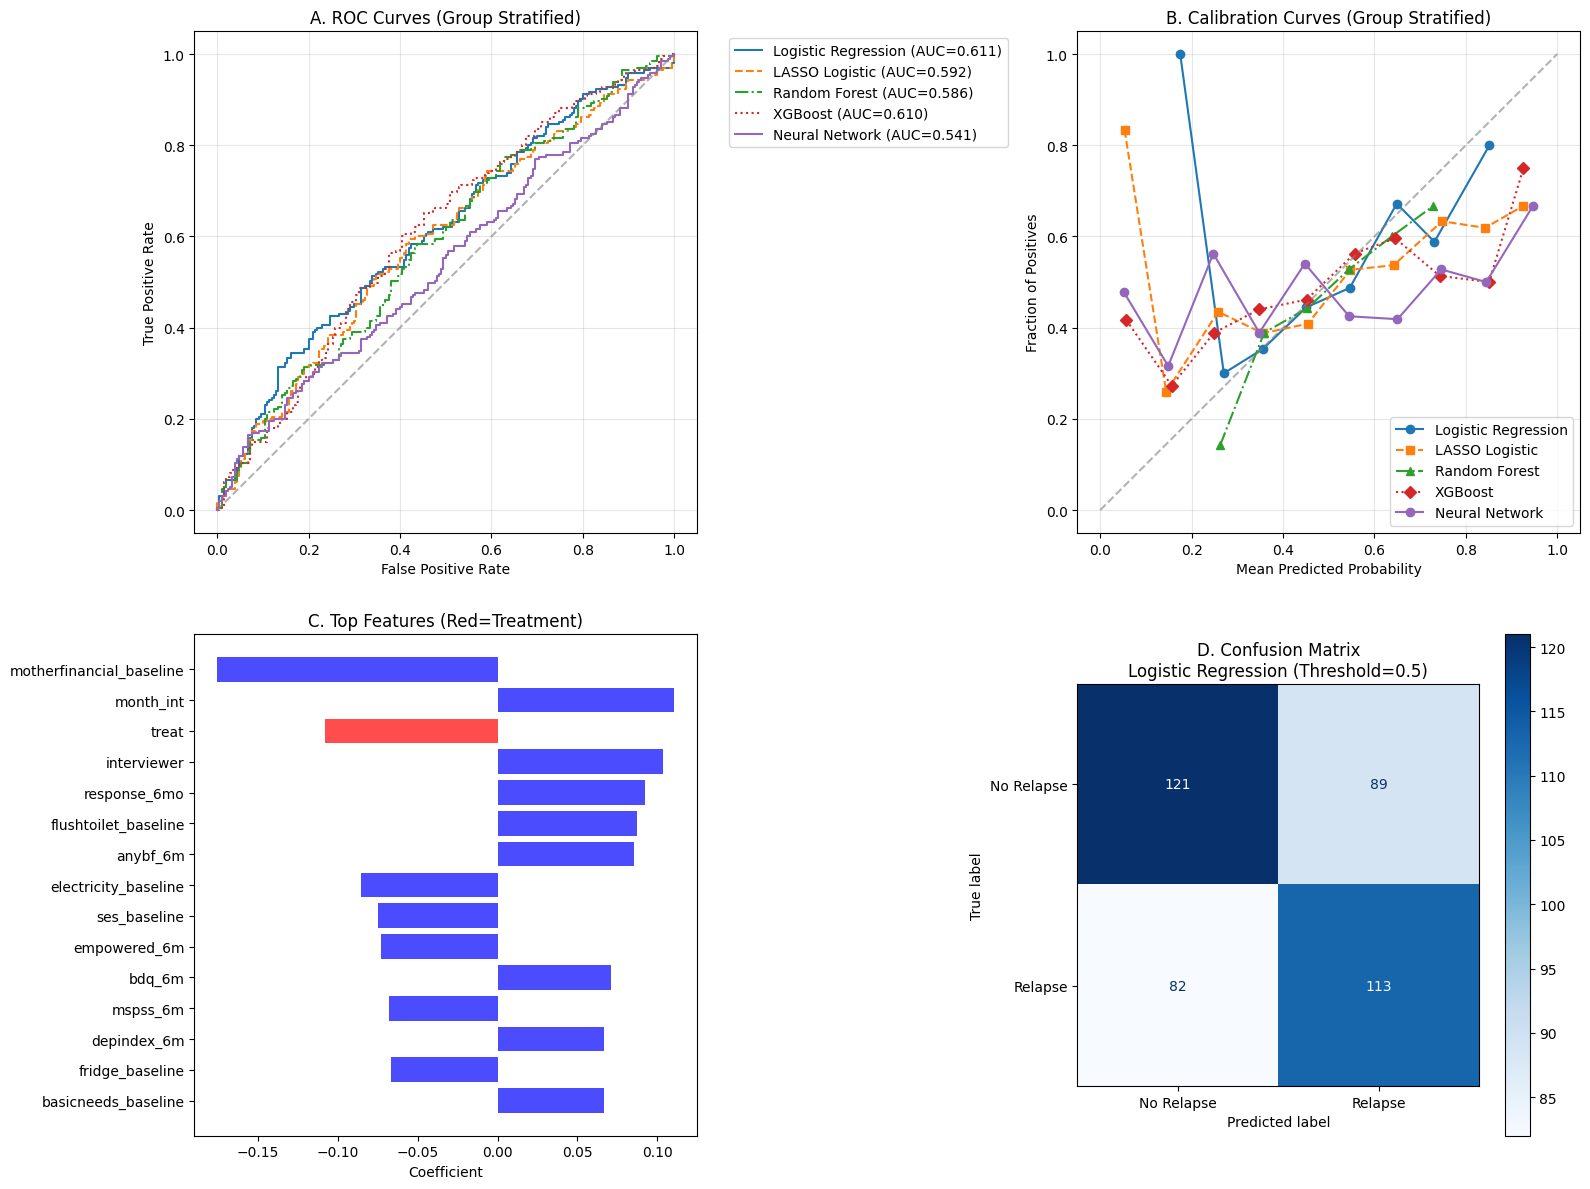

2025-07-29 17:11:40,204 - INFO - Refitted best: Logistic Regression
2025-07-29 17:11:40,215 - INFO - Calibration on train completed


Spearman correlation between calibrated and uncalibrated probabilities: 0.6419

Hold-out Performance:
Uncalibrated: AUC=0.580, F1=0.629
Calibrated:   AUC=0.724, F1=0.698


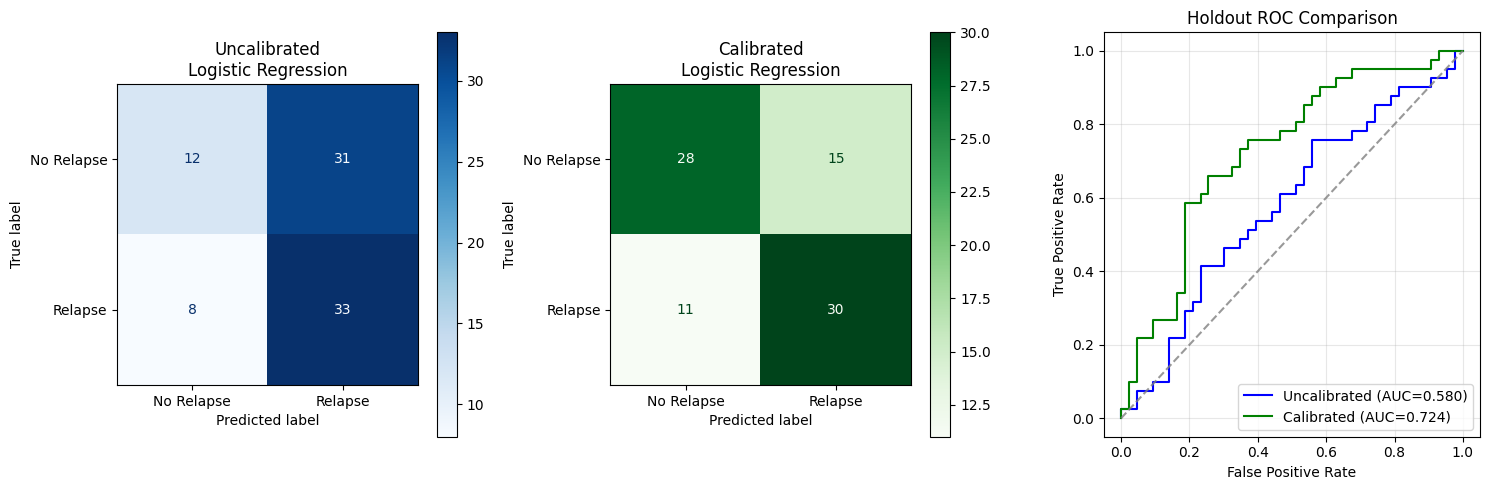

2025-07-29 17:11:40,437 - INFO - Performing SHAP analysis...
2025-07-29 17:11:40,438 - INFO - Treatment variable included in SHAP: True



Detailed Holdout Metrics:
Metric          Uncalibrated Calibrated  
---------------------------------------
Accuracy        0.536        0.690       
Precision       0.516        0.667       
Recall          0.805        0.732       
F1 Score        0.629        0.698       
AUC             0.580        0.724       
Specificity     0.279        0.651       
Sensitivity     0.805        0.732       

Confusion Matrix Components:
Component       Uncalibrated Calibrated  
---------------------------------------
True Positives  33           30          
False Positives 31           15          
True Negatives  12           28          
False Negatives 8            11          


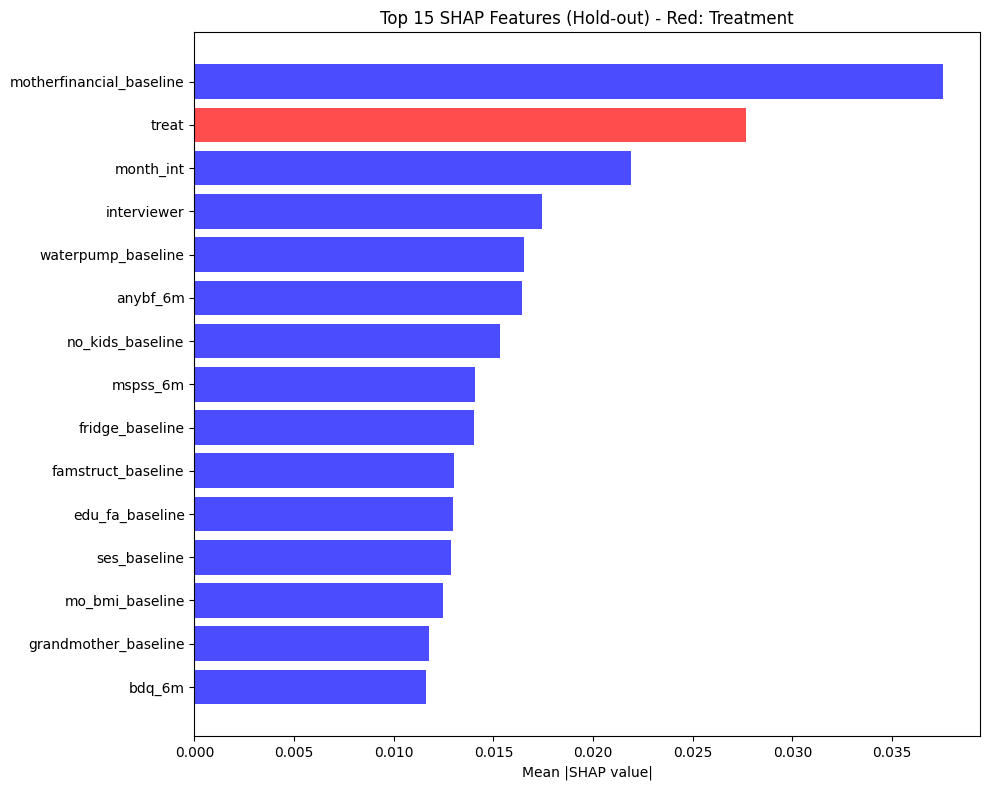

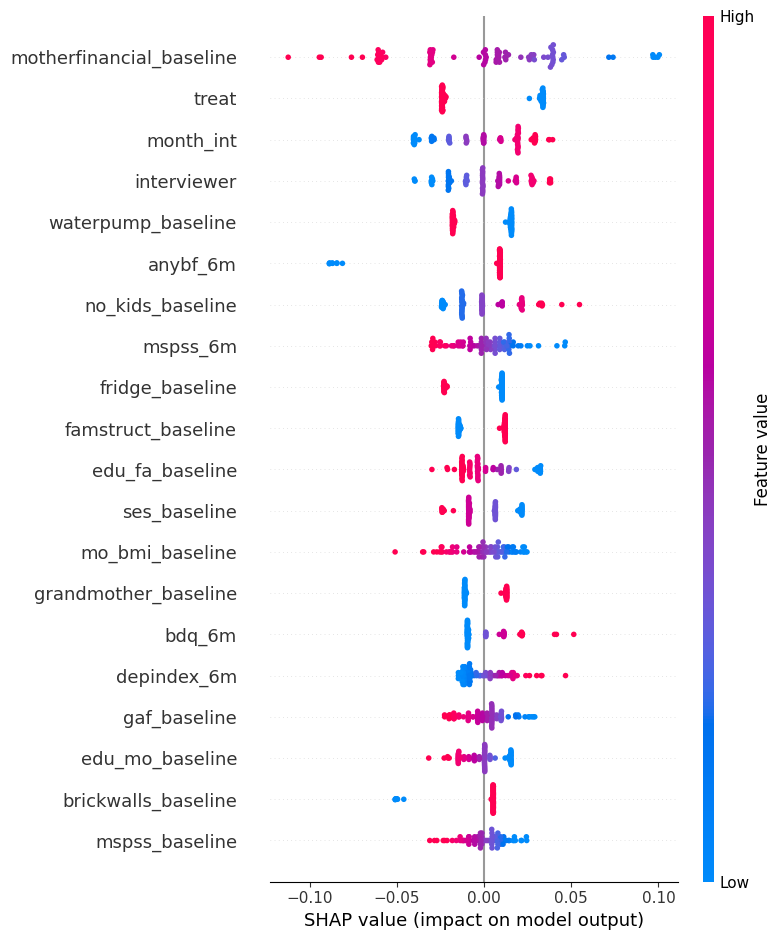


Generating SHAP Personas...
Top 3 SHAP features: ['month_int', 'treat', 'motherfinancial_baseline']

Top-3 SHAP Personas:
                                                    Profile  P(relapse)
   month_int=low & treat=low & motherfinancial_baseline=low       0.590
  month_int=low & treat=low & motherfinancial_baseline=high       0.381
  month_int=low & treat=high & motherfinancial_baseline=low       0.550
 month_int=low & treat=high & motherfinancial_baseline=high       0.342
  month_int=high & treat=low & motherfinancial_baseline=low       0.650
 month_int=high & treat=low & motherfinancial_baseline=high       0.444
 month_int=high & treat=high & motherfinancial_baseline=low       0.612
month_int=high & treat=high & motherfinancial_baseline=high       0.404


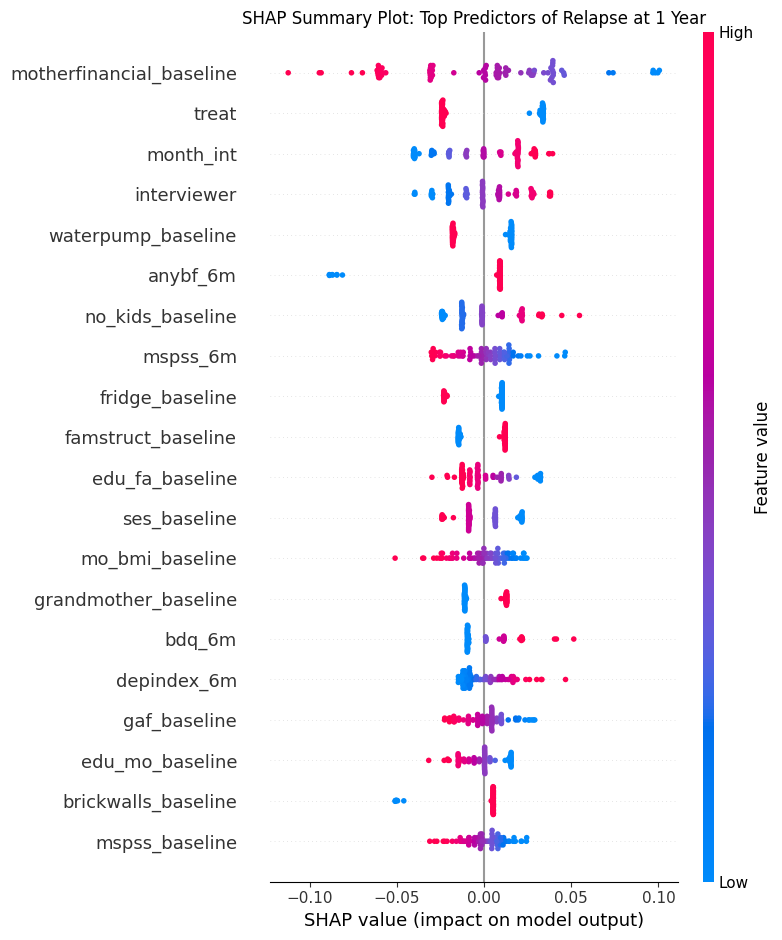

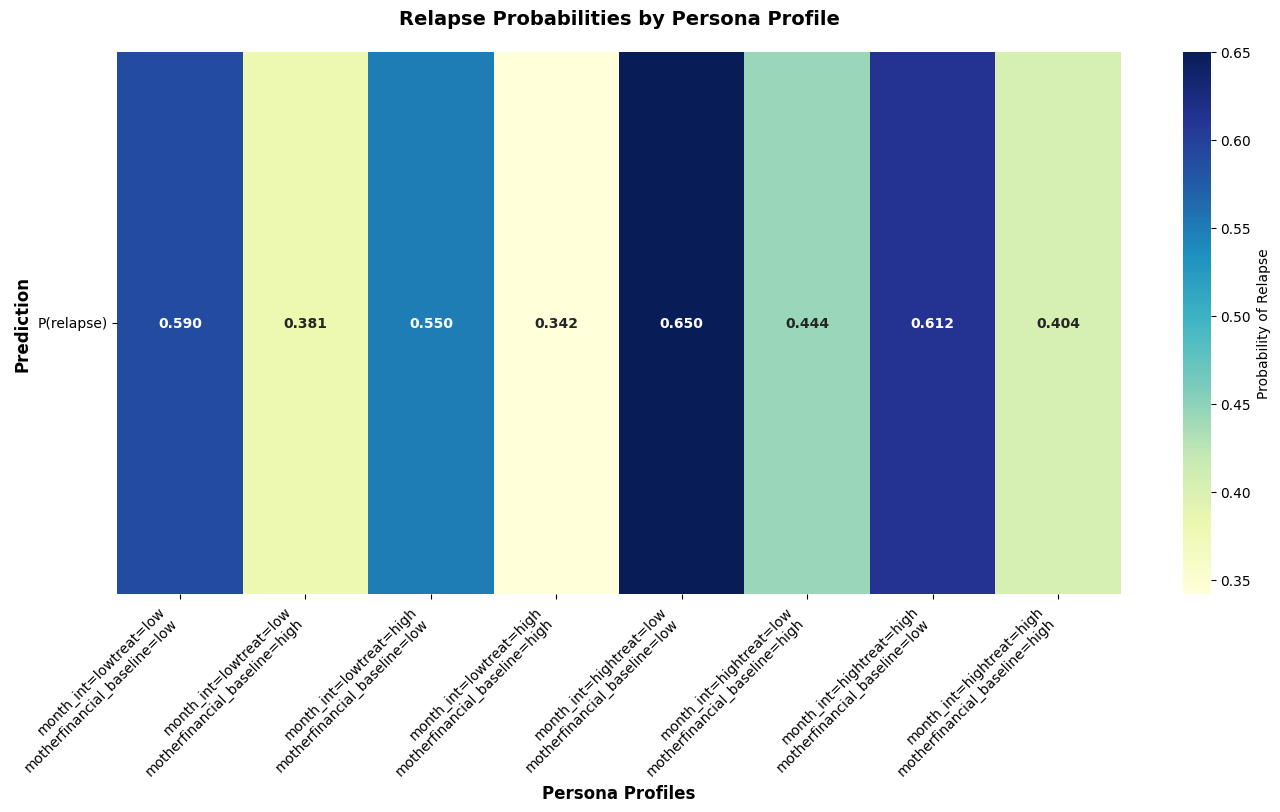


Debugging - Horizontal bar chart data:
Original proto_df:
                                             Profile  P(relapse)
0  month_int=low & treat=low & motherfinancial_ba...       0.590
1  month_int=low & treat=low & motherfinancial_ba...       0.381
2  month_int=low & treat=high & motherfinancial_b...       0.550
3  month_int=low & treat=high & motherfinancial_b...       0.342
4  month_int=high & treat=low & motherfinancial_b...       0.650
5  month_int=high & treat=low & motherfinancial_b...       0.444
6  month_int=high & treat=high & motherfinancial_...       0.612
7  month_int=high & treat=high & motherfinancial_...       0.404

Sorted data for horizontal chart:
                                             Profile  P(relapse)
3  month_int=low & treat=high & motherfinancial_b...       0.342
1  month_int=low & treat=low & motherfinancial_ba...       0.381
7  month_int=high & treat=high & motherfinancial_...       0.404
5  month_int=high & treat=low & motherfinancial_b...       0.

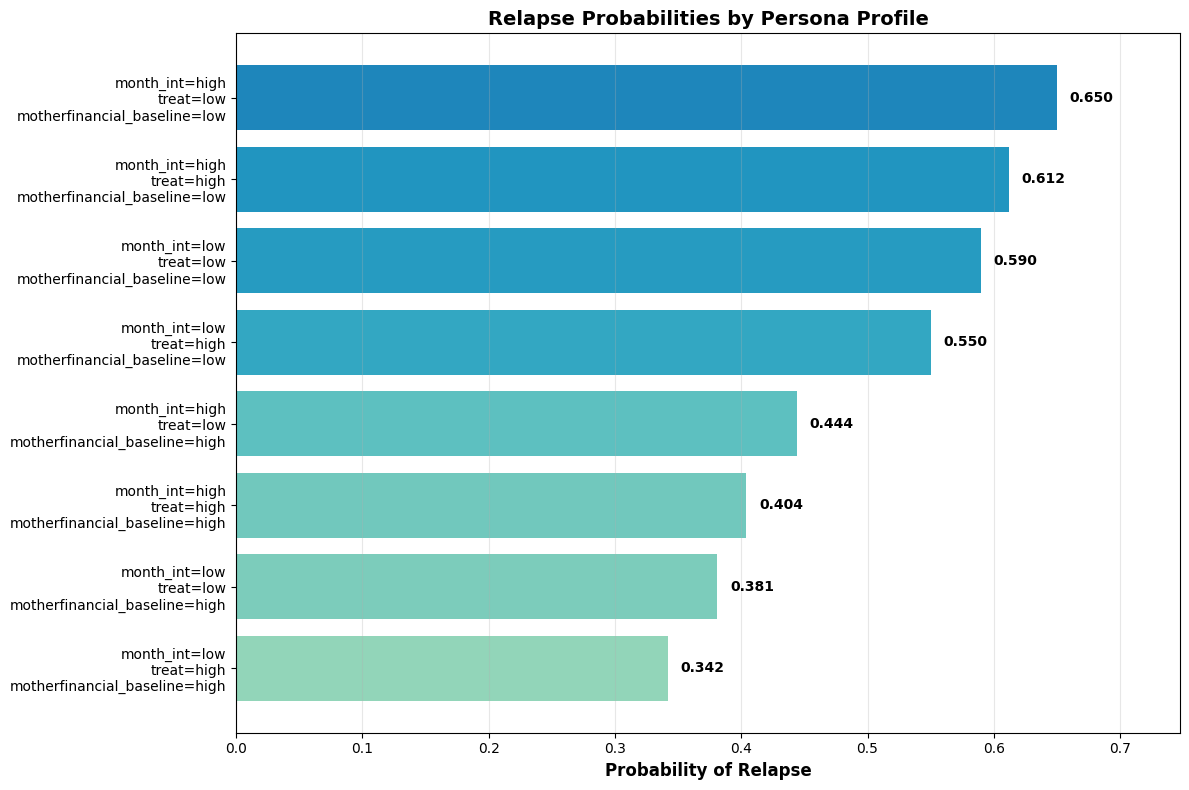

In [106]:
# Relapse at 1 year - no SMOTE, no univariate selection, cluster-stratified CV

# ========= Imports =========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import tensorflow as tf 
import logging
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GroupKFold, StratifiedGroupKFold
from skopt import BayesSearchCV

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from tabulate import tabulate
from itertools import product
import warnings
warnings.filterwarnings("ignore")

# ========= Configuration =========
@dataclass
class Config:
    RANDOM_STATE: int = 123
    N_FEATURES: int = 15
    OUTER_SPLITS: int = 5
    INNER_SPLITS: int = 3
    N_ITER: int = 20
    TEST_SIZE: float = 0.2
    TARGET_COL: str = "relapse_1y"
    CLUSTER_COL: str = "uc"  # cluster column for stratification
    ID_COL: str = "newid"
    EXCLUDE_COLS: List[str] = None
    MIN_CLUSTER_SIZE: int = 2  # Minimum samples per cluster for valid splits
    
    def __post_init__(self):
        if self.EXCLUDE_COLS is None:
            self.EXCLUDE_COLS = ["relapse_1y", "remission_6mo", "depressed_6m", "uc"]  # Exclude cluster from features

config = Config()

# ========= Logging Setup =========
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ========= Data Validation =========
def validate_data(df: pd.DataFrame, target_col: str, cluster_col: str, required_cols: List[str]) -> None:
    """Validate input data quality"""
    assert not df.empty, "DataFrame is empty"
    assert target_col in df.columns, f"Target column '{target_col}' not found"
    assert cluster_col in df.columns, f"Cluster column '{cluster_col}' not found"
    
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    assert df[target_col].nunique() > 1, "Target has only one class"
    
    # Validate cluster distribution
    cluster_sizes = df[cluster_col].value_counts()
    min_cluster_size = cluster_sizes.min()
    logger.info(f"Data validation passed. Shape: {df.shape}")
    logger.info(f"Clusters: {sorted(df[cluster_col].unique())}")
    logger.info(f"Cluster sizes: min={min_cluster_size}, max={cluster_sizes.max()}, mean={cluster_sizes.mean():.1f}")
    logger.info(f"Target distribution: {df[target_col].value_counts().to_dict()}")
    
    if min_cluster_size < config.MIN_CLUSTER_SIZE:
        logger.warning(f"Some clusters have <{config.MIN_CLUSTER_SIZE} samples, which may cause CV issues")

def validate_cluster_separation(train_clusters: np.ndarray, test_clusters: np.ndarray, 
                              fold_num: int = None) -> bool:
    """Validate that train and test clusters are completely separated"""
    train_set = set(train_clusters)
    test_set = set(test_clusters)
    overlap = train_set & test_set
    
    if overlap:
        logger.error(f"Fold {fold_num}: Cluster overlap detected: {overlap}")
        return False
    
    logger.info(f"Fold {fold_num}: Cluster separation validated. "
                f"Train clusters: {len(train_set)}, Test clusters: {len(test_set)}")
    return True

# ========= FIXED: Stratified Group Train/Test Split =========
def create_stratified_group_split(df: pd.DataFrame, target_col: str, cluster_col: str, 
                                test_size: float, random_state: int) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Create train/test split that maintains complete cluster separation while balancing target distribution
    """
    np.random.seed(random_state)
    
    # Calculate target distribution within each cluster
    cluster_stats = df.groupby(cluster_col)[target_col].agg(['count', 'mean']).reset_index()
    cluster_stats['target_ratio'] = cluster_stats['mean']
    cluster_stats = cluster_stats.sort_values('target_ratio')
    
    logger.info(f"Cluster target distribution:\n{cluster_stats}")
    
    # Stratified sampling of clusters based on target ratio
    total_clusters = len(cluster_stats)
    n_test_clusters = max(1, int(total_clusters * test_size))
    
    # Divide clusters into strata based on target ratio quartiles
    cluster_stats['stratum'] = pd.qcut(cluster_stats['target_ratio'], 
                                     q=min(4, total_clusters), 
                                     labels=False, 
                                     duplicates='drop')
    
    test_clusters = []
    for stratum in cluster_stats['stratum'].unique():
        stratum_clusters = cluster_stats[cluster_stats['stratum'] == stratum][cluster_col].values
        n_from_stratum = max(1, int(len(stratum_clusters) * test_size))
        selected = np.random.choice(stratum_clusters, n_from_stratum, replace=False)
        test_clusters.extend(selected)
    
    # Ensure we have the right number of test clusters
    if len(test_clusters) < n_test_clusters:
        remaining_clusters = cluster_stats[~cluster_stats[cluster_col].isin(test_clusters)][cluster_col].values
        additional = np.random.choice(remaining_clusters, 
                                    n_test_clusters - len(test_clusters), 
                                    replace=False)
        test_clusters.extend(additional)
    elif len(test_clusters) > n_test_clusters:
        test_clusters = np.random.choice(test_clusters, n_test_clusters, replace=False)
    
    test_clusters = list(test_clusters)
    train_clusters = [c for c in df[cluster_col].unique() if c not in test_clusters]
    
    # Create splits
    train_df = df[df[cluster_col].isin(train_clusters)].copy()
    test_df = df[df[cluster_col].isin(test_clusters)].copy()
    
    # Validate separation
    if not validate_cluster_separation(train_df[cluster_col].values, test_df[cluster_col].values, "HOLDOUT"):
        raise ValueError("Failed to create properly separated train/test split")
    
    # Log distributions
    logger.info(f"Train: {len(train_df)} samples, {len(train_clusters)} clusters")
    logger.info(f"Test: {len(test_df)} samples, {len(test_clusters)} clusters")
    logger.info(f"Train target dist: {train_df[target_col].value_counts().to_dict()}")
    logger.info(f"Test target dist: {test_df[target_col].value_counts().to_dict()}")
    
    return train_df, test_df

# ========= FIXED: Custom CV Class with Proper Validation =========
class ValidatedGroupKFold:
    """
    GroupKFold wrapper with validation and fallback mechanisms
    """
    def __init__(self, n_splits: int = 5, shuffle: bool = True, random_state: int = None):
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state
        self.group_kfold = GroupKFold(n_splits=n_splits)
    
    def split(self, X, y, groups):
        """Generate validated group-based splits"""
        if groups is None:
            raise ValueError("Groups cannot be None for GroupKFold")
        
        # Convert to numpy arrays for consistency
        if hasattr(X, 'shape'):
            n_samples = X.shape[0]
        else:
            n_samples = len(X)
        
        y = np.asarray(y)
        groups = np.asarray(groups)
        
        # Check if we have enough unique groups
        unique_groups = np.unique(groups)
        if len(unique_groups) < self.n_splits:
            logger.warning(f"Only {len(unique_groups)} groups for {self.n_splits} splits. "
                         f"Falling back to StratifiedKFold")
            skf = StratifiedKFold(n_splits=min(self.n_splits, len(unique_groups)), 
                                shuffle=self.shuffle, random_state=self.random_state)
            yield from skf.split(X, y)
            return
        
        # Use StratifiedGroupKFold for better target distribution balance
        try:
            sgkf = StratifiedGroupKFold(n_splits=self.n_splits, shuffle=self.shuffle, 
                                      random_state=self.random_state)
            splits = list(sgkf.split(X, y, groups))
        except (ValueError, Exception) as e:
            logger.warning(f"StratifiedGroupKFold failed: {e}. Falling back to GroupKFold")
            splits = list(self.group_kfold.split(X, y, groups))
        
        # Validate each split
        valid_splits = []
        for fold_idx, (train_idx, test_idx) in enumerate(splits):
            train_groups = groups[train_idx]
            test_groups = groups[test_idx]
            
            # Validate cluster separation
            if validate_cluster_separation(train_groups, test_groups, fold_idx + 1):
                # Additional validation: ensure both train and test have samples
                if len(train_idx) > 0 and len(test_idx) > 0:
                    # Check target distribution in both sets
                    train_targets = y[train_idx]
                    test_targets = y[test_idx]
                    
                    if len(np.unique(train_targets)) > 1 and len(np.unique(test_targets)) > 1:
                        valid_splits.append((train_idx, test_idx))
                        logger.info(f"Fold {fold_idx + 1}: Train={len(train_idx)}, Test={len(test_idx)}, "
                                  f"Train target ratio={train_targets.mean():.3f}, "
                                  f"Test target ratio={test_targets.mean():.3f}")
                    else:
                        logger.warning(f"Fold {fold_idx + 1}: Insufficient target diversity, skipping")
                else:
                    logger.warning(f"Fold {fold_idx + 1}: Empty train or test set, skipping")
            else:
                logger.warning(f"Fold {fold_idx + 1}: Failed cluster separation validation, skipping")
        
        if len(valid_splits) < 2:
            raise ValueError(f"Only {len(valid_splits)} valid folds generated, need at least 2")
        
        logger.info(f"Generated {len(valid_splits)} valid folds out of {len(splits)} attempted")
        yield from valid_splits
    
    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

# ========= FIXED: Simple Pipeline Builder =========
def build_simple_pipeline(base_model, config: Config):
    """Build a simple pipeline with only preprocessing and model"""
    pipeline = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('model', base_model)
    ])
    return pipeline

# ========= FIXED: Nested CV with Proper GroupKFold =========
def run_nested_cv_group_stratified(model, param_distributions: Dict, X: pd.DataFrame, y: np.ndarray, 
                                  groups: np.ndarray, config: Config) -> Dict[str, Any]:
    """
    FIXED: Nested CV with proper GroupKFold implementation
    """
    # Initialize CV splitters
    outer_cv = ValidatedGroupKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                                  random_state=config.RANDOM_STATE)
    inner_cv = ValidatedGroupKFold(n_splits=config.INNER_SPLITS, shuffle=True, 
                                  random_state=config.RANDOM_STATE + 1)

    # Convert DataFrame to numpy for consistent indexing
    X_values = X.values if hasattr(X, 'values') else X
    y = np.asarray(y)
    groups = np.asarray(groups)
    
    # Initialize results arrays
    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    outer_scores = []
    successful_folds = 0
    treatment_scores = []

    try:
        # Generate outer CV splits
        outer_splits = list(outer_cv.split(X_values, y, groups))
        logger.info(f"Generated {len(outer_splits)} outer CV folds")
        
        for fold, (train_idx, test_idx) in enumerate(outer_splits):
            logger.info(f"Processing outer fold {fold + 1}/{len(outer_splits)}")
            
            try:
                # Extract fold data
                X_train_fold = X.iloc[train_idx] if hasattr(X, 'iloc') else X_values[train_idx]
                y_train_fold = y[train_idx]
                groups_train_fold = groups[train_idx]
                X_test_fold = X.iloc[test_idx] if hasattr(X, 'iloc') else X_values[test_idx]
                y_test_fold = y[test_idx]

                # Log fold statistics
                logger.info(f"Fold {fold+1}: Train={len(train_idx)}, Test={len(test_idx)}")
                if hasattr(X, 'columns') and 'treat' in X.columns:
                    treat_col_idx = X.columns.get_loc('treat')
                    if hasattr(X, 'iloc'):
                        treat_dist = X.iloc[train_idx, treat_col_idx].value_counts()
                    else:
                        treat_dist = pd.Series(X_values[train_idx, treat_col_idx]).value_counts()
                    logger.info(f"Fold {fold+1} treatment distribution: {treat_dist.to_dict()}")

                # Build pipeline
                pipe = build_simple_pipeline(model, config)
                
                # FIXED: Properly configure BayesSearchCV with explicit CV
                search_space = {f'model__{k}': v for k, v in param_distributions.items()}
                
                # Generate inner CV splits for this fold
                try:
                    inner_splits = list(inner_cv.split(X_train_fold, y_train_fold, groups_train_fold))
                    logger.info(f"Fold {fold+1}: Generated {len(inner_splits)} inner CV splits")
                except Exception as e:
                    logger.warning(f"Fold {fold+1}: Inner CV failed: {e}. Using 3-fold StratifiedKFold")
                    inner_splits = list(StratifiedKFold(n_splits=3, shuffle=True, 
                                                      random_state=config.RANDOM_STATE).split(X_train_fold, y_train_fold))
                
                search = BayesSearchCV(
                    pipe,
                    search_spaces=search_space,
                    n_iter=config.N_ITER,
                    scoring='roc_auc',
                    cv=inner_splits,  # FIXED: Pass list of splits, not generator
                    n_jobs=1,
                    random_state=config.RANDOM_STATE,
                    error_score='raise'
                )
                
                # Fit hyperparameter search
                if hasattr(X_train_fold, 'values'):
                    search.fit(X_train_fold, y_train_fold)
                else:
                    # Convert back to DataFrame for proper feature handling
                    X_train_df = pd.DataFrame(X_train_fold, columns=X.columns)
                    search.fit(X_train_df, y_train_fold)
                
                best_model = search.best_estimator_

                # Extract treatment information
                model_obj = best_model.named_steps['model']
                treat_info = {'fold': fold + 1, 'treat_coef': 0, 'treat_importance': 0}
                
                if hasattr(model_obj, 'coef_') and hasattr(X, 'columns') and 'treat' in X.columns:
                    treat_idx = X.columns.get_loc('treat')
                    treat_coef = model_obj.coef_[0][treat_idx]
                    treat_info['treat_coef'] = treat_coef
                    logger.info(f"Fold {fold+1}: Treatment coefficient = {treat_coef:.3f}")
                elif hasattr(model_obj, 'feature_importances_') and hasattr(X, 'columns') and 'treat' in X.columns:
                    treat_idx = X.columns.get_loc('treat')
                    treat_importance = model_obj.feature_importances_[treat_idx]
                    treat_info['treat_importance'] = treat_importance
                    logger.info(f"Fold {fold+1}: Treatment importance = {treat_importance:.3f}")
                
                treatment_scores.append(treat_info)

                # Make predictions
                if hasattr(X_test_fold, 'values'):
                    prob = best_model.predict_proba(X_test_fold)[:, 1]
                else:
                    X_test_df = pd.DataFrame(X_test_fold, columns=X.columns)
                    prob = best_model.predict_proba(X_test_df)[:, 1]
                
                pred = (prob > 0.5).astype(int)
                
                # Store results
                y_probs[test_idx] = prob
                y_preds[test_idx] = pred
                auc_score = roc_auc_score(y_test_fold, prob)
                outer_scores.append(auc_score)
                successful_folds += 1
                
                logger.info(f"Fold {fold+1} AUC: {auc_score:.3f}")
                
            except Exception as e:
                logger.error(f"Error in fold {fold + 1}: {e}")
                # For failed folds, use neutral predictions
                y_probs[test_idx] = 0.5
                y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
                outer_scores.append(0.5)

    except Exception as e:
        logger.error(f"Critical error in nested CV: {e}")
        raise

    # Validate results
    if successful_folds < max(1, config.OUTER_SPLITS // 2):
        raise RuntimeError(f"Too many folds failed: {successful_folds}/{len(outer_splits)}")

    # Calculate metrics on valid predictions only
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    # Log treatment importance summary
    if treatment_scores:
        avg_treat_coef = np.mean([t.get('treat_coef', 0) for t in treatment_scores])
        avg_treat_importance = np.mean([t.get('treat_importance', 0) for t in treatment_scores])
        logger.info(f"Average treatment coefficient: {avg_treat_coef:.3f}")
        logger.info(f"Average treatment importance: {avg_treat_importance:.3f}")

    return {
        "model": search.best_estimator_ if 'search' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(outer_scores),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": 0,  # Legacy compatibility
        "treatment_scores": treatment_scores
    }

# ========= FIXED: Neural Network CV =========
def run_nn_cv_group_stratified(X: pd.DataFrame, y: np.ndarray, groups: np.ndarray, config: Config) -> Dict[str, Any]:
    """FIXED: Neural network CV with proper GroupKFold"""
    outer_cv = ValidatedGroupKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                                  random_state=config.RANDOM_STATE)
    
    # Convert to numpy for consistent indexing
    X_values = X.values if hasattr(X, 'values') else X
    y = np.asarray(y)
    groups = np.asarray(groups)
    
    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    aucs = []
    successful_folds = 0
    feature_names = X.columns.tolist() if hasattr(X, 'columns') else None
    treatment_scores = []

    try:
        outer_splits = list(outer_cv.split(X_values, y, groups))
        logger.info(f"NN: Generated {len(outer_splits)} outer CV folds")
        
        for fold, (train_idx, test_idx) in enumerate(outer_splits):
            logger.info(f"Processing NN fold {fold + 1}/{len(outer_splits)}")
            
            try:
                # Extract fold data
                X_train_fold = X.iloc[train_idx] if hasattr(X, 'iloc') else X_values[train_idx]
                y_train_fold = y[train_idx]
                X_test_fold = X.iloc[test_idx] if hasattr(X, 'iloc') else X_values[test_idx]
                y_test_fold = y[test_idx]

                # Apply preprocessing
                imputer = SimpleImputer(strategy='median')
                scaler = StandardScaler()
                
                X_train_processed = imputer.fit_transform(X_train_fold)
                X_train_scaled = scaler.fit_transform(X_train_processed)
                
                logger.info(f"NN Fold {fold+1}: Training on {len(X_train_scaled)} samples, "
                           f"class distribution: {np.bincount(y_train_fold)}")

                # Track treatment info
                treat_info = {'fold': fold + 1, 'treat_coef': 0, 'treat_importance': 0}
                treatment_scores.append(treat_info)
                
                # Build and train model
                model = build_nn_model(input_dim=X_train_scaled.shape[1])
                
                # Compute class weights
                unique_classes = np.unique(y_train_fold)
                if len(unique_classes) > 1:
                    cw_vals = compute_class_weight('balanced', classes=unique_classes, y=y_train_fold)
                    class_weights = {i: w for i, w in enumerate(cw_vals)}
                else:
                    class_weights = None
                
                batch_size = max(8, min(32, len(X_train_scaled) // 4))
                
                model.fit(
                    X_train_scaled, y_train_fold,
                    validation_split=0.2,
                    epochs=100,
                    batch_size=batch_size,
                    callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
                    class_weight=class_weights,
                    verbose=0
                )

                # Transform test data and predict
                X_test_processed = imputer.transform(X_test_fold)
                X_test_scaled = scaler.transform(X_test_processed)
                
                prob = model.predict(X_test_scaled, verbose=0).ravel()
                pred = (prob > 0.5).astype(int)
                
                y_probs[test_idx] = prob
                y_preds[test_idx] = pred
                auc_score = roc_auc_score(y_test_fold, prob)
                aucs.append(auc_score)
                successful_folds += 1
                
                logger.info(f"NN Fold {fold+1} AUC: {auc_score:.3f}")
                
            except Exception as e:
                logger.error(f"Error in NN fold {fold + 1}: {e}")
                y_probs[test_idx] = 0.5
                y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
                aucs.append(0.5)

    except Exception as e:
        logger.error(f"Critical error in NN CV: {e}")
        raise

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid NN predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    logger.info(f"NN: Completed {successful_folds}/{len(outer_splits)} folds")

    return {
        "model": model if 'model' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(aucs),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": 0,
        "treatment_scores": treatment_scores
    }

# ========= Leak-Free Preprocessor (No changes needed) =========
class LeakFreePreprocessor:
    """Preprocessing that prevents data leakage by fitting only on training folds"""
    
    def __init__(self, config: Config):
        self.config = config
        self.imputer = None
        self.scaler = None
        self.label_encoder = None
        self.feature_names = None
        
    def fit(self, X: pd.DataFrame, y: pd.Series) -> 'LeakFreePreprocessor':
        """Fit preprocessor components separately to allow proper CV"""
        self.feature_names = X.columns.tolist()
        
        # Fit components
        self.imputer = SimpleImputer(strategy='median')
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        
        # Fit on training data
        X_imputed = self.imputer.fit_transform(X)
        self.scaler.fit(X_imputed)
        self.label_encoder.fit(y)
        
        logger.info(f"Preprocessor fitted on {X.shape[0]} samples, {X.shape[1]} features")
        return self
    
    def transform_features(self, X):
        """Transform features using fitted preprocessor"""
        if isinstance(X, pd.DataFrame):
            X_ordered = X.reindex(columns=self.feature_names, fill_value=np.nan)
            X_values = X_ordered.values
        else:
            X_values = X
            
        X_imputed = self.imputer.transform(X_values)
        X_scaled = self.scaler.transform(X_imputed)
        return X_scaled
    
    def transform_target(self, y: pd.Series) -> np.ndarray:
        """Transform target using fitted label encoder"""
        return self.label_encoder.transform(y)
    
    def get_feature_names(self) -> List[str]:
        """Get original feature names"""
        return self.feature_names.copy()

# ========= Neural Network Builder (No changes) =========
def build_nn_model(input_dim: int, neurons1: int = 64, neurons2: int = 32, 
                   dropout: float = 0.3, learning_rate: float = 1e-3) -> tf.keras.Model:
    """Build neural network with improved architecture"""
    model = Sequential([
        Dense(neurons1, activation='relu', input_dim=input_dim,
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(neurons2, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model

# ========= Utility Functions =========
def calculate_holdout_metrics(y_true: np.ndarray, y_pred: np.ndarray, 
                            y_proba: np.ndarray) -> Dict[str, float]:
    """Calculate comprehensive holdout metrics including confusion matrix components"""
    cm = confusion_matrix(y_true, y_pred)
    
    # Extract confusion matrix components
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true, y_proba),
        'Brier Score': brier_score_loss(y_true, y_proba),
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0
    }

# ========= Enhanced plot_performance_curves Function =========
def plot_performance_curves(results: Dict, y_true: np.ndarray, feature_names, title_suffix: str = "", threshold: float = 0.5):
    """Generate annotated ROC, calibration curves, feature importance, and confusion matrix with enhanced readability."""
    import matplotlib.pyplot as plt
    import numpy as np
    from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
    from sklearn.calibration import calibration_curve

    plt.figure(figsize=(16, 12))
    line_styles = ['-', '--', '-.', ':']
    markers = ['o', 's', '^', 'D']
    colors = plt.cm.tab10.colors
    model_names = list(results.keys())

    # ROC Curves
    plt.subplot(2, 2, 1)
    for idx, name in enumerate(model_names):
        res = results[name]
        if res and 'y_probs' in res:
            valid_mask = res['y_probs'] >= 0
            if np.any(valid_mask):
                y_valid = y_true[valid_mask]
                probs_valid = res['y_probs'][valid_mask]
                fpr, tpr, _ = roc_curve(y_valid, probs_valid)
                auc = roc_auc_score(y_valid, probs_valid)
                label = f"{name} (AUC={auc:.3f})"
                plt.plot(fpr, tpr, label=label,
                         linestyle=line_styles[idx % len(line_styles)],
                         color=colors[idx % len(colors)])
    plt.plot([0, 1], [0, 1], '--', color='gray', alpha=0.6)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"A. ROC Curves {title_suffix}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)

    # Calibration Curves
    plt.subplot(2, 2, 2)
    for idx, name in enumerate(model_names):
        res = results[name]
        if res and 'y_probs' in res:
            valid_mask = res['y_probs'] >= 0
            if np.any(valid_mask):
                y_valid = y_true[valid_mask]
                probs_valid = res['y_probs'][valid_mask]
                frac_pos, mean_pred = calibration_curve(y_valid, probs_valid, n_bins=10)
                plt.plot(mean_pred, frac_pos,
                         marker=markers[idx % len(markers)],
                         linestyle=line_styles[idx % len(line_styles)],
                         color=colors[idx % len(colors)],
                         label=name)
    plt.plot([0, 1], [0, 1], '--', color='gray', alpha=0.6)
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title(f"B. Calibration Curves {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Feature Importance
    plt.subplot(2, 2, 3)
    try:
        best_model_name = max(results.keys(), key=lambda k: results[k]['metrics']['AUC'] if results[k] else 0)
        best_model = results[best_model_name]['model']
        if hasattr(best_model, 'named_steps'):
            model_obj = best_model.named_steps['model']
            if hasattr(model_obj, 'coef_'):
                coeffs = model_obj.coef_[0]
                top_idx = np.argsort(np.abs(coeffs))[-15:]
                top_feats = [feature_names[i] for i in top_idx]
                colors_bar = ['red' if feat == 'treat' else 'blue' for feat in top_feats]
                plt.barh(range(len(top_idx)), coeffs[top_idx], color=colors_bar, alpha=0.7)
                plt.yticks(range(len(top_idx)), top_feats)
                plt.xlabel("Coefficient")
                plt.title("C. Top Features (Red=Treatment)")
            elif hasattr(model_obj, 'feature_importances_'):
                importances = model_obj.feature_importances_
                top_idx = np.argsort(importances)[-15:]
                top_feats = [feature_names[i] for i in top_idx]
                colors_bar = ['red' if feat == 'treat' else 'blue' for feat in top_feats]
                plt.barh(range(len(top_idx)), importances[top_idx], color=colors_bar, alpha=0.7)
                plt.yticks(range(len(top_idx)), top_feats)
                plt.xlabel("Importance")
                plt.title("C. Top Features (Red=Treatment)")
            else:
                plt.text(0.5, 0.5, "Feature importance\nnot available",
                         ha='center', va='center', transform=plt.gca().transAxes)
    except Exception as e:
        print(f"Error plotting feature importance: {e}")
        plt.text(0.5, 0.5, "Feature importance\nnot available",
                 ha='center', va='center', transform=plt.gca().transAxes)

    # Confusion Matrix
    plt.subplot(2, 2, 4)
    try:
        res = results[best_model_name]
        valid_mask = res['y_probs'] >= 0
        if np.any(valid_mask):
            y_valid = y_true[valid_mask]
            y_pred_valid = (res['y_probs'][valid_mask] >= threshold).astype(int)
            cm = confusion_matrix(y_valid, y_pred_valid)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Relapse', 'Relapse'])
            disp.plot(ax=plt.gca(), cmap='Blues', values_format='d')
            plt.title(f"D. Confusion Matrix\n{best_model_name} (Threshold={threshold})")
    except Exception as e:
        print(f"Error plotting confusion matrix: {e}")
        plt.text(0.5, 0.5, "Confusion Matrix\nnot available",
                 ha='center', va='center', transform=plt.gca().transAxes)

    plt.tight_layout()
    plt.show()

# ========= Holdout Confusion Matrix Function =========
def plot_holdout_confusion_matrices(y_true, preds_unc, preds_cal, probs_unc, probs_cal, best_name):
    """Plot confusion matrices for holdout predictions"""
    plt.figure(figsize=(15, 5))
    
    # Uncalibrated Confusion Matrix
    plt.subplot(1, 3, 1)
    cm_unc = confusion_matrix(y_true, preds_unc)
    disp_unc = ConfusionMatrixDisplay(confusion_matrix=cm_unc, 
                                     display_labels=['No Relapse', 'Relapse'])
    disp_unc.plot(ax=plt.gca(), cmap='Blues', values_format='d')
    plt.title(f"Uncalibrated\n{best_name}")
    
    # Calibrated Confusion Matrix
    plt.subplot(1, 3, 2)
    cm_cal = confusion_matrix(y_true, preds_cal)
    disp_cal = ConfusionMatrixDisplay(confusion_matrix=cm_cal, 
                                     display_labels=['No Relapse', 'Relapse'])
    disp_cal.plot(ax=plt.gca(), cmap='Greens', values_format='d')
    plt.title(f"Calibrated\n{best_name}")
    
    # ROC Comparison
    plt.subplot(1, 3, 3)
    fpr_unc, tpr_unc, _ = roc_curve(y_true, probs_unc)
    fpr_cal, tpr_cal, _ = roc_curve(y_true, probs_cal)
    
    auc_unc = roc_auc_score(y_true, probs_unc)
    auc_cal = roc_auc_score(y_true, probs_cal)
    
    plt.plot(fpr_unc, tpr_unc, label=f'Uncalibrated (AUC={auc_unc:.3f})', color='blue')
    plt.plot(fpr_cal, tpr_cal, label=f'Calibrated (AUC={auc_cal:.3f})', color='green')
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Holdout ROC Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ========= SHAP Feature Analysis =========
def perform_shap_analysis(best_model, X_holdout: np.ndarray, feature_names: List[str],
                         preprocessor: LeakFreePreprocessor, holdout_raw: pd.DataFrame):
    """Perform SHAP analysis with proper error handling"""
    try:
        logger.info("Performing SHAP analysis...")
        
        model_obj = best_model.named_steps['model']
        if not hasattr(model_obj, 'predict_proba'):
            logger.warning("Model doesn't support probability prediction, skipping SHAP")
            return None
        
        # Use all features - no feature selection
        X_for_shap = X_holdout
        shap_feature_names = feature_names
        
        # Highlight if treatment is included
        treat_included = 'treat' in shap_feature_names
        logger.info(f"Treatment variable included in SHAP: {treat_included}")
        
        n_background = min(100, X_for_shap.shape[0])
        background_data = X_for_shap[:n_background]  # Use this as "features" for SHAP summary plot
        
        if hasattr(model_obj, 'tree_'):
            explainer = shap.TreeExplainer(model_obj)
            shap_values = explainer.shap_values(background_data)
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        else:
            explainer = shap.Explainer(model_obj.predict_proba, background_data)
            shap_values = explainer(background_data)
            if hasattr(shap_values, 'values'):
                shap_values = shap_values.values[:, :, 1]
        
        shap_abs = np.abs(shap_values).mean(axis=0)
        top_n = min(15, len(shap_feature_names))
        top_idx = np.argsort(shap_abs)[-top_n:]
        
        plt.figure(figsize=(10, 8))
        colors = ['red' if shap_feature_names[i] == 'treat' else 'blue' for i in top_idx]
        plt.barh(range(len(top_idx)), shap_abs[top_idx], color=colors, alpha=0.7)
        plt.yticks(range(len(top_idx)), [shap_feature_names[i] for i in top_idx])
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"Top {top_n} SHAP Features (Hold-out) - Red: Treatment")
        plt.tight_layout()
        plt.show()
        
        try:
            shap.summary_plot(
                shap_values, 
                features=background_data, 
                feature_names=shap_feature_names,
                show=False
            )
            plt.tight_layout()
            plt.show()
        except Exception as e:
            logger.warning(f"Error creating SHAP summary plot: {e}")
            
    except Exception as e:
        logger.error(f"Error in SHAP analysis: {e}")
        return None

    return {
    'shap_values': shap_values,
    'feature_names': shap_feature_names,
    'features_used': background_data
}

# ========= UPDATED: Main Pipeline with Fixed GroupKFold =========
def main():
    """UPDATED: Main execution pipeline with fixed GroupKFold implementation"""

    # 1. Load & validate
    try:
        df = imputed_datasets["dat_ml_1y"]
        logger.info(f"Data loaded: {df.shape}")
        required = [config.TARGET_COL, config.CLUSTER_COL, config.ID_COL] + config.EXCLUDE_COLS + ['treat']
        validate_data(df, config.TARGET_COL, config.CLUSTER_COL, required)
    except Exception as e:
        logger.error(f"Loading/validation error: {e}")
        return

    # 2. Quick QC
    logger.info(f"Target counts:\n{df[config.TARGET_COL].value_counts()}")
    logger.info(f"Cluster counts:\n{df[config.CLUSTER_COL].value_counts()}")
    logger.info(f"Missing values: {df.isnull().sum().sum()}")

    # 3. FIXED: Improved cluster-stratified train/hold-out split
    train_df, holdout_df = create_stratified_group_split(
        df, config.TARGET_COL, config.CLUSTER_COL, config.TEST_SIZE, config.RANDOM_STATE
    )
    logger.info(f"Train={len(train_df)}, Hold-out={len(holdout_df)}")

    # 4. Prepare training data (preserve DataFrame structure)
    X_train = train_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    y_train = train_df[config.TARGET_COL].values
    groups_train = train_df[config.CLUSTER_COL].values  # Fixed: use groups instead of clusters
    feature_names = X_train.columns.tolist()
    
    logger.info(f"Training features: {len(feature_names)}")
    logger.info(f"Treatment variable included: {'treat' in feature_names}")
    logger.info(f"Unique groups in training: {len(np.unique(groups_train))}")

    # 5. Define models & parameters
    models_and_params = {
        "Logistic Regression": (
            LogisticRegression(max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.01, 0.1, 1.0, 10.0]}
        ),
        "LASSO Logistic": (
            LogisticRegression(penalty='l1', solver='liblinear',
                               max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.001, 0.01, 0.1, 1, 10]}
        ),
        "Random Forest": (
            RandomForestClassifier(class_weight='balanced',
                                   random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "max_depth": [3, 5, 10],
             "min_samples_split": [5, 10],
             "min_samples_leaf": [2, 5]}
        ),
        "XGBoost": (
            XGBClassifier(use_label_encoder=False,
                          eval_metric='logloss',
                          random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "learning_rate": [0.01, 0.1],
             "max_depth": [3, 6],
             "subsample": [0.8, 1.0]}
        )
    }

    # 6. FIXED: Run nested CV with proper GroupKFold
    results = {}
    for name, (model, params) in models_and_params.items():
        logger.info(f"→ Nested CV: {name}")
        try:
            results[name] = run_nested_cv_group_stratified(
                model, params, X_train, y_train, groups_train, config
            )
            logger.info(f"   AUC={results[name]['metrics']['AUC']:.3f}")
        except Exception as e:
            logger.error(f"   {name} failed: {e}")

    # 7. FIXED: Neural network with GroupKFold
    try:
        logger.info("→ Nested CV: Neural Network")
        results['Neural Network'] = run_nn_cv_group_stratified(X_train, y_train, groups_train, config)
        logger.info(f"   AUC={results['Neural Network']['metrics']['AUC']:.3f}")
    except Exception as e:
        logger.error(f"   NN failed: {e}")

    # 8. Show performance table
    perf_rows = []
    for m, res in results.items():
        if res and 'metrics' in res:
            row = {"Model": m}
            row.update({k: round(v, 3) for k, v in res['metrics'].items()})
            row["Folds"] = res.get('successful_folds', 'N/A')
            perf_rows.append(row)
    
    if not perf_rows:
        logger.error("No successful models to display")
        return
        
    perf_df = pd.DataFrame(perf_rows)
    print("\nNested CV Performance (Group Stratified)")
    print(tabulate(perf_df, headers='keys', tablefmt='grid', showindex=False))

    # 9. Fit preprocessor on full training data
    preprocessor = LeakFreePreprocessor(config)
    preprocessor.fit(X_train, train_df[config.TARGET_COL])
    
    # Transform training data
    X_train_proc = preprocessor.transform_features(X_train)
    y_train_processed = preprocessor.transform_target(train_df[config.TARGET_COL])
    
    logger.info(f"Final training data: {X_train_proc.shape}, class distribution: {np.bincount(y_train_processed)}")

    # 10. Plot OOF performance
    plot_performance_curves(results, y_train, feature_names, title_suffix="(Group Stratified)")

    # 11. Refit best pipeline on full training data
    if not results:
        logger.error("No successful models to select from")
        return

    best_name = max(results, key=lambda k: results[k]['metrics']['AUC'] if results[k] else 0)
    best_result = results[best_name]

    if not best_result or 'model' not in best_result:
        logger.error(f"Best model {best_name} has no trained model")
        return

    # Build and fit new pipeline on full processed data
    best_base_model = models_and_params[best_name][0]
    best_pipe = results[best_name]['model']           
    best_pipe.fit(X_train, y_train)
    logger.info(f"Refitted best: {best_name}")

    # 12. Calibrate via Platt scaling
    calibrator = CalibratedClassifierCV(
        estimator=best_pipe.named_steps['model'],
        method='sigmoid',
        cv=3
    )
    calibrator.fit(X_train_proc, y_train_processed)
    logger.info("Calibration on train completed")

    # 13. Prepare hold-out
    X_hold = holdout_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    X_hold_proc = preprocessor.transform_features(X_hold)
    y_hold = preprocessor.transform_target(holdout_df[config.TARGET_COL])

    # 14. Make predictions
    probs_unc = best_pipe.predict_proba(X_hold_proc)[:,1]
    probs_cal = calibrator.predict_proba(X_hold_proc)[:, 1]

    # Verify calibration preserves ranking
    spearman_corr = pd.Series(probs_unc).corr(pd.Series(probs_cal), method='spearman')
    print(f"Spearman correlation between calibrated and uncalibrated probabilities: {spearman_corr:.4f}")

    # 15. Calculate metrics
    preds_unc = (probs_unc > 0.5).astype(int)
    preds_cal = (probs_cal > 0.5).astype(int)
    hold_unc = calculate_holdout_metrics(y_hold, preds_unc, probs_unc)
    hold_cal = calculate_holdout_metrics(y_hold, preds_cal, probs_cal)

    print(f"\nHold-out Performance:")
    print(f"Uncalibrated: AUC={hold_unc['AUC']:.3f}, F1={hold_unc['F1 Score']:.3f}")
    print(f"Calibrated:   AUC={hold_cal['AUC']:.3f}, F1={hold_cal['F1 Score']:.3f}")

    # Plot holdout results
    plot_holdout_confusion_matrices(y_hold, preds_unc, preds_cal, probs_unc, probs_cal, best_name)
    
    # Print detailed metrics
    print(f"\nDetailed Holdout Metrics:")
    print(f"{'Metric':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC', 'Specificity', 'Sensitivity']:
        print(f"{metric:<15} {hold_unc[metric]:<12.3f} {hold_cal[metric]:<12.3f}")
    
    print(f"\nConfusion Matrix Components:")
    print(f"{'Component':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for component in ['True Positives', 'False Positives', 'True Negatives', 'False Negatives']:
        print(f"{component:<15} {hold_unc[component]:<12} {hold_cal[component]:<12}")

    # 16. SHAP & Personas
    shap_info = perform_shap_analysis(
        best_pipe,
        X_hold_proc,
        feature_names,
        preprocessor,
        holdout_df
    )

    if shap_info and shap_info['shap_values'] is not None:
        sv = shap_info['shap_values']
        feats = shap_info['feature_names']
        abs_mean = np.abs(sv).mean(axis=0)

        if len(feats) >= 3:
            print("\nGenerating SHAP Personas...")
            raw_df = train_df.drop(columns=config.EXCLUDE_COLS + [config.ID_COL])
            raw_median = raw_df.median()
            raw_min = raw_df.min()
            raw_max = raw_df.max()

            X_shap_used = shap_info['features_used']  # same 100 rows used for shap_values

            fig_shap_relapse = plt.figure(figsize=(10, 8))

            shap.summary_plot(
                sv,
                features=X_shap_used,
                feature_names=feats,
                show=False
            )

            plt.title("SHAP Summary Plot: Top Predictors of Relapse at 1 Year")
            plt.tight_layout()
            fig_shap_relapse = plt.gcf()

            # Pick top-3 by |SHAP|
            top3_idx = np.argsort(abs_mean)[-3:]
            top3_feats = [feats[i] for i in top3_idx]

            print(f"Top 3 SHAP features: {top3_feats}")

             # Save components with variant suffix
            variant = "relapse"
            globals().update({
                f"shap_values_{variant}": sv,
                f"X_{variant}": X_shap_used,
                f"fig_shap_{variant}": fig_shap_relapse,
                f"feature_names_{variant}": feats
            })
            
            # Create pipeline for personas
            class PersonaPipeline:
                def __init__(self, preprocessor, calibrator):
                    self.preprocessor = preprocessor
                    self.calibrator = calibrator
                
                def predict_proba(self, X_raw):
                    X_proc = self.preprocessor.transform_features(X_raw)
                    return self.calibrator.predict_proba(X_proc)
            
            final_pipe = PersonaPipeline(preprocessor, calibrator)
            
            prototypes = []
            for combo in product(['low','high'], repeat=3):
                row = raw_median.copy()
                desc = []
                for feat, lvl in zip(top3_feats, combo):
                    row[feat] = raw_min[feat] if lvl=='low' else raw_max[feat]
                    desc.append(f"{feat}={lvl}")
                
                arr_df = pd.DataFrame([row.reindex(feature_names)])
                try:
                    p = final_pipe.predict_proba(arr_df)[0,1]
                    prototypes.append({
                        'Profile': ' & '.join(desc),
                        'P(relapse)': round(p, 3)
                    })
                except Exception as e:
                    logger.warning(f"Error generating persona for {desc}: {e}")
            
            if prototypes:
                proto_df = pd.DataFrame(prototypes)
                print("\nTop-3 SHAP Personas:")
                print(proto_df.to_string(index=False))
                
                try:
                    # Create persona visualizations
                    plt.figure(figsize=(14, 8))
                    
                    def format_label(label, max_chars_per_line=30):
                        parts = label.split(' & ')
                        formatted_parts = []
                        current_line = ""
                        
                        for part in parts:
                            if len(current_line + part) <= max_chars_per_line:
                                current_line += part + " & " if current_line else part
                            else:
                                if current_line:
                                    formatted_parts.append(current_line.rstrip(" & "))
                                current_line = part + " & "
                        
                        if current_line:
                            formatted_parts.append(current_line.rstrip(" & "))
                        
                        return '\n'.join(formatted_parts)
                    
                    formatted_labels = [format_label(profile) for profile in proto_df['Profile']]
                    
                    heatmap_data = proto_df.set_index('Profile')[['P(relapse)']].T
                    heatmap_data.columns = formatted_labels
                    
                    ax = sns.heatmap(
                        heatmap_data,
                        annot=True, 
                        cmap='YlGnBu', 
                        fmt='.3f',
                        cbar_kws={'label': 'Probability of Relapse'},
                        annot_kws={'size': 10, 'weight': 'bold'}
                    )
                    
                    plt.xticks(rotation=45, ha='right')
                    plt.yticks(rotation=0)
                    plt.title("Relapse Probabilities by Persona Profile", 
                            fontsize=14, fontweight='bold', pad=20)
                    plt.xlabel("Persona Profiles", fontsize=12, fontweight='bold')
                    plt.ylabel("Prediction", fontsize=12, fontweight='bold')
                    plt.tight_layout()
                    plt.subplots_adjust(bottom=0.25)
                    plt.show()

                    # Function to split label into exactly 3 lines
                    def format_label_three_lines(label):
                        """Split a persona profile label into exactly 3 lines (one per variable)."""
                        parts = label.split(' & ')
                        return '\n'.join(parts[:3])  # Ensures only 3 lines

                    # Alternative horizontal bar chart - with three-line labels
                    fig_persona_barplot_relapse = plt.figure(figsize=(12, 8))

                    # Create a copy to avoid modifying the original dataframe
                    chart_df = proto_df.copy()
                    sorted_df = chart_df.sort_values('P(relapse)', ascending=True)

                    # Format labels into 3 lines each
                    formatted_labels_sorted = [format_label_three_lines(profile) for profile in sorted_df['Profile']]

                    # Create the bar chart using the correctly sorted probabilities
                    probabilities = sorted_df['P(relapse)'].values
                    bars = plt.barh(range(len(sorted_df)), probabilities, 
                    color=plt.cm.YlGnBu(probabilities))
                    for i, (bar, prob) in enumerate(zip(bars, probabilities)):
                        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                                f'{prob:.3f}', va='center', fontweight='bold')
                    plt.yticks(range(len(sorted_df)), formatted_labels_sorted)
                    plt.xlabel('Probability of Relapse', fontsize=12, fontweight='bold')
                    plt.title('Relapse Probabilities by Persona Profile', fontsize=14, fontweight='bold')
                    plt.grid(axis='x', alpha=0.3)
                    plt.xlim(0, max(probabilities) * 1.15)
                    plt.tight_layout()
                    fig_persona_barplot_relapse = plt.gcf()

                    # Add global variant suffix and save components for combined plot
                    variant = "relapse"
                    globals().update({
                        f"proto_df_{variant}": proto_df,
                        f"fig_persona_bar_{variant}": fig_persona_barplot_relapse,
                        f"probabilities_{variant}": probabilities
                    })
                     
                    # Optional: Add debugging print statements to verify the data
                    print("\nDebugging - Horizontal bar chart data:")
                    print("Original proto_df:")
                    print(proto_df[['Profile', 'P(relapse)']])
                    print("\nSorted data for horizontal chart:")
                    print(sorted_df[['Profile', 'P(relapse)']])
                    print(f"\nProbabilities being plotted: {probabilities}")
                    
                except Exception as e:
                    logger.warning(f"Error creating persona visualizations: {e}")
    else:
        logger.warning("SHAP analysis failed. Skipping persona generation.")

    # 17. Treatment analysis summary
    print(f"\n{'='*60}")
    print("TREATMENT VARIABLE ANALYSIS")
    print(f"{'='*60}")
    
    for model_name, result in results.items():
        if result and 'treatment_scores' in result:
            treat_scores = result.get('treatment_scores', [])
            total_folds = result.get('successful_folds', 0)
            
            if treat_scores:
                avg_coef = np.mean([t.get('treat_coef', 0) for t in treat_scores])
                avg_importance = np.mean([t.get('treat_importance', 0) for t in treat_scores])
                print(f"{model_name}:")
                print(f"  Total folds: {total_folds}")
                print(f"  Average coefficient: {avg_coef:.3f}")
                print(f"  Average importance: {avg_importance:.3f}")
    
    # 18. Final summary
    print(f"\n{'='*60}")
    print("FINAL RESULTS SUMMARY")
    print(f"{'='*60}")
    print(f"Best Model: {best_name}")
    print(f"Hold-out Performance (Calibrated):")
    for metric, value in hold_cal.items():
        print(f"  {metric}: {value:.3f}")
    
    # Check if treatment was included
    if 'treat' in feature_names:
        print("✓ Treatment variable was included in the model")
        
        # Show treatment coefficient/importance for best model
        best_model_obj = best_pipe.named_steps['model']
        if hasattr(best_model_obj, 'coef_') and 'treat' in feature_names:
            treat_idx = feature_names.index('treat')
            treat_coef = best_model_obj.coef_[0][treat_idx]
            print(f"  Treatment coefficient: {treat_coef:.3f}")
        elif hasattr(best_model_obj, 'feature_importances_') and 'treat' in feature_names:
            treat_idx = feature_names.index('treat')
            treat_importance = best_model_obj.feature_importances_[treat_idx]
            print(f"  Treatment importance: {treat_importance:.3f}")
    else:
        print("⚠ Treatment variable was NOT included in the model")
    
    print(f"Training method: Cluster-stratified CV (no SMOTE, no feature selection)")
    print(f"Number of features used: {len(feature_names)}")
    print(f"{'='*60}")

if __name__ == "__main__":
    main()

In [34]:
# Recurrence at 7 years - Nested CV (FIXED VERSION)

# ========= Imports =========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import tensorflow as tf 
import logging
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from skopt import BayesSearchCV

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from tabulate import tabulate
from itertools import product
import warnings
warnings.filterwarnings("ignore")

# ========= Configuration =========
@dataclass
class Config:
    RANDOM_STATE: int = 123
    N_FEATURES: int = 15
    OUTER_SPLITS: int = 5
    INNER_SPLITS: int = 3
    N_ITER: int = 20
    TEST_SIZE: float = 0.2
    TARGET_COL: str = "recurrence_7y"
    ID_COL: str = "newid"
    EXCLUDE_COLS: List[str] = None
    
    def __post_init__(self):
        if self.EXCLUDE_COLS is None:
            self.EXCLUDE_COLS = ["recurrence_7y", "depressed_6m", "recovery_1y", "depressed_1y"
    ]

config = Config()

# ========= Logging Setup =========
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ========= Data Validation =========
def validate_data(df: pd.DataFrame, target_col: str, required_cols: List[str]) -> None:
    """Validate input data quality"""
    assert not df.empty, "DataFrame is empty"
    assert target_col in df.columns, f"Target column '{target_col}' not found"
    
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    assert df[target_col].nunique() > 1, "Target has only one class"
    logger.info(f"Data validation passed. Shape: {df.shape}")

# ========= UPDATED: SMOTE Pipeline Builder =========
def build_smote_pipeline(base_model, config: Config, include_oversampling: bool = True):
    """
    Build a pipeline that uses SMOTE for oversampling instead of stratified approach
    """
    if include_oversampling:
        # Use imblearn pipeline with SMOTE
        pipeline = ImbPipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('oversample', SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)),
            ('select', SelectKBest(score_func=f_classif, k=config.N_FEATURES)),
            ('model', base_model)
        ])
    else:
        # Standard pipeline without oversampling
        pipeline = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('select', SelectKBest(score_func=f_classif, k=config.N_FEATURES)),
            ('model', base_model)
        ])
    
    return pipeline

# ========= UPDATED: Nested CV with SMOTE =========
def run_nested_cv_smote(model, param_distributions: Dict, X: pd.DataFrame, y: np.ndarray, 
                        config: Config, include_oversampling: bool = True) -> Dict[str, Any]:
    """
    Nested CV with SMOTE oversampling instead of stratified oversampling
    """
    outer_cv = StratifiedKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)
    inner_cv = StratifiedKFold(n_splits=config.INNER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)

    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    outer_scores = []
    successful_folds = 0
    feature_importance_dicts = []
    treatment_selected_count = 0
    treatment_scores = []  # Track treatment F-scores

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        logger.info(f"Processing outer fold {fold + 1}/{config.OUTER_SPLITS}")
        
        try:
            # Split data first
            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y[train_idx].copy()
            X_test_fold = X.iloc[test_idx].copy()
            y_test_fold = y[test_idx].copy()

            # Log treatment and class distribution in this fold
            if 'treat' in X_train_fold.columns:
                treat_dist = X_train_fold['treat'].value_counts()
                logger.info(f"Fold {fold+1} treatment distribution: {treat_dist.to_dict()}")
            
            class_dist = pd.Series(y_train_fold).value_counts()
            logger.info(f"Fold {fold+1} class distribution: {class_dist.to_dict()}")

            # Build SMOTE pipeline
            pipe = build_smote_pipeline(model, config, include_oversampling)
            
            # Hyperparameter search on training fold
            search_space = {f'model__{k}': v for k, v in param_distributions.items()}
            
            search = BayesSearchCV(
                pipe,
                search_spaces=search_space,
                n_iter=config.N_ITER,
                scoring='roc_auc',
                cv=inner_cv,
                n_jobs=1,
                random_state=config.RANDOM_STATE,
                error_score='raise'
            )
            
            search.fit(X_train_fold, y_train_fold)
            best_model = search.best_estimator_

            # Check if treatment was selected as a feature
            if hasattr(best_model, 'named_steps') and 'select' in best_model.named_steps:
                selector = best_model.named_steps['select']
                selected_features = X_train_fold.columns[selector.get_support()].tolist()
                feature_scores = dict(zip(X_train_fold.columns, selector.scores_))
                
                # Track treatment selection and scoring
                treat_selected = 'treat' in selected_features
                treat_score = feature_scores.get('treat', 0)
                treat_rank = sorted(feature_scores.values(), reverse=True).index(treat_score) + 1 if 'treat' in feature_scores else len(feature_scores)
                
                if treat_selected:
                    treatment_selected_count += 1
                    logger.info(f"Fold {fold+1}: Treatment variable selected! (F-score={treat_score:.3f}, rank={treat_rank})")
                else:
                    logger.info(f"Fold {fold+1}: Treatment NOT selected (F-score={treat_score:.3f}, rank={treat_rank}/{len(feature_scores)})")
                
                treatment_scores.append({
                    'fold': fold + 1,
                    'treat_score': treat_score,
                    'treat_rank': treat_rank,
                    'treat_selected': treat_selected
                })
                
                # Store feature importance info
                feature_importance_dicts.append({
                    'fold': fold + 1,
                    'selected_features': selected_features,
                    'treatment_selected': treat_selected,
                    'feature_scores': feature_scores
                })

            # Make predictions on test fold
            prob = best_model.predict_proba(X_test_fold)[:, 1]
            pred = (prob > 0.5).astype(int)
            
            y_probs[test_idx] = prob
            y_preds[test_idx] = pred
            outer_scores.append(roc_auc_score(y_test_fold, prob))
            successful_folds += 1
            
            logger.info(f"Fold {fold+1} AUC: {outer_scores[-1]:.3f}")
            
        except Exception as e:
            logger.error(f"Error in fold {fold + 1}: {e}")
            # For failed folds, use neutral predictions
            y_probs[test_idx] = 0.5
            y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
            outer_scores.append(0.5)

    # Validate results
    if successful_folds < config.OUTER_SPLITS // 2:
        raise RuntimeError(f"Too many folds failed: {successful_folds}/{config.OUTER_SPLITS}")

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    # Log treatment selection summary
    logger.info(f"Treatment variable selected in {treatment_selected_count}/{successful_folds} folds")
    if treatment_scores:
        avg_treat_score = np.mean([t['treat_score'] for t in treatment_scores])
        avg_treat_rank = np.mean([t['treat_rank'] for t in treatment_scores])
        logger.info(f"Average treatment F-score: {avg_treat_score:.3f}, average rank: {avg_treat_rank:.1f}")

    return {
        "model": search.best_estimator_ if 'search' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(outer_scores),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": treatment_selected_count,
        "treatment_scores": treatment_scores,
        "feature_importance_info": feature_importance_dicts
    }

# ========= UPDATED: Neural Network CV with SMOTE =========
def run_nn_cv_smote(X: pd.DataFrame, y: np.ndarray, config: Config) -> Dict[str, Any]:
    """Neural network CV with SMOTE oversampling"""
    outer_cv = StratifiedKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)
    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    aucs = []
    successful_folds = 0
    feature_names = X.columns.tolist()
    treatment_selected_count = 0
    treatment_scores = []

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        logger.info(f"Processing NN fold {fold + 1}/{config.OUTER_SPLITS}")
        
        try:
            # Split data first
            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y[train_idx].copy()
            X_test_fold = X.iloc[test_idx].copy()
            y_test_fold = y[test_idx].copy()

            # Apply preprocessing
            imputer = SimpleImputer(strategy='median')
            scaler = StandardScaler()
            
            X_train_imputed = imputer.fit_transform(X_train_fold)
            X_train_scaled = scaler.fit_transform(X_train_imputed)
            X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
            
            # Apply SMOTE oversampling
            smote = SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)
            X_train_df, y_train_fold = smote.fit_resample(X_train_df, y_train_fold)
            
            logger.info(f"NN Fold {fold+1}: After SMOTE - {len(X_train_df)} samples, "
                       f"class distribution: {np.bincount(y_train_fold)}")

            # Feature selection on SMOTE-processed training data
            selector = SelectKBest(score_func=f_classif, k=config.N_FEATURES)
            X_train_selected = selector.fit_transform(X_train_df.values, y_train_fold)
            
            # Check if treatment was selected
            selected_features = X_train_df.columns[selector.get_support()].tolist()
            feature_scores = dict(zip(X_train_df.columns, selector.scores_))
            
            treat_selected = 'treat' in selected_features
            treat_score = feature_scores.get('treat', 0)
            treat_rank = sorted(feature_scores.values(), reverse=True).index(treat_score) + 1 if 'treat' in feature_scores else len(feature_scores)
            
            if treat_selected:
                treatment_selected_count += 1
                logger.info(f"NN Fold {fold+1}: Treatment variable selected! (F-score={treat_score:.3f})")
            else:
                logger.info(f"NN Fold {fold+1}: Treatment NOT selected (F-score={treat_score:.3f}, rank={treat_rank})")
            
            treatment_scores.append({
                'fold': fold + 1,
                'treat_score': treat_score,
                'treat_rank': treat_rank,
                'treat_selected': treat_selected
            })
            
            # Build and train model
            model = build_nn_model(input_dim=X_train_selected.shape[1])
            
            # Compute class weights
            unique_classes = np.unique(y_train_fold)
            if len(unique_classes) > 1:
                cw_vals = compute_class_weight('balanced', classes=unique_classes, y=y_train_fold)
                class_weights = {i: w for i, w in enumerate(cw_vals)}
            else:
                class_weights = None
            
            batch_size = max(8, min(32, len(X_train_selected) // 4))
            
            history = model.fit(
                X_train_selected, y_train_fold,
                validation_split=0.2,
                epochs=100,
                batch_size=batch_size,
                callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
                class_weight=class_weights,
                verbose=0
            )

            # Transform test data and make predictions
            X_test_imputed = imputer.transform(X_test_fold)
            X_test_scaled = scaler.transform(X_test_imputed)
            X_test_selected = selector.transform(X_test_scaled)
            
            prob = model.predict(X_test_selected, verbose=0).ravel()
            pred = (prob > 0.5).astype(int)
            
            y_probs[test_idx] = prob
            y_preds[test_idx] = pred
            aucs.append(roc_auc_score(y_test_fold, prob))
            successful_folds += 1
            
        except Exception as e:
            logger.error(f"Error in NN fold {fold + 1}: {e}")
            y_probs[test_idx] = 0.5
            y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
            aucs.append(0.5)

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid NN predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    logger.info(f"NN: Treatment variable selected in {treatment_selected_count}/{successful_folds} folds")
    if treatment_scores:
        avg_treat_score = np.mean([t['treat_score'] for t in treatment_scores])
        avg_treat_rank = np.mean([t['treat_rank'] for t in treatment_scores])
        logger.info(f"NN: Average treatment F-score: {avg_treat_score:.3f}, average rank: {avg_treat_rank:.1f}")

    return {
        "model": model if 'model' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(aucs),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": treatment_selected_count,
        "treatment_scores": treatment_scores
    }

# ========= Leak-Free Preprocessor (Unchanged) =========
class LeakFreePreprocessor:
    """
    Preprocessing that prevents data leakage by fitting only on training folds
    """
    
    def __init__(self, config: Config):
        self.config = config
        self.imputer = None
        self.scaler = None
        self.label_encoder = None
        self.feature_names = None
        
    def fit(self, X: pd.DataFrame, y: pd.Series) -> 'LeakFreePreprocessor':
        """Fit preprocessor components separately to allow proper CV"""
        self.feature_names = X.columns.tolist()
        
        # Fit components
        self.imputer = SimpleImputer(strategy='median')
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        
        # Fit on training data
        X_imputed = self.imputer.fit_transform(X)
        self.scaler.fit(X_imputed)
        self.label_encoder.fit(y)
        
        logger.info(f"Preprocessor fitted on {X.shape[0]} samples, {X.shape[1]} features")
        return self
    
    def transform_features(self, X):
        """Transform features using fitted preprocessor"""
        if isinstance(X, pd.DataFrame):
            X_ordered = X.reindex(columns=self.feature_names, fill_value=np.nan)
            X_values = X_ordered.values
        else:
            X_values = X
            
        X_imputed = self.imputer.transform(X_values)
        X_scaled = self.scaler.transform(X_imputed)
        return X_scaled
    
    def transform_target(self, y: pd.Series) -> np.ndarray:
        """Transform target using fitted label encoder"""
        return self.label_encoder.transform(y)
    
    def get_feature_names(self) -> List[str]:
        """Get original feature names"""
        return self.feature_names.copy()

# ========= Neural Network Builder (Unchanged) =========
def build_nn_model(input_dim: int, neurons1: int = 64, neurons2: int = 32, 
                   dropout: float = 0.3, learning_rate: float = 1e-3) -> tf.keras.Model:
    """Build neural network with improved architecture"""
    model = Sequential([
        Dense(neurons1, activation='relu', input_dim=input_dim,
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(neurons2, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model

# ========= Utility Functions (Enhanced with Treatment Tracking) =========
def calculate_holdout_metrics(y_true: np.ndarray, y_pred: np.ndarray, 
                            y_proba: np.ndarray) -> Dict[str, float]:
    """Calculate comprehensive holdout metrics including confusion matrix components"""
    cm = confusion_matrix(y_true, y_pred)
    
    # Extract confusion matrix components
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true, y_proba),
        'Brier Score': brier_score_loss(y_true, y_proba),
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0
    }

def plot_performance_curves(results: Dict, y_true: np.ndarray, feature_names, title_suffix: str = ""):
    """Generate ROC, calibration curves, and confusion matrix with treatment selection info"""
    plt.figure(figsize=(16, 12))  # Adjusted size for 2x2 layout
    
    # ROC Curves (Top Left)
    plt.subplot(2, 2, 1)
    for name, res in results.items():
        if res and 'y_probs' in res:
            try:
                valid_mask = res['y_probs'] >= 0
                if np.any(valid_mask):
                    y_valid = y_true[valid_mask]
                    probs_valid = res['y_probs'][valid_mask]
                    fpr, tpr, _ = roc_curve(y_valid, probs_valid)
                    auc = roc_auc_score(y_valid, probs_valid)
                    
                    # Enhanced label with treatment selection info
                    treat_count = res.get('treatment_selected_count', 0)
                    total_folds = res.get('successful_folds', 0)
                    label = f"{name} (AUC={auc:.3f}, Treat: {treat_count}/{total_folds})"
                    
                    plt.plot(fpr, tpr, label=label)
                        
            except Exception as e:
                logger.warning(f"Error plotting ROC for {name}: {e}")
    
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves {title_suffix}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)

    # Calibration Curves (Top Right)
    plt.subplot(2, 2, 2)
    for name, res in results.items():
        if res and 'y_probs' in res:
            try:
                valid_mask = res['y_probs'] >= 0
                if np.any(valid_mask):
                    y_valid = y_true[valid_mask]
                    probs_valid = res['y_probs'][valid_mask]
                    fraction_of_positives, mean_predicted_value = calibration_curve(
                        y_valid, probs_valid, n_bins=10
                    )
                    plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label=name)
            except Exception as e:
                logger.warning(f"Error plotting calibration for {name}: {e}")
    
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title(f"Calibration Curves {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Feature Importance (Bottom Left)
    plt.subplot(2, 2, 3)
    best_model_name = max(results.keys(), key=lambda k: results[k]['metrics']['AUC'] 
                         if results[k] and 'metrics' in results[k] else 0)
    best_model = results[best_model_name]['model']
    
    if best_model and hasattr(best_model, 'named_steps'):
        try:
            selector = best_model.named_steps['select']
            scores = selector.scores_
            top_idx = np.argsort(scores)[-10:]
            top_feats = [feature_names[i] for i in top_idx]
            
            # Highlight treatment variable if selected
            colors = ['red' if feat == 'treat' else 'blue' for feat in top_feats]
            plt.barh(range(len(top_idx)), scores[top_idx], color=colors, alpha=0.7)
            
            plt.yticks(range(len(top_idx)), top_feats)
            plt.xlabel("F-score")
            plt.title("Top Selected Features (Red=Treatment)")
        except Exception:
            plt.text(0.5, 0.5, "Feature importance\nnot available", 
                    ha='center', va='center', transform=plt.gca().transAxes)
    
    # Confusion Matrix for Best Model (Bottom Right)
    plt.subplot(2, 2, 4)
    if best_model_name in results and results[best_model_name]:
        try:
            res = results[best_model_name]
            valid_mask = res['y_probs'] >= 0
            if np.any(valid_mask):
                y_valid = y_true[valid_mask]
                y_pred_valid = res['y_preds'][valid_mask]
                
                cm = confusion_matrix(y_valid, y_pred_valid)
                disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                            display_labels=['No Recurrence', 'Recurrence'])
                disp.plot(ax=plt.gca(), cmap='Blues', values_format='d')
                plt.title(f"Confusion Matrix\n{best_model_name}")
        except Exception as e:
            logger.warning(f"Error plotting confusion matrix: {e}")
            plt.text(0.5, 0.5, "Confusion Matrix\nnot available", 
                    ha='center', va='center', transform=plt.gca().transAxes)
    
    plt.tight_layout()
    plt.show()

# ========= Holdout Confusion Matrix Function =========

def plot_holdout_confusion_matrices(y_true, preds_unc, preds_cal, probs_unc, probs_cal, best_name):
    """Plot confusion matrices for holdout predictions"""
    plt.figure(figsize=(15, 5))
    
    # Uncalibrated Confusion Matrix
    plt.subplot(1, 3, 1)
    cm_unc = confusion_matrix(y_true, preds_unc)
    disp_unc = ConfusionMatrixDisplay(confusion_matrix=cm_unc, 
                                     display_labels=['No Recurrence', 'Recurrence'])
    disp_unc.plot(ax=plt.gca(), cmap='Blues', values_format='d')
    plt.title(f"Uncalibrated\n{best_name}")
    
    # Calibrated Confusion Matrix
    plt.subplot(1, 3, 2)
    cm_cal = confusion_matrix(y_true, preds_cal)
    disp_cal = ConfusionMatrixDisplay(confusion_matrix=cm_cal, 
                                     display_labels=['No Recurrence', 'Recurrence'])
    disp_cal.plot(ax=plt.gca(), cmap='Greens', values_format='d')
    plt.title(f"Calibrated\n{best_name}")
    
    # ROC Comparison
    plt.subplot(1, 3, 3)
    fpr_unc, tpr_unc, _ = roc_curve(y_true, probs_unc)
    fpr_cal, tpr_cal, _ = roc_curve(y_true, probs_cal)
    
    auc_unc = roc_auc_score(y_true, probs_unc)
    auc_cal = roc_auc_score(y_true, probs_cal)
    
    plt.plot(fpr_unc, tpr_unc, label=f'Uncalibrated (AUC={auc_unc:.3f})', color='blue')
    plt.plot(fpr_cal, tpr_cal, label=f'Calibrated (AUC={auc_cal:.3f})', color='green')
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Holdout ROC Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def perform_shap_analysis(best_model, X_holdout: np.ndarray, feature_names: List[str],
                         preprocessor: LeakFreePreprocessor, holdout_raw: pd.DataFrame):
    """Perform SHAP analysis with proper error handling"""
    try:
        logger.info("Performing SHAP analysis...")
        
        model_obj = best_model.named_steps['model']
        if not hasattr(model_obj, 'predict_proba'):
            logger.warning("Model doesn't support probability prediction, skipping SHAP")
            return None
        
        selector = best_model.named_steps['select']
        X_selected = selector.transform(X_holdout)
        selected_feature_names = [feature_names[i] for i in selector.get_support(indices=True)]
        
        # Highlight if treatment is selected
        treat_selected = 'treat' in selected_feature_names
        logger.info(f"Treatment variable selected for SHAP: {treat_selected}")
        
        n_background = min(100, X_selected.shape[0])
        background_data = X_selected[:n_background]
        
        if hasattr(model_obj, 'tree_'):
            explainer = shap.TreeExplainer(model_obj)
            shap_values = explainer.shap_values(background_data)
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        else:
            explainer = shap.Explainer(model_obj.predict_proba, background_data)
            shap_values = explainer(background_data)
            if hasattr(shap_values, 'values'):
                shap_values = shap_values.values[:, :, 1]
        
        shap_abs = np.abs(shap_values).mean(axis=0)
        top_n = min(15, len(selected_feature_names))
        top_idx = np.argsort(shap_abs)[-top_n:]
        
        plt.figure(figsize=(10, 8))
        colors = ['red' if selected_feature_names[i] == 'treat' else 'blue' for i in top_idx]
        plt.barh(range(len(top_idx)), shap_abs[top_idx], color=colors, alpha=0.7)
        plt.yticks(range(len(top_idx)), [selected_feature_names[i] for i in top_idx])
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"Top {top_n} SHAP Features (Hold-out) - Red: Treatment")
        plt.tight_layout()
        plt.show()
        
        try:
            shap.summary_plot(
                shap_values, 
                features=background_data, 
                feature_names=selected_feature_names,
                show=False
            )
            plt.tight_layout()
            plt.show()
        except Exception as e:
            logger.warning(f"Error creating SHAP summary plot: {e}")
            
    except Exception as e:
        logger.error(f"Error in SHAP analysis: {e}")
        return None

    return {
        'selector': selector,
        'shap_values': shap_values if 'shap_values' in locals() else None,
        'selected_feature_names': selected_feature_names if 'selected_feature_names' in locals() else []
    }

# ========= FIXED: Main Pipeline =========
def main():
    """FIXED: Main execution pipeline without data leakage"""

    # 1. Load & validate
    try:
        df = pd.read_csv("complete_data_mice_7y.csv")
        logger.info(f"Data loaded: {df.shape}")
        required = [config.TARGET_COL, config.ID_COL] + config.EXCLUDE_COLS + ['treat']
        validate_data(df, config.TARGET_COL, required)
    except Exception as e:
        logger.error(f"Loading/validation error: {e}")
        return

    # 2. Quick QC
    logger.info(f"Target counts:\n{df[config.TARGET_COL].value_counts()}")
    logger.info(f"Missing values: {df.isnull().sum().sum()}")

    # 3. CRITICAL: Train/hold-out split FIRST, before any processing
    train_df, holdout_df = train_test_split(
        df,
        test_size=config.TEST_SIZE,
        stratify=df[config.TARGET_COL],
        random_state=config.RANDOM_STATE
    )
    logger.info(f"Train={len(train_df)}, Hold-out={len(holdout_df)}")

    # 4. Prepare training data (keep as DataFrame to preserve column names)
    X_train = train_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    y_train = train_df[config.TARGET_COL].values
    feature_names = X_train.columns.tolist()

    # 5. Define models & parameters
    models_and_params = {
        "Logistic Regression": (
            LogisticRegression(max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.01, 0.1, 1.0, 10.0]}
        ),
        "LASSO Logistic": (
            LogisticRegression(penalty='l1', solver='liblinear',
                               max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.001, 0.01, 0.1, 1, 10]}
        ),
        "Random Forest": (
            RandomForestClassifier(class_weight='balanced',
                                   random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "max_depth": [3, 5, 10],
             "min_samples_split": [5, 10],
             "min_samples_leaf": [2, 5]}
        ),
        "XGBoost": (
            XGBClassifier(use_label_encoder=False,
                          eval_metric='logloss',
                          random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "learning_rate": [0.01, 0.1],
             "max_depth": [3, 6],
             "subsample": [0.8, 1.0]}
        )
    }

    # 6. Run nested CV with SMOTE (using the correct function names)
    results = {}
    for name, (model, params) in models_and_params.items():
        logger.info(f"→ Nested CV: {name}")
        try:
            results[name] = run_nested_cv_smote(
                model, params, X_train, y_train, config, include_oversampling=True
            )
            logger.info(f"   AUC={results[name]['metrics']['AUC']:.3f}")
        except Exception as e:
            logger.error(f"   {name} failed: {e}")

    # 7. Neural network with SMOTE
    try:
        logger.info("→ Nested CV: Neural Network")
        results['Neural Network'] = run_nn_cv_smote(X_train, y_train, config)
        logger.info(f"   AUC={results['Neural Network']['metrics']['AUC']:.3f}")
    except Exception as e:
        logger.error(f"   NN failed: {e}")

    # 8. Show performance table with treatment selection info
    perf_rows = []
    for m, res in results.items():
        if res and 'metrics' in res:
            row = {"Model": m}
            row.update({k: round(v, 3) for k, v in res['metrics'].items()})
            row["Folds"] = res.get('successful_folds', 'N/A')
            row["Treat_Selected"] = f"{res.get('treatment_selected_count', 0)}/{res.get('successful_folds', 0)}"
            perf_rows.append(row)
    perf_df = pd.DataFrame(perf_rows)
    print("\nNested CV Performance (with Treatment Selection)")
    print(tabulate(perf_df, headers='keys', tablefmt='grid', showindex=False))

    # 9. Fit preprocessor on full training data for final model preparation
    preprocessor = LeakFreePreprocessor(config)
    preprocessor.fit(X_train, train_df[config.TARGET_COL])
    
    # Transform training data
    X_train_proc = preprocessor.transform_features(X_train)
    X_train_df = pd.DataFrame(X_train_proc, columns=feature_names)
    y_train_processed = preprocessor.transform_target(train_df[config.TARGET_COL])
    
    # Apply SMOTE oversampling for final model training
    smote = SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)
    X_train_final, y_res = smote.fit_resample(X_train_df, y_train_processed)
    logger.info(f"Final training data after SMOTE: {X_train_final.shape}, class distribution: {np.bincount(y_res)}")

    # 10. Plot OOF ROC + calibration
    plot_performance_curves(results, y_train, feature_names, title_suffix="(SMOTE Train)")

    # 11. Refit best pipeline on full SMOTE-resampled train data
    if not results:
        logger.error("No successful models to select from")
        return
        
    best_name = max(results, key=lambda k: results[k]['metrics']['AUC'] if results[k] else 0)
    best_result = results[best_name]
    
    if not best_result or 'model' not in best_result:
        logger.error(f"Best model {best_name} has no trained model")
        return
        
    # Build and fit new pipeline on full resampled data
    best_pipe = build_smote_pipeline(
        models_and_params[best_name][0], config, include_oversampling=False
    )
    best_pipe.fit(X_train_final, y_res)
    logger.info(f"Refitted best: {best_name}")

    # 12. Calibrate via Platt scaling
    X_sel_train = best_pipe.named_steps['select'].transform(X_train_final)
    calibrator = CalibratedClassifierCV(
        best_pipe.named_steps['model'],
        method='sigmoid',
        cv=3  # Use CV instead of prefit since we have enough data
    )
    calibrator.fit(X_sel_train, y_res)
    logger.info("Calibration on train completed")

    # 13. Prepare hold-out
    X_hold = holdout_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    X_hold_proc = preprocessor.transform_features(X_hold)  # (n_hold, n_feats)
    y_hold = preprocessor.transform_target(holdout_df[config.TARGET_COL])

    # 14a) uncalibrated on full pipeline:
    probs_unc = best_pipe.predict_proba(X_hold_proc)[:,1]

    # 14b) calibrated: first select, then calibrator
    selector = best_pipe.named_steps['select']
    X_hold_sel = selector.transform(X_hold_proc)  # (n_hold, k_features)
    probs_cal = calibrator.predict_proba(X_hold_sel)[:, 1]

    # 15) threshold & metrics
    preds_unc = (probs_unc > 0.5).astype(int)
    preds_cal = (probs_cal > 0.5).astype(int)
    hold_unc = calculate_holdout_metrics(y_hold, preds_unc, probs_unc)
    hold_cal = calculate_holdout_metrics(y_hold, preds_cal, probs_cal)
    
    print(f"\nHold-out Performance:")
    print(f"Uncalibrated: AUC={hold_unc['AUC']:.3f}, F1={hold_unc['F1 Score']:.3f}")
    print(f"Calibrated:   AUC={hold_cal['AUC']:.3f}, F1={hold_cal['F1 Score']:.3f}")

    # Plot holdout confusion matrices
    plot_holdout_confusion_matrices(y_hold, preds_unc, preds_cal, probs_unc, probs_cal, best_name)
    
    # Print detailed confusion matrix metrics
    print(f"\nDetailed Holdout Metrics:")
    print(f"{'Metric':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC', 'Specificity', 'Sensitivity']:
        print(f"{metric:<15} {hold_unc[metric]:<12.3f} {hold_cal[metric]:<12.3f}")
    
    print(f"\nConfusion Matrix Components:")
    print(f"{'Component':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for component in ['True Positives', 'False Positives', 'True Negatives', 'False Negatives']:
        print(f"{component:<15} {hold_unc[component]:<12} {hold_cal[component]:<12}")
        
    # 16. SHAP + Personas
    shap_info = perform_shap_analysis(
    best_pipe,
    X_hold_proc,
    feature_names,
    preprocessor,
    holdout_df
)

    if shap_info and shap_info['shap_values'] is not None:
        selector_ = shap_info['selector']
        sv = shap_info['shap_values']
        feats = shap_info['selected_feature_names']
        abs_mean = np.abs(sv).mean(axis=0)
        
        if len(feats) >= 3:
            print("\nGenerating SHAP Personas…")
            raw_df = train_df.drop(columns=config.EXCLUDE_COLS + [config.ID_COL])
            raw_median = raw_df.median()
            raw_min = raw_df.min()
            raw_max = raw_df.max()
            
            # pick top-3 by |SHAP|
            top3_idx = np.argsort(abs_mean)[-3:]
            top3_feats = [feats[i] for i in top3_idx]
            
            print(f"Top 3 SHAP features: {top3_feats}")
            
            # Create a custom preprocessor-selector-calibrator pipeline for personas
            class PersonaPipeline:
                def __init__(self, preprocessor, selector, calibrator):
                    self.preprocessor = preprocessor
                    self.selector = selector
                    self.calibrator = calibrator
                
                def predict_proba(self, X_raw):
                    # Preprocess raw data
                    X_proc = self.preprocessor.transform_features(X_raw)
                    # Select features
                    X_sel = self.selector.transform(X_proc)
                    # Get calibrated probabilities
                    return self.calibrator.predict_proba(X_sel)
            
            final_pipe = PersonaPipeline(preprocessor, selector_, calibrator)
            
            prototypes = []
            for combo in product(['low','high'], repeat=3):
                row = raw_median.copy()
                desc = []
                for feat, lvl in zip(top3_feats, combo):
                    row[feat] = raw_min[feat] if lvl=='low' else raw_max[feat]
                    desc.append(f"{feat}={lvl}")
                
                # Create DataFrame with correct column order matching feature_names
                arr_df = pd.DataFrame([row.reindex(feature_names)])
                try:
                    p = final_pipe.predict_proba(arr_df)[0,1]
                    prototypes.append({
                        'Profile': ' & '.join(desc),
                        'P(recurrence)': round(p, 3)
                    })
                except Exception as e:
                    logger.warning(f"Error generating persona for {desc}: {e}")
            
            if prototypes:
                proto_df = pd.DataFrame(prototypes)
                print("\nTop-3 SHAP Personas:")
                print(proto_df.to_string(index=False))
                
                try:
                    # Create figure with larger size to accommodate labels
                    plt.figure(figsize=(14, 8))
                    
                    # Function to format long labels with line breaks
                    def format_label(label, max_chars_per_line=30):
                        """Break long labels into multiple lines"""
                        parts = label.split(' & ')
                        formatted_parts = []
                        current_line = ""
                        
                        for part in parts:
                            if len(current_line + part) <= max_chars_per_line:
                                current_line += part + " & " if current_line else part
                            else:
                                if current_line:
                                    formatted_parts.append(current_line.rstrip(" & "))
                                current_line = part + " & "
                        
                        if current_line:
                            formatted_parts.append(current_line.rstrip(" & "))
                        
                        return '\n'.join(formatted_parts)
                    
                    # Format the profile labels
                    formatted_labels = [format_label(profile) for profile in proto_df['Profile']]
                    
                    # Create the heatmap with formatted labels
                    heatmap_data = proto_df.set_index('Profile')[['P(recurrence)']].T
                    heatmap_data.columns = formatted_labels
                    
                    ax = sns.heatmap(
                        heatmap_data,
                        annot=True, 
                        cmap='YlGnBu', 
                        fmt='.3f',
                        cbar_kws={'label': 'Probability of Recurrence'},
                        annot_kws={'size': 10, 'weight': 'bold'}
                    )
                    
                    # Rotate x-axis labels for better readability
                    plt.xticks(rotation=45, ha='right')
                    plt.yticks(rotation=0)
                    
                    # Adjust layout and titles
                    plt.title("Recurrence Probabilities by Persona Profile", 
                            fontsize=14, fontweight='bold', pad=20)
                    plt.xlabel("Persona Profiles", fontsize=12, fontweight='bold')
                    plt.ylabel("Prediction", fontsize=12, fontweight='bold')
                    
                    # Adjust layout to prevent label cutoff
                    plt.tight_layout()
                    plt.subplots_adjust(bottom=0.25)  # Add extra space at bottom for labels
                    
                    plt.show()
                    
                    # Alternative: Create a horizontal bar chart for better label visibility
                    plt.figure(figsize=(12, 8))
                    
                    # Sort by probability for better visualization
                    sorted_df = proto_df.sort_values('P(recurrence)', ascending=True)
                    formatted_labels_sorted = [format_label(profile, max_chars_per_line=50) 
                                            for profile in sorted_df['Profile']]
                    
                    bars = plt.barh(range(len(sorted_df)), sorted_df['P(recurrence)'], 
                                color=plt.cm.YlGnBu(sorted_df['P(recurrence)']))
                    
                    # Add value labels on bars
                    for i, (bar, prob) in enumerate(zip(bars, sorted_df['P(recurrence)'])):
                        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                                f'{prob:.3f}', va='center', fontweight='bold')
                    
                    plt.yticks(range(len(sorted_df)), formatted_labels_sorted)
                    plt.xlabel('Probability of Recurrence', fontsize=12, fontweight='bold')
                    plt.title('Recurrence Probabilities by Persona Profile', 
                            fontsize=14, fontweight='bold')
                    plt.grid(axis='x', alpha=0.3)
                    
                    # Set x-axis limits for better visibility
                    plt.xlim(0, max(sorted_df['P(recurrence)']) * 1.15)
                    
                    plt.tight_layout()
                    plt.show()
                    
                except Exception as e:
                    logger.warning(f"Error creating persona visualizations: {e}")
    else:
        logger.warning("SHAP analysis failed or returned no results. Skipping persona generation.")

    # 17. Treatment analysis summary
    print(f"\n{'='*60}")
    print("TREATMENT VARIABLE ANALYSIS")
    print(f"{'='*60}")
    
    for model_name, result in results.items():
        if result and 'treatment_scores' in result:
            treat_count = result.get('treatment_selected_count', 0)
            total_folds = result.get('successful_folds', 0)
            treat_scores = result.get('treatment_scores', [])
            
            if treat_scores:
                avg_score = np.mean([t['treat_score'] for t in treat_scores])
                avg_rank = np.mean([t['treat_rank'] for t in treat_scores])
                print(f"{model_name}:")
                print(f"  Treatment selected: {treat_count}/{total_folds} folds")
                print(f"  Average F-score: {avg_score:.3f}")
                print(f"  Average rank: {avg_rank:.1f}")
    
    # 18. Final summary
    print(f"\n{'='*60}")
    print("FINAL RESULTS SUMMARY")
    print(f"{'='*60}")
    print(f"Best Model: {best_name}")
    print(f"Hold-out Performance (Calibrated):")
    for metric, value in hold_cal.items():
        print(f"  {metric}: {value:.3f}")
    
    # Check if treatment was selected in best model
    if shap_info and 'selected_feature_names' in shap_info and 'treat' in shap_info['selected_feature_names']:
        print("✓ Treatment variable was selected by the best model")
    else:
        print("⚠ Treatment variable was NOT selected by the best model")
    
    # Overall treatment selection rate
    total_treat_selections = sum(r.get('treatment_selected_count', 0) for r in results.values() if r)
    total_folds = sum(r.get('successful_folds', 0) for r in results.values() if r)
    if total_folds > 0:
        overall_rate = total_treat_selections / total_folds
        print(f"Overall treatment selection rate: {total_treat_selections}/{total_folds} ({overall_rate:.1%})")
    
    print(f"{'='*60}")

if __name__ == "__main__":
    main()

2025-07-28 17:29:36,920 - ERROR - Loading/validation error: [Errno 2] No such file or directory: 'complete_data_mice_7y.csv'


2025-07-29 17:14:14,906 - INFO - Data loaded: (380, 88)
2025-07-29 17:14:14,911 - INFO - Data validation passed. Shape: (380, 88)
2025-07-29 17:14:14,911 - INFO - Clusters: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40)]
2025-07-29 17:14:14,912 - INFO - Cluster sizes: min=2, max=19, mean=9.5
2025-07-29 17:14:14,913 - INFO - Target distribution: {0: 329, 1: 51}
2025-07-29 17:14:14,914 - INFO - Target counts:
recurrence_7y
0    329
1     51
Name: count, dtype: int64
2025-07-29 17:14:14,916 - I


Nested CV Performance (Group Stratified)
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+
| Model               |   Accuracy |   Precision |   Recall |   F1 Score |   AUC |   Brier Score |   Folds |
+=====================+============+=============+==========+============+=======+===============+=========+
| Logistic Regression |      0.699 |       0.218 |    0.5   |      0.304 | 0.726 |         0.193 |       5 |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+
| LASSO Logistic      |      0.644 |       0.222 |    0.684 |      0.335 | 0.654 |         0.231 |       5 |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+
| Random Forest       |      0.841 |       0.25  |    0.105 |      0.148 | 0.711 |         0.139 |       5 |
+---------------------+------------+-------------+----------+------------+-------+----

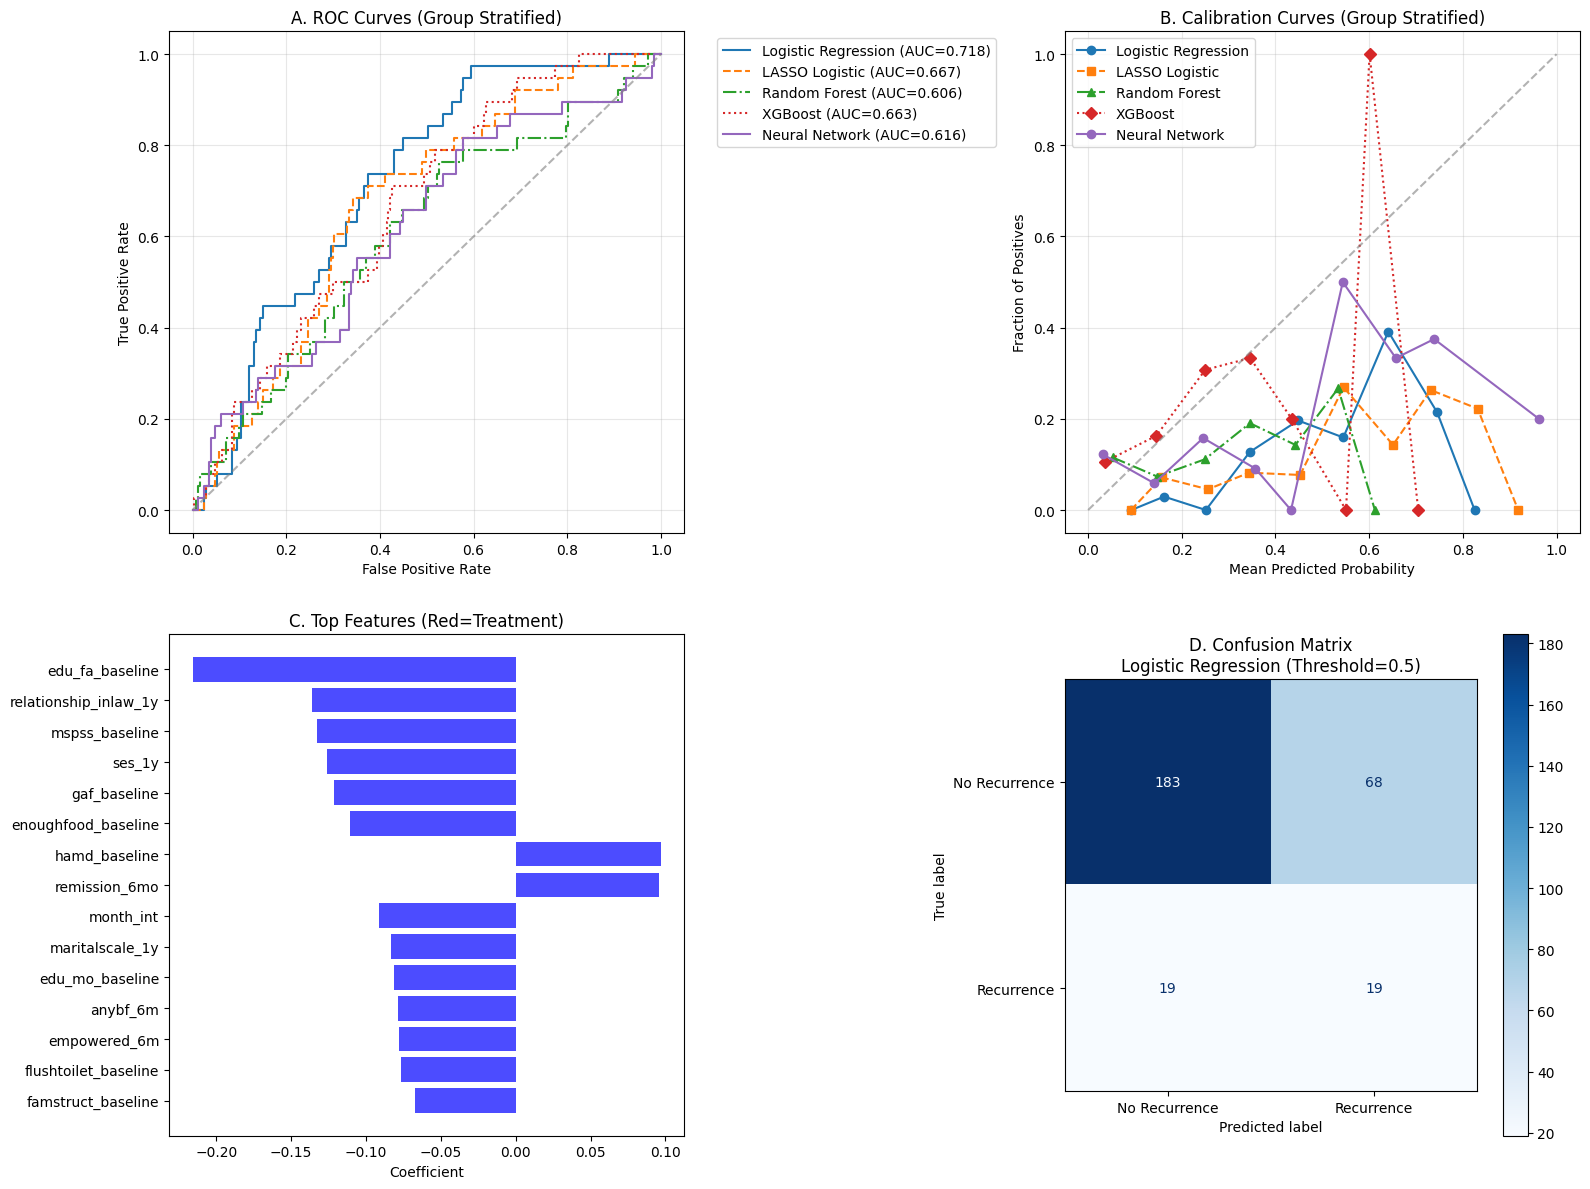

2025-07-29 17:16:11,650 - INFO - Refitted best: Logistic Regression
2025-07-29 17:16:11,661 - INFO - Calibration on train completed


Spearman correlation between calibrated and uncalibrated probabilities: 0.7825

Hold-out Performance:
Uncalibrated: AUC=0.521, F1=0.250
Calibrated:   AUC=0.562, F1=0.000


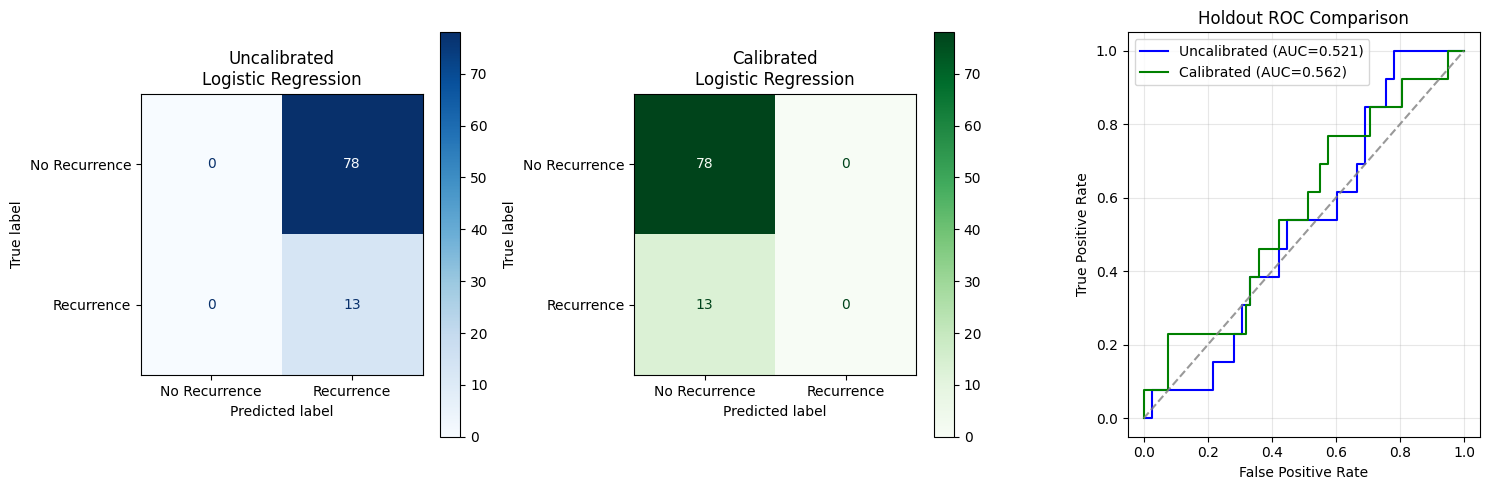

2025-07-29 17:16:11,832 - INFO - Performing SHAP analysis...
2025-07-29 17:16:11,832 - INFO - Treatment variable included in SHAP: True



Detailed Holdout Metrics:
Metric          Uncalibrated Calibrated  
---------------------------------------
Accuracy        0.143        0.857       
Precision       0.143        0.000       
Recall          1.000        0.000       
F1 Score        0.250        0.000       
AUC             0.521        0.562       
Specificity     0.000        1.000       
Sensitivity     1.000        0.000       

Confusion Matrix Components:
Component       Uncalibrated Calibrated  
---------------------------------------
True Positives  13           0           
False Positives 78           0           
True Negatives  0            78          
False Negatives 0            13          


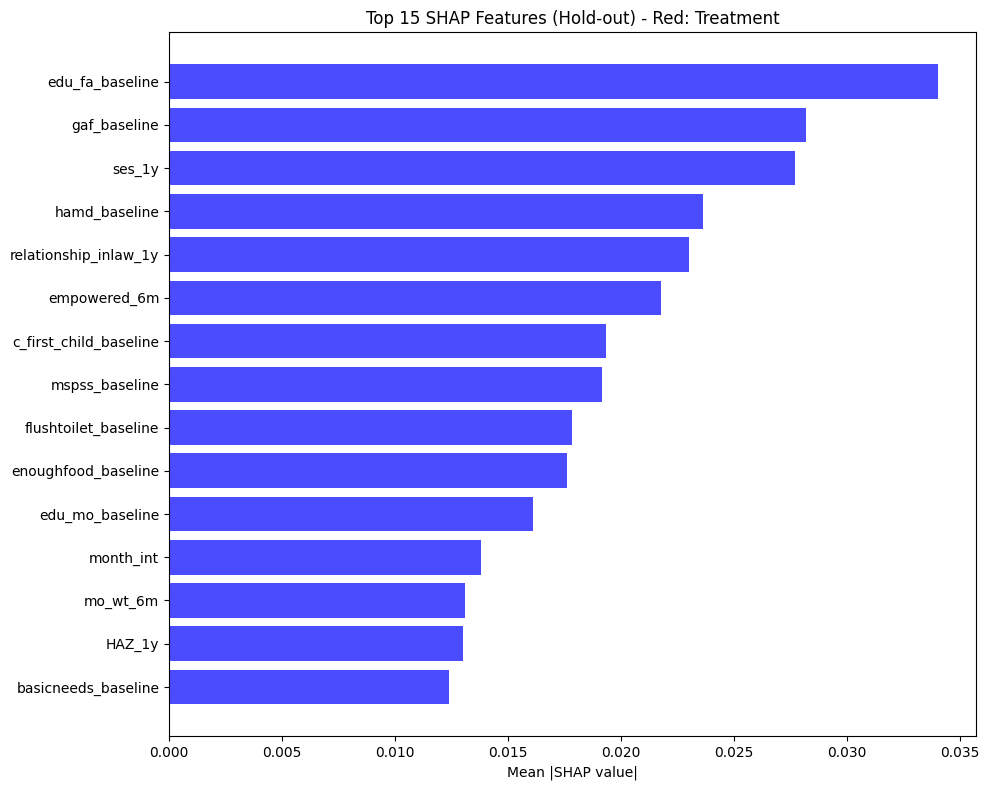

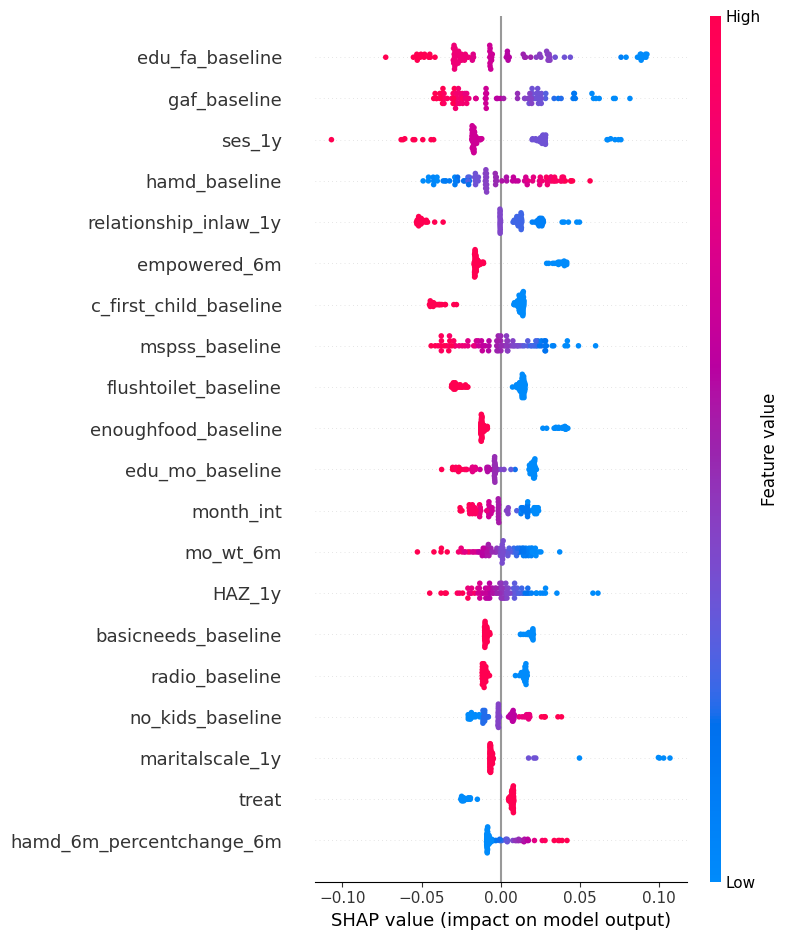


Generating SHAP Personas...
Top 3 SHAP features: ['ses_1y', 'gaf_baseline', 'edu_fa_baseline']

Top-3 SHAP Personas:
                                               Profile  P(recurrence)
   ses_1y=low & gaf_baseline=low & edu_fa_baseline=low          0.173
  ses_1y=low & gaf_baseline=low & edu_fa_baseline=high          0.124
  ses_1y=low & gaf_baseline=high & edu_fa_baseline=low          0.144
 ses_1y=low & gaf_baseline=high & edu_fa_baseline=high          0.105
  ses_1y=high & gaf_baseline=low & edu_fa_baseline=low          0.130
 ses_1y=high & gaf_baseline=low & edu_fa_baseline=high          0.097
 ses_1y=high & gaf_baseline=high & edu_fa_baseline=low          0.109
ses_1y=high & gaf_baseline=high & edu_fa_baseline=high          0.083


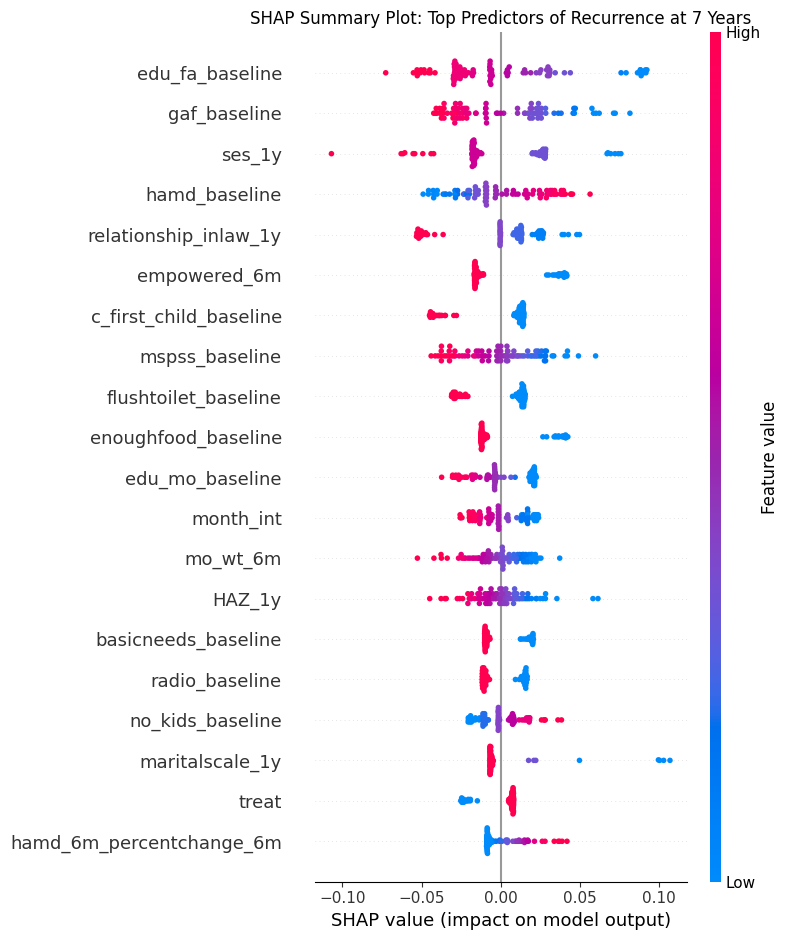

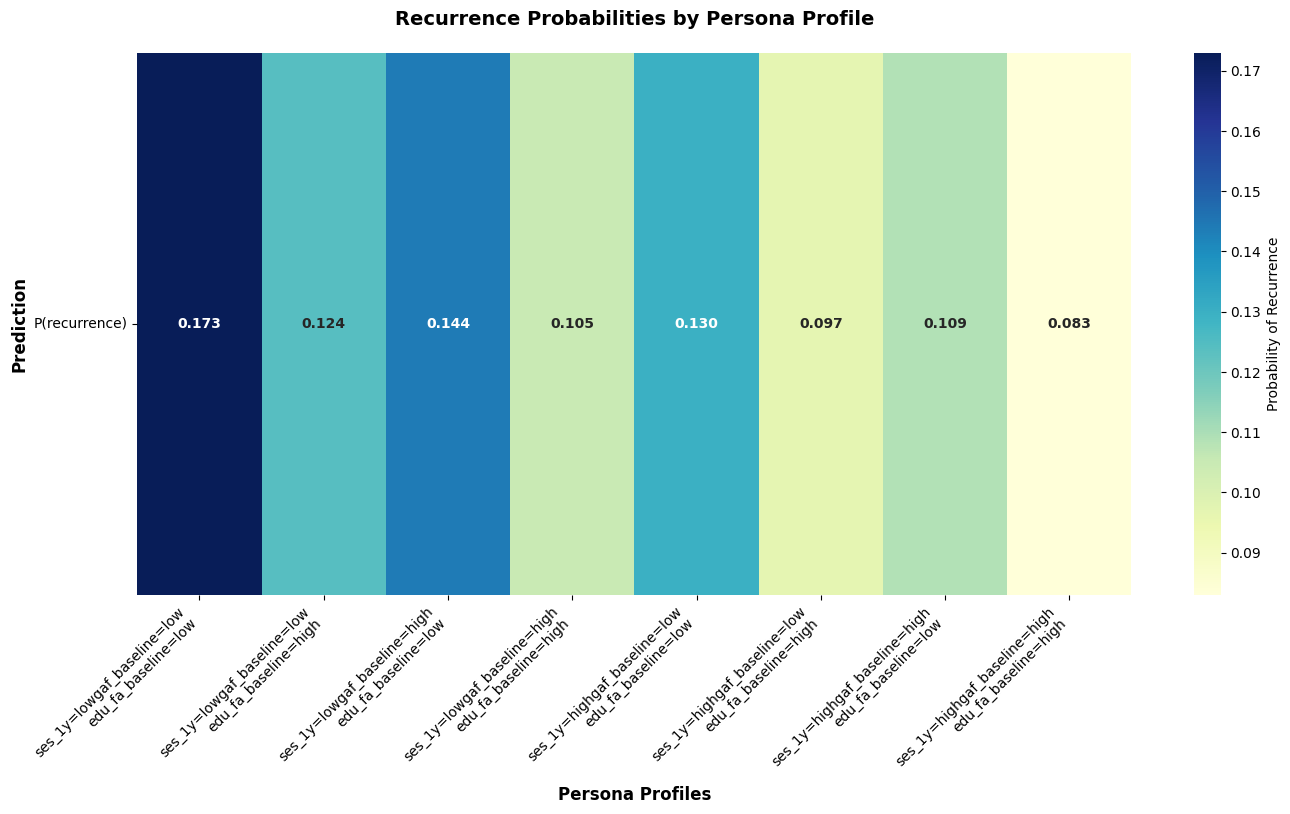


Debugging - Horizontal bar chart data:
Original proto_df:
                                             Profile  P(recurrence)
0  ses_1y=low & gaf_baseline=low & edu_fa_baselin...          0.173
1  ses_1y=low & gaf_baseline=low & edu_fa_baselin...          0.124
2  ses_1y=low & gaf_baseline=high & edu_fa_baseli...          0.144
3  ses_1y=low & gaf_baseline=high & edu_fa_baseli...          0.105
4  ses_1y=high & gaf_baseline=low & edu_fa_baseli...          0.130
5  ses_1y=high & gaf_baseline=low & edu_fa_baseli...          0.097
6  ses_1y=high & gaf_baseline=high & edu_fa_basel...          0.109
7  ses_1y=high & gaf_baseline=high & edu_fa_basel...          0.083

Sorted data for horizontal chart:
                                             Profile  P(recurrence)
7  ses_1y=high & gaf_baseline=high & edu_fa_basel...          0.083
5  ses_1y=high & gaf_baseline=low & edu_fa_baseli...          0.097
3  ses_1y=low & gaf_baseline=high & edu_fa_baseli...          0.105
6  ses_1y=high & gaf_b

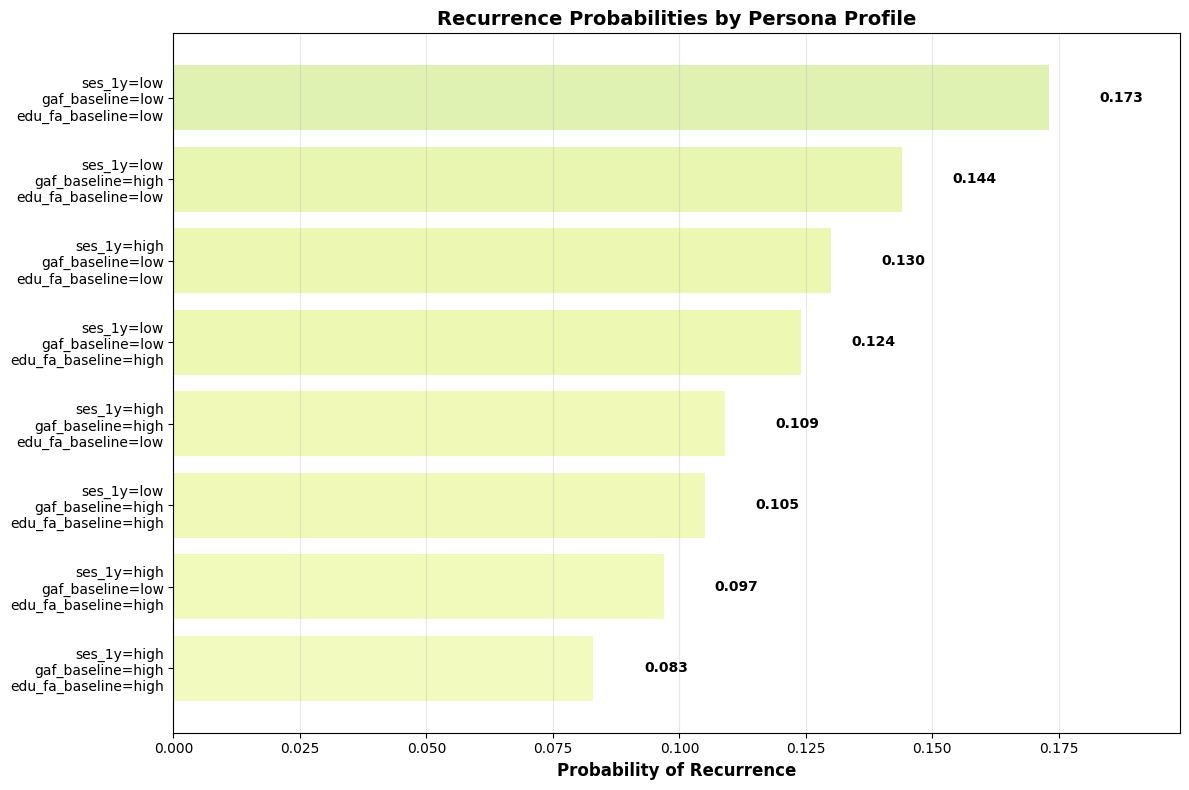

In [107]:
# Recurrence at 7 years - no SMOTE, no univariate selection, cluster-stratified CV

# ========= Imports =========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import tensorflow as tf 
import logging
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GroupKFold, StratifiedGroupKFold
from skopt import BayesSearchCV

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from tabulate import tabulate
from itertools import product
import warnings
warnings.filterwarnings("ignore")

# ========= Configuration =========
@dataclass
class Config:
    RANDOM_STATE: int = 123
    N_FEATURES: int = 15
    OUTER_SPLITS: int = 5
    INNER_SPLITS: int = 3
    N_ITER: int = 20
    TEST_SIZE: float = 0.2
    TARGET_COL: str = "recurrence_7y"
    CLUSTER_COL: str = "uc"  # cluster column for stratification
    ID_COL: str = "newid"
    EXCLUDE_COLS: List[str] = None
    MIN_CLUSTER_SIZE: int = 2  # Minimum samples per cluster for valid splits
    
    def __post_init__(self):
        if self.EXCLUDE_COLS is None:
            self.EXCLUDE_COLS = ["recurrence_7y", "depressed_6m", "recovery_1y", "depressed_1y", "uc"]  # Exclude cluster from features

config = Config()

# ========= Logging Setup =========
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ========= Data Validation =========
def validate_data(df: pd.DataFrame, target_col: str, cluster_col: str, required_cols: List[str]) -> None:
    """Validate input data quality"""
    assert not df.empty, "DataFrame is empty"
    assert target_col in df.columns, f"Target column '{target_col}' not found"
    assert cluster_col in df.columns, f"Cluster column '{cluster_col}' not found"
    
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    assert df[target_col].nunique() > 1, "Target has only one class"
    
    # Validate cluster distribution
    cluster_sizes = df[cluster_col].value_counts()
    min_cluster_size = cluster_sizes.min()
    logger.info(f"Data validation passed. Shape: {df.shape}")
    logger.info(f"Clusters: {sorted(df[cluster_col].unique())}")
    logger.info(f"Cluster sizes: min={min_cluster_size}, max={cluster_sizes.max()}, mean={cluster_sizes.mean():.1f}")
    logger.info(f"Target distribution: {df[target_col].value_counts().to_dict()}")
    
    if min_cluster_size < config.MIN_CLUSTER_SIZE:
        logger.warning(f"Some clusters have <{config.MIN_CLUSTER_SIZE} samples, which may cause CV issues")

def validate_cluster_separation(train_clusters: np.ndarray, test_clusters: np.ndarray, 
                              fold_num: int = None) -> bool:
    """Validate that train and test clusters are completely separated"""
    train_set = set(train_clusters)
    test_set = set(test_clusters)
    overlap = train_set & test_set
    
    if overlap:
        logger.error(f"Fold {fold_num}: Cluster overlap detected: {overlap}")
        return False
    
    logger.info(f"Fold {fold_num}: Cluster separation validated. "
                f"Train clusters: {len(train_set)}, Test clusters: {len(test_set)}")
    return True

# ========= FIXED: Stratified Group Train/Test Split =========
def create_stratified_group_split(df: pd.DataFrame, target_col: str, cluster_col: str, 
                                test_size: float, random_state: int) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Create train/test split that maintains complete cluster separation while balancing target distribution
    """
    np.random.seed(random_state)
    
    # Calculate target distribution within each cluster
    cluster_stats = df.groupby(cluster_col)[target_col].agg(['count', 'mean']).reset_index()
    cluster_stats['target_ratio'] = cluster_stats['mean']
    cluster_stats = cluster_stats.sort_values('target_ratio')
    
    logger.info(f"Cluster target distribution:\n{cluster_stats}")
    
    # Stratified sampling of clusters based on target ratio
    total_clusters = len(cluster_stats)
    n_test_clusters = max(1, int(total_clusters * test_size))
    
    # Divide clusters into strata based on target ratio quartiles
    cluster_stats['stratum'] = pd.qcut(cluster_stats['target_ratio'], 
                                     q=min(4, total_clusters), 
                                     labels=False, 
                                     duplicates='drop')
    
    test_clusters = []
    for stratum in cluster_stats['stratum'].unique():
        stratum_clusters = cluster_stats[cluster_stats['stratum'] == stratum][cluster_col].values
        n_from_stratum = max(1, int(len(stratum_clusters) * test_size))
        selected = np.random.choice(stratum_clusters, n_from_stratum, replace=False)
        test_clusters.extend(selected)
    
    # Ensure we have the right number of test clusters
    if len(test_clusters) < n_test_clusters:
        remaining_clusters = cluster_stats[~cluster_stats[cluster_col].isin(test_clusters)][cluster_col].values
        additional = np.random.choice(remaining_clusters, 
                                    n_test_clusters - len(test_clusters), 
                                    replace=False)
        test_clusters.extend(additional)
    elif len(test_clusters) > n_test_clusters:
        test_clusters = np.random.choice(test_clusters, n_test_clusters, replace=False)
    
    test_clusters = list(test_clusters)
    train_clusters = [c for c in df[cluster_col].unique() if c not in test_clusters]
    
    # Create splits
    train_df = df[df[cluster_col].isin(train_clusters)].copy()
    test_df = df[df[cluster_col].isin(test_clusters)].copy()
    
    # Validate separation
    if not validate_cluster_separation(train_df[cluster_col].values, test_df[cluster_col].values, "HOLDOUT"):
        raise ValueError("Failed to create properly separated train/test split")
    
    # Log distributions
    logger.info(f"Train: {len(train_df)} samples, {len(train_clusters)} clusters")
    logger.info(f"Test: {len(test_df)} samples, {len(test_clusters)} clusters")
    logger.info(f"Train target dist: {train_df[target_col].value_counts().to_dict()}")
    logger.info(f"Test target dist: {test_df[target_col].value_counts().to_dict()}")
    
    return train_df, test_df

# ========= FIXED: Custom CV Class with Proper Validation =========
class ValidatedGroupKFold:
    """
    GroupKFold wrapper with validation and fallback mechanisms
    """
    def __init__(self, n_splits: int = 5, shuffle: bool = True, random_state: int = None):
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state
        self.group_kfold = GroupKFold(n_splits=n_splits)
    
    def split(self, X, y, groups):
        """Generate validated group-based splits"""
        if groups is None:
            raise ValueError("Groups cannot be None for GroupKFold")
        
        # Convert to numpy arrays for consistency
        if hasattr(X, 'shape'):
            n_samples = X.shape[0]
        else:
            n_samples = len(X)
        
        y = np.asarray(y)
        groups = np.asarray(groups)
        
        # Check if we have enough unique groups
        unique_groups = np.unique(groups)
        if len(unique_groups) < self.n_splits:
            logger.warning(f"Only {len(unique_groups)} groups for {self.n_splits} splits. "
                         f"Falling back to StratifiedKFold")
            skf = StratifiedKFold(n_splits=min(self.n_splits, len(unique_groups)), 
                                shuffle=self.shuffle, random_state=self.random_state)
            yield from skf.split(X, y)
            return
        
        # Use StratifiedGroupKFold for better target distribution balance
        try:
            sgkf = StratifiedGroupKFold(n_splits=self.n_splits, shuffle=self.shuffle, 
                                      random_state=self.random_state)
            splits = list(sgkf.split(X, y, groups))
        except (ValueError, Exception) as e:
            logger.warning(f"StratifiedGroupKFold failed: {e}. Falling back to GroupKFold")
            splits = list(self.group_kfold.split(X, y, groups))
        
        # Validate each split
        valid_splits = []
        for fold_idx, (train_idx, test_idx) in enumerate(splits):
            train_groups = groups[train_idx]
            test_groups = groups[test_idx]
            
            # Validate cluster separation
            if validate_cluster_separation(train_groups, test_groups, fold_idx + 1):
                # Additional validation: ensure both train and test have samples
                if len(train_idx) > 0 and len(test_idx) > 0:
                    # Check target distribution in both sets
                    train_targets = y[train_idx]
                    test_targets = y[test_idx]
                    
                    if len(np.unique(train_targets)) > 1 and len(np.unique(test_targets)) > 1:
                        valid_splits.append((train_idx, test_idx))
                        logger.info(f"Fold {fold_idx + 1}: Train={len(train_idx)}, Test={len(test_idx)}, "
                                  f"Train target ratio={train_targets.mean():.3f}, "
                                  f"Test target ratio={test_targets.mean():.3f}")
                    else:
                        logger.warning(f"Fold {fold_idx + 1}: Insufficient target diversity, skipping")
                else:
                    logger.warning(f"Fold {fold_idx + 1}: Empty train or test set, skipping")
            else:
                logger.warning(f"Fold {fold_idx + 1}: Failed cluster separation validation, skipping")
        
        if len(valid_splits) < 2:
            raise ValueError(f"Only {len(valid_splits)} valid folds generated, need at least 2")
        
        logger.info(f"Generated {len(valid_splits)} valid folds out of {len(splits)} attempted")
        yield from valid_splits
    
    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

# ========= FIXED: Simple Pipeline Builder =========
def build_simple_pipeline(base_model, config: Config):
    """Build a simple pipeline with only preprocessing and model"""
    pipeline = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('model', base_model)
    ])
    return pipeline

# ========= FIXED: Nested CV with Proper GroupKFold =========
def run_nested_cv_group_stratified(model, param_distributions: Dict, X: pd.DataFrame, y: np.ndarray, 
                                  groups: np.ndarray, config: Config) -> Dict[str, Any]:
    """
    FIXED: Nested CV with proper GroupKFold implementation
    """
    # Initialize CV splitters
    outer_cv = ValidatedGroupKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                                  random_state=config.RANDOM_STATE)
    inner_cv = ValidatedGroupKFold(n_splits=config.INNER_SPLITS, shuffle=True, 
                                  random_state=config.RANDOM_STATE + 1)

    # Convert DataFrame to numpy for consistent indexing
    X_values = X.values if hasattr(X, 'values') else X
    y = np.asarray(y)
    groups = np.asarray(groups)
    
    # Initialize results arrays
    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    outer_scores = []
    successful_folds = 0
    treatment_scores = []

    try:
        # Generate outer CV splits
        outer_splits = list(outer_cv.split(X_values, y, groups))
        logger.info(f"Generated {len(outer_splits)} outer CV folds")
        
        for fold, (train_idx, test_idx) in enumerate(outer_splits):
            logger.info(f"Processing outer fold {fold + 1}/{len(outer_splits)}")
            
            try:
                # Extract fold data
                X_train_fold = X.iloc[train_idx] if hasattr(X, 'iloc') else X_values[train_idx]
                y_train_fold = y[train_idx]
                groups_train_fold = groups[train_idx]
                X_test_fold = X.iloc[test_idx] if hasattr(X, 'iloc') else X_values[test_idx]
                y_test_fold = y[test_idx]

                # Log fold statistics
                logger.info(f"Fold {fold+1}: Train={len(train_idx)}, Test={len(test_idx)}")
                if hasattr(X, 'columns') and 'treat' in X.columns:
                    treat_col_idx = X.columns.get_loc('treat')
                    if hasattr(X, 'iloc'):
                        treat_dist = X.iloc[train_idx, treat_col_idx].value_counts()
                    else:
                        treat_dist = pd.Series(X_values[train_idx, treat_col_idx]).value_counts()
                    logger.info(f"Fold {fold+1} treatment distribution: {treat_dist.to_dict()}")

                # Build pipeline
                pipe = build_simple_pipeline(model, config)
                
                # FIXED: Properly configure BayesSearchCV with explicit CV
                search_space = {f'model__{k}': v for k, v in param_distributions.items()}
                
                # Generate inner CV splits for this fold
                try:
                    inner_splits = list(inner_cv.split(X_train_fold, y_train_fold, groups_train_fold))
                    logger.info(f"Fold {fold+1}: Generated {len(inner_splits)} inner CV splits")
                except Exception as e:
                    logger.warning(f"Fold {fold+1}: Inner CV failed: {e}. Using 3-fold StratifiedKFold")
                    inner_splits = list(StratifiedKFold(n_splits=3, shuffle=True, 
                                                      random_state=config.RANDOM_STATE).split(X_train_fold, y_train_fold))
                
                search = BayesSearchCV(
                    pipe,
                    search_spaces=search_space,
                    n_iter=config.N_ITER,
                    scoring='roc_auc',
                    cv=inner_splits,  # FIXED: Pass list of splits, not generator
                    n_jobs=1,
                    random_state=config.RANDOM_STATE,
                    error_score='raise'
                )
                
                # Fit hyperparameter search
                if hasattr(X_train_fold, 'values'):
                    search.fit(X_train_fold, y_train_fold)
                else:
                    # Convert back to DataFrame for proper feature handling
                    X_train_df = pd.DataFrame(X_train_fold, columns=X.columns)
                    search.fit(X_train_df, y_train_fold)
                
                best_model = search.best_estimator_

                # Extract treatment information
                model_obj = best_model.named_steps['model']
                treat_info = {'fold': fold + 1, 'treat_coef': 0, 'treat_importance': 0}
                
                if hasattr(model_obj, 'coef_') and hasattr(X, 'columns') and 'treat' in X.columns:
                    treat_idx = X.columns.get_loc('treat')
                    treat_coef = model_obj.coef_[0][treat_idx]
                    treat_info['treat_coef'] = treat_coef
                    logger.info(f"Fold {fold+1}: Treatment coefficient = {treat_coef:.3f}")
                elif hasattr(model_obj, 'feature_importances_') and hasattr(X, 'columns') and 'treat' in X.columns:
                    treat_idx = X.columns.get_loc('treat')
                    treat_importance = model_obj.feature_importances_[treat_idx]
                    treat_info['treat_importance'] = treat_importance
                    logger.info(f"Fold {fold+1}: Treatment importance = {treat_importance:.3f}")
                
                treatment_scores.append(treat_info)

                # Make predictions
                if hasattr(X_test_fold, 'values'):
                    prob = best_model.predict_proba(X_test_fold)[:, 1]
                else:
                    X_test_df = pd.DataFrame(X_test_fold, columns=X.columns)
                    prob = best_model.predict_proba(X_test_df)[:, 1]
                
                pred = (prob > 0.5).astype(int)
                
                # Store results
                y_probs[test_idx] = prob
                y_preds[test_idx] = pred
                auc_score = roc_auc_score(y_test_fold, prob)
                outer_scores.append(auc_score)
                successful_folds += 1
                
                logger.info(f"Fold {fold+1} AUC: {auc_score:.3f}")
                
            except Exception as e:
                logger.error(f"Error in fold {fold + 1}: {e}")
                # For failed folds, use neutral predictions
                y_probs[test_idx] = 0.5
                y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
                outer_scores.append(0.5)

    except Exception as e:
        logger.error(f"Critical error in nested CV: {e}")
        raise

    # Validate results
    if successful_folds < max(1, config.OUTER_SPLITS // 2):
        raise RuntimeError(f"Too many folds failed: {successful_folds}/{len(outer_splits)}")

    # Calculate metrics on valid predictions only
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    # Log treatment importance summary
    if treatment_scores:
        avg_treat_coef = np.mean([t.get('treat_coef', 0) for t in treatment_scores])
        avg_treat_importance = np.mean([t.get('treat_importance', 0) for t in treatment_scores])
        logger.info(f"Average treatment coefficient: {avg_treat_coef:.3f}")
        logger.info(f"Average treatment importance: {avg_treat_importance:.3f}")

    return {
        "model": search.best_estimator_ if 'search' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(outer_scores),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": 0,  # Legacy compatibility
        "treatment_scores": treatment_scores
    }

# ========= FIXED: Neural Network CV =========
def run_nn_cv_group_stratified(X: pd.DataFrame, y: np.ndarray, groups: np.ndarray, config: Config) -> Dict[str, Any]:
    """FIXED: Neural network CV with proper GroupKFold"""
    outer_cv = ValidatedGroupKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                                  random_state=config.RANDOM_STATE)
    
    # Convert to numpy for consistent indexing
    X_values = X.values if hasattr(X, 'values') else X
    y = np.asarray(y)
    groups = np.asarray(groups)
    
    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    aucs = []
    successful_folds = 0
    feature_names = X.columns.tolist() if hasattr(X, 'columns') else None
    treatment_scores = []

    try:
        outer_splits = list(outer_cv.split(X_values, y, groups))
        logger.info(f"NN: Generated {len(outer_splits)} outer CV folds")
        
        for fold, (train_idx, test_idx) in enumerate(outer_splits):
            logger.info(f"Processing NN fold {fold + 1}/{len(outer_splits)}")
            
            try:
                # Extract fold data
                X_train_fold = X.iloc[train_idx] if hasattr(X, 'iloc') else X_values[train_idx]
                y_train_fold = y[train_idx]
                X_test_fold = X.iloc[test_idx] if hasattr(X, 'iloc') else X_values[test_idx]
                y_test_fold = y[test_idx]

                # Apply preprocessing
                imputer = SimpleImputer(strategy='median')
                scaler = StandardScaler()
                
                X_train_processed = imputer.fit_transform(X_train_fold)
                X_train_scaled = scaler.fit_transform(X_train_processed)
                
                logger.info(f"NN Fold {fold+1}: Training on {len(X_train_scaled)} samples, "
                           f"class distribution: {np.bincount(y_train_fold)}")

                # Track treatment info
                treat_info = {'fold': fold + 1, 'treat_coef': 0, 'treat_importance': 0}
                treatment_scores.append(treat_info)
                
                # Build and train model
                model = build_nn_model(input_dim=X_train_scaled.shape[1])
                
                # Compute class weights
                unique_classes = np.unique(y_train_fold)
                if len(unique_classes) > 1:
                    cw_vals = compute_class_weight('balanced', classes=unique_classes, y=y_train_fold)
                    class_weights = {i: w for i, w in enumerate(cw_vals)}
                else:
                    class_weights = None
                
                batch_size = max(8, min(32, len(X_train_scaled) // 4))
                
                model.fit(
                    X_train_scaled, y_train_fold,
                    validation_split=0.2,
                    epochs=100,
                    batch_size=batch_size,
                    callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
                    class_weight=class_weights,
                    verbose=0
                )

                # Transform test data and predict
                X_test_processed = imputer.transform(X_test_fold)
                X_test_scaled = scaler.transform(X_test_processed)
                
                prob = model.predict(X_test_scaled, verbose=0).ravel()
                pred = (prob > 0.5).astype(int)
                
                y_probs[test_idx] = prob
                y_preds[test_idx] = pred
                auc_score = roc_auc_score(y_test_fold, prob)
                aucs.append(auc_score)
                successful_folds += 1
                
                logger.info(f"NN Fold {fold+1} AUC: {auc_score:.3f}")
                
            except Exception as e:
                logger.error(f"Error in NN fold {fold + 1}: {e}")
                y_probs[test_idx] = 0.5
                y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
                aucs.append(0.5)

    except Exception as e:
        logger.error(f"Critical error in NN CV: {e}")
        raise

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid NN predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    logger.info(f"NN: Completed {successful_folds}/{len(outer_splits)} folds")

    return {
        "model": model if 'model' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(aucs),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": 0,
        "treatment_scores": treatment_scores
    }

# ========= Leak-Free Preprocessor (No changes needed) =========
class LeakFreePreprocessor:
    """Preprocessing that prevents data leakage by fitting only on training folds"""
    
    def __init__(self, config: Config):
        self.config = config
        self.imputer = None
        self.scaler = None
        self.label_encoder = None
        self.feature_names = None
        
    def fit(self, X: pd.DataFrame, y: pd.Series) -> 'LeakFreePreprocessor':
        """Fit preprocessor components separately to allow proper CV"""
        self.feature_names = X.columns.tolist()
        
        # Fit components
        self.imputer = SimpleImputer(strategy='median')
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        
        # Fit on training data
        X_imputed = self.imputer.fit_transform(X)
        self.scaler.fit(X_imputed)
        self.label_encoder.fit(y)
        
        logger.info(f"Preprocessor fitted on {X.shape[0]} samples, {X.shape[1]} features")
        return self
    
    def transform_features(self, X):
        """Transform features using fitted preprocessor"""
        if isinstance(X, pd.DataFrame):
            X_ordered = X.reindex(columns=self.feature_names, fill_value=np.nan)
            X_values = X_ordered.values
        else:
            X_values = X
            
        X_imputed = self.imputer.transform(X_values)
        X_scaled = self.scaler.transform(X_imputed)
        return X_scaled
    
    def transform_target(self, y: pd.Series) -> np.ndarray:
        """Transform target using fitted label encoder"""
        return self.label_encoder.transform(y)
    
    def get_feature_names(self) -> List[str]:
        """Get original feature names"""
        return self.feature_names.copy()

# ========= Neural Network Builder (No changes) =========
def build_nn_model(input_dim: int, neurons1: int = 64, neurons2: int = 32, 
                   dropout: float = 0.3, learning_rate: float = 1e-3) -> tf.keras.Model:
    """Build neural network with improved architecture"""
    model = Sequential([
        Dense(neurons1, activation='relu', input_dim=input_dim,
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(neurons2, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model

# ========= Utility Functions =========
def calculate_holdout_metrics(y_true: np.ndarray, y_pred: np.ndarray, 
                            y_proba: np.ndarray) -> Dict[str, float]:
    """Calculate comprehensive holdout metrics including confusion matrix components"""
    cm = confusion_matrix(y_true, y_pred)
    
    # Extract confusion matrix components
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true, y_proba),
        'Brier Score': brier_score_loss(y_true, y_proba),
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0
    }

# ========= Enhanced plot_performance_curves Function =========
def plot_performance_curves(results: Dict, y_true: np.ndarray, feature_names, title_suffix: str = "", threshold: float = 0.5):
    """Generate annotated ROC, calibration curves, feature importance, and confusion matrix with enhanced readability."""
    import matplotlib.pyplot as plt
    import numpy as np
    from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
    from sklearn.calibration import calibration_curve

    plt.figure(figsize=(16, 12))
    line_styles = ['-', '--', '-.', ':']
    markers = ['o', 's', '^', 'D']
    colors = plt.cm.tab10.colors
    model_names = list(results.keys())

    # ROC Curves
    plt.subplot(2, 2, 1)
    for idx, name in enumerate(model_names):
        res = results[name]
        if res and 'y_probs' in res:
            valid_mask = res['y_probs'] >= 0
            if np.any(valid_mask):
                y_valid = y_true[valid_mask]
                probs_valid = res['y_probs'][valid_mask]
                fpr, tpr, _ = roc_curve(y_valid, probs_valid)
                auc = roc_auc_score(y_valid, probs_valid)
                label = f"{name} (AUC={auc:.3f})"
                plt.plot(fpr, tpr, label=label,
                         linestyle=line_styles[idx % len(line_styles)],
                         color=colors[idx % len(colors)])
    plt.plot([0, 1], [0, 1], '--', color='gray', alpha=0.6)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"A. ROC Curves {title_suffix}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)

    # Calibration Curves
    plt.subplot(2, 2, 2)
    for idx, name in enumerate(model_names):
        res = results[name]
        if res and 'y_probs' in res:
            valid_mask = res['y_probs'] >= 0
            if np.any(valid_mask):
                y_valid = y_true[valid_mask]
                probs_valid = res['y_probs'][valid_mask]
                frac_pos, mean_pred = calibration_curve(y_valid, probs_valid, n_bins=10)
                plt.plot(mean_pred, frac_pos,
                         marker=markers[idx % len(markers)],
                         linestyle=line_styles[idx % len(line_styles)],
                         color=colors[idx % len(colors)],
                         label=name)
    plt.plot([0, 1], [0, 1], '--', color='gray', alpha=0.6)
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title(f"B. Calibration Curves {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Feature Importance
    plt.subplot(2, 2, 3)
    try:
        best_model_name = max(results.keys(), key=lambda k: results[k]['metrics']['AUC'] if results[k] else 0)
        best_model = results[best_model_name]['model']
        if hasattr(best_model, 'named_steps'):
            model_obj = best_model.named_steps['model']
            if hasattr(model_obj, 'coef_'):
                coeffs = model_obj.coef_[0]
                top_idx = np.argsort(np.abs(coeffs))[-15:]
                top_feats = [feature_names[i] for i in top_idx]
                colors_bar = ['red' if feat == 'treat' else 'blue' for feat in top_feats]
                plt.barh(range(len(top_idx)), coeffs[top_idx], color=colors_bar, alpha=0.7)
                plt.yticks(range(len(top_idx)), top_feats)
                plt.xlabel("Coefficient")
                plt.title("C. Top Features (Red=Treatment)")
            elif hasattr(model_obj, 'feature_importances_'):
                importances = model_obj.feature_importances_
                top_idx = np.argsort(importances)[-15:]
                top_feats = [feature_names[i] for i in top_idx]
                colors_bar = ['red' if feat == 'treat' else 'blue' for feat in top_feats]
                plt.barh(range(len(top_idx)), importances[top_idx], color=colors_bar, alpha=0.7)
                plt.yticks(range(len(top_idx)), top_feats)
                plt.xlabel("Importance")
                plt.title("C. Top Features (Red=Treatment)")
            else:
                plt.text(0.5, 0.5, "Feature importance\nnot available",
                         ha='center', va='center', transform=plt.gca().transAxes)
    except Exception as e:
        print(f"Error plotting feature importance: {e}")
        plt.text(0.5, 0.5, "Feature importance\nnot available",
                 ha='center', va='center', transform=plt.gca().transAxes)

    # Confusion Matrix
    plt.subplot(2, 2, 4)
    try:
        res = results[best_model_name]
        valid_mask = res['y_probs'] >= 0
        if np.any(valid_mask):
            y_valid = y_true[valid_mask]
            y_pred_valid = (res['y_probs'][valid_mask] >= threshold).astype(int)
            cm = confusion_matrix(y_valid, y_pred_valid)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Recurrence', 'Recurrence'])
            disp.plot(ax=plt.gca(), cmap='Blues', values_format='d')
            plt.title(f"D. Confusion Matrix\n{best_model_name} (Threshold={threshold})")
    except Exception as e:
        print(f"Error plotting confusion matrix: {e}")
        plt.text(0.5, 0.5, "Confusion Matrix\nnot available",
                 ha='center', va='center', transform=plt.gca().transAxes)

    plt.tight_layout()
    plt.show()

# ========= Holdout Confusion Matrix Function =========
def plot_holdout_confusion_matrices(y_true, preds_unc, preds_cal, probs_unc, probs_cal, best_name):
    """Plot confusion matrices for holdout predictions"""
    plt.figure(figsize=(15, 5))
    
    # Uncalibrated Confusion Matrix
    plt.subplot(1, 3, 1)
    cm_unc = confusion_matrix(y_true, preds_unc)
    disp_unc = ConfusionMatrixDisplay(confusion_matrix=cm_unc, 
                                     display_labels=['No Recurrence', 'Recurrence'])
    disp_unc.plot(ax=plt.gca(), cmap='Blues', values_format='d')
    plt.title(f"Uncalibrated\n{best_name}")
    
    # Calibrated Confusion Matrix
    plt.subplot(1, 3, 2)
    cm_cal = confusion_matrix(y_true, preds_cal)
    disp_cal = ConfusionMatrixDisplay(confusion_matrix=cm_cal, 
                                     display_labels=['No Recurrence', 'Recurrence'])
    disp_cal.plot(ax=plt.gca(), cmap='Greens', values_format='d')
    plt.title(f"Calibrated\n{best_name}")
    
    # ROC Comparison
    plt.subplot(1, 3, 3)
    fpr_unc, tpr_unc, _ = roc_curve(y_true, probs_unc)
    fpr_cal, tpr_cal, _ = roc_curve(y_true, probs_cal)
    
    auc_unc = roc_auc_score(y_true, probs_unc)
    auc_cal = roc_auc_score(y_true, probs_cal)
    
    plt.plot(fpr_unc, tpr_unc, label=f'Uncalibrated (AUC={auc_unc:.3f})', color='blue')
    plt.plot(fpr_cal, tpr_cal, label=f'Calibrated (AUC={auc_cal:.3f})', color='green')
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Holdout ROC Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ========= SHAP Feature Analysis =========
def perform_shap_analysis(best_model, X_holdout: np.ndarray, feature_names: List[str],
                         preprocessor: LeakFreePreprocessor, holdout_raw: pd.DataFrame):
    """Perform SHAP analysis with proper error handling"""
    try:
        logger.info("Performing SHAP analysis...")
        
        model_obj = best_model.named_steps['model']
        if not hasattr(model_obj, 'predict_proba'):
            logger.warning("Model doesn't support probability prediction, skipping SHAP")
            return None
        
        # Use all features - no feature selection
        X_for_shap = X_holdout
        shap_feature_names = feature_names
        
        # Highlight if treatment is included
        treat_included = 'treat' in shap_feature_names
        logger.info(f"Treatment variable included in SHAP: {treat_included}")
        
        n_background = min(100, X_for_shap.shape[0])
        background_data = X_for_shap[:n_background]  # Use this as "features" for SHAP summary plot
        
        if hasattr(model_obj, 'tree_'):
            explainer = shap.TreeExplainer(model_obj)
            shap_values = explainer.shap_values(background_data)
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        else:
            explainer = shap.Explainer(model_obj.predict_proba, background_data)
            shap_values = explainer(background_data)
            if hasattr(shap_values, 'values'):
                shap_values = shap_values.values[:, :, 1]
        
        shap_abs = np.abs(shap_values).mean(axis=0)
        top_n = min(15, len(shap_feature_names))
        top_idx = np.argsort(shap_abs)[-top_n:]
        
        plt.figure(figsize=(10, 8))
        colors = ['red' if shap_feature_names[i] == 'treat' else 'blue' for i in top_idx]
        plt.barh(range(len(top_idx)), shap_abs[top_idx], color=colors, alpha=0.7)
        plt.yticks(range(len(top_idx)), [shap_feature_names[i] for i in top_idx])
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"Top {top_n} SHAP Features (Hold-out) - Red: Treatment")
        plt.tight_layout()
        plt.show()
        
        try:
            shap.summary_plot(
                shap_values, 
                features=background_data, 
                feature_names=shap_feature_names,
                show=False
            )
            plt.tight_layout()
            plt.show()
        except Exception as e:
            logger.warning(f"Error creating SHAP summary plot: {e}")
            
    except Exception as e:
        logger.error(f"Error in SHAP analysis: {e}")
        return None

    return {
    'shap_values': shap_values,
    'feature_names': shap_feature_names,
    'features_used': background_data
}

# ========= UPDATED: Main Pipeline with Fixed GroupKFold =========
def main():
    """UPDATED: Main execution pipeline with fixed GroupKFold implementation"""

    # 1. Load & validate
    try:
        df = imputed_datasets["dat_ml_7y"]
        logger.info(f"Data loaded: {df.shape}")
        required = [config.TARGET_COL, config.CLUSTER_COL, config.ID_COL] + config.EXCLUDE_COLS + ['treat']
        validate_data(df, config.TARGET_COL, config.CLUSTER_COL, required)
    except Exception as e:
        logger.error(f"Loading/validation error: {e}")
        return

    # 2. Quick QC
    logger.info(f"Target counts:\n{df[config.TARGET_COL].value_counts()}")
    logger.info(f"Cluster counts:\n{df[config.CLUSTER_COL].value_counts()}")
    logger.info(f"Missing values: {df.isnull().sum().sum()}")

    # 3. FIXED: Improved cluster-stratified train/hold-out split
    train_df, holdout_df = create_stratified_group_split(
        df, config.TARGET_COL, config.CLUSTER_COL, config.TEST_SIZE, config.RANDOM_STATE
    )
    logger.info(f"Train={len(train_df)}, Hold-out={len(holdout_df)}")

    # 4. Prepare training data (preserve DataFrame structure)
    X_train = train_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    y_train = train_df[config.TARGET_COL].values
    groups_train = train_df[config.CLUSTER_COL].values  # Fixed: use groups instead of clusters
    feature_names = X_train.columns.tolist()
    
    logger.info(f"Training features: {len(feature_names)}")
    logger.info(f"Treatment variable included: {'treat' in feature_names}")
    logger.info(f"Unique groups in training: {len(np.unique(groups_train))}")

    # 5. Define models & parameters
    models_and_params = {
        "Logistic Regression": (
            LogisticRegression(max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.01, 0.1, 1.0, 10.0]}
        ),
        "LASSO Logistic": (
            LogisticRegression(penalty='l1', solver='liblinear',
                               max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.001, 0.01, 0.1, 1, 10]}
        ),
        "Random Forest": (
            RandomForestClassifier(class_weight='balanced',
                                   random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "max_depth": [3, 5, 10],
             "min_samples_split": [5, 10],
             "min_samples_leaf": [2, 5]}
        ),
        "XGBoost": (
            XGBClassifier(use_label_encoder=False,
                          eval_metric='logloss',
                          random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "learning_rate": [0.01, 0.1],
             "max_depth": [3, 6],
             "subsample": [0.8, 1.0]}
        )
    }

    # 6. FIXED: Run nested CV with proper GroupKFold
    results = {}
    for name, (model, params) in models_and_params.items():
        logger.info(f"→ Nested CV: {name}")
        try:
            results[name] = run_nested_cv_group_stratified(
                model, params, X_train, y_train, groups_train, config
            )
            logger.info(f"   AUC={results[name]['metrics']['AUC']:.3f}")
        except Exception as e:
            logger.error(f"   {name} failed: {e}")

    # 7. FIXED: Neural network with GroupKFold
    try:
        logger.info("→ Nested CV: Neural Network")
        results['Neural Network'] = run_nn_cv_group_stratified(X_train, y_train, groups_train, config)
        logger.info(f"   AUC={results['Neural Network']['metrics']['AUC']:.3f}")
    except Exception as e:
        logger.error(f"   NN failed: {e}")

    # 8. Show performance table
    perf_rows = []
    for m, res in results.items():
        if res and 'metrics' in res:
            row = {"Model": m}
            row.update({k: round(v, 3) for k, v in res['metrics'].items()})
            row["Folds"] = res.get('successful_folds', 'N/A')
            perf_rows.append(row)
    
    if not perf_rows:
        logger.error("No successful models to display")
        return
        
    perf_df = pd.DataFrame(perf_rows)
    print("\nNested CV Performance (Group Stratified)")
    print(tabulate(perf_df, headers='keys', tablefmt='grid', showindex=False))

    # 9. Fit preprocessor on full training data
    preprocessor = LeakFreePreprocessor(config)
    preprocessor.fit(X_train, train_df[config.TARGET_COL])
    
    # Transform training data
    X_train_proc = preprocessor.transform_features(X_train)
    y_train_processed = preprocessor.transform_target(train_df[config.TARGET_COL])
    
    logger.info(f"Final training data: {X_train_proc.shape}, class distribution: {np.bincount(y_train_processed)}")

    # 10. Plot OOF performance
    plot_performance_curves(results, y_train, feature_names, title_suffix="(Group Stratified)")

    # 11. Refit best pipeline on full training data
    if not results:
        logger.error("No successful models to select from")
        return

    best_name = max(results, key=lambda k: results[k]['metrics']['AUC'] if results[k] else 0)
    best_result = results[best_name]

    if not best_result or 'model' not in best_result:
        logger.error(f"Best model {best_name} has no trained model")
        return

    # Build and fit new pipeline on full processed data
    best_base_model = models_and_params[best_name][0]
    best_pipe = results[best_name]['model']           
    best_pipe.fit(X_train, y_train)
    logger.info(f"Refitted best: {best_name}")

    # 12. Calibrate via Platt scaling
    calibrator = CalibratedClassifierCV(
        estimator=best_pipe.named_steps['model'],
        method='sigmoid',
        cv=3
    )
    calibrator.fit(X_train_proc, y_train_processed)
    logger.info("Calibration on train completed")

    # 13. Prepare hold-out
    X_hold = holdout_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    X_hold_proc = preprocessor.transform_features(X_hold)
    y_hold = preprocessor.transform_target(holdout_df[config.TARGET_COL])

    # 14. Make predictions
    probs_unc = best_pipe.predict_proba(X_hold_proc)[:,1]
    probs_cal = calibrator.predict_proba(X_hold_proc)[:, 1]

    # Verify calibration preserves ranking
    spearman_corr = pd.Series(probs_unc).corr(pd.Series(probs_cal), method='spearman')
    print(f"Spearman correlation between calibrated and uncalibrated probabilities: {spearman_corr:.4f}")

    # 15. Calculate metrics
    preds_unc = (probs_unc > 0.5).astype(int)
    preds_cal = (probs_cal > 0.5).astype(int)
    hold_unc = calculate_holdout_metrics(y_hold, preds_unc, probs_unc)
    hold_cal = calculate_holdout_metrics(y_hold, preds_cal, probs_cal)

    print(f"\nHold-out Performance:")
    print(f"Uncalibrated: AUC={hold_unc['AUC']:.3f}, F1={hold_unc['F1 Score']:.3f}")
    print(f"Calibrated:   AUC={hold_cal['AUC']:.3f}, F1={hold_cal['F1 Score']:.3f}")

    # Plot holdout results
    plot_holdout_confusion_matrices(y_hold, preds_unc, preds_cal, probs_unc, probs_cal, best_name)
    
    # Print detailed metrics
    print(f"\nDetailed Holdout Metrics:")
    print(f"{'Metric':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC', 'Specificity', 'Sensitivity']:
        print(f"{metric:<15} {hold_unc[metric]:<12.3f} {hold_cal[metric]:<12.3f}")
    
    print(f"\nConfusion Matrix Components:")
    print(f"{'Component':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for component in ['True Positives', 'False Positives', 'True Negatives', 'False Negatives']:
        print(f"{component:<15} {hold_unc[component]:<12} {hold_cal[component]:<12}")

    # 16. SHAP & Personas
    shap_info = perform_shap_analysis(
        best_pipe,
        X_hold_proc,
        feature_names,
        preprocessor,
        holdout_df
    )

    if shap_info and shap_info['shap_values'] is not None:
        sv = shap_info['shap_values']
        feats = shap_info['feature_names']
        abs_mean = np.abs(sv).mean(axis=0)

        if len(feats) >= 3:
            print("\nGenerating SHAP Personas...")
            raw_df = train_df.drop(columns=config.EXCLUDE_COLS + [config.ID_COL])
            raw_median = raw_df.median()
            raw_min = raw_df.min()
            raw_max = raw_df.max()

            X_shap_used = shap_info['features_used']  # same 100 rows used for shap_values

            fig_shap_recurrence = plt.figure(figsize=(10, 8))

            shap.summary_plot(
                sv,
                features=X_shap_used,
                feature_names=feats,
                show=False
            )

            plt.title("SHAP Summary Plot: Top Predictors of Recurrence at 7 Years")
            plt.tight_layout()
            fig_shap_recurrence = plt.gcf()

            # Pick top-3 by |SHAP|
            top3_idx = np.argsort(abs_mean)[-3:]
            top3_feats = [feats[i] for i in top3_idx]

            print(f"Top 3 SHAP features: {top3_feats}")

             # Save components with variant suffix
            variant = "recurrence"
            globals().update({
                f"shap_values_{variant}": sv,
                f"X_{variant}": X_shap_used,
                f"fig_shap_{variant}": fig_shap_recurrence,
                f"feature_names_{variant}": feats
            })
            
            # Create pipeline for personas
            class PersonaPipeline:
                def __init__(self, preprocessor, calibrator):
                    self.preprocessor = preprocessor
                    self.calibrator = calibrator
                
                def predict_proba(self, X_raw):
                    X_proc = self.preprocessor.transform_features(X_raw)
                    return self.calibrator.predict_proba(X_proc)
            
            final_pipe = PersonaPipeline(preprocessor, calibrator)
            
            prototypes = []
            for combo in product(['low','high'], repeat=3):
                row = raw_median.copy()
                desc = []
                for feat, lvl in zip(top3_feats, combo):
                    row[feat] = raw_min[feat] if lvl=='low' else raw_max[feat]
                    desc.append(f"{feat}={lvl}")
                
                arr_df = pd.DataFrame([row.reindex(feature_names)])
                try:
                    p = final_pipe.predict_proba(arr_df)[0,1]
                    prototypes.append({
                        'Profile': ' & '.join(desc),
                        'P(recurrence)': round(p, 3)
                    })
                except Exception as e:
                    logger.warning(f"Error generating persona for {desc}: {e}")
            
            if prototypes:
                proto_df = pd.DataFrame(prototypes)
                print("\nTop-3 SHAP Personas:")
                print(proto_df.to_string(index=False))
                
                try:
                    # Create persona visualizations
                    plt.figure(figsize=(14, 8))
                    
                    def format_label(label, max_chars_per_line=30):
                        parts = label.split(' & ')
                        formatted_parts = []
                        current_line = ""
                        
                        for part in parts:
                            if len(current_line + part) <= max_chars_per_line:
                                current_line += part + " & " if current_line else part
                            else:
                                if current_line:
                                    formatted_parts.append(current_line.rstrip(" & "))
                                current_line = part + " & "
                        
                        if current_line:
                            formatted_parts.append(current_line.rstrip(" & "))
                        
                        return '\n'.join(formatted_parts)
                    
                    formatted_labels = [format_label(profile) for profile in proto_df['Profile']]
                    
                    heatmap_data = proto_df.set_index('Profile')[['P(recurrence)']].T
                    heatmap_data.columns = formatted_labels
                    
                    ax = sns.heatmap(
                        heatmap_data,
                        annot=True, 
                        cmap='YlGnBu', 
                        fmt='.3f',
                        cbar_kws={'label': 'Probability of Recurrence'},
                        annot_kws={'size': 10, 'weight': 'bold'}
                    )
                    
                    plt.xticks(rotation=45, ha='right')
                    plt.yticks(rotation=0)
                    plt.title("Recurrence Probabilities by Persona Profile", 
                            fontsize=14, fontweight='bold', pad=20)
                    plt.xlabel("Persona Profiles", fontsize=12, fontweight='bold')
                    plt.ylabel("Prediction", fontsize=12, fontweight='bold')
                    plt.tight_layout()
                    plt.subplots_adjust(bottom=0.25)
                    plt.show()

                    # Function to split label into exactly 3 lines
                    def format_label_three_lines(label):
                        """Split a persona profile label into exactly 3 lines (one per variable)."""
                        parts = label.split(' & ')
                        return '\n'.join(parts[:3])  # Ensures only 3 lines

                    # Alternative horizontal bar chart - with three-line labels
                    fig_persona_barplot_recurrence = plt.figure(figsize=(12, 8))

                    # Create a copy to avoid modifying the original dataframe
                    chart_df = proto_df.copy()
                    sorted_df = chart_df.sort_values('P(recurrence)', ascending=True)

                    # Format labels into 3 lines each
                    formatted_labels_sorted = [format_label_three_lines(profile) for profile in sorted_df['Profile']]

                    # Create the bar chart using the correctly sorted probabilities
                    probabilities = sorted_df['P(recurrence)'].values
                    bars = plt.barh(range(len(sorted_df)), probabilities, 
                    color=plt.cm.YlGnBu(probabilities))
                    for i, (bar, prob) in enumerate(zip(bars, probabilities)):
                        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                                f'{prob:.3f}', va='center', fontweight='bold')
                    plt.yticks(range(len(sorted_df)), formatted_labels_sorted)
                    plt.xlabel('Probability of Recurrence', fontsize=12, fontweight='bold')
                    plt.title('Recurrence Probabilities by Persona Profile', fontsize=14, fontweight='bold')
                    plt.grid(axis='x', alpha=0.3)
                    plt.xlim(0, max(probabilities) * 1.15)
                    plt.tight_layout()
                    fig_persona_barplot_recurrence = plt.gcf()

                    # Add global variant suffix and save components for combined plot
                    variant = "recurrence"
                    globals().update({
                        f"proto_df_{variant}": proto_df,
                        f"fig_persona_bar_{variant}": fig_persona_barplot_recurrence,
                        f"probabilities_{variant}": probabilities
                    })
                     
                    # Optional: Add debugging print statements to verify the data
                    print("\nDebugging - Horizontal bar chart data:")
                    print("Original proto_df:")
                    print(proto_df[['Profile', 'P(recurrence)']])
                    print("\nSorted data for horizontal chart:")
                    print(sorted_df[['Profile', 'P(recurrence)']])
                    print(f"\nProbabilities being plotted: {probabilities}")
                    
                except Exception as e:
                    logger.warning(f"Error creating persona visualizations: {e}")
    else:
        logger.warning("SHAP analysis failed. Skipping persona generation.")

    # 17. Treatment analysis summary
    print(f"\n{'='*60}")
    print("TREATMENT VARIABLE ANALYSIS")
    print(f"{'='*60}")
    
    for model_name, result in results.items():
        if result and 'treatment_scores' in result:
            treat_scores = result.get('treatment_scores', [])
            total_folds = result.get('successful_folds', 0)
            
            if treat_scores:
                avg_coef = np.mean([t.get('treat_coef', 0) for t in treat_scores])
                avg_importance = np.mean([t.get('treat_importance', 0) for t in treat_scores])
                print(f"{model_name}:")
                print(f"  Total folds: {total_folds}")
                print(f"  Average coefficient: {avg_coef:.3f}")
                print(f"  Average importance: {avg_importance:.3f}")
    
    # 18. Final summary
    print(f"\n{'='*60}")
    print("FINAL RESULTS SUMMARY")
    print(f"{'='*60}")
    print(f"Best Model: {best_name}")
    print(f"Hold-out Performance (Calibrated):")
    for metric, value in hold_cal.items():
        print(f"  {metric}: {value:.3f}")
    
    # Check if treatment was included
    if 'treat' in feature_names:
        print("✓ Treatment variable was included in the model")
        
        # Show treatment coefficient/importance for best model
        best_model_obj = best_pipe.named_steps['model']
        if hasattr(best_model_obj, 'coef_') and 'treat' in feature_names:
            treat_idx = feature_names.index('treat')
            treat_coef = best_model_obj.coef_[0][treat_idx]
            print(f"  Treatment coefficient: {treat_coef:.3f}")
        elif hasattr(best_model_obj, 'feature_importances_') and 'treat' in feature_names:
            treat_idx = feature_names.index('treat')
            treat_importance = best_model_obj.feature_importances_[treat_idx]
            print(f"  Treatment importance: {treat_importance:.3f}")
    else:
        print("⚠ Treatment variable was NOT included in the model")
    
    print(f"Training method: Cluster-stratified CV (no SMOTE, no feature selection)")
    print(f"Number of features used: {len(feature_names)}")
    print(f"{'='*60}")

if __name__ == "__main__":
    main()

2025-07-11 12:04:08,593 - INFO - Data loaded: (585, 89)
2025-07-11 12:04:08,597 - INFO - Data validation passed. Shape: (585, 89)
2025-07-11 12:04:08,600 - INFO - Target counts:
depressed_7y
0    426
1    159
Name: count, dtype: int64
2025-07-11 12:04:08,602 - INFO - Missing values: 301
2025-07-11 12:04:08,613 - INFO - Train=468, Hold-out=117
2025-07-11 12:04:08,617 - INFO - → Nested CV: Logistic Regression
2025-07-11 12:04:08,619 - INFO - Processing outer fold 1/5
2025-07-11 12:04:08,620 - INFO - Fold 1 treatment distribution: {0: 193, 1: 181}
2025-07-11 12:04:08,620 - INFO - Fold 1 class distribution: {0: 273, 1: 101}
2025-07-11 12:04:11,974 - INFO - Fold 1: Treatment NOT selected (F-score=11.633, rank=39/86)
2025-07-11 12:04:11,978 - INFO - Fold 1 AUC: 0.581
2025-07-11 12:04:11,979 - INFO - Processing outer fold 2/5
2025-07-11 12:04:11,980 - INFO - Fold 2 treatment distribution: {0: 190, 1: 184}
2025-07-11 12:04:11,981 - INFO - Fold 2 class distribution: {0: 273, 1: 101}
2025-07-11 


Nested CV Performance (with Treatment Selection)
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+------------------+
| Model               |   Accuracy |   Precision |   Recall |   F1 Score |   AUC |   Brier Score |   Folds | Treat_Selected   |
+=====================+============+=============+==========+============+=======+===============+=========+==================+
| Logistic Regression |      0.65  |       0.4   |    0.583 |      0.474 | 0.655 |         0.23  |       5 | 0/5              |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+------------------+
| LASSO Logistic      |      0.622 |       0.382 |    0.638 |      0.478 | 0.654 |         0.24  |       5 | 0/5              |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+------------------+
| Random Forest       |      0.626 |       0.372 |    

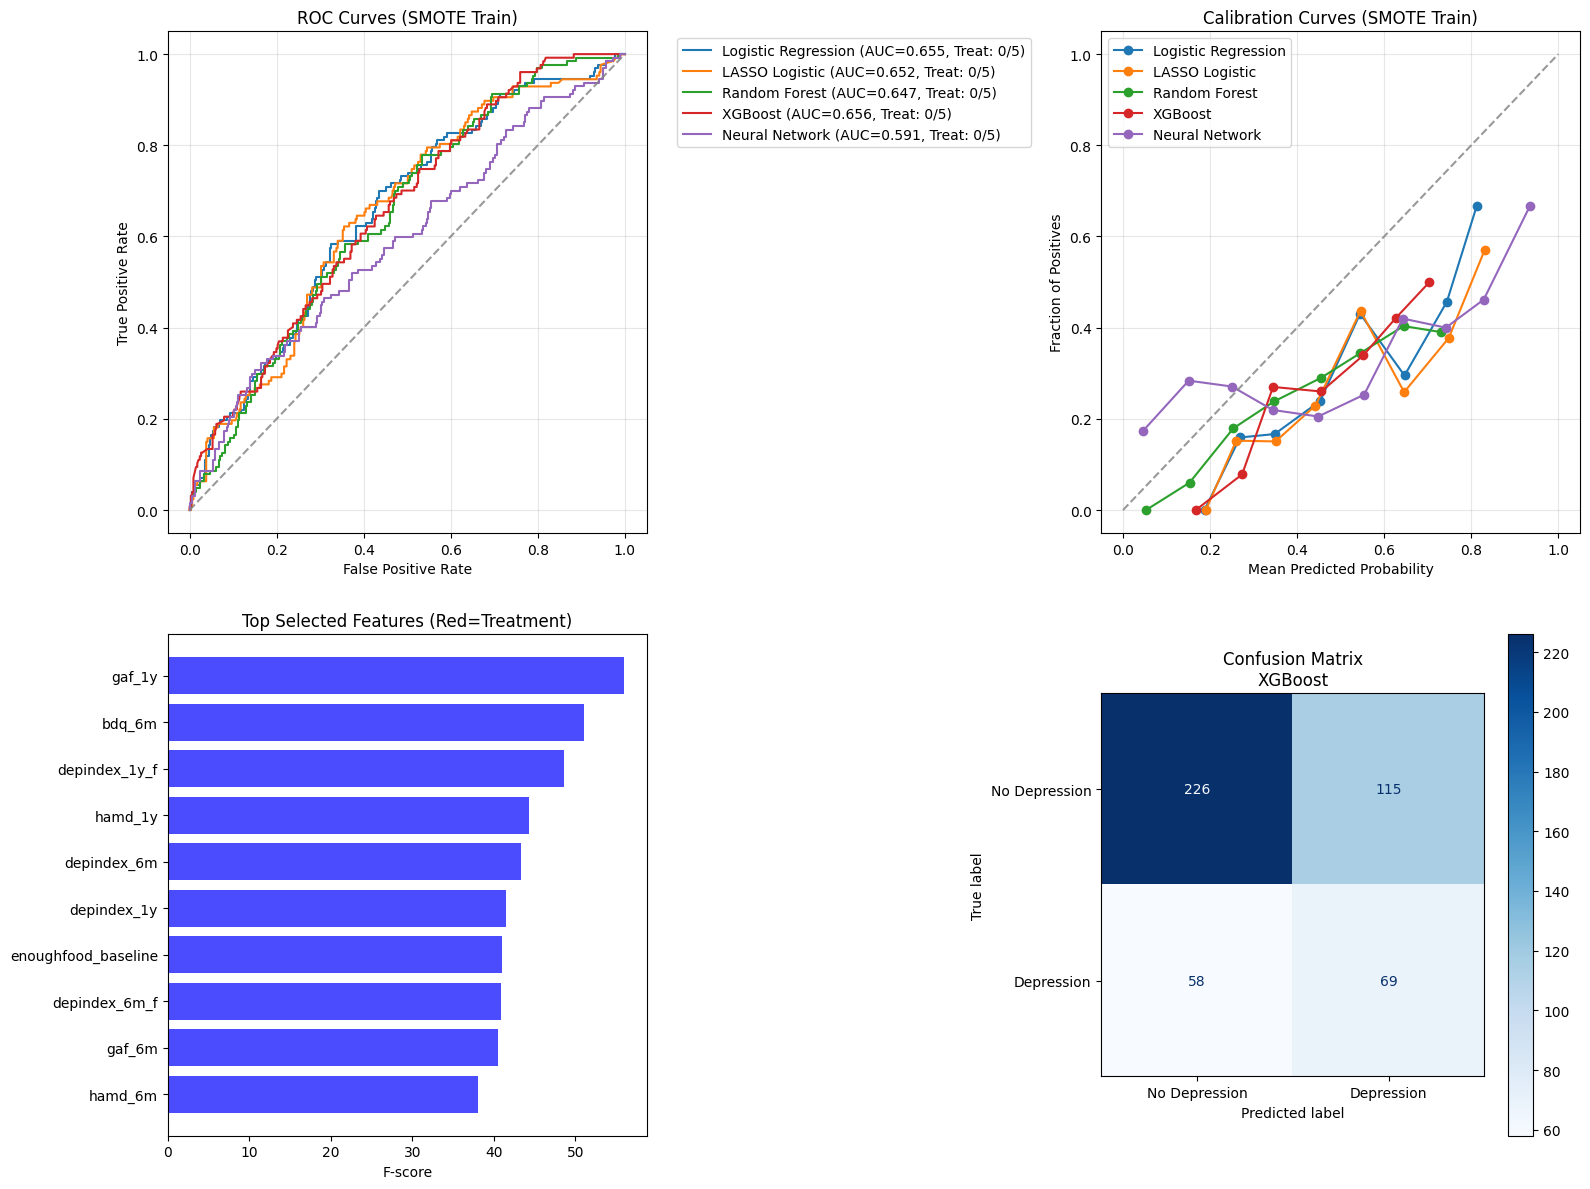

2025-07-11 12:06:12,942 - INFO - Refitted best: XGBoost
2025-07-11 12:06:13,059 - INFO - Calibration on train completed



Hold-out Performance:
Uncalibrated: AUC=0.714, F1=0.357
Calibrated:   AUC=0.736, F1=0.407


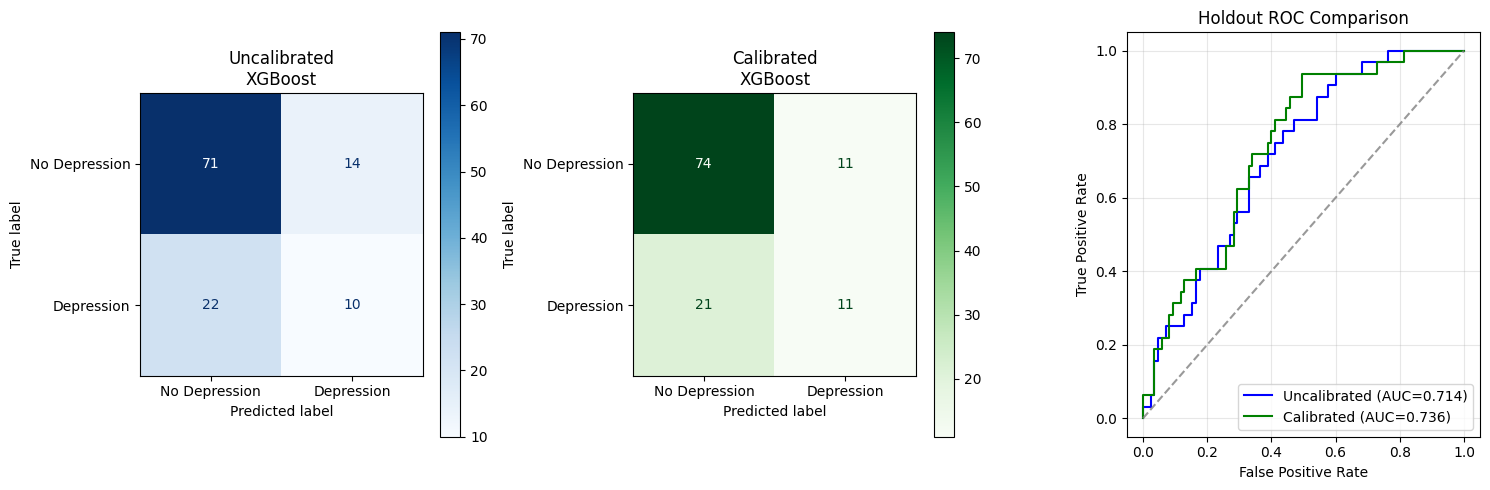

2025-07-11 12:06:13,342 - INFO - Performing SHAP analysis...
2025-07-11 12:06:13,343 - INFO - Treatment variable selected for SHAP: False



Detailed Holdout Metrics:
Metric          Uncalibrated Calibrated  
---------------------------------------
Accuracy        0.692        0.726       
Precision       0.417        0.500       
Recall          0.312        0.344       
F1 Score        0.357        0.407       
AUC             0.714        0.736       
Specificity     0.835        0.871       
Sensitivity     0.312        0.344       

Confusion Matrix Components:
Component       Uncalibrated Calibrated  
---------------------------------------
True Positives  10           11          
False Positives 14           11          
True Negatives  71           74          
False Negatives 22           21          


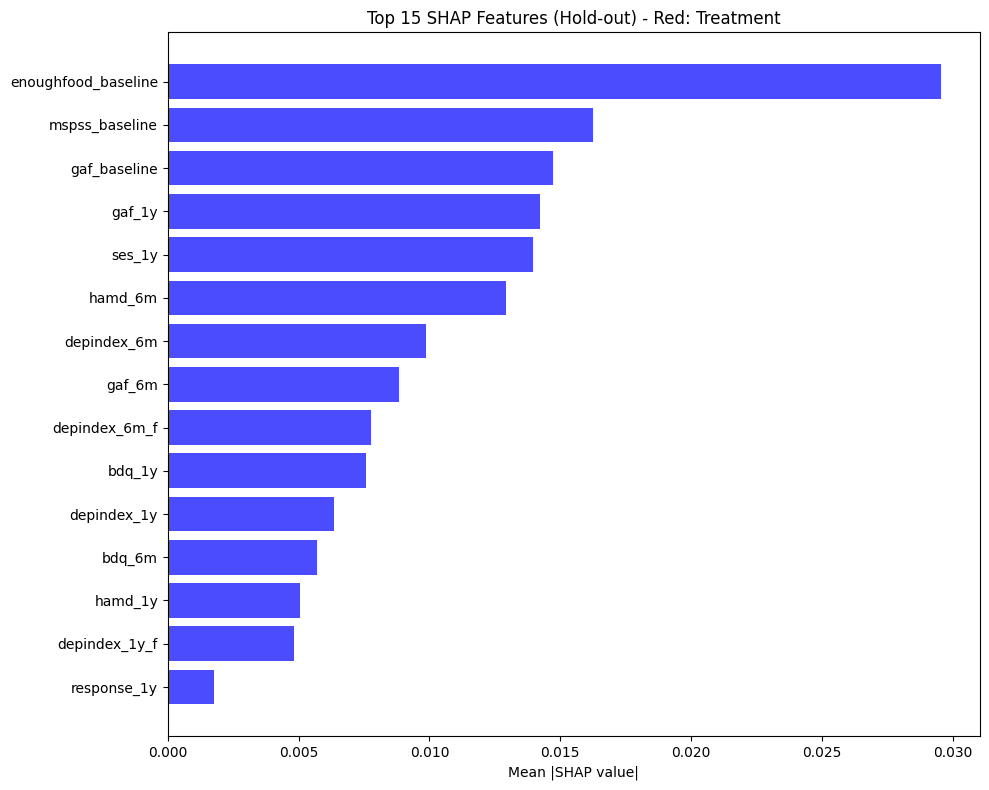

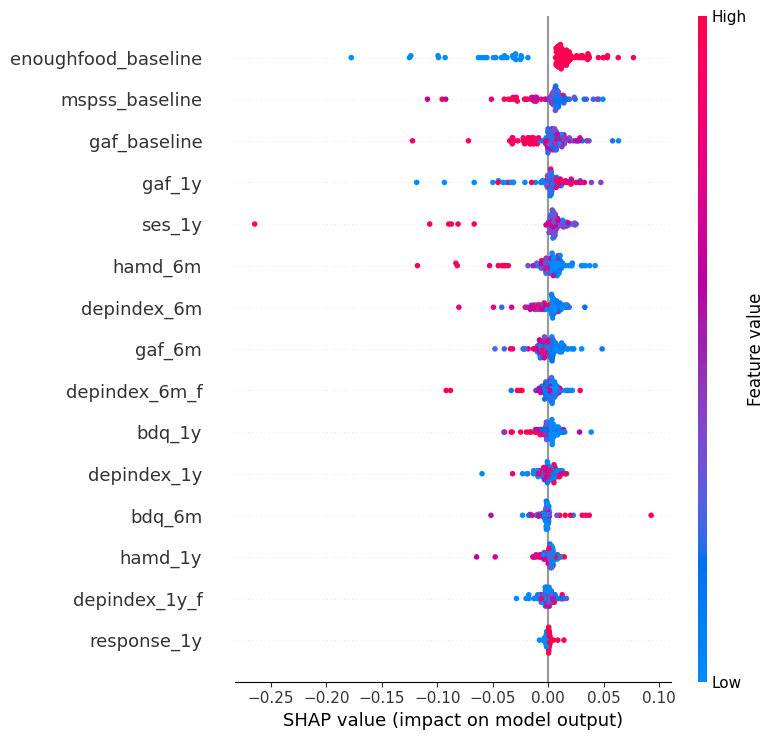


Generating SHAP Personas…
Top 3 SHAP features: ['gaf_baseline', 'mspss_baseline', 'enoughfood_baseline']

Top-3 SHAP Personas:
                                                           Profile  P(depression)
   gaf_baseline=low & mspss_baseline=low & enoughfood_baseline=low          0.558
  gaf_baseline=low & mspss_baseline=low & enoughfood_baseline=high          0.222
  gaf_baseline=low & mspss_baseline=high & enoughfood_baseline=low          0.298
 gaf_baseline=low & mspss_baseline=high & enoughfood_baseline=high          0.185
  gaf_baseline=high & mspss_baseline=low & enoughfood_baseline=low          0.572
 gaf_baseline=high & mspss_baseline=low & enoughfood_baseline=high          0.177
 gaf_baseline=high & mspss_baseline=high & enoughfood_baseline=low          0.311
gaf_baseline=high & mspss_baseline=high & enoughfood_baseline=high          0.188


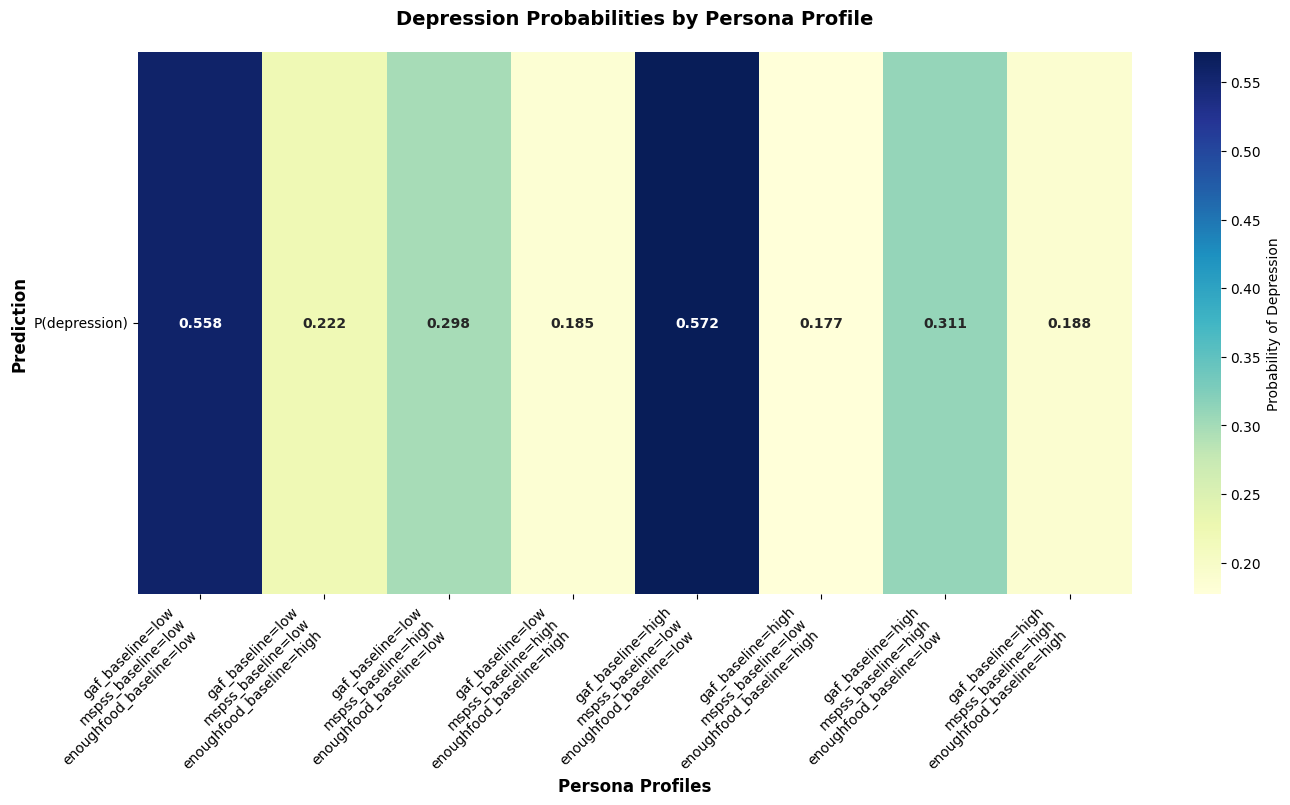

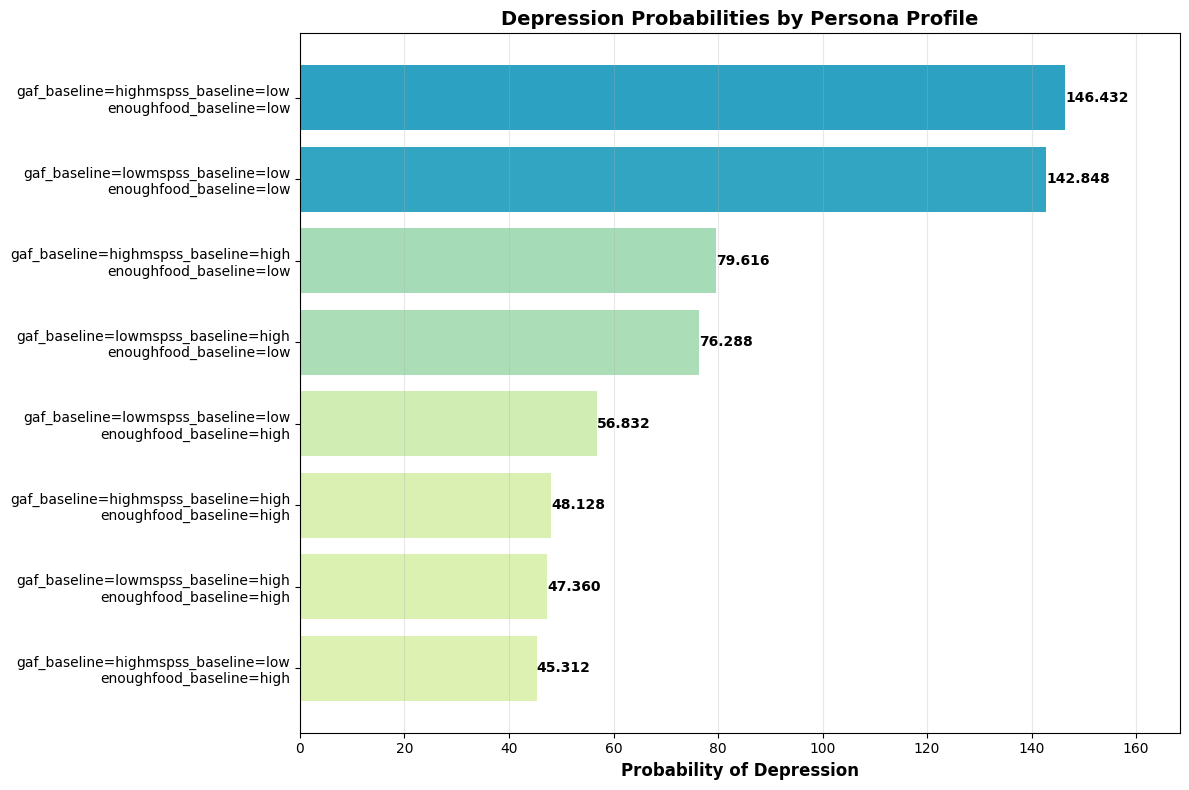


TREATMENT VARIABLE ANALYSIS
Logistic Regression:
  Treatment selected: 0/5 folds
  Average F-score: 7.592
  Average rank: 47.6
LASSO Logistic:
  Treatment selected: 0/5 folds
  Average F-score: 7.592
  Average rank: 47.6
Random Forest:
  Treatment selected: 0/5 folds
  Average F-score: 7.592
  Average rank: 47.6
XGBoost:
  Treatment selected: 0/5 folds
  Average F-score: 7.592
  Average rank: 47.6
Neural Network:
  Treatment selected: 0/5 folds
  Average F-score: 7.592
  Average rank: 47.6

FINAL RESULTS SUMMARY
Best Model: XGBoost
Hold-out Performance (Calibrated):
  Accuracy: 0.726
  Precision: 0.500
  Recall: 0.344
  F1 Score: 0.407
  AUC: 0.736
  Brier Score: 0.188
  True Negatives: 74.000
  False Positives: 11.000
  False Negatives: 21.000
  True Positives: 11.000
  Specificity: 0.871
  Sensitivity: 0.344
⚠ Treatment variable was NOT selected by the best model
Overall treatment selection rate: 0/25 (0.0%)


In [74]:
# Depression at 7 years - Nested CV (FIXED VERSION)

# ========= Imports =========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import tensorflow as tf 
import logging
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from skopt import BayesSearchCV

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from tabulate import tabulate
from itertools import product
import warnings
warnings.filterwarnings("ignore")

# ========= Configuration =========
@dataclass
class Config:
    RANDOM_STATE: int = 123
    N_FEATURES: int = 15
    OUTER_SPLITS: int = 5
    INNER_SPLITS: int = 3
    N_ITER: int = 20
    TEST_SIZE: float = 0.2
    TARGET_COL: str = "depressed_7y"
    ID_COL: str = "newid"
    EXCLUDE_COLS: List[str] = None
    
    def __post_init__(self):
        if self.EXCLUDE_COLS is None:
            self.EXCLUDE_COLS = ["recurrence_7y", "depressed_7y"
    ]

config = Config()

# ========= Logging Setup =========
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ========= Data Validation =========
def validate_data(df: pd.DataFrame, target_col: str, required_cols: List[str]) -> None:
    """Validate input data quality"""
    assert not df.empty, "DataFrame is empty"
    assert target_col in df.columns, f"Target column '{target_col}' not found"
    
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    assert df[target_col].nunique() > 1, "Target has only one class"
    logger.info(f"Data validation passed. Shape: {df.shape}")

# ========= UPDATED: SMOTE Pipeline Builder =========
def build_smote_pipeline(base_model, config: Config, include_oversampling: bool = True):
    """
    Build a pipeline that uses SMOTE for oversampling instead of stratified approach
    """
    if include_oversampling:
        # Use imblearn pipeline with SMOTE
        pipeline = ImbPipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('oversample', SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)),
            ('select', SelectKBest(score_func=f_classif, k=config.N_FEATURES)),
            ('model', base_model)
        ])
    else:
        # Standard pipeline without oversampling
        pipeline = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('select', SelectKBest(score_func=f_classif, k=config.N_FEATURES)),
            ('model', base_model)
        ])
    
    return pipeline

# ========= UPDATED: Nested CV with SMOTE =========
def run_nested_cv_smote(model, param_distributions: Dict, X: pd.DataFrame, y: np.ndarray, 
                        config: Config, include_oversampling: bool = True) -> Dict[str, Any]:
    """
    Nested CV with SMOTE oversampling instead of stratified oversampling
    """
    outer_cv = StratifiedKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)
    inner_cv = StratifiedKFold(n_splits=config.INNER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)

    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    outer_scores = []
    successful_folds = 0
    feature_importance_dicts = []
    treatment_selected_count = 0
    treatment_scores = []  # Track treatment F-scores

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        logger.info(f"Processing outer fold {fold + 1}/{config.OUTER_SPLITS}")
        
        try:
            # Split data first
            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y[train_idx].copy()
            X_test_fold = X.iloc[test_idx].copy()
            y_test_fold = y[test_idx].copy()

            # Log treatment and class distribution in this fold
            if 'treat' in X_train_fold.columns:
                treat_dist = X_train_fold['treat'].value_counts()
                logger.info(f"Fold {fold+1} treatment distribution: {treat_dist.to_dict()}")
            
            class_dist = pd.Series(y_train_fold).value_counts()
            logger.info(f"Fold {fold+1} class distribution: {class_dist.to_dict()}")

            # Build SMOTE pipeline
            pipe = build_smote_pipeline(model, config, include_oversampling)
            
            # Hyperparameter search on training fold
            search_space = {f'model__{k}': v for k, v in param_distributions.items()}
            
            search = BayesSearchCV(
                pipe,
                search_spaces=search_space,
                n_iter=config.N_ITER,
                scoring='roc_auc',
                cv=inner_cv,
                n_jobs=1,
                random_state=config.RANDOM_STATE,
                error_score='raise'
            )
            
            search.fit(X_train_fold, y_train_fold)
            best_model = search.best_estimator_

            # Check if treatment was selected as a feature
            if hasattr(best_model, 'named_steps') and 'select' in best_model.named_steps:
                selector = best_model.named_steps['select']
                selected_features = X_train_fold.columns[selector.get_support()].tolist()
                feature_scores = dict(zip(X_train_fold.columns, selector.scores_))
                
                # Track treatment selection and scoring
                treat_selected = 'treat' in selected_features
                treat_score = feature_scores.get('treat', 0)
                treat_rank = sorted(feature_scores.values(), reverse=True).index(treat_score) + 1 if 'treat' in feature_scores else len(feature_scores)
                
                if treat_selected:
                    treatment_selected_count += 1
                    logger.info(f"Fold {fold+1}: Treatment variable selected! (F-score={treat_score:.3f}, rank={treat_rank})")
                else:
                    logger.info(f"Fold {fold+1}: Treatment NOT selected (F-score={treat_score:.3f}, rank={treat_rank}/{len(feature_scores)})")
                
                treatment_scores.append({
                    'fold': fold + 1,
                    'treat_score': treat_score,
                    'treat_rank': treat_rank,
                    'treat_selected': treat_selected
                })
                
                # Store feature importance info
                feature_importance_dicts.append({
                    'fold': fold + 1,
                    'selected_features': selected_features,
                    'treatment_selected': treat_selected,
                    'feature_scores': feature_scores
                })

            # Make predictions on test fold
            prob = best_model.predict_proba(X_test_fold)[:, 1]
            pred = (prob > 0.5).astype(int)
            
            y_probs[test_idx] = prob
            y_preds[test_idx] = pred
            outer_scores.append(roc_auc_score(y_test_fold, prob))
            successful_folds += 1
            
            logger.info(f"Fold {fold+1} AUC: {outer_scores[-1]:.3f}")
            
        except Exception as e:
            logger.error(f"Error in fold {fold + 1}: {e}")
            # For failed folds, use neutral predictions
            y_probs[test_idx] = 0.5
            y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
            outer_scores.append(0.5)

    # Validate results
    if successful_folds < config.OUTER_SPLITS // 2:
        raise RuntimeError(f"Too many folds failed: {successful_folds}/{config.OUTER_SPLITS}")

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    # Log treatment selection summary
    logger.info(f"Treatment variable selected in {treatment_selected_count}/{successful_folds} folds")
    if treatment_scores:
        avg_treat_score = np.mean([t['treat_score'] for t in treatment_scores])
        avg_treat_rank = np.mean([t['treat_rank'] for t in treatment_scores])
        logger.info(f"Average treatment F-score: {avg_treat_score:.3f}, average rank: {avg_treat_rank:.1f}")

    return {
        "model": search.best_estimator_ if 'search' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(outer_scores),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": treatment_selected_count,
        "treatment_scores": treatment_scores,
        "feature_importance_info": feature_importance_dicts
    }

# ========= UPDATED: Neural Network CV with SMOTE =========
def run_nn_cv_smote(X: pd.DataFrame, y: np.ndarray, config: Config) -> Dict[str, Any]:
    """Neural network CV with SMOTE oversampling"""
    outer_cv = StratifiedKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)
    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    aucs = []
    successful_folds = 0
    feature_names = X.columns.tolist()
    treatment_selected_count = 0
    treatment_scores = []

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        logger.info(f"Processing NN fold {fold + 1}/{config.OUTER_SPLITS}")
        
        try:
            # Split data first
            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y[train_idx].copy()
            X_test_fold = X.iloc[test_idx].copy()
            y_test_fold = y[test_idx].copy()

            # Apply preprocessing
            imputer = SimpleImputer(strategy='median')
            scaler = StandardScaler()
            
            X_train_imputed = imputer.fit_transform(X_train_fold)
            X_train_scaled = scaler.fit_transform(X_train_imputed)
            X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
            
            # Apply SMOTE oversampling
            smote = SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)
            X_train_df, y_train_fold = smote.fit_resample(X_train_df, y_train_fold)
            
            logger.info(f"NN Fold {fold+1}: After SMOTE - {len(X_train_df)} samples, "
                       f"class distribution: {np.bincount(y_train_fold)}")

            # Feature selection on SMOTE-processed training data
            selector = SelectKBest(score_func=f_classif, k=config.N_FEATURES)
            X_train_selected = selector.fit_transform(X_train_df.values, y_train_fold)
            
            # Check if treatment was selected
            selected_features = X_train_df.columns[selector.get_support()].tolist()
            feature_scores = dict(zip(X_train_df.columns, selector.scores_))
            
            treat_selected = 'treat' in selected_features
            treat_score = feature_scores.get('treat', 0)
            treat_rank = sorted(feature_scores.values(), reverse=True).index(treat_score) + 1 if 'treat' in feature_scores else len(feature_scores)
            
            if treat_selected:
                treatment_selected_count += 1
                logger.info(f"NN Fold {fold+1}: Treatment variable selected! (F-score={treat_score:.3f})")
            else:
                logger.info(f"NN Fold {fold+1}: Treatment NOT selected (F-score={treat_score:.3f}, rank={treat_rank})")
            
            treatment_scores.append({
                'fold': fold + 1,
                'treat_score': treat_score,
                'treat_rank': treat_rank,
                'treat_selected': treat_selected
            })
            
            # Build and train model
            model = build_nn_model(input_dim=X_train_selected.shape[1])
            
            # Compute class weights
            unique_classes = np.unique(y_train_fold)
            if len(unique_classes) > 1:
                cw_vals = compute_class_weight('balanced', classes=unique_classes, y=y_train_fold)
                class_weights = {i: w for i, w in enumerate(cw_vals)}
            else:
                class_weights = None
            
            batch_size = max(8, min(32, len(X_train_selected) // 4))
            
            history = model.fit(
                X_train_selected, y_train_fold,
                validation_split=0.2,
                epochs=100,
                batch_size=batch_size,
                callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
                class_weight=class_weights,
                verbose=0
            )

            # Transform test data and make predictions
            X_test_imputed = imputer.transform(X_test_fold)
            X_test_scaled = scaler.transform(X_test_imputed)
            X_test_selected = selector.transform(X_test_scaled)
            
            prob = model.predict(X_test_selected, verbose=0).ravel()
            pred = (prob > 0.5).astype(int)
            
            y_probs[test_idx] = prob
            y_preds[test_idx] = pred
            aucs.append(roc_auc_score(y_test_fold, prob))
            successful_folds += 1
            
        except Exception as e:
            logger.error(f"Error in NN fold {fold + 1}: {e}")
            y_probs[test_idx] = 0.5
            y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
            aucs.append(0.5)

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid NN predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    logger.info(f"NN: Treatment variable selected in {treatment_selected_count}/{successful_folds} folds")
    if treatment_scores:
        avg_treat_score = np.mean([t['treat_score'] for t in treatment_scores])
        avg_treat_rank = np.mean([t['treat_rank'] for t in treatment_scores])
        logger.info(f"NN: Average treatment F-score: {avg_treat_score:.3f}, average rank: {avg_treat_rank:.1f}")

    return {
        "model": model if 'model' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(aucs),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": treatment_selected_count,
        "treatment_scores": treatment_scores
    }

# ========= Leak-Free Preprocessor (Unchanged) =========
class LeakFreePreprocessor:
    """
    Preprocessing that prevents data leakage by fitting only on training folds
    """
    
    def __init__(self, config: Config):
        self.config = config
        self.imputer = None
        self.scaler = None
        self.label_encoder = None
        self.feature_names = None
        
    def fit(self, X: pd.DataFrame, y: pd.Series) -> 'LeakFreePreprocessor':
        """Fit preprocessor components separately to allow proper CV"""
        self.feature_names = X.columns.tolist()
        
        # Fit components
        self.imputer = SimpleImputer(strategy='median')
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        
        # Fit on training data
        X_imputed = self.imputer.fit_transform(X)
        self.scaler.fit(X_imputed)
        self.label_encoder.fit(y)
        
        logger.info(f"Preprocessor fitted on {X.shape[0]} samples, {X.shape[1]} features")
        return self
    
    def transform_features(self, X):
        """Transform features using fitted preprocessor"""
        if isinstance(X, pd.DataFrame):
            X_ordered = X.reindex(columns=self.feature_names, fill_value=np.nan)
            X_values = X_ordered.values
        else:
            X_values = X
            
        X_imputed = self.imputer.transform(X_values)
        X_scaled = self.scaler.transform(X_imputed)
        return X_scaled
    
    def transform_target(self, y: pd.Series) -> np.ndarray:
        """Transform target using fitted label encoder"""
        return self.label_encoder.transform(y)
    
    def get_feature_names(self) -> List[str]:
        """Get original feature names"""
        return self.feature_names.copy()

# ========= Neural Network Builder (Unchanged) =========
def build_nn_model(input_dim: int, neurons1: int = 64, neurons2: int = 32, 
                   dropout: float = 0.3, learning_rate: float = 1e-3) -> tf.keras.Model:
    """Build neural network with improved architecture"""
    model = Sequential([
        Dense(neurons1, activation='relu', input_dim=input_dim,
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(neurons2, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model

# ========= Utility Functions (Enhanced with Treatment Tracking) =========
def calculate_holdout_metrics(y_true: np.ndarray, y_pred: np.ndarray, 
                            y_proba: np.ndarray) -> Dict[str, float]:
    """Calculate comprehensive holdout metrics including confusion matrix components"""
    cm = confusion_matrix(y_true, y_pred)
    
    # Extract confusion matrix components
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true, y_proba),
        'Brier Score': brier_score_loss(y_true, y_proba),
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0
    }

def plot_performance_curves(results: Dict, y_true: np.ndarray, feature_names, title_suffix: str = ""):
    """Generate ROC, calibration curves, and confusion matrix with treatment selection info"""
    plt.figure(figsize=(16, 12))  # Adjusted size for 2x2 layout
    
    # ROC Curves (Top Left)
    plt.subplot(2, 2, 1)
    for name, res in results.items():
        if res and 'y_probs' in res:
            try:
                valid_mask = res['y_probs'] >= 0
                if np.any(valid_mask):
                    y_valid = y_true[valid_mask]
                    probs_valid = res['y_probs'][valid_mask]
                    fpr, tpr, _ = roc_curve(y_valid, probs_valid)
                    auc = roc_auc_score(y_valid, probs_valid)
                    
                    # Enhanced label with treatment selection info
                    treat_count = res.get('treatment_selected_count', 0)
                    total_folds = res.get('successful_folds', 0)
                    label = f"{name} (AUC={auc:.3f}, Treat: {treat_count}/{total_folds})"
                    
                    plt.plot(fpr, tpr, label=label)
                        
            except Exception as e:
                logger.warning(f"Error plotting ROC for {name}: {e}")
    
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves {title_suffix}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)

    # Calibration Curves (Top Right)
    plt.subplot(2, 2, 2)
    for name, res in results.items():
        if res and 'y_probs' in res:
            try:
                valid_mask = res['y_probs'] >= 0
                if np.any(valid_mask):
                    y_valid = y_true[valid_mask]
                    probs_valid = res['y_probs'][valid_mask]
                    fraction_of_positives, mean_predicted_value = calibration_curve(
                        y_valid, probs_valid, n_bins=10
                    )
                    plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label=name)
            except Exception as e:
                logger.warning(f"Error plotting calibration for {name}: {e}")
    
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title(f"Calibration Curves {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Feature Importance (Bottom Left)
    plt.subplot(2, 2, 3)
    best_model_name = max(results.keys(), key=lambda k: results[k]['metrics']['AUC'] 
                         if results[k] and 'metrics' in results[k] else 0)
    best_model = results[best_model_name]['model']
    
    if best_model and hasattr(best_model, 'named_steps'):
        try:
            selector = best_model.named_steps['select']
            scores = selector.scores_
            top_idx = np.argsort(scores)[-10:]
            top_feats = [feature_names[i] for i in top_idx]
            
            # Highlight treatment variable if selected
            colors = ['red' if feat == 'treat' else 'blue' for feat in top_feats]
            plt.barh(range(len(top_idx)), scores[top_idx], color=colors, alpha=0.7)
            
            plt.yticks(range(len(top_idx)), top_feats)
            plt.xlabel("F-score")
            plt.title("Top Selected Features (Red=Treatment)")
        except Exception:
            plt.text(0.5, 0.5, "Feature importance\nnot available", 
                    ha='center', va='center', transform=plt.gca().transAxes)
    
    # Confusion Matrix for Best Model (Bottom Right)
    plt.subplot(2, 2, 4)
    if best_model_name in results and results[best_model_name]:
        try:
            res = results[best_model_name]
            valid_mask = res['y_probs'] >= 0
            if np.any(valid_mask):
                y_valid = y_true[valid_mask]
                y_pred_valid = res['y_preds'][valid_mask]
                
                cm = confusion_matrix(y_valid, y_pred_valid)
                disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                            display_labels=['No Depression', 'Depression'])
                disp.plot(ax=plt.gca(), cmap='Blues', values_format='d')
                plt.title(f"Confusion Matrix\n{best_model_name}")
        except Exception as e:
            logger.warning(f"Error plotting confusion matrix: {e}")
            plt.text(0.5, 0.5, "Confusion Matrix\nnot available", 
                    ha='center', va='center', transform=plt.gca().transAxes)
    
    plt.tight_layout()
    plt.show()

# ========= Holdout Confusion Matrix Function =========

def plot_holdout_confusion_matrices(y_true, preds_unc, preds_cal, probs_unc, probs_cal, best_name):
    """Plot confusion matrices for holdout predictions"""
    plt.figure(figsize=(15, 5))
    
    # Uncalibrated Confusion Matrix
    plt.subplot(1, 3, 1)
    cm_unc = confusion_matrix(y_true, preds_unc)
    disp_unc = ConfusionMatrixDisplay(confusion_matrix=cm_unc, 
                                     display_labels=['No Depression', 'Depression'])
    disp_unc.plot(ax=plt.gca(), cmap='Blues', values_format='d')
    plt.title(f"Uncalibrated\n{best_name}")
    
    # Calibrated Confusion Matrix
    plt.subplot(1, 3, 2)
    cm_cal = confusion_matrix(y_true, preds_cal)
    disp_cal = ConfusionMatrixDisplay(confusion_matrix=cm_cal, 
                                     display_labels=['No Depression', 'Depression'])
    disp_cal.plot(ax=plt.gca(), cmap='Greens', values_format='d')
    plt.title(f"Calibrated\n{best_name}")
    
    # ROC Comparison
    plt.subplot(1, 3, 3)
    fpr_unc, tpr_unc, _ = roc_curve(y_true, probs_unc)
    fpr_cal, tpr_cal, _ = roc_curve(y_true, probs_cal)
    
    auc_unc = roc_auc_score(y_true, probs_unc)
    auc_cal = roc_auc_score(y_true, probs_cal)
    
    plt.plot(fpr_unc, tpr_unc, label=f'Uncalibrated (AUC={auc_unc:.3f})', color='blue')
    plt.plot(fpr_cal, tpr_cal, label=f'Calibrated (AUC={auc_cal:.3f})', color='green')
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Holdout ROC Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def perform_shap_analysis(best_model, X_holdout: np.ndarray, feature_names: List[str],
                         preprocessor: LeakFreePreprocessor, holdout_raw: pd.DataFrame):
    """Perform SHAP analysis with proper error handling"""
    try:
        logger.info("Performing SHAP analysis...")
        
        model_obj = best_model.named_steps['model']
        if not hasattr(model_obj, 'predict_proba'):
            logger.warning("Model doesn't support probability prediction, skipping SHAP")
            return None
        
        selector = best_model.named_steps['select']
        X_selected = selector.transform(X_holdout)
        selected_feature_names = [feature_names[i] for i in selector.get_support(indices=True)]
        
        # Highlight if treatment is selected
        treat_selected = 'treat' in selected_feature_names
        logger.info(f"Treatment variable selected for SHAP: {treat_selected}")
        
        n_background = min(100, X_selected.shape[0])
        background_data = X_selected[:n_background]
        
        if hasattr(model_obj, 'tree_'):
            explainer = shap.TreeExplainer(model_obj)
            shap_values = explainer.shap_values(background_data)
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        else:
            explainer = shap.Explainer(model_obj.predict_proba, background_data)
            shap_values = explainer(background_data)
            if hasattr(shap_values, 'values'):
                shap_values = shap_values.values[:, :, 1]
        
        shap_abs = np.abs(shap_values).mean(axis=0)
        top_n = min(15, len(selected_feature_names))
        top_idx = np.argsort(shap_abs)[-top_n:]
        
        plt.figure(figsize=(10, 8))
        colors = ['red' if selected_feature_names[i] == 'treat' else 'blue' for i in top_idx]
        plt.barh(range(len(top_idx)), shap_abs[top_idx], color=colors, alpha=0.7)
        plt.yticks(range(len(top_idx)), [selected_feature_names[i] for i in top_idx])
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"Top {top_n} SHAP Features (Hold-out) - Red: Treatment")
        plt.tight_layout()
        plt.show()
        
        try:
            shap.summary_plot(
                shap_values, 
                features=background_data, 
                feature_names=selected_feature_names,
                show=False
            )
            plt.tight_layout()
            plt.show()
        except Exception as e:
            logger.warning(f"Error creating SHAP summary plot: {e}")
            
    except Exception as e:
        logger.error(f"Error in SHAP analysis: {e}")
        return None

    return {
        'selector': selector,
        'shap_values': shap_values if 'shap_values' in locals() else None,
        'selected_feature_names': selected_feature_names if 'selected_feature_names' in locals() else []
    }

# ========= FIXED: Main Pipeline =========
def main():
    """FIXED: Main execution pipeline without data leakage"""

    # 1. Load & validate
    try:
        df = pd.read_csv("complete_data_mice_7y_dep.csv")
        logger.info(f"Data loaded: {df.shape}")
        required = [config.TARGET_COL, config.ID_COL] + config.EXCLUDE_COLS + ['treat']
        validate_data(df, config.TARGET_COL, required)
    except Exception as e:
        logger.error(f"Loading/validation error: {e}")
        return

    # 2. Quick QC
    logger.info(f"Target counts:\n{df[config.TARGET_COL].value_counts()}")
    logger.info(f"Missing values: {df.isnull().sum().sum()}")

    # 3. CRITICAL: Train/hold-out split FIRST, before any processing
    train_df, holdout_df = train_test_split(
        df,
        test_size=config.TEST_SIZE,
        stratify=df[config.TARGET_COL],
        random_state=config.RANDOM_STATE
    )
    logger.info(f"Train={len(train_df)}, Hold-out={len(holdout_df)}")

    # 4. Prepare training data (keep as DataFrame to preserve column names)
    X_train = train_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    y_train = train_df[config.TARGET_COL].values
    feature_names = X_train.columns.tolist()

    # 5. Define models & parameters
    models_and_params = {
        "Logistic Regression": (
            LogisticRegression(max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.01, 0.1, 1.0, 10.0]}
        ),
        "LASSO Logistic": (
            LogisticRegression(penalty='l1', solver='liblinear',
                               max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.001, 0.01, 0.1, 1, 10]}
        ),
        "Random Forest": (
            RandomForestClassifier(class_weight='balanced',
                                   random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "max_depth": [3, 5, 10],
             "min_samples_split": [5, 10],
             "min_samples_leaf": [2, 5]}
        ),
        "XGBoost": (
            XGBClassifier(use_label_encoder=False,
                          eval_metric='logloss',
                          random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "learning_rate": [0.01, 0.1],
             "max_depth": [3, 6],
             "subsample": [0.8, 1.0]}
        )
    }

    # 6. Run nested CV with SMOTE (using the correct function names)
    results = {}
    for name, (model, params) in models_and_params.items():
        logger.info(f"→ Nested CV: {name}")
        try:
            results[name] = run_nested_cv_smote(
                model, params, X_train, y_train, config, include_oversampling=True
            )
            logger.info(f"   AUC={results[name]['metrics']['AUC']:.3f}")
        except Exception as e:
            logger.error(f"   {name} failed: {e}")

    # 7. Neural network with SMOTE
    try:
        logger.info("→ Nested CV: Neural Network")
        results['Neural Network'] = run_nn_cv_smote(X_train, y_train, config)
        logger.info(f"   AUC={results['Neural Network']['metrics']['AUC']:.3f}")
    except Exception as e:
        logger.error(f"   NN failed: {e}")

    # 8. Show performance table with treatment selection info
    perf_rows = []
    for m, res in results.items():
        if res and 'metrics' in res:
            row = {"Model": m}
            row.update({k: round(v, 3) for k, v in res['metrics'].items()})
            row["Folds"] = res.get('successful_folds', 'N/A')
            row["Treat_Selected"] = f"{res.get('treatment_selected_count', 0)}/{res.get('successful_folds', 0)}"
            perf_rows.append(row)
    perf_df = pd.DataFrame(perf_rows)
    print("\nNested CV Performance (with Treatment Selection)")
    print(tabulate(perf_df, headers='keys', tablefmt='grid', showindex=False))

    # 9. Fit preprocessor on full training data for final model preparation
    preprocessor = LeakFreePreprocessor(config)
    preprocessor.fit(X_train, train_df[config.TARGET_COL])
    
    # Transform training data
    X_train_proc = preprocessor.transform_features(X_train)
    X_train_df = pd.DataFrame(X_train_proc, columns=feature_names)
    y_train_processed = preprocessor.transform_target(train_df[config.TARGET_COL])
    
    # Apply SMOTE oversampling for final model training
    smote = SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)
    X_train_final, y_res = smote.fit_resample(X_train_df, y_train_processed)
    logger.info(f"Final training data after SMOTE: {X_train_final.shape}, class distribution: {np.bincount(y_res)}")

    # 10. Plot OOF ROC + calibration
    plot_performance_curves(results, y_train, feature_names, title_suffix="(SMOTE Train)")

    # 11. Refit best pipeline on full SMOTE-resampled train data
    if not results:
        logger.error("No successful models to select from")
        return
        
    best_name = max(results, key=lambda k: results[k]['metrics']['AUC'] if results[k] else 0)
    best_result = results[best_name]
    
    if not best_result or 'model' not in best_result:
        logger.error(f"Best model {best_name} has no trained model")
        return
        
    # Build and fit new pipeline on full resampled data
    best_pipe = build_smote_pipeline(
        models_and_params[best_name][0], config, include_oversampling=False
    )
    best_pipe.fit(X_train_final, y_res)
    logger.info(f"Refitted best: {best_name}")

    # 12. Calibrate via Platt scaling
    X_sel_train = best_pipe.named_steps['select'].transform(X_train_final)
    calibrator = CalibratedClassifierCV(
        best_pipe.named_steps['model'],
        method='sigmoid',
        cv=3  # Use CV instead of prefit since we have enough data
    )
    calibrator.fit(X_sel_train, y_res)
    logger.info("Calibration on train completed")

    # 13. Prepare hold-out
    X_hold = holdout_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    X_hold_proc = preprocessor.transform_features(X_hold)  # (n_hold, n_feats)
    y_hold = preprocessor.transform_target(holdout_df[config.TARGET_COL])

    # 14a) uncalibrated on full pipeline:
    probs_unc = best_pipe.predict_proba(X_hold_proc)[:,1]

    # 14b) calibrated: first select, then calibrator
    selector = best_pipe.named_steps['select']
    X_hold_sel = selector.transform(X_hold_proc)  # (n_hold, k_features)
    probs_cal = calibrator.predict_proba(X_hold_sel)[:, 1]

    # 15) threshold & metrics
    preds_unc = (probs_unc > 0.5).astype(int)
    preds_cal = (probs_cal > 0.5).astype(int)
    hold_unc = calculate_holdout_metrics(y_hold, preds_unc, probs_unc)
    hold_cal = calculate_holdout_metrics(y_hold, preds_cal, probs_cal)
    
    print(f"\nHold-out Performance:")
    print(f"Uncalibrated: AUC={hold_unc['AUC']:.3f}, F1={hold_unc['F1 Score']:.3f}")
    print(f"Calibrated:   AUC={hold_cal['AUC']:.3f}, F1={hold_cal['F1 Score']:.3f}")

    # Plot holdout confusion matrices
    plot_holdout_confusion_matrices(y_hold, preds_unc, preds_cal, probs_unc, probs_cal, best_name)
    
    # Print detailed confusion matrix metrics
    print(f"\nDetailed Holdout Metrics:")
    print(f"{'Metric':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC', 'Specificity', 'Sensitivity']:
        print(f"{metric:<15} {hold_unc[metric]:<12.3f} {hold_cal[metric]:<12.3f}")
    
    print(f"\nConfusion Matrix Components:")
    print(f"{'Component':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for component in ['True Positives', 'False Positives', 'True Negatives', 'False Negatives']:
        print(f"{component:<15} {hold_unc[component]:<12} {hold_cal[component]:<12}")
        
    # 16. SHAP + Personas
    shap_info = perform_shap_analysis(
    best_pipe,
    X_hold_proc,
    feature_names,
    preprocessor,
    holdout_df
)

    if shap_info and shap_info['shap_values'] is not None:
        selector_ = shap_info['selector']
        sv = shap_info['shap_values']
        feats = shap_info['selected_feature_names']
        abs_mean = np.abs(sv).mean(axis=0)
        
        if len(feats) >= 3:
            print("\nGenerating SHAP Personas…")
            raw_df = train_df.drop(columns=config.EXCLUDE_COLS + [config.ID_COL])
            raw_median = raw_df.median()
            raw_min = raw_df.min()
            raw_max = raw_df.max()
            
            # pick top-3 by |SHAP|
            top3_idx = np.argsort(abs_mean)[-3:]
            top3_feats = [feats[i] for i in top3_idx]
            
            print(f"Top 3 SHAP features: {top3_feats}")
            
            # Create a custom preprocessor-selector-calibrator pipeline for personas
            class PersonaPipeline:
                def __init__(self, preprocessor, selector, calibrator):
                    self.preprocessor = preprocessor
                    self.selector = selector
                    self.calibrator = calibrator
                
                def predict_proba(self, X_raw):
                    # Preprocess raw data
                    X_proc = self.preprocessor.transform_features(X_raw)
                    # Select features
                    X_sel = self.selector.transform(X_proc)
                    # Get calibrated probabilities
                    return self.calibrator.predict_proba(X_sel)
            
            final_pipe = PersonaPipeline(preprocessor, selector_, calibrator)
            
            prototypes = []
            for combo in product(['low','high'], repeat=3):
                row = raw_median.copy()
                desc = []
                for feat, lvl in zip(top3_feats, combo):
                    row[feat] = raw_min[feat] if lvl=='low' else raw_max[feat]
                    desc.append(f"{feat}={lvl}")
                
                # Create DataFrame with correct column order matching feature_names
                arr_df = pd.DataFrame([row.reindex(feature_names)])
                try:
                    p = final_pipe.predict_proba(arr_df)[0,1]
                    prototypes.append({
                        'Profile': ' & '.join(desc),
                        'P(depression)': round(p, 3)
                    })
                except Exception as e:
                    logger.warning(f"Error generating persona for {desc}: {e}")
            
            if prototypes:
                proto_df = pd.DataFrame(prototypes)
                print("\nTop-3 SHAP Personas:")
                print(proto_df.to_string(index=False))
                
                try:
                    # Create figure with larger size to accommodate labels
                    plt.figure(figsize=(14, 8))
                    
                    # Function to format long labels with line breaks
                    def format_label(label, max_chars_per_line=30):
                        """Break long labels into multiple lines"""
                        parts = label.split(' & ')
                        formatted_parts = []
                        current_line = ""
                        
                        for part in parts:
                            if len(current_line + part) <= max_chars_per_line:
                                current_line += part + " & " if current_line else part
                            else:
                                if current_line:
                                    formatted_parts.append(current_line.rstrip(" & "))
                                current_line = part + " & "
                        
                        if current_line:
                            formatted_parts.append(current_line.rstrip(" & "))
                        
                        return '\n'.join(formatted_parts)
                    
                    # Format the profile labels
                    formatted_labels = [format_label(profile) for profile in proto_df['Profile']]
                    
                    # Create the heatmap with formatted labels
                    heatmap_data = proto_df.set_index('Profile')[['P(depression)']].T
                    heatmap_data.columns = formatted_labels
                    
                    ax = sns.heatmap(
                        heatmap_data,
                        annot=True, 
                        cmap='YlGnBu', 
                        fmt='.3f',
                        cbar_kws={'label': 'Probability of Depression'},
                        annot_kws={'size': 10, 'weight': 'bold'}
                    )
                    
                    # Rotate x-axis labels for better readability
                    plt.xticks(rotation=45, ha='right')
                    plt.yticks(rotation=0)
                    
                    # Adjust layout and titles
                    plt.title("Depression Probabilities by Persona Profile", 
                            fontsize=14, fontweight='bold', pad=20)
                    plt.xlabel("Persona Profiles", fontsize=12, fontweight='bold')
                    plt.ylabel("Prediction", fontsize=12, fontweight='bold')
                    
                    # Adjust layout to prevent label cutoff
                    plt.tight_layout()
                    plt.subplots_adjust(bottom=0.25)  # Add extra space at bottom for labels
                    
                    plt.show()
                    
                    # Alternative: Create a horizontal bar chart for better label visibility
                    plt.figure(figsize=(12, 8))
                    
                    # Sort by probability for better visualization
                    sorted_df = proto_df.sort_values('P(depression)', ascending=True)
                    formatted_labels_sorted = [format_label(profile, max_chars_per_line=50) 
                                            for profile in sorted_df['Profile']]
                    
                    bars = plt.barh(range(len(sorted_df)), sorted_df['P(depression)'], 
                                color=plt.cm.YlGnBu(sorted_df['P(depression)']))
                    
                    # Add value labels on bars
                    for i, (bar, prob) in enumerate(zip(bars, sorted_df['P(depression)'])):
                        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                                f'{prob:.3f}', va='center', fontweight='bold')
                    
                    plt.yticks(range(len(sorted_df)), formatted_labels_sorted)
                    plt.xlabel('Probability of Depression', fontsize=12, fontweight='bold')
                    plt.title('Depression Probabilities by Persona Profile', 
                            fontsize=14, fontweight='bold')
                    plt.grid(axis='x', alpha=0.3)
                    
                    # Set x-axis limits for better visibility
                    plt.xlim(0, max(sorted_df['P(depression)']) * 1.15)
                    
                    plt.tight_layout()
                    plt.show()
                    
                except Exception as e:
                    logger.warning(f"Error creating persona visualizations: {e}")
    else:
        logger.warning("SHAP analysis failed or returned no results. Skipping persona generation.")

    # 17. Treatment analysis summary
    print(f"\n{'='*60}")
    print("TREATMENT VARIABLE ANALYSIS")
    print(f"{'='*60}")
    
    for model_name, result in results.items():
        if result and 'treatment_scores' in result:
            treat_count = result.get('treatment_selected_count', 0)
            total_folds = result.get('successful_folds', 0)
            treat_scores = result.get('treatment_scores', [])
            
            if treat_scores:
                avg_score = np.mean([t['treat_score'] for t in treat_scores])
                avg_rank = np.mean([t['treat_rank'] for t in treat_scores])
                print(f"{model_name}:")
                print(f"  Treatment selected: {treat_count}/{total_folds} folds")
                print(f"  Average F-score: {avg_score:.3f}")
                print(f"  Average rank: {avg_rank:.1f}")
    
    # 18. Final summary
    print(f"\n{'='*60}")
    print("FINAL RESULTS SUMMARY")
    print(f"{'='*60}")
    print(f"Best Model: {best_name}")
    print(f"Hold-out Performance (Calibrated):")
    for metric, value in hold_cal.items():
        print(f"  {metric}: {value:.3f}")
    
    # Check if treatment was selected in best model
    if shap_info and 'selected_feature_names' in shap_info and 'treat' in shap_info['selected_feature_names']:
        print("✓ Treatment variable was selected by the best model")
    else:
        print("⚠ Treatment variable was NOT selected by the best model")
    
    # Overall treatment selection rate
    total_treat_selections = sum(r.get('treatment_selected_count', 0) for r in results.values() if r)
    total_folds = sum(r.get('successful_folds', 0) for r in results.values() if r)
    if total_folds > 0:
        overall_rate = total_treat_selections / total_folds
        print(f"Overall treatment selection rate: {total_treat_selections}/{total_folds} ({overall_rate:.1%})")
    
    print(f"{'='*60}")

if __name__ == "__main__":
    main()

2025-07-28 17:18:14,202 - INFO - Data loaded: (585, 89)
2025-07-28 17:18:14,207 - INFO - Data validation passed. Shape: (585, 89)
2025-07-28 17:18:14,207 - INFO - Clusters: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40)]
2025-07-28 17:18:14,208 - INFO - Cluster sizes: min=9, max=19, mean=14.6
2025-07-28 17:18:14,209 - INFO - Target distribution: {0: 426, 1: 159}
2025-07-28 17:18:14,210 - INFO - Target counts:
depressed_7y
0    426
1    159
Name: count, dtype: int64
2025-07-28 17:18:14,211 - 


Nested CV Performance (Group Stratified)
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+
| Model               |   Accuracy |   Precision |   Recall |   F1 Score |   AUC |   Brier Score |   Folds |
+=====================+============+=============+==========+============+=======+===============+=========+
| Logistic Regression |      0.647 |       0.398 |    0.578 |      0.471 | 0.698 |         0.219 |       5 |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+
| LASSO Logistic      |      0.647 |       0.407 |    0.648 |      0.5   | 0.69  |         0.232 |       5 |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+
| Random Forest       |      0.653 |       0.401 |    0.555 |      0.466 | 0.677 |         0.21  |       5 |
+---------------------+------------+-------------+----------+------------+-------+----

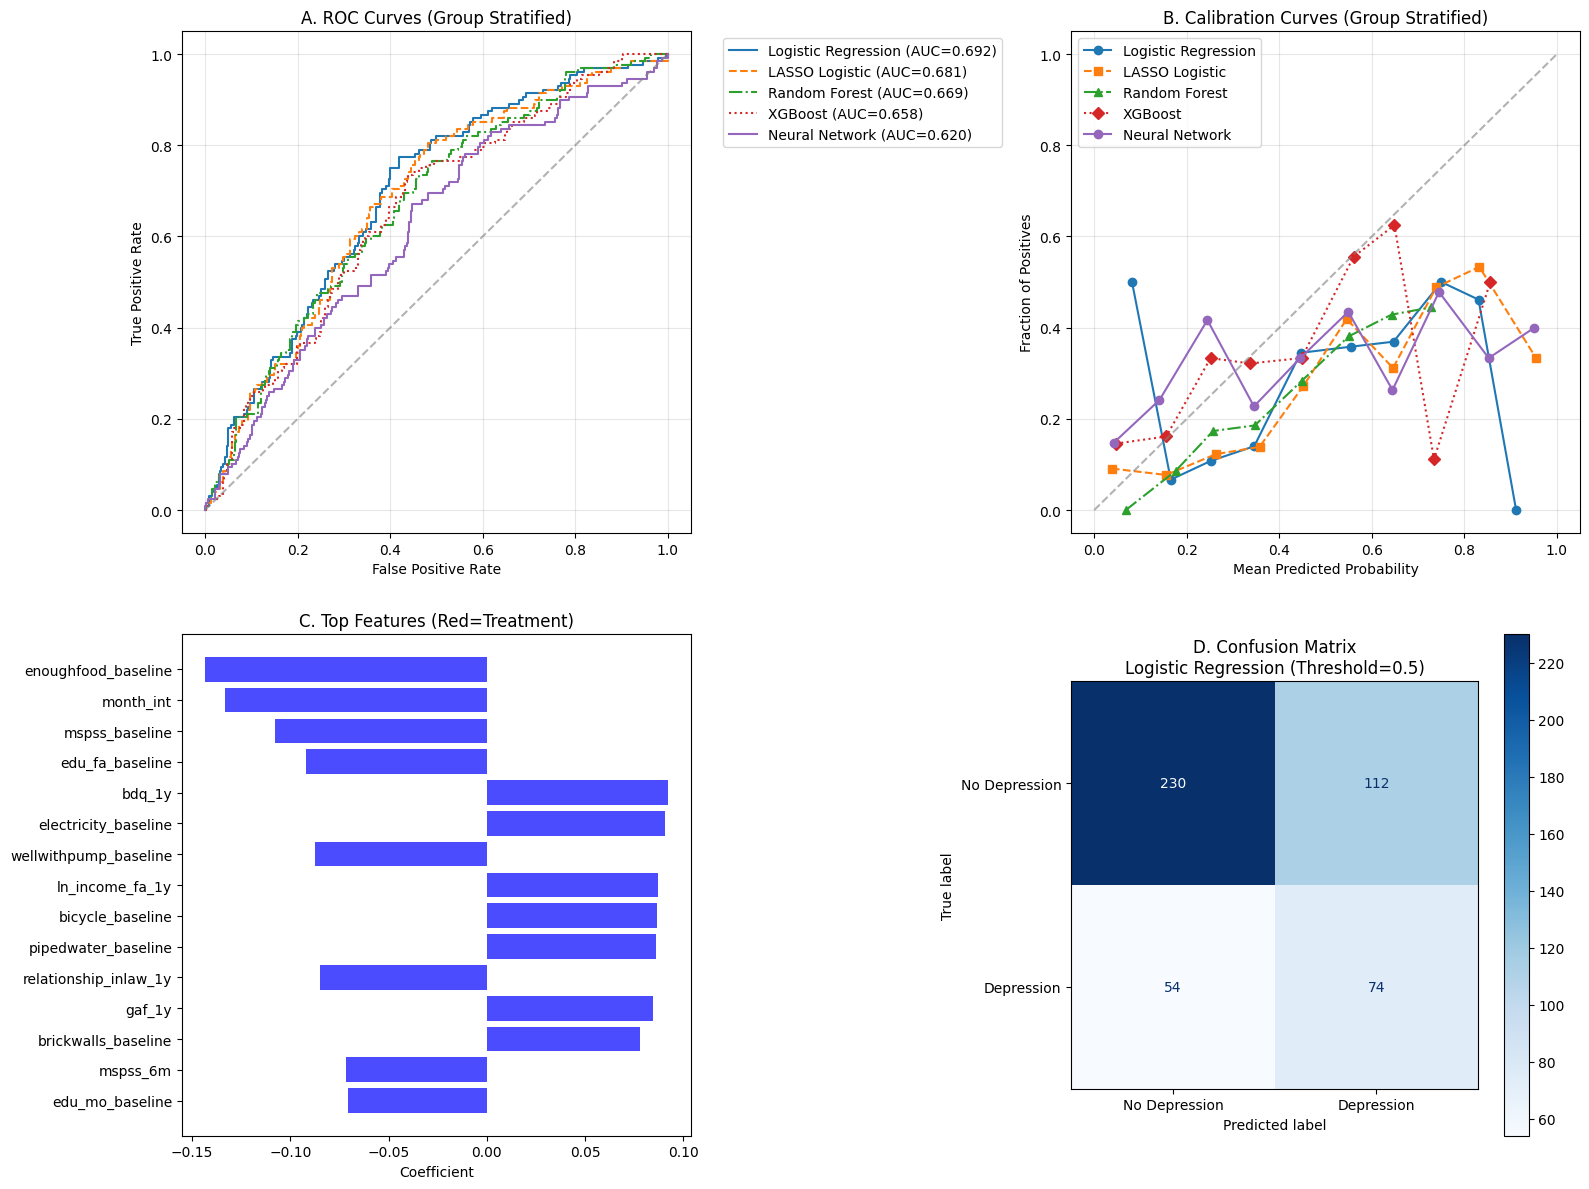

2025-07-28 17:20:46,804 - INFO - Refitted best: Logistic Regression
2025-07-28 17:20:46,843 - INFO - Calibration on train completed


Spearman correlation between calibrated and uncalibrated probabilities: 0.9840

Hold-out Performance:
Uncalibrated: AUC=0.652, F1=0.462
Calibrated:   AUC=0.658, F1=0.000


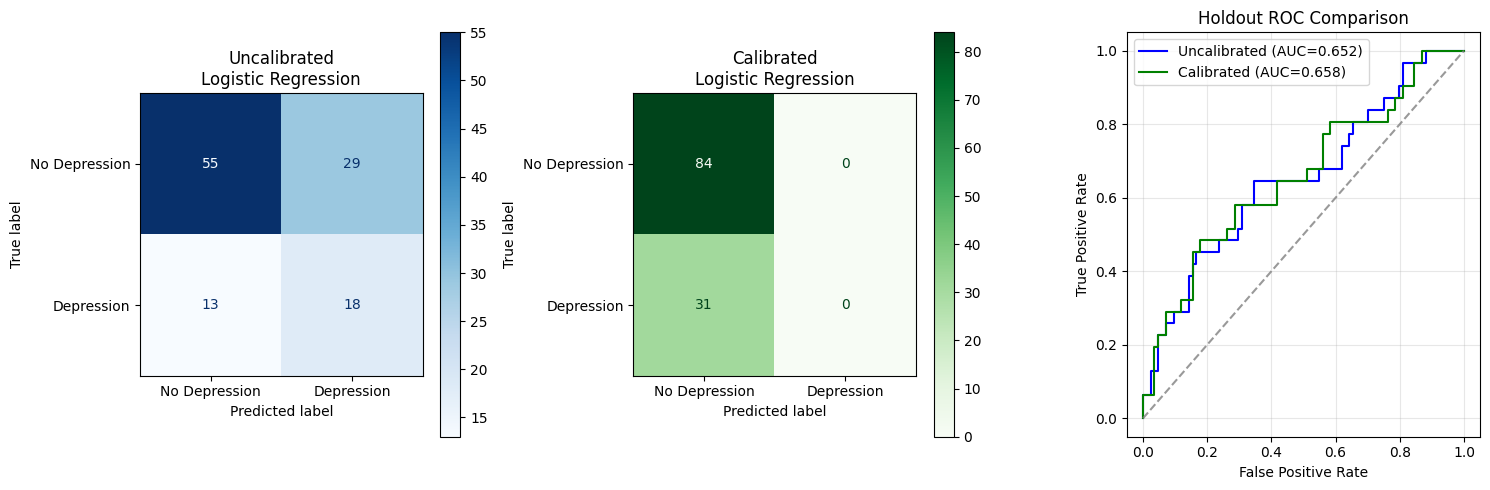

2025-07-28 17:20:47,069 - INFO - Performing SHAP analysis...
2025-07-28 17:20:47,069 - INFO - Treatment variable included in SHAP: True



Detailed Holdout Metrics:
Metric          Uncalibrated Calibrated  
---------------------------------------
Accuracy        0.635        0.730       
Precision       0.383        0.000       
Recall          0.581        0.000       
F1 Score        0.462        0.000       
AUC             0.652        0.658       
Specificity     0.655        1.000       
Sensitivity     0.581        0.000       

Confusion Matrix Components:
Component       Uncalibrated Calibrated  
---------------------------------------
True Positives  18           0           
False Positives 29           0           
True Negatives  55           84          
False Negatives 13           31          


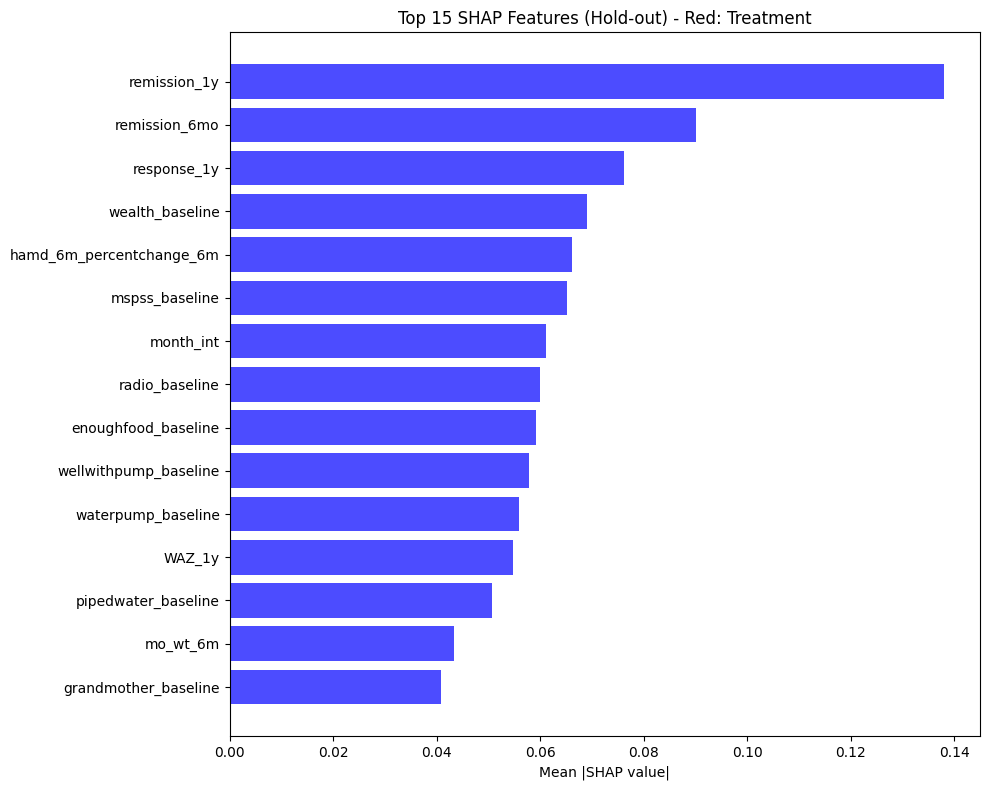

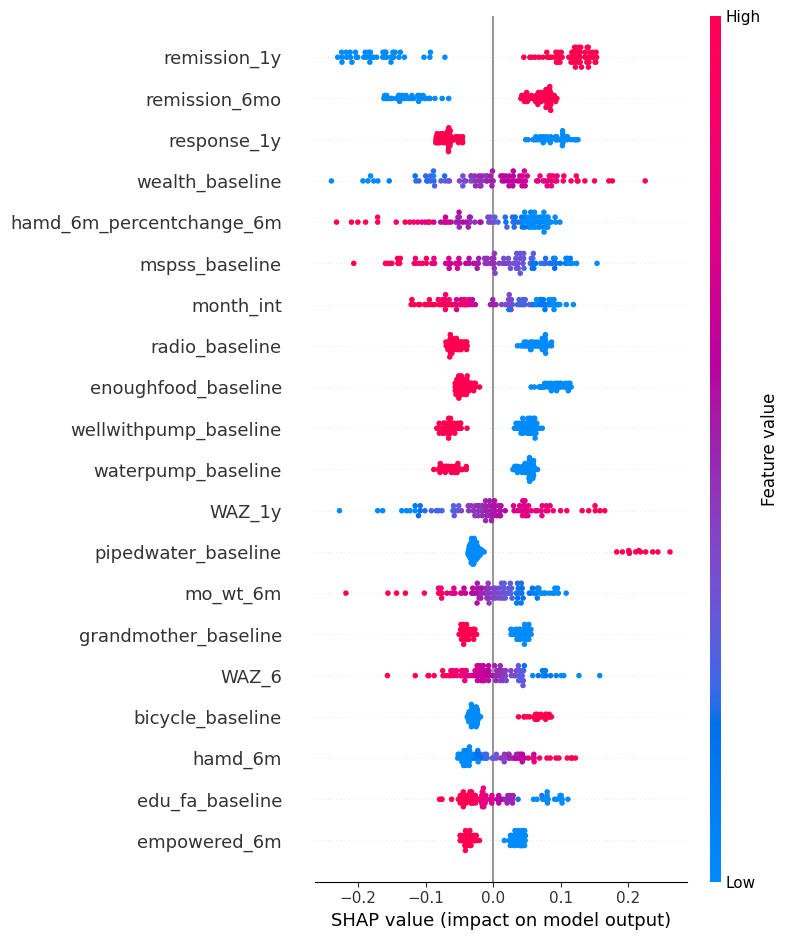


Generating SHAP Personas...
Top 3 SHAP features: ['response_1y', 'remission_6mo', 'remission_1y']

Top-3 SHAP Personas:
                                                  Profile  P(depressed)
   response_1y=low & remission_6mo=low & remission_1y=low         0.206
  response_1y=low & remission_6mo=low & remission_1y=high         0.260
  response_1y=low & remission_6mo=high & remission_1y=low         0.243
 response_1y=low & remission_6mo=high & remission_1y=high         0.300
  response_1y=high & remission_6mo=low & remission_1y=low         0.181
 response_1y=high & remission_6mo=low & remission_1y=high         0.229
 response_1y=high & remission_6mo=high & remission_1y=low         0.216
response_1y=high & remission_6mo=high & remission_1y=high         0.268


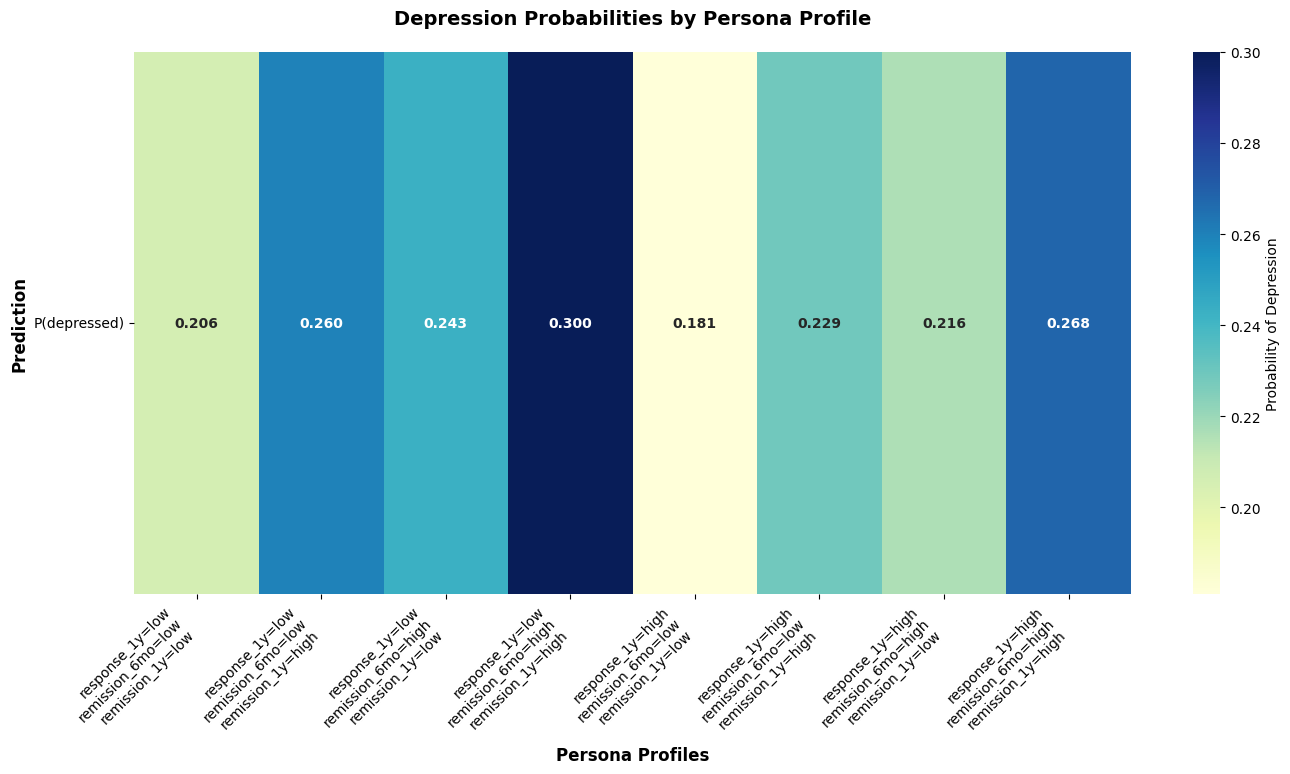

2025-07-28 17:20:48,612 - WARNING - Error creating persona visualizations: 'P(depression)'



TREATMENT VARIABLE ANALYSIS
Logistic Regression:
  Total folds: 5
  Average coefficient: 0.044
  Average importance: 0.000
LASSO Logistic:
  Total folds: 5
  Average coefficient: 0.018
  Average importance: 0.000
Random Forest:
  Total folds: 5
  Average coefficient: 0.000
  Average importance: 0.001
XGBoost:
  Total folds: 5
  Average coefficient: 0.000
  Average importance: 0.007
Neural Network:
  Total folds: 5
  Average coefficient: 0.000
  Average importance: 0.000

FINAL RESULTS SUMMARY
Best Model: Logistic Regression
Hold-out Performance (Calibrated):
  Accuracy: 0.730
  Precision: 0.000
  Recall: 0.000
  F1 Score: 0.000
  AUC: 0.658
  Brier Score: 0.187
  True Negatives: 84.000
  False Positives: 0.000
  False Negatives: 31.000
  True Positives: 0.000
  Specificity: 1.000
  Sensitivity: 0.000
✓ Treatment variable was included in the model
  Treatment coefficient: 0.211
Training method: Cluster-stratified CV (no SMOTE, no feature selection)
Number of features used: 85


<Figure size 1200x800 with 0 Axes>

In [32]:
# Depression at 7 years - no SMOTE, no univariate selection, cluster-stratified CV

# ========= Imports =========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import tensorflow as tf 
import logging
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GroupKFold, StratifiedGroupKFold
from skopt import BayesSearchCV

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from tabulate import tabulate
from itertools import product
import warnings
warnings.filterwarnings("ignore")

# ========= Configuration =========
@dataclass
class Config:
    RANDOM_STATE: int = 123
    N_FEATURES: int = 15
    OUTER_SPLITS: int = 5
    INNER_SPLITS: int = 3
    N_ITER: int = 20
    TEST_SIZE: float = 0.2
    TARGET_COL: str = "depressed_7y"
    CLUSTER_COL: str = "uc"  # cluster column for stratification
    ID_COL: str = "newid"
    EXCLUDE_COLS: List[str] = None
    MIN_CLUSTER_SIZE: int = 2  # Minimum samples per cluster for valid splits
    
    def __post_init__(self):
        if self.EXCLUDE_COLS is None:
            self.EXCLUDE_COLS = ["recurrence_7y", "depressed_7y", "uc"]  # Exclude cluster from features

config = Config()

# ========= Logging Setup =========
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ========= Data Validation =========
def validate_data(df: pd.DataFrame, target_col: str, cluster_col: str, required_cols: List[str]) -> None:
    """Validate input data quality"""
    assert not df.empty, "DataFrame is empty"
    assert target_col in df.columns, f"Target column '{target_col}' not found"
    assert cluster_col in df.columns, f"Cluster column '{cluster_col}' not found"
    
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    assert df[target_col].nunique() > 1, "Target has only one class"
    
    # Validate cluster distribution
    cluster_sizes = df[cluster_col].value_counts()
    min_cluster_size = cluster_sizes.min()
    logger.info(f"Data validation passed. Shape: {df.shape}")
    logger.info(f"Clusters: {sorted(df[cluster_col].unique())}")
    logger.info(f"Cluster sizes: min={min_cluster_size}, max={cluster_sizes.max()}, mean={cluster_sizes.mean():.1f}")
    logger.info(f"Target distribution: {df[target_col].value_counts().to_dict()}")
    
    if min_cluster_size < config.MIN_CLUSTER_SIZE:
        logger.warning(f"Some clusters have <{config.MIN_CLUSTER_SIZE} samples, which may cause CV issues")

def validate_cluster_separation(train_clusters: np.ndarray, test_clusters: np.ndarray, 
                              fold_num: int = None) -> bool:
    """Validate that train and test clusters are completely separated"""
    train_set = set(train_clusters)
    test_set = set(test_clusters)
    overlap = train_set & test_set
    
    if overlap:
        logger.error(f"Fold {fold_num}: Cluster overlap detected: {overlap}")
        return False
    
    logger.info(f"Fold {fold_num}: Cluster separation validated. "
                f"Train clusters: {len(train_set)}, Test clusters: {len(test_set)}")
    return True

# ========= FIXED: Stratified Group Train/Test Split =========
def create_stratified_group_split(df: pd.DataFrame, target_col: str, cluster_col: str, 
                                test_size: float, random_state: int) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Create train/test split that maintains complete cluster separation while balancing target distribution
    """
    np.random.seed(random_state)
    
    # Calculate target distribution within each cluster
    cluster_stats = df.groupby(cluster_col)[target_col].agg(['count', 'mean']).reset_index()
    cluster_stats['target_ratio'] = cluster_stats['mean']
    cluster_stats = cluster_stats.sort_values('target_ratio')
    
    logger.info(f"Cluster target distribution:\n{cluster_stats}")
    
    # Stratified sampling of clusters based on target ratio
    total_clusters = len(cluster_stats)
    n_test_clusters = max(1, int(total_clusters * test_size))
    
    # Divide clusters into strata based on target ratio quartiles
    cluster_stats['stratum'] = pd.qcut(cluster_stats['target_ratio'], 
                                     q=min(4, total_clusters), 
                                     labels=False, 
                                     duplicates='drop')
    
    test_clusters = []
    for stratum in cluster_stats['stratum'].unique():
        stratum_clusters = cluster_stats[cluster_stats['stratum'] == stratum][cluster_col].values
        n_from_stratum = max(1, int(len(stratum_clusters) * test_size))
        selected = np.random.choice(stratum_clusters, n_from_stratum, replace=False)
        test_clusters.extend(selected)
    
    # Ensure we have the right number of test clusters
    if len(test_clusters) < n_test_clusters:
        remaining_clusters = cluster_stats[~cluster_stats[cluster_col].isin(test_clusters)][cluster_col].values
        additional = np.random.choice(remaining_clusters, 
                                    n_test_clusters - len(test_clusters), 
                                    replace=False)
        test_clusters.extend(additional)
    elif len(test_clusters) > n_test_clusters:
        test_clusters = np.random.choice(test_clusters, n_test_clusters, replace=False)
    
    test_clusters = list(test_clusters)
    train_clusters = [c for c in df[cluster_col].unique() if c not in test_clusters]
    
    # Create splits
    train_df = df[df[cluster_col].isin(train_clusters)].copy()
    test_df = df[df[cluster_col].isin(test_clusters)].copy()
    
    # Validate separation
    if not validate_cluster_separation(train_df[cluster_col].values, test_df[cluster_col].values, "HOLDOUT"):
        raise ValueError("Failed to create properly separated train/test split")
    
    # Log distributions
    logger.info(f"Train: {len(train_df)} samples, {len(train_clusters)} clusters")
    logger.info(f"Test: {len(test_df)} samples, {len(test_clusters)} clusters")
    logger.info(f"Train target dist: {train_df[target_col].value_counts().to_dict()}")
    logger.info(f"Test target dist: {test_df[target_col].value_counts().to_dict()}")
    
    return train_df, test_df

# ========= FIXED: Custom CV Class with Proper Validation =========
class ValidatedGroupKFold:
    """
    GroupKFold wrapper with validation and fallback mechanisms
    """
    def __init__(self, n_splits: int = 5, shuffle: bool = True, random_state: int = None):
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state
        self.group_kfold = GroupKFold(n_splits=n_splits)
    
    def split(self, X, y, groups):
        """Generate validated group-based splits"""
        if groups is None:
            raise ValueError("Groups cannot be None for GroupKFold")
        
        # Convert to numpy arrays for consistency
        if hasattr(X, 'shape'):
            n_samples = X.shape[0]
        else:
            n_samples = len(X)
        
        y = np.asarray(y)
        groups = np.asarray(groups)
        
        # Check if we have enough unique groups
        unique_groups = np.unique(groups)
        if len(unique_groups) < self.n_splits:
            logger.warning(f"Only {len(unique_groups)} groups for {self.n_splits} splits. "
                         f"Falling back to StratifiedKFold")
            skf = StratifiedKFold(n_splits=min(self.n_splits, len(unique_groups)), 
                                shuffle=self.shuffle, random_state=self.random_state)
            yield from skf.split(X, y)
            return
        
        # Use StratifiedGroupKFold for better target distribution balance
        try:
            sgkf = StratifiedGroupKFold(n_splits=self.n_splits, shuffle=self.shuffle, 
                                      random_state=self.random_state)
            splits = list(sgkf.split(X, y, groups))
        except (ValueError, Exception) as e:
            logger.warning(f"StratifiedGroupKFold failed: {e}. Falling back to GroupKFold")
            splits = list(self.group_kfold.split(X, y, groups))
        
        # Validate each split
        valid_splits = []
        for fold_idx, (train_idx, test_idx) in enumerate(splits):
            train_groups = groups[train_idx]
            test_groups = groups[test_idx]
            
            # Validate cluster separation
            if validate_cluster_separation(train_groups, test_groups, fold_idx + 1):
                # Additional validation: ensure both train and test have samples
                if len(train_idx) > 0 and len(test_idx) > 0:
                    # Check target distribution in both sets
                    train_targets = y[train_idx]
                    test_targets = y[test_idx]
                    
                    if len(np.unique(train_targets)) > 1 and len(np.unique(test_targets)) > 1:
                        valid_splits.append((train_idx, test_idx))
                        logger.info(f"Fold {fold_idx + 1}: Train={len(train_idx)}, Test={len(test_idx)}, "
                                  f"Train target ratio={train_targets.mean():.3f}, "
                                  f"Test target ratio={test_targets.mean():.3f}")
                    else:
                        logger.warning(f"Fold {fold_idx + 1}: Insufficient target diversity, skipping")
                else:
                    logger.warning(f"Fold {fold_idx + 1}: Empty train or test set, skipping")
            else:
                logger.warning(f"Fold {fold_idx + 1}: Failed cluster separation validation, skipping")
        
        if len(valid_splits) < 2:
            raise ValueError(f"Only {len(valid_splits)} valid folds generated, need at least 2")
        
        logger.info(f"Generated {len(valid_splits)} valid folds out of {len(splits)} attempted")
        yield from valid_splits
    
    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

# ========= FIXED: Simple Pipeline Builder =========
def build_simple_pipeline(base_model, config: Config):
    """Build a simple pipeline with only preprocessing and model"""
    pipeline = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('model', base_model)
    ])
    return pipeline

# ========= FIXED: Nested CV with Proper GroupKFold =========
def run_nested_cv_group_stratified(model, param_distributions: Dict, X: pd.DataFrame, y: np.ndarray, 
                                  groups: np.ndarray, config: Config) -> Dict[str, Any]:
    """
    FIXED: Nested CV with proper GroupKFold implementation
    """
    # Initialize CV splitters
    outer_cv = ValidatedGroupKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                                  random_state=config.RANDOM_STATE)
    inner_cv = ValidatedGroupKFold(n_splits=config.INNER_SPLITS, shuffle=True, 
                                  random_state=config.RANDOM_STATE + 1)

    # Convert DataFrame to numpy for consistent indexing
    X_values = X.values if hasattr(X, 'values') else X
    y = np.asarray(y)
    groups = np.asarray(groups)
    
    # Initialize results arrays
    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    outer_scores = []
    successful_folds = 0
    treatment_scores = []

    try:
        # Generate outer CV splits
        outer_splits = list(outer_cv.split(X_values, y, groups))
        logger.info(f"Generated {len(outer_splits)} outer CV folds")
        
        for fold, (train_idx, test_idx) in enumerate(outer_splits):
            logger.info(f"Processing outer fold {fold + 1}/{len(outer_splits)}")
            
            try:
                # Extract fold data
                X_train_fold = X.iloc[train_idx] if hasattr(X, 'iloc') else X_values[train_idx]
                y_train_fold = y[train_idx]
                groups_train_fold = groups[train_idx]
                X_test_fold = X.iloc[test_idx] if hasattr(X, 'iloc') else X_values[test_idx]
                y_test_fold = y[test_idx]

                # Log fold statistics
                logger.info(f"Fold {fold+1}: Train={len(train_idx)}, Test={len(test_idx)}")
                if hasattr(X, 'columns') and 'treat' in X.columns:
                    treat_col_idx = X.columns.get_loc('treat')
                    if hasattr(X, 'iloc'):
                        treat_dist = X.iloc[train_idx, treat_col_idx].value_counts()
                    else:
                        treat_dist = pd.Series(X_values[train_idx, treat_col_idx]).value_counts()
                    logger.info(f"Fold {fold+1} treatment distribution: {treat_dist.to_dict()}")

                # Build pipeline
                pipe = build_simple_pipeline(model, config)
                
                # FIXED: Properly configure BayesSearchCV with explicit CV
                search_space = {f'model__{k}': v for k, v in param_distributions.items()}
                
                # Generate inner CV splits for this fold
                try:
                    inner_splits = list(inner_cv.split(X_train_fold, y_train_fold, groups_train_fold))
                    logger.info(f"Fold {fold+1}: Generated {len(inner_splits)} inner CV splits")
                except Exception as e:
                    logger.warning(f"Fold {fold+1}: Inner CV failed: {e}. Using 3-fold StratifiedKFold")
                    inner_splits = list(StratifiedKFold(n_splits=3, shuffle=True, 
                                                      random_state=config.RANDOM_STATE).split(X_train_fold, y_train_fold))
                
                search = BayesSearchCV(
                    pipe,
                    search_spaces=search_space,
                    n_iter=config.N_ITER,
                    scoring='roc_auc',
                    cv=inner_splits,  # FIXED: Pass list of splits, not generator
                    n_jobs=1,
                    random_state=config.RANDOM_STATE,
                    error_score='raise'
                )
                
                # Fit hyperparameter search
                if hasattr(X_train_fold, 'values'):
                    search.fit(X_train_fold, y_train_fold)
                else:
                    # Convert back to DataFrame for proper feature handling
                    X_train_df = pd.DataFrame(X_train_fold, columns=X.columns)
                    search.fit(X_train_df, y_train_fold)
                
                best_model = search.best_estimator_

                # Extract treatment information
                model_obj = best_model.named_steps['model']
                treat_info = {'fold': fold + 1, 'treat_coef': 0, 'treat_importance': 0}
                
                if hasattr(model_obj, 'coef_') and hasattr(X, 'columns') and 'treat' in X.columns:
                    treat_idx = X.columns.get_loc('treat')
                    treat_coef = model_obj.coef_[0][treat_idx]
                    treat_info['treat_coef'] = treat_coef
                    logger.info(f"Fold {fold+1}: Treatment coefficient = {treat_coef:.3f}")
                elif hasattr(model_obj, 'feature_importances_') and hasattr(X, 'columns') and 'treat' in X.columns:
                    treat_idx = X.columns.get_loc('treat')
                    treat_importance = model_obj.feature_importances_[treat_idx]
                    treat_info['treat_importance'] = treat_importance
                    logger.info(f"Fold {fold+1}: Treatment importance = {treat_importance:.3f}")
                
                treatment_scores.append(treat_info)

                # Make predictions
                if hasattr(X_test_fold, 'values'):
                    prob = best_model.predict_proba(X_test_fold)[:, 1]
                else:
                    X_test_df = pd.DataFrame(X_test_fold, columns=X.columns)
                    prob = best_model.predict_proba(X_test_df)[:, 1]
                
                pred = (prob > 0.5).astype(int)
                
                # Store results
                y_probs[test_idx] = prob
                y_preds[test_idx] = pred
                auc_score = roc_auc_score(y_test_fold, prob)
                outer_scores.append(auc_score)
                successful_folds += 1
                
                logger.info(f"Fold {fold+1} AUC: {auc_score:.3f}")
                
            except Exception as e:
                logger.error(f"Error in fold {fold + 1}: {e}")
                # For failed folds, use neutral predictions
                y_probs[test_idx] = 0.5
                y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
                outer_scores.append(0.5)

    except Exception as e:
        logger.error(f"Critical error in nested CV: {e}")
        raise

    # Validate results
    if successful_folds < max(1, config.OUTER_SPLITS // 2):
        raise RuntimeError(f"Too many folds failed: {successful_folds}/{len(outer_splits)}")

    # Calculate metrics on valid predictions only
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    # Log treatment importance summary
    if treatment_scores:
        avg_treat_coef = np.mean([t.get('treat_coef', 0) for t in treatment_scores])
        avg_treat_importance = np.mean([t.get('treat_importance', 0) for t in treatment_scores])
        logger.info(f"Average treatment coefficient: {avg_treat_coef:.3f}")
        logger.info(f"Average treatment importance: {avg_treat_importance:.3f}")

    return {
        "model": search.best_estimator_ if 'search' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(outer_scores),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": 0,  # Legacy compatibility
        "treatment_scores": treatment_scores
    }

# ========= FIXED: Neural Network CV =========
def run_nn_cv_group_stratified(X: pd.DataFrame, y: np.ndarray, groups: np.ndarray, config: Config) -> Dict[str, Any]:
    """FIXED: Neural network CV with proper GroupKFold"""
    outer_cv = ValidatedGroupKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                                  random_state=config.RANDOM_STATE)
    
    # Convert to numpy for consistent indexing
    X_values = X.values if hasattr(X, 'values') else X
    y = np.asarray(y)
    groups = np.asarray(groups)
    
    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    aucs = []
    successful_folds = 0
    feature_names = X.columns.tolist() if hasattr(X, 'columns') else None
    treatment_scores = []

    try:
        outer_splits = list(outer_cv.split(X_values, y, groups))
        logger.info(f"NN: Generated {len(outer_splits)} outer CV folds")
        
        for fold, (train_idx, test_idx) in enumerate(outer_splits):
            logger.info(f"Processing NN fold {fold + 1}/{len(outer_splits)}")
            
            try:
                # Extract fold data
                X_train_fold = X.iloc[train_idx] if hasattr(X, 'iloc') else X_values[train_idx]
                y_train_fold = y[train_idx]
                X_test_fold = X.iloc[test_idx] if hasattr(X, 'iloc') else X_values[test_idx]
                y_test_fold = y[test_idx]

                # Apply preprocessing
                imputer = SimpleImputer(strategy='median')
                scaler = StandardScaler()
                
                X_train_processed = imputer.fit_transform(X_train_fold)
                X_train_scaled = scaler.fit_transform(X_train_processed)
                
                logger.info(f"NN Fold {fold+1}: Training on {len(X_train_scaled)} samples, "
                           f"class distribution: {np.bincount(y_train_fold)}")

                # Track treatment info
                treat_info = {'fold': fold + 1, 'treat_coef': 0, 'treat_importance': 0}
                treatment_scores.append(treat_info)
                
                # Build and train model
                model = build_nn_model(input_dim=X_train_scaled.shape[1])
                
                # Compute class weights
                unique_classes = np.unique(y_train_fold)
                if len(unique_classes) > 1:
                    cw_vals = compute_class_weight('balanced', classes=unique_classes, y=y_train_fold)
                    class_weights = {i: w for i, w in enumerate(cw_vals)}
                else:
                    class_weights = None
                
                batch_size = max(8, min(32, len(X_train_scaled) // 4))
                
                model.fit(
                    X_train_scaled, y_train_fold,
                    validation_split=0.2,
                    epochs=100,
                    batch_size=batch_size,
                    callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
                    class_weight=class_weights,
                    verbose=0
                )

                # Transform test data and predict
                X_test_processed = imputer.transform(X_test_fold)
                X_test_scaled = scaler.transform(X_test_processed)
                
                prob = model.predict(X_test_scaled, verbose=0).ravel()
                pred = (prob > 0.5).astype(int)
                
                y_probs[test_idx] = prob
                y_preds[test_idx] = pred
                auc_score = roc_auc_score(y_test_fold, prob)
                aucs.append(auc_score)
                successful_folds += 1
                
                logger.info(f"NN Fold {fold+1} AUC: {auc_score:.3f}")
                
            except Exception as e:
                logger.error(f"Error in NN fold {fold + 1}: {e}")
                y_probs[test_idx] = 0.5
                y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
                aucs.append(0.5)

    except Exception as e:
        logger.error(f"Critical error in NN CV: {e}")
        raise

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid NN predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    logger.info(f"NN: Completed {successful_folds}/{len(outer_splits)} folds")

    return {
        "model": model if 'model' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(aucs),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": 0,
        "treatment_scores": treatment_scores
    }

# ========= Leak-Free Preprocessor (No changes needed) =========
class LeakFreePreprocessor:
    """Preprocessing that prevents data leakage by fitting only on training folds"""
    
    def __init__(self, config: Config):
        self.config = config
        self.imputer = None
        self.scaler = None
        self.label_encoder = None
        self.feature_names = None
        
    def fit(self, X: pd.DataFrame, y: pd.Series) -> 'LeakFreePreprocessor':
        """Fit preprocessor components separately to allow proper CV"""
        self.feature_names = X.columns.tolist()
        
        # Fit components
        self.imputer = SimpleImputer(strategy='median')
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        
        # Fit on training data
        X_imputed = self.imputer.fit_transform(X)
        self.scaler.fit(X_imputed)
        self.label_encoder.fit(y)
        
        logger.info(f"Preprocessor fitted on {X.shape[0]} samples, {X.shape[1]} features")
        return self
    
    def transform_features(self, X):
        """Transform features using fitted preprocessor"""
        if isinstance(X, pd.DataFrame):
            X_ordered = X.reindex(columns=self.feature_names, fill_value=np.nan)
            X_values = X_ordered.values
        else:
            X_values = X
            
        X_imputed = self.imputer.transform(X_values)
        X_scaled = self.scaler.transform(X_imputed)
        return X_scaled
    
    def transform_target(self, y: pd.Series) -> np.ndarray:
        """Transform target using fitted label encoder"""
        return self.label_encoder.transform(y)
    
    def get_feature_names(self) -> List[str]:
        """Get original feature names"""
        return self.feature_names.copy()

# ========= Neural Network Builder (No changes) =========
def build_nn_model(input_dim: int, neurons1: int = 64, neurons2: int = 32, 
                   dropout: float = 0.3, learning_rate: float = 1e-3) -> tf.keras.Model:
    """Build neural network with improved architecture"""
    model = Sequential([
        Dense(neurons1, activation='relu', input_dim=input_dim,
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(neurons2, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model

# ========= Utility Functions =========
def calculate_holdout_metrics(y_true: np.ndarray, y_pred: np.ndarray, 
                            y_proba: np.ndarray) -> Dict[str, float]:
    """Calculate comprehensive holdout metrics including confusion matrix components"""
    cm = confusion_matrix(y_true, y_pred)
    
    # Extract confusion matrix components
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true, y_proba),
        'Brier Score': brier_score_loss(y_true, y_proba),
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0
    }

# ========= Enhanced plot_performance_curves Function =========
def plot_performance_curves(results: Dict, y_true: np.ndarray, feature_names, title_suffix: str = "", threshold: float = 0.5):
    """Generate annotated ROC, calibration curves, feature importance, and confusion matrix with enhanced readability."""
    import matplotlib.pyplot as plt
    import numpy as np
    from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
    from sklearn.calibration import calibration_curve

    plt.figure(figsize=(16, 12))
    line_styles = ['-', '--', '-.', ':']
    markers = ['o', 's', '^', 'D']
    colors = plt.cm.tab10.colors
    model_names = list(results.keys())

    # ROC Curves
    plt.subplot(2, 2, 1)
    for idx, name in enumerate(model_names):
        res = results[name]
        if res and 'y_probs' in res:
            valid_mask = res['y_probs'] >= 0
            if np.any(valid_mask):
                y_valid = y_true[valid_mask]
                probs_valid = res['y_probs'][valid_mask]
                fpr, tpr, _ = roc_curve(y_valid, probs_valid)
                auc = roc_auc_score(y_valid, probs_valid)
                label = f"{name} (AUC={auc:.3f})"
                plt.plot(fpr, tpr, label=label,
                         linestyle=line_styles[idx % len(line_styles)],
                         color=colors[idx % len(colors)])
    plt.plot([0, 1], [0, 1], '--', color='gray', alpha=0.6)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"A. ROC Curves {title_suffix}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)

    # Calibration Curves
    plt.subplot(2, 2, 2)
    for idx, name in enumerate(model_names):
        res = results[name]
        if res and 'y_probs' in res:
            valid_mask = res['y_probs'] >= 0
            if np.any(valid_mask):
                y_valid = y_true[valid_mask]
                probs_valid = res['y_probs'][valid_mask]
                frac_pos, mean_pred = calibration_curve(y_valid, probs_valid, n_bins=10)
                plt.plot(mean_pred, frac_pos,
                         marker=markers[idx % len(markers)],
                         linestyle=line_styles[idx % len(line_styles)],
                         color=colors[idx % len(colors)],
                         label=name)
    plt.plot([0, 1], [0, 1], '--', color='gray', alpha=0.6)
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title(f"B. Calibration Curves {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Feature Importance
    plt.subplot(2, 2, 3)
    try:
        best_model_name = max(results.keys(), key=lambda k: results[k]['metrics']['AUC'] if results[k] else 0)
        best_model = results[best_model_name]['model']
        if hasattr(best_model, 'named_steps'):
            model_obj = best_model.named_steps['model']
            if hasattr(model_obj, 'coef_'):
                coeffs = model_obj.coef_[0]
                top_idx = np.argsort(np.abs(coeffs))[-15:]
                top_feats = [feature_names[i] for i in top_idx]
                colors_bar = ['red' if feat == 'treat' else 'blue' for feat in top_feats]
                plt.barh(range(len(top_idx)), coeffs[top_idx], color=colors_bar, alpha=0.7)
                plt.yticks(range(len(top_idx)), top_feats)
                plt.xlabel("Coefficient")
                plt.title("C. Top Features (Red=Treatment)")
            elif hasattr(model_obj, 'feature_importances_'):
                importances = model_obj.feature_importances_
                top_idx = np.argsort(importances)[-15:]
                top_feats = [feature_names[i] for i in top_idx]
                colors_bar = ['red' if feat == 'treat' else 'blue' for feat in top_feats]
                plt.barh(range(len(top_idx)), importances[top_idx], color=colors_bar, alpha=0.7)
                plt.yticks(range(len(top_idx)), top_feats)
                plt.xlabel("Importance")
                plt.title("C. Top Features (Red=Treatment)")
            else:
                plt.text(0.5, 0.5, "Feature importance\nnot available",
                         ha='center', va='center', transform=plt.gca().transAxes)
    except Exception as e:
        print(f"Error plotting feature importance: {e}")
        plt.text(0.5, 0.5, "Feature importance\nnot available",
                 ha='center', va='center', transform=plt.gca().transAxes)

    # Confusion Matrix
    plt.subplot(2, 2, 4)
    try:
        res = results[best_model_name]
        valid_mask = res['y_probs'] >= 0
        if np.any(valid_mask):
            y_valid = y_true[valid_mask]
            y_pred_valid = (res['y_probs'][valid_mask] >= threshold).astype(int)
            cm = confusion_matrix(y_valid, y_pred_valid)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Depression', 'Depression'])
            disp.plot(ax=plt.gca(), cmap='Blues', values_format='d')
            plt.title(f"D. Confusion Matrix\n{best_model_name} (Threshold={threshold})")
    except Exception as e:
        print(f"Error plotting confusion matrix: {e}")
        plt.text(0.5, 0.5, "Confusion Matrix\nnot available",
                 ha='center', va='center', transform=plt.gca().transAxes)

    plt.tight_layout()
    plt.show()

# ========= Holdout Confusion Matrix Function =========
def plot_holdout_confusion_matrices(y_true, preds_unc, preds_cal, probs_unc, probs_cal, best_name):
    """Plot confusion matrices for holdout predictions"""
    plt.figure(figsize=(15, 5))
    
    # Uncalibrated Confusion Matrix
    plt.subplot(1, 3, 1)
    cm_unc = confusion_matrix(y_true, preds_unc)
    disp_unc = ConfusionMatrixDisplay(confusion_matrix=cm_unc, 
                                     display_labels=['No Depression', 'Depression'])
    disp_unc.plot(ax=plt.gca(), cmap='Blues', values_format='d')
    plt.title(f"Uncalibrated\n{best_name}")
    
    # Calibrated Confusion Matrix
    plt.subplot(1, 3, 2)
    cm_cal = confusion_matrix(y_true, preds_cal)
    disp_cal = ConfusionMatrixDisplay(confusion_matrix=cm_cal, 
                                     display_labels=['No Depression', 'Depression'])
    disp_cal.plot(ax=plt.gca(), cmap='Greens', values_format='d')
    plt.title(f"Calibrated\n{best_name}")
    
    # ROC Comparison
    plt.subplot(1, 3, 3)
    fpr_unc, tpr_unc, _ = roc_curve(y_true, probs_unc)
    fpr_cal, tpr_cal, _ = roc_curve(y_true, probs_cal)
    
    auc_unc = roc_auc_score(y_true, probs_unc)
    auc_cal = roc_auc_score(y_true, probs_cal)
    
    plt.plot(fpr_unc, tpr_unc, label=f'Uncalibrated (AUC={auc_unc:.3f})', color='blue')
    plt.plot(fpr_cal, tpr_cal, label=f'Calibrated (AUC={auc_cal:.3f})', color='green')
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Holdout ROC Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ========= SHAP Feature Analysis =========
def perform_shap_analysis(best_model, X_holdout: np.ndarray, feature_names: List[str],
                         preprocessor: LeakFreePreprocessor, holdout_raw: pd.DataFrame):
    """Perform SHAP analysis with proper error handling"""
    try:
        logger.info("Performing SHAP analysis...")
        
        model_obj = best_model.named_steps['model']
        if not hasattr(model_obj, 'predict_proba'):
            logger.warning("Model doesn't support probability prediction, skipping SHAP")
            return None
        
        # Use all features - no feature selection
        X_for_shap = X_holdout
        shap_feature_names = feature_names
        
        # Highlight if treatment is included
        treat_included = 'treat' in shap_feature_names
        logger.info(f"Treatment variable included in SHAP: {treat_included}")
        
        n_background = min(100, X_for_shap.shape[0])
        background_data = X_for_shap[:n_background]  # Use this as "features" for SHAP summary plot
        
        if hasattr(model_obj, 'tree_'):
            explainer = shap.TreeExplainer(model_obj)
            shap_values = explainer.shap_values(background_data)
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        else:
            explainer = shap.Explainer(model_obj.predict_proba, background_data)
            shap_values = explainer(background_data)
            if hasattr(shap_values, 'values'):
                shap_values = shap_values.values[:, :, 1]
        
        shap_abs = np.abs(shap_values).mean(axis=0)
        top_n = min(15, len(shap_feature_names))
        top_idx = np.argsort(shap_abs)[-top_n:]
        
        plt.figure(figsize=(10, 8))
        colors = ['red' if shap_feature_names[i] == 'treat' else 'blue' for i in top_idx]
        plt.barh(range(len(top_idx)), shap_abs[top_idx], color=colors, alpha=0.7)
        plt.yticks(range(len(top_idx)), [shap_feature_names[i] for i in top_idx])
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"Top {top_n} SHAP Features (Hold-out) - Red: Treatment")
        plt.tight_layout()
        plt.show()
        
        try:
            shap.summary_plot(
                shap_values, 
                features=background_data, 
                feature_names=shap_feature_names,
                show=False
            )
            plt.tight_layout()
            plt.show()
        except Exception as e:
            logger.warning(f"Error creating SHAP summary plot: {e}")
            
    except Exception as e:
        logger.error(f"Error in SHAP analysis: {e}")
        return None

    return {
    'shap_values': shap_values,
    'feature_names': shap_feature_names,
    'features_used': background_data
}

# ========= UPDATED: Main Pipeline with Fixed GroupKFold =========
def main():
    """UPDATED: Main execution pipeline with fixed GroupKFold implementation"""

    # 1. Load & validate
    try:
        df = imputed_datasets["dat_ml_7y_dep"]
        logger.info(f"Data loaded: {df.shape}")
        required = [config.TARGET_COL, config.CLUSTER_COL, config.ID_COL] + config.EXCLUDE_COLS + ['treat']
        validate_data(df, config.TARGET_COL, config.CLUSTER_COL, required)
    except Exception as e:
        logger.error(f"Loading/validation error: {e}")
        return

    # 2. Quick QC
    logger.info(f"Target counts:\n{df[config.TARGET_COL].value_counts()}")
    logger.info(f"Cluster counts:\n{df[config.CLUSTER_COL].value_counts()}")
    logger.info(f"Missing values: {df.isnull().sum().sum()}")

    # 3. FIXED: Improved cluster-stratified train/hold-out split
    train_df, holdout_df = create_stratified_group_split(
        df, config.TARGET_COL, config.CLUSTER_COL, config.TEST_SIZE, config.RANDOM_STATE
    )
    logger.info(f"Train={len(train_df)}, Hold-out={len(holdout_df)}")

    # 4. Prepare training data (preserve DataFrame structure)
    X_train = train_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    y_train = train_df[config.TARGET_COL].values
    groups_train = train_df[config.CLUSTER_COL].values  # Fixed: use groups instead of clusters
    feature_names = X_train.columns.tolist()
    
    logger.info(f"Training features: {len(feature_names)}")
    logger.info(f"Treatment variable included: {'treat' in feature_names}")
    logger.info(f"Unique groups in training: {len(np.unique(groups_train))}")

    # 5. Define models & parameters
    models_and_params = {
        "Logistic Regression": (
            LogisticRegression(max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.01, 0.1, 1.0, 10.0]}
        ),
        "LASSO Logistic": (
            LogisticRegression(penalty='l1', solver='liblinear',
                               max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.001, 0.01, 0.1, 1, 10]}
        ),
        "Random Forest": (
            RandomForestClassifier(class_weight='balanced',
                                   random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "max_depth": [3, 5, 10],
             "min_samples_split": [5, 10],
             "min_samples_leaf": [2, 5]}
        ),
        "XGBoost": (
            XGBClassifier(use_label_encoder=False,
                          eval_metric='logloss',
                          random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "learning_rate": [0.01, 0.1],
             "max_depth": [3, 6],
             "subsample": [0.8, 1.0]}
        )
    }

    # 6. FIXED: Run nested CV with proper GroupKFold
    results = {}
    for name, (model, params) in models_and_params.items():
        logger.info(f"→ Nested CV: {name}")
        try:
            results[name] = run_nested_cv_group_stratified(
                model, params, X_train, y_train, groups_train, config
            )
            logger.info(f"   AUC={results[name]['metrics']['AUC']:.3f}")
        except Exception as e:
            logger.error(f"   {name} failed: {e}")

    # 7. FIXED: Neural network with GroupKFold
    try:
        logger.info("→ Nested CV: Neural Network")
        results['Neural Network'] = run_nn_cv_group_stratified(X_train, y_train, groups_train, config)
        logger.info(f"   AUC={results['Neural Network']['metrics']['AUC']:.3f}")
    except Exception as e:
        logger.error(f"   NN failed: {e}")

    # 8. Show performance table
    perf_rows = []
    for m, res in results.items():
        if res and 'metrics' in res:
            row = {"Model": m}
            row.update({k: round(v, 3) for k, v in res['metrics'].items()})
            row["Folds"] = res.get('successful_folds', 'N/A')
            perf_rows.append(row)
    
    if not perf_rows:
        logger.error("No successful models to display")
        return
        
    perf_df = pd.DataFrame(perf_rows)
    print("\nNested CV Performance (Group Stratified)")
    print(tabulate(perf_df, headers='keys', tablefmt='grid', showindex=False))

    # 9. Fit preprocessor on full training data
    preprocessor = LeakFreePreprocessor(config)
    preprocessor.fit(X_train, train_df[config.TARGET_COL])
    
    # Transform training data
    X_train_proc = preprocessor.transform_features(X_train)
    y_train_processed = preprocessor.transform_target(train_df[config.TARGET_COL])
    
    logger.info(f"Final training data: {X_train_proc.shape}, class distribution: {np.bincount(y_train_processed)}")

    # 10. Plot OOF performance
    plot_performance_curves(results, y_train, feature_names, title_suffix="(Group Stratified)")

    # 11. Refit best pipeline on full training data
    if not results:
        logger.error("No successful models to select from")
        return

    best_name = max(results, key=lambda k: results[k]['metrics']['AUC'] if results[k] else 0)
    best_result = results[best_name]

    if not best_result or 'model' not in best_result:
        logger.error(f"Best model {best_name} has no trained model")
        return

    # Build and fit new pipeline on full processed data
    best_base_model = models_and_params[best_name][0]
    best_pipe = results[best_name]['model']           
    best_pipe.fit(X_train, y_train)
    logger.info(f"Refitted best: {best_name}")

    # 12. Calibrate via Platt scaling
    calibrator = CalibratedClassifierCV(
        estimator=best_pipe.named_steps['model'],
        method='sigmoid',
        cv=3
    )
    calibrator.fit(X_train_proc, y_train_processed)
    logger.info("Calibration on train completed")

    # 13. Prepare hold-out
    X_hold = holdout_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    X_hold_proc = preprocessor.transform_features(X_hold)
    y_hold = preprocessor.transform_target(holdout_df[config.TARGET_COL])

    # 14. Make predictions
    probs_unc = best_pipe.predict_proba(X_hold_proc)[:,1]
    probs_cal = calibrator.predict_proba(X_hold_proc)[:, 1]

    # Verify calibration preserves ranking
    spearman_corr = pd.Series(probs_unc).corr(pd.Series(probs_cal), method='spearman')
    print(f"Spearman correlation between calibrated and uncalibrated probabilities: {spearman_corr:.4f}")

    # 15. Calculate metrics
    preds_unc = (probs_unc > 0.5).astype(int)
    preds_cal = (probs_cal > 0.5).astype(int)
    hold_unc = calculate_holdout_metrics(y_hold, preds_unc, probs_unc)
    hold_cal = calculate_holdout_metrics(y_hold, preds_cal, probs_cal)

    print(f"\nHold-out Performance:")
    print(f"Uncalibrated: AUC={hold_unc['AUC']:.3f}, F1={hold_unc['F1 Score']:.3f}")
    print(f"Calibrated:   AUC={hold_cal['AUC']:.3f}, F1={hold_cal['F1 Score']:.3f}")

    # Plot holdout results
    plot_holdout_confusion_matrices(y_hold, preds_unc, preds_cal, probs_unc, probs_cal, best_name)
    
    # Print detailed metrics
    print(f"\nDetailed Holdout Metrics:")
    print(f"{'Metric':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC', 'Specificity', 'Sensitivity']:
        print(f"{metric:<15} {hold_unc[metric]:<12.3f} {hold_cal[metric]:<12.3f}")
    
    print(f"\nConfusion Matrix Components:")
    print(f"{'Component':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for component in ['True Positives', 'False Positives', 'True Negatives', 'False Negatives']:
        print(f"{component:<15} {hold_unc[component]:<12} {hold_cal[component]:<12}")

    # 16. SHAP & Personas
    shap_info = perform_shap_analysis(
        best_pipe,
        X_hold_proc,
        feature_names,
        preprocessor,
        holdout_df
    )

    if shap_info and shap_info['shap_values'] is not None:
        sv = shap_info['shap_values']
        feats = shap_info['feature_names']
        abs_mean = np.abs(sv).mean(axis=0)

        if len(feats) >= 3:
            print("\nGenerating SHAP Personas...")
            raw_df = train_df.drop(columns=config.EXCLUDE_COLS + [config.ID_COL])
            raw_median = raw_df.median()
            raw_min = raw_df.min()
            raw_max = raw_df.max()

            X_shap_used = shap_info['features_used']  # same 100 rows used for shap_values

            fig_shap_depressed = plt.figure(figsize=(10, 8))

            shap.summary_plot(
                sv,
                features=X_shap_used,
                feature_names=feats,
                show=False
            )

            plt.title("SHAP Summary Plot: Top Predictors of Depression at 7 Years")
            plt.tight_layout()
            fig_shap_depressed = plt.gcf()

            # Pick top-3 by |SHAP|
            top3_idx = np.argsort(abs_mean)[-3:]
            top3_feats = [feats[i] for i in top3_idx]

            print(f"Top 3 SHAP features: {top3_feats}")

             # Save components with variant suffix
            globals()[f"shap_values_{VARIANT}"] = sv
            globals()[f"X_{VARIANT}"] = X_shap_used
            globals()[f"fig_shap_{VARIANT}"] = fig_shap_remission
            globals()[f"feature_names_{VARIANT}"] = feats
            
            # Create pipeline for personas
            class PersonaPipeline:
                def __init__(self, preprocessor, calibrator):
                    self.preprocessor = preprocessor
                    self.calibrator = calibrator
                
                def predict_proba(self, X_raw):
                    X_proc = self.preprocessor.transform_features(X_raw)
                    return self.calibrator.predict_proba(X_proc)
            
            final_pipe = PersonaPipeline(preprocessor, calibrator)
            
            prototypes = []
            for combo in product(['low','high'], repeat=3):
                row = raw_median.copy()
                desc = []
                for feat, lvl in zip(top3_feats, combo):
                    row[feat] = raw_min[feat] if lvl=='low' else raw_max[feat]
                    desc.append(f"{feat}={lvl}")
                
                arr_df = pd.DataFrame([row.reindex(feature_names)])
                try:
                    p = final_pipe.predict_proba(arr_df)[0,1]
                    prototypes.append({
                        'Profile': ' & '.join(desc),
                        'P(depressed)': round(p, 3)
                    })
                except Exception as e:
                    logger.warning(f"Error generating persona for {desc}: {e}")
            
            if prototypes:
                proto_df = pd.DataFrame(prototypes)
                print("\nTop-3 SHAP Personas:")
                print(proto_df.to_string(index=False))
                
                try:
                    # Create persona visualizations
                    plt.figure(figsize=(14, 8))
                    
                    def format_label(label, max_chars_per_line=30):
                        parts = label.split(' & ')
                        formatted_parts = []
                        current_line = ""
                        
                        for part in parts:
                            if len(current_line + part) <= max_chars_per_line:
                                current_line += part + " & " if current_line else part
                            else:
                                if current_line:
                                    formatted_parts.append(current_line.rstrip(" & "))
                                current_line = part + " & "
                        
                        if current_line:
                            formatted_parts.append(current_line.rstrip(" & "))
                        
                        return '\n'.join(formatted_parts)
                    
                    formatted_labels = [format_label(profile) for profile in proto_df['Profile']]
                    
                    heatmap_data = proto_df.set_index('Profile')[['P(depressed)']].T
                    heatmap_data.columns = formatted_labels
                    
                    ax = sns.heatmap(
                        heatmap_data,
                        annot=True, 
                        cmap='YlGnBu', 
                        fmt='.3f',
                        cbar_kws={'label': 'Probability of Depression'},
                        annot_kws={'size': 10, 'weight': 'bold'}
                    )
                    
                    plt.xticks(rotation=45, ha='right')
                    plt.yticks(rotation=0)
                    plt.title("Depression Probabilities by Persona Profile", 
                            fontsize=14, fontweight='bold', pad=20)
                    plt.xlabel("Persona Profiles", fontsize=12, fontweight='bold')
                    plt.ylabel("Prediction", fontsize=12, fontweight='bold')
                    plt.tight_layout()
                    plt.subplots_adjust(bottom=0.25)
                    plt.show()

                    # Function to split label into exactly 3 lines
                    def format_label_three_lines(label):
                        """Split a persona profile label into exactly 3 lines (one per variable)."""
                        parts = label.split(' & ')
                        return '\n'.join(parts[:3])  # Ensures only 3 lines

                    # Alternative horizontal bar chart - with three-line labels
                    fig_persona_barplot_depressed = plt.figure(figsize=(12, 8))

                    # Create a copy to avoid modifying the original dataframe
                    chart_df = proto_df.copy()
                    sorted_df = chart_df.sort_values('P(depressed)', ascending=True)

                    # Format labels into 3 lines each
                    formatted_labels_sorted = [format_label_three_lines(profile) for profile in sorted_df['Profile']]

                    # Create the bar chart using the correctly sorted probabilities
                    probabilities = sorted_df['P(depressed)'].values
                    bars = plt.barh(range(len(sorted_df)), probabilities, 
                    color=plt.cm.YlGnBu(probabilities))
                    for i, (bar, prob) in enumerate(zip(bars, probabilities)):
                        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                                f'{prob:.3f}', va='center', fontweight='bold')
                    plt.yticks(range(len(sorted_df)), formatted_labels_sorted)
                    plt.xlabel('Probability of Depression', fontsize=12, fontweight='bold')
                    plt.title('Depression Probabilities by Persona Profile', fontsize=14, fontweight='bold')
                    plt.grid(axis='x', alpha=0.3)
                    plt.xlim(0, max(probabilities) * 1.15)
                    plt.tight_layout()
                    fig_persona_barplot_depressed = plt.gcf()

                    # Optional: Add debugging print statements to verify the data
                    print("\nDebugging - Horizontal bar chart data:")
                    print("Original proto_df:")
                    print(proto_df[['Profile', 'P(depressed)']])
                    print("\nSorted data for horizontal chart:")
                    print(sorted_df[['Profile', 'P(depressed)']])
                    print(f"\nProbabilities being plotted: {probabilities}")
                    
                except Exception as e:
                    logger.warning(f"Error creating persona visualizations: {e}")
    else:
        logger.warning("SHAP analysis failed. Skipping persona generation.")

    # 17. Treatment analysis summary
    print(f"\n{'='*60}")
    print("TREATMENT VARIABLE ANALYSIS")
    print(f"{'='*60}")
    
    for model_name, result in results.items():
        if result and 'treatment_scores' in result:
            treat_scores = result.get('treatment_scores', [])
            total_folds = result.get('successful_folds', 0)
            
            if treat_scores:
                avg_coef = np.mean([t.get('treat_coef', 0) for t in treat_scores])
                avg_importance = np.mean([t.get('treat_importance', 0) for t in treat_scores])
                print(f"{model_name}:")
                print(f"  Total folds: {total_folds}")
                print(f"  Average coefficient: {avg_coef:.3f}")
                print(f"  Average importance: {avg_importance:.3f}")
    
    # 18. Final summary
    print(f"\n{'='*60}")
    print("FINAL RESULTS SUMMARY")
    print(f"{'='*60}")
    print(f"Best Model: {best_name}")
    print(f"Hold-out Performance (Calibrated):")
    for metric, value in hold_cal.items():
        print(f"  {metric}: {value:.3f}")
    
    # Check if treatment was included
    if 'treat' in feature_names:
        print("✓ Treatment variable was included in the model")
        
        # Show treatment coefficient/importance for best model
        best_model_obj = best_pipe.named_steps['model']
        if hasattr(best_model_obj, 'coef_') and 'treat' in feature_names:
            treat_idx = feature_names.index('treat')
            treat_coef = best_model_obj.coef_[0][treat_idx]
            print(f"  Treatment coefficient: {treat_coef:.3f}")
        elif hasattr(best_model_obj, 'feature_importances_') and 'treat' in feature_names:
            treat_idx = feature_names.index('treat')
            treat_importance = best_model_obj.feature_importances_[treat_idx]
            print(f"  Treatment importance: {treat_importance:.3f}")
    else:
        print("⚠ Treatment variable was NOT included in the model")
    
    print(f"Training method: Cluster-stratified CV (no SMOTE, no feature selection)")
    print(f"Number of features used: {len(feature_names)}")
    print(f"{'='*60}")

if __name__ == "__main__":
    main()

2025-07-10 09:03:00,835 - INFO - Data loaded: (903, 89)
2025-07-10 09:03:00,840 - INFO - Data validation passed. Shape: (903, 89)
2025-07-10 09:03:00,843 - INFO - Target counts:
recover_never
0    810
1     93
Name: count, dtype: int64
2025-07-10 09:03:00,845 - INFO - Missing values: 0
2025-07-10 09:03:00,854 - INFO - Train=722, Hold-out=181
2025-07-10 09:03:00,857 - INFO - → Nested CV: Logistic Regression
2025-07-10 09:03:00,859 - INFO - Processing outer fold 1/5
2025-07-10 09:03:00,864 - INFO - Fold 1 treatment distribution: {0: 291, 1: 286}
2025-07-10 09:03:00,866 - INFO - Fold 1 class distribution: {0: 518, 1: 59}
2025-07-10 09:03:04,419 - INFO - Fold 1: Treatment NOT selected (F-score=102.349, rank=18/83)
2025-07-10 09:03:04,424 - INFO - Fold 1 AUC: 0.889
2025-07-10 09:03:04,425 - INFO - Processing outer fold 2/5
2025-07-10 09:03:04,427 - INFO - Fold 2 treatment distribution: {1: 300, 0: 277}
2025-07-10 09:03:04,427 - INFO - Fold 2 class distribution: {0: 518, 1: 59}
2025-07-10 09


Nested CV Performance (with Treatment Selection)
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+------------------+
| Model               |   Accuracy |   Precision |   Recall |   F1 Score |   AUC |   Brier Score |   Folds | Treat_Selected   |
+=====================+============+=============+==========+============+=======+===============+=========+==================+
| Logistic Regression |      0.755 |       0.279 |    0.878 |      0.423 | 0.87  |         0.15  |       5 | 2/5              |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+------------------+
| LASSO Logistic      |      0.749 |       0.276 |    0.892 |      0.422 | 0.873 |         0.152 |       5 | 2/5              |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+------------------+
| Random Forest       |      0.819 |       0.325 |    

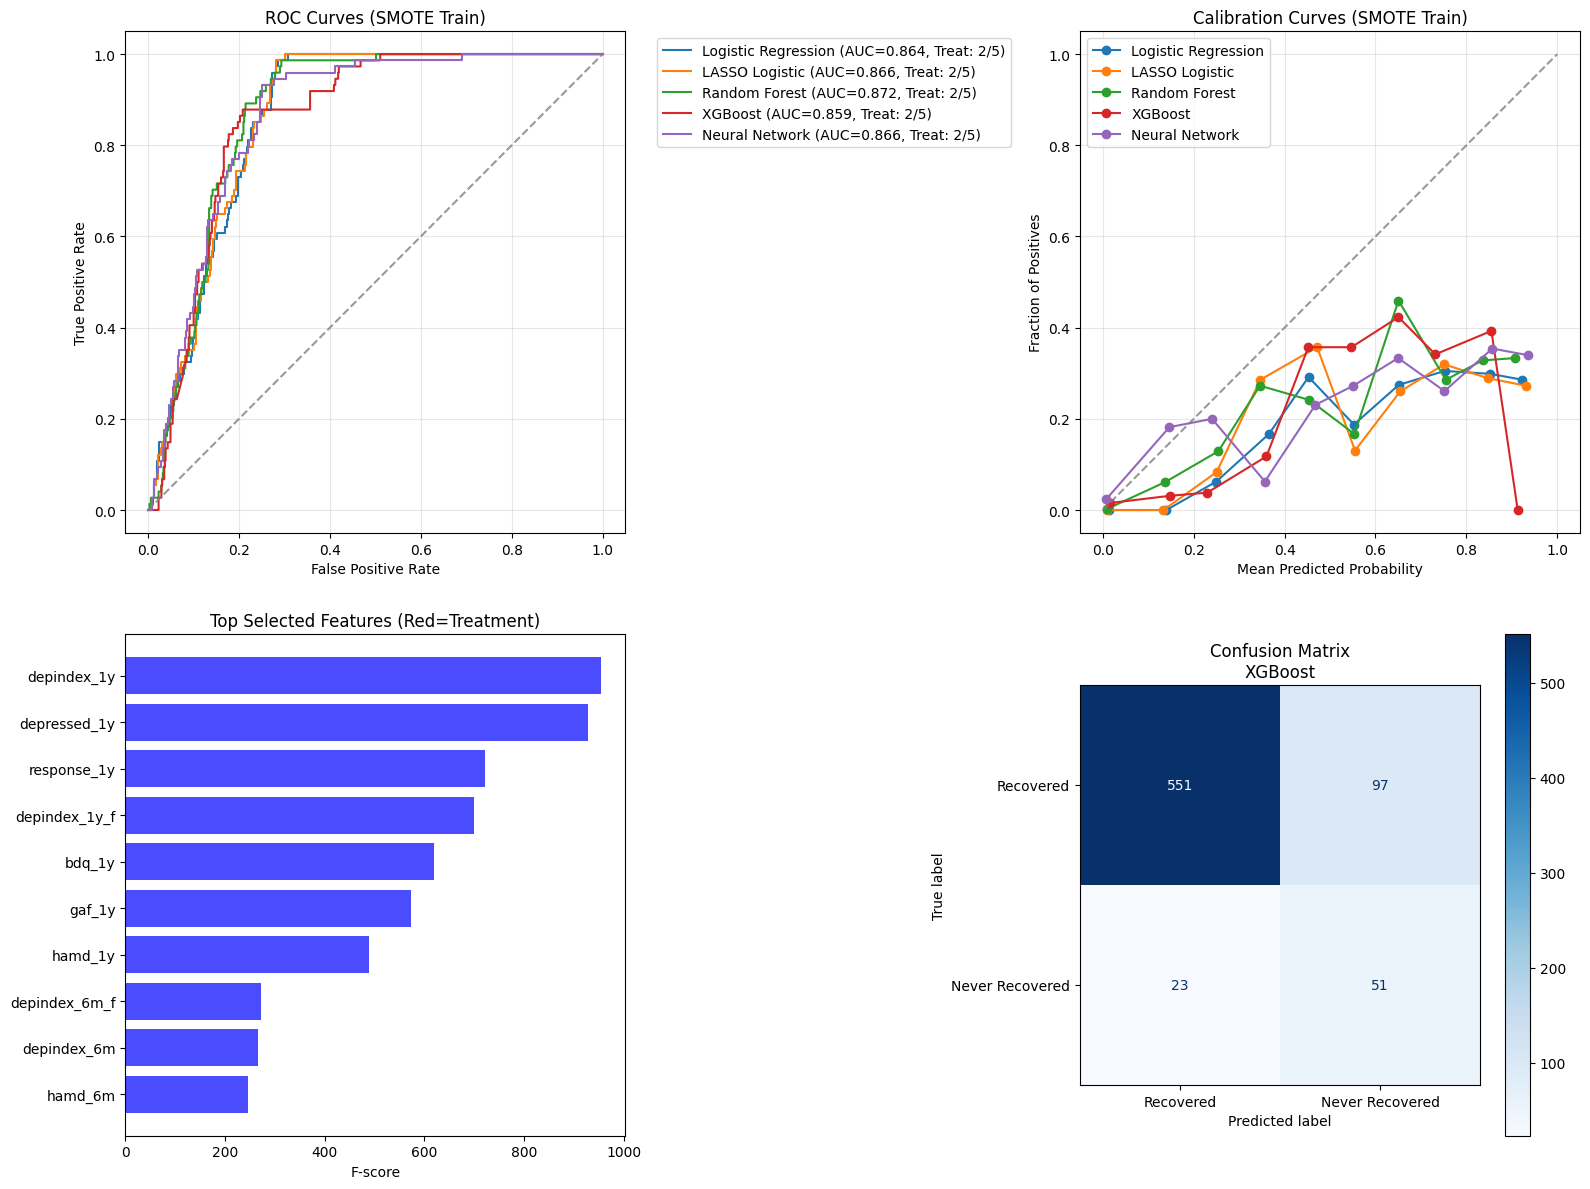

2025-07-10 09:05:18,975 - INFO - Refitted best: XGBoost
2025-07-10 09:05:19,081 - INFO - Calibration on train completed



Hold-out Performance:
Uncalibrated: AUC=0.835, F1=0.359
Calibrated:   AUC=0.844, F1=0.421


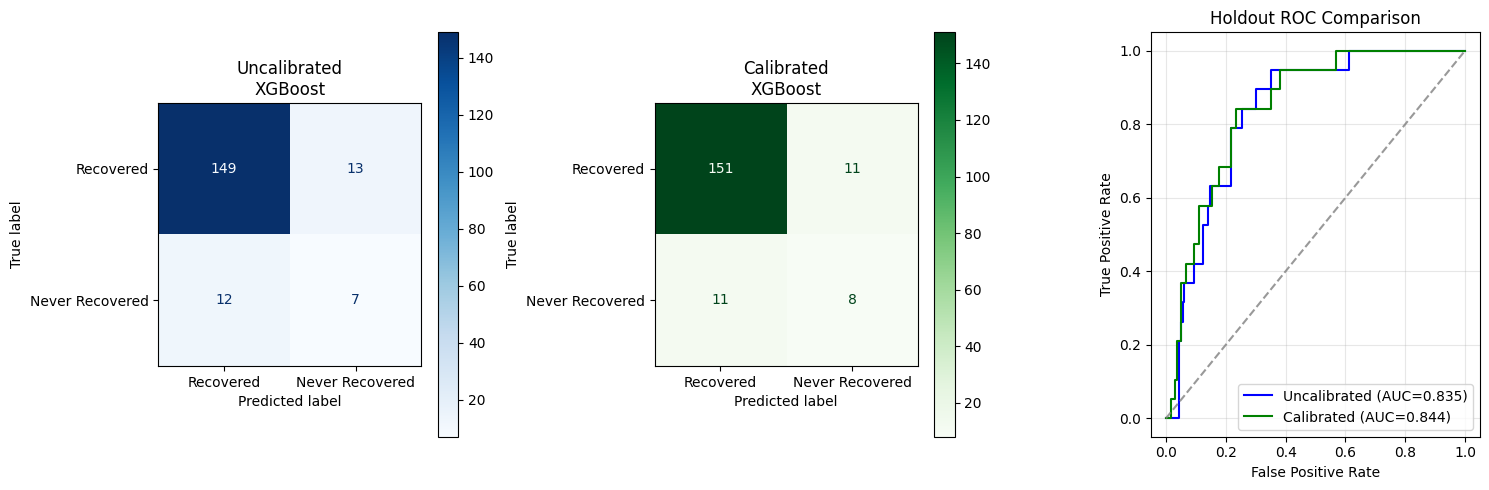

2025-07-10 09:05:19,351 - INFO - Performing SHAP analysis...
2025-07-10 09:05:19,352 - INFO - Treatment variable selected for SHAP: False



Detailed Holdout Metrics:
Metric          Uncalibrated Calibrated  
---------------------------------------
Accuracy        0.862        0.878       
Precision       0.350        0.421       
Recall          0.368        0.421       
F1 Score        0.359        0.421       
AUC             0.835        0.844       
Specificity     0.920        0.932       
Sensitivity     0.368        0.421       

Confusion Matrix Components:
Component       Uncalibrated Calibrated  
---------------------------------------
True Positives  7            8           
False Positives 13           11          
True Negatives  149          151         
False Negatives 12           11          


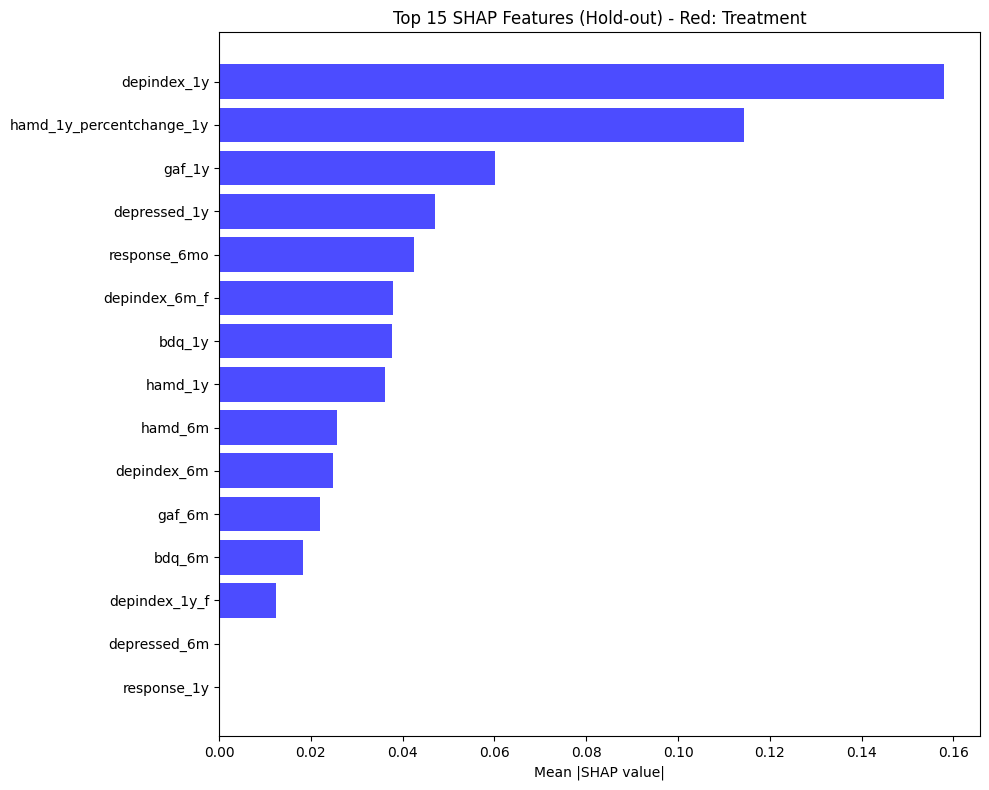

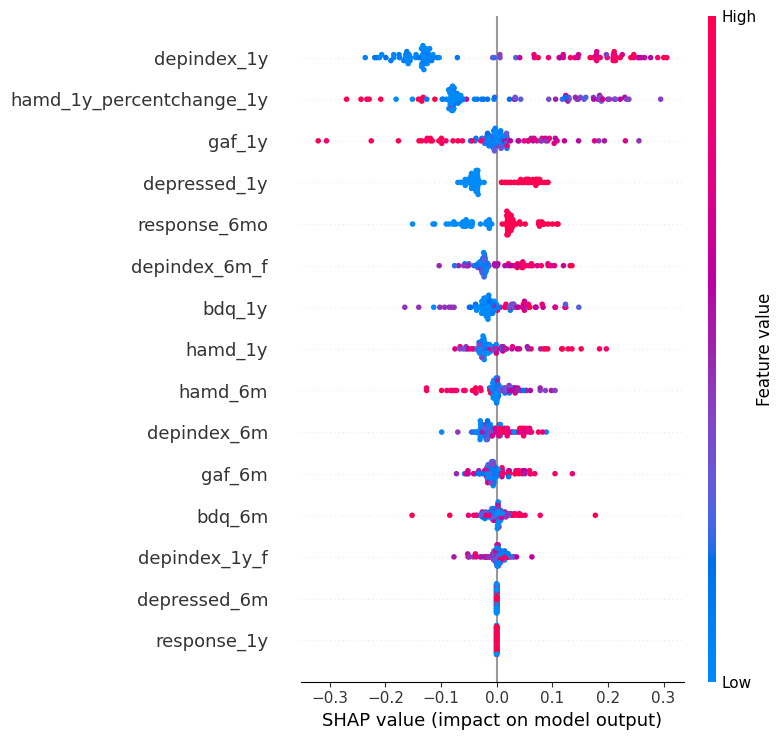


Generating SHAP Personas…
Top 3 SHAP features: ['gaf_1y', 'hamd_1y_percentchange_1y', 'depindex_1y']

Top-3 SHAP Personas:
                                                       Profile  P(never recover)
   gaf_1y=low & hamd_1y_percentchange_1y=low & depindex_1y=low             0.021
  gaf_1y=low & hamd_1y_percentchange_1y=low & depindex_1y=high             0.021
  gaf_1y=low & hamd_1y_percentchange_1y=high & depindex_1y=low             0.021
 gaf_1y=low & hamd_1y_percentchange_1y=high & depindex_1y=high             0.022
  gaf_1y=high & hamd_1y_percentchange_1y=low & depindex_1y=low             0.021
 gaf_1y=high & hamd_1y_percentchange_1y=low & depindex_1y=high             0.021
 gaf_1y=high & hamd_1y_percentchange_1y=high & depindex_1y=low             0.021
gaf_1y=high & hamd_1y_percentchange_1y=high & depindex_1y=high             0.021


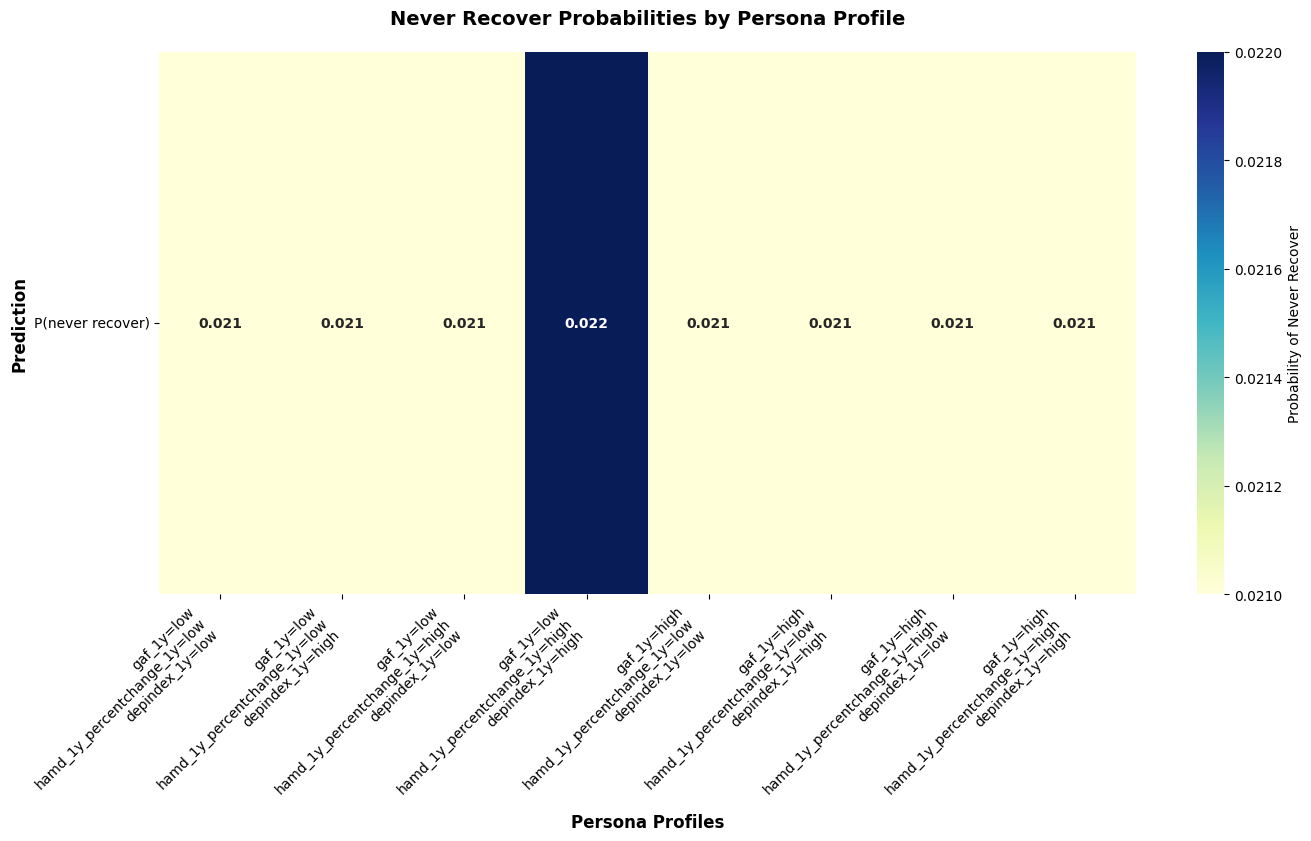

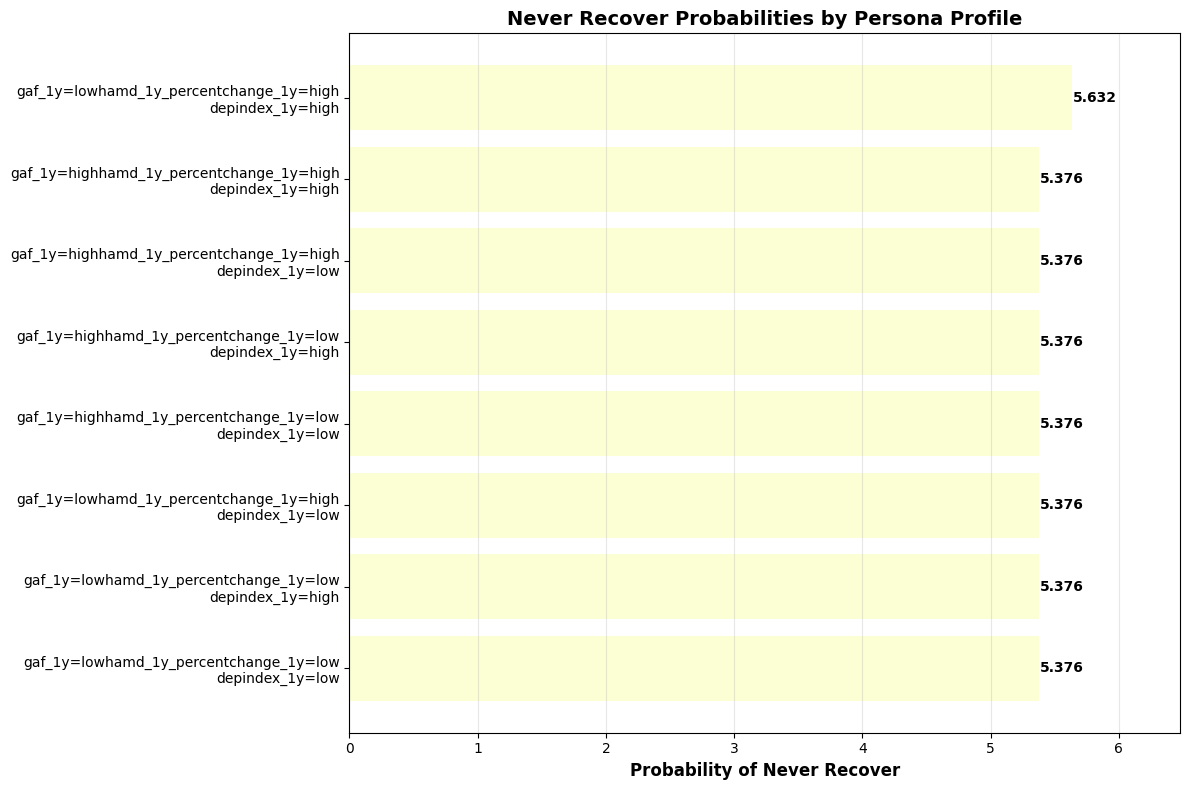


TREATMENT VARIABLE ANALYSIS
Logistic Regression:
  Treatment selected: 2/5 folds
  Average F-score: 127.452
  Average rank: 17.4
LASSO Logistic:
  Treatment selected: 2/5 folds
  Average F-score: 127.452
  Average rank: 17.4
Random Forest:
  Treatment selected: 2/5 folds
  Average F-score: 127.452
  Average rank: 17.4
XGBoost:
  Treatment selected: 2/5 folds
  Average F-score: 127.452
  Average rank: 17.4
Neural Network:
  Treatment selected: 2/5 folds
  Average F-score: 127.452
  Average rank: 17.4

FINAL RESULTS SUMMARY
Best Model: XGBoost
Hold-out Performance (Calibrated):
  Accuracy: 0.878
  Precision: 0.421
  Recall: 0.421
  F1 Score: 0.421
  AUC: 0.844
  Brier Score: 0.103
  True Negatives: 151.000
  False Positives: 11.000
  False Negatives: 11.000
  True Positives: 8.000
  Specificity: 0.932
  Sensitivity: 0.421
⚠ Treatment variable was NOT selected by the best model
Overall treatment selection rate: 10/25 (40.0%)


In [72]:
# Never recovered at 7 years - Nested CV (FIXED VERSION)

# ========= Imports =========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import tensorflow as tf 
import logging
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from skopt import BayesSearchCV

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from tabulate import tabulate
from itertools import product
import warnings
warnings.filterwarnings("ignore")

# ========= Configuration =========
@dataclass
class Config:
    RANDOM_STATE: int = 123
    N_FEATURES: int = 15
    OUTER_SPLITS: int = 5
    INNER_SPLITS: int = 3
    N_ITER: int = 20
    TEST_SIZE: float = 0.2
    TARGET_COL: str = "recover_never"
    ID_COL: str = "newid"
    EXCLUDE_COLS: List[str] = None
    
    def __post_init__(self):
        if self.EXCLUDE_COLS is None:
            self.EXCLUDE_COLS = ["recover_never", "recurrence_7y", "remission_1y", 
"remission_6mo", "recovery_1y"
    ]

config = Config()

# ========= Logging Setup =========
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ========= Data Validation =========
def validate_data(df: pd.DataFrame, target_col: str, required_cols: List[str]) -> None:
    """Validate input data quality"""
    assert not df.empty, "DataFrame is empty"
    assert target_col in df.columns, f"Target column '{target_col}' not found"
    
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    assert df[target_col].nunique() > 1, "Target has only one class"
    logger.info(f"Data validation passed. Shape: {df.shape}")

# ========= UPDATED: SMOTE Pipeline Builder =========
def build_smote_pipeline(base_model, config: Config, include_oversampling: bool = True):
    """
    Build a pipeline that uses SMOTE for oversampling instead of stratified approach
    """
    if include_oversampling:
        # Use imblearn pipeline with SMOTE
        pipeline = ImbPipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('oversample', SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)),
            ('select', SelectKBest(score_func=f_classif, k=config.N_FEATURES)),
            ('model', base_model)
        ])
    else:
        # Standard pipeline without oversampling
        pipeline = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('select', SelectKBest(score_func=f_classif, k=config.N_FEATURES)),
            ('model', base_model)
        ])
    
    return pipeline

# ========= UPDATED: Nested CV with SMOTE =========
def run_nested_cv_smote(model, param_distributions: Dict, X: pd.DataFrame, y: np.ndarray, 
                        config: Config, include_oversampling: bool = True) -> Dict[str, Any]:
    """
    Nested CV with SMOTE oversampling instead of stratified oversampling
    """
    outer_cv = StratifiedKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)
    inner_cv = StratifiedKFold(n_splits=config.INNER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)

    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    outer_scores = []
    successful_folds = 0
    feature_importance_dicts = []
    treatment_selected_count = 0
    treatment_scores = []  # Track treatment F-scores

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        logger.info(f"Processing outer fold {fold + 1}/{config.OUTER_SPLITS}")
        
        try:
            # Split data first
            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y[train_idx].copy()
            X_test_fold = X.iloc[test_idx].copy()
            y_test_fold = y[test_idx].copy()

            # Log treatment and class distribution in this fold
            if 'treat' in X_train_fold.columns:
                treat_dist = X_train_fold['treat'].value_counts()
                logger.info(f"Fold {fold+1} treatment distribution: {treat_dist.to_dict()}")
            
            class_dist = pd.Series(y_train_fold).value_counts()
            logger.info(f"Fold {fold+1} class distribution: {class_dist.to_dict()}")

            # Build SMOTE pipeline
            pipe = build_smote_pipeline(model, config, include_oversampling)
            
            # Hyperparameter search on training fold
            search_space = {f'model__{k}': v for k, v in param_distributions.items()}
            
            search = BayesSearchCV(
                pipe,
                search_spaces=search_space,
                n_iter=config.N_ITER,
                scoring='roc_auc',
                cv=inner_cv,
                n_jobs=1,
                random_state=config.RANDOM_STATE,
                error_score='raise'
            )
            
            search.fit(X_train_fold, y_train_fold)
            best_model = search.best_estimator_

            # Check if treatment was selected as a feature
            if hasattr(best_model, 'named_steps') and 'select' in best_model.named_steps:
                selector = best_model.named_steps['select']
                selected_features = X_train_fold.columns[selector.get_support()].tolist()
                feature_scores = dict(zip(X_train_fold.columns, selector.scores_))
                
                # Track treatment selection and scoring
                treat_selected = 'treat' in selected_features
                treat_score = feature_scores.get('treat', 0)
                treat_rank = sorted(feature_scores.values(), reverse=True).index(treat_score) + 1 if 'treat' in feature_scores else len(feature_scores)
                
                if treat_selected:
                    treatment_selected_count += 1
                    logger.info(f"Fold {fold+1}: Treatment variable selected! (F-score={treat_score:.3f}, rank={treat_rank})")
                else:
                    logger.info(f"Fold {fold+1}: Treatment NOT selected (F-score={treat_score:.3f}, rank={treat_rank}/{len(feature_scores)})")
                
                treatment_scores.append({
                    'fold': fold + 1,
                    'treat_score': treat_score,
                    'treat_rank': treat_rank,
                    'treat_selected': treat_selected
                })
                
                # Store feature importance info
                feature_importance_dicts.append({
                    'fold': fold + 1,
                    'selected_features': selected_features,
                    'treatment_selected': treat_selected,
                    'feature_scores': feature_scores
                })

            # Make predictions on test fold
            prob = best_model.predict_proba(X_test_fold)[:, 1]
            pred = (prob > 0.5).astype(int)
            
            y_probs[test_idx] = prob
            y_preds[test_idx] = pred
            outer_scores.append(roc_auc_score(y_test_fold, prob))
            successful_folds += 1
            
            logger.info(f"Fold {fold+1} AUC: {outer_scores[-1]:.3f}")
            
        except Exception as e:
            logger.error(f"Error in fold {fold + 1}: {e}")
            # For failed folds, use neutral predictions
            y_probs[test_idx] = 0.5
            y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
            outer_scores.append(0.5)

    # Validate results
    if successful_folds < config.OUTER_SPLITS // 2:
        raise RuntimeError(f"Too many folds failed: {successful_folds}/{config.OUTER_SPLITS}")

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    # Log treatment selection summary
    logger.info(f"Treatment variable selected in {treatment_selected_count}/{successful_folds} folds")
    if treatment_scores:
        avg_treat_score = np.mean([t['treat_score'] for t in treatment_scores])
        avg_treat_rank = np.mean([t['treat_rank'] for t in treatment_scores])
        logger.info(f"Average treatment F-score: {avg_treat_score:.3f}, average rank: {avg_treat_rank:.1f}")

    return {
        "model": search.best_estimator_ if 'search' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(outer_scores),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": treatment_selected_count,
        "treatment_scores": treatment_scores,
        "feature_importance_info": feature_importance_dicts
    }

# ========= UPDATED: Neural Network CV with SMOTE =========
def run_nn_cv_smote(X: pd.DataFrame, y: np.ndarray, config: Config) -> Dict[str, Any]:
    """Neural network CV with SMOTE oversampling"""
    outer_cv = StratifiedKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)
    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    aucs = []
    successful_folds = 0
    feature_names = X.columns.tolist()
    treatment_selected_count = 0
    treatment_scores = []

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        logger.info(f"Processing NN fold {fold + 1}/{config.OUTER_SPLITS}")
        
        try:
            # Split data first
            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y[train_idx].copy()
            X_test_fold = X.iloc[test_idx].copy()
            y_test_fold = y[test_idx].copy()

            # Apply preprocessing
            imputer = SimpleImputer(strategy='median')
            scaler = StandardScaler()
            
            X_train_imputed = imputer.fit_transform(X_train_fold)
            X_train_scaled = scaler.fit_transform(X_train_imputed)
            X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
            
            # Apply SMOTE oversampling
            smote = SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)
            X_train_df, y_train_fold = smote.fit_resample(X_train_df, y_train_fold)
            
            logger.info(f"NN Fold {fold+1}: After SMOTE - {len(X_train_df)} samples, "
                       f"class distribution: {np.bincount(y_train_fold)}")

            # Feature selection on SMOTE-processed training data
            selector = SelectKBest(score_func=f_classif, k=config.N_FEATURES)
            X_train_selected = selector.fit_transform(X_train_df.values, y_train_fold)
            
            # Check if treatment was selected
            selected_features = X_train_df.columns[selector.get_support()].tolist()
            feature_scores = dict(zip(X_train_df.columns, selector.scores_))
            
            treat_selected = 'treat' in selected_features
            treat_score = feature_scores.get('treat', 0)
            treat_rank = sorted(feature_scores.values(), reverse=True).index(treat_score) + 1 if 'treat' in feature_scores else len(feature_scores)
            
            if treat_selected:
                treatment_selected_count += 1
                logger.info(f"NN Fold {fold+1}: Treatment variable selected! (F-score={treat_score:.3f})")
            else:
                logger.info(f"NN Fold {fold+1}: Treatment NOT selected (F-score={treat_score:.3f}, rank={treat_rank})")
            
            treatment_scores.append({
                'fold': fold + 1,
                'treat_score': treat_score,
                'treat_rank': treat_rank,
                'treat_selected': treat_selected
            })
            
            # Build and train model
            model = build_nn_model(input_dim=X_train_selected.shape[1])
            
            # Compute class weights
            unique_classes = np.unique(y_train_fold)
            if len(unique_classes) > 1:
                cw_vals = compute_class_weight('balanced', classes=unique_classes, y=y_train_fold)
                class_weights = {i: w for i, w in enumerate(cw_vals)}
            else:
                class_weights = None
            
            batch_size = max(8, min(32, len(X_train_selected) // 4))
            
            history = model.fit(
                X_train_selected, y_train_fold,
                validation_split=0.2,
                epochs=100,
                batch_size=batch_size,
                callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
                class_weight=class_weights,
                verbose=0
            )

            # Transform test data and make predictions
            X_test_imputed = imputer.transform(X_test_fold)
            X_test_scaled = scaler.transform(X_test_imputed)
            X_test_selected = selector.transform(X_test_scaled)
            
            prob = model.predict(X_test_selected, verbose=0).ravel()
            pred = (prob > 0.5).astype(int)
            
            y_probs[test_idx] = prob
            y_preds[test_idx] = pred
            aucs.append(roc_auc_score(y_test_fold, prob))
            successful_folds += 1
            
        except Exception as e:
            logger.error(f"Error in NN fold {fold + 1}: {e}")
            y_probs[test_idx] = 0.5
            y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
            aucs.append(0.5)

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid NN predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    logger.info(f"NN: Treatment variable selected in {treatment_selected_count}/{successful_folds} folds")
    if treatment_scores:
        avg_treat_score = np.mean([t['treat_score'] for t in treatment_scores])
        avg_treat_rank = np.mean([t['treat_rank'] for t in treatment_scores])
        logger.info(f"NN: Average treatment F-score: {avg_treat_score:.3f}, average rank: {avg_treat_rank:.1f}")

    return {
        "model": model if 'model' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(aucs),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": treatment_selected_count,
        "treatment_scores": treatment_scores
    }

# ========= Leak-Free Preprocessor (Unchanged) =========
class LeakFreePreprocessor:
    """
    Preprocessing that prevents data leakage by fitting only on training folds
    """
    
    def __init__(self, config: Config):
        self.config = config
        self.imputer = None
        self.scaler = None
        self.label_encoder = None
        self.feature_names = None
        
    def fit(self, X: pd.DataFrame, y: pd.Series) -> 'LeakFreePreprocessor':
        """Fit preprocessor components separately to allow proper CV"""
        self.feature_names = X.columns.tolist()
        
        # Fit components
        self.imputer = SimpleImputer(strategy='median')
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        
        # Fit on training data
        X_imputed = self.imputer.fit_transform(X)
        self.scaler.fit(X_imputed)
        self.label_encoder.fit(y)
        
        logger.info(f"Preprocessor fitted on {X.shape[0]} samples, {X.shape[1]} features")
        return self
    
    def transform_features(self, X):
        """Transform features using fitted preprocessor"""
        if isinstance(X, pd.DataFrame):
            X_ordered = X.reindex(columns=self.feature_names, fill_value=np.nan)
            X_values = X_ordered.values
        else:
            X_values = X
            
        X_imputed = self.imputer.transform(X_values)
        X_scaled = self.scaler.transform(X_imputed)
        return X_scaled
    
    def transform_target(self, y: pd.Series) -> np.ndarray:
        """Transform target using fitted label encoder"""
        return self.label_encoder.transform(y)
    
    def get_feature_names(self) -> List[str]:
        """Get original feature names"""
        return self.feature_names.copy()

# ========= Neural Network Builder (Unchanged) =========
def build_nn_model(input_dim: int, neurons1: int = 64, neurons2: int = 32, 
                   dropout: float = 0.3, learning_rate: float = 1e-3) -> tf.keras.Model:
    """Build neural network with improved architecture"""
    model = Sequential([
        Dense(neurons1, activation='relu', input_dim=input_dim,
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(neurons2, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model

# ========= Utility Functions (Enhanced with Treatment Tracking) =========
def calculate_holdout_metrics(y_true: np.ndarray, y_pred: np.ndarray, 
                            y_proba: np.ndarray) -> Dict[str, float]:
    """Calculate comprehensive holdout metrics including confusion matrix components"""
    cm = confusion_matrix(y_true, y_pred)
    
    # Extract confusion matrix components
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true, y_proba),
        'Brier Score': brier_score_loss(y_true, y_proba),
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0
    }

def plot_performance_curves(results: Dict, y_true: np.ndarray, feature_names, title_suffix: str = ""):
    """Generate ROC, calibration curves, and confusion matrix with treatment selection info"""
    plt.figure(figsize=(16, 12))  # Adjusted size for 2x2 layout
    
    # ROC Curves (Top Left)
    plt.subplot(2, 2, 1)
    for name, res in results.items():
        if res and 'y_probs' in res:
            try:
                valid_mask = res['y_probs'] >= 0
                if np.any(valid_mask):
                    y_valid = y_true[valid_mask]
                    probs_valid = res['y_probs'][valid_mask]
                    fpr, tpr, _ = roc_curve(y_valid, probs_valid)
                    auc = roc_auc_score(y_valid, probs_valid)
                    
                    # Enhanced label with treatment selection info
                    treat_count = res.get('treatment_selected_count', 0)
                    total_folds = res.get('successful_folds', 0)
                    label = f"{name} (AUC={auc:.3f}, Treat: {treat_count}/{total_folds})"
                    
                    plt.plot(fpr, tpr, label=label)
                        
            except Exception as e:
                logger.warning(f"Error plotting ROC for {name}: {e}")
    
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves {title_suffix}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)

    # Calibration Curves (Top Right)
    plt.subplot(2, 2, 2)
    for name, res in results.items():
        if res and 'y_probs' in res:
            try:
                valid_mask = res['y_probs'] >= 0
                if np.any(valid_mask):
                    y_valid = y_true[valid_mask]
                    probs_valid = res['y_probs'][valid_mask]
                    fraction_of_positives, mean_predicted_value = calibration_curve(
                        y_valid, probs_valid, n_bins=10
                    )
                    plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label=name)
            except Exception as e:
                logger.warning(f"Error plotting calibration for {name}: {e}")
    
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title(f"Calibration Curves {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Feature Importance (Bottom Left)
    plt.subplot(2, 2, 3)
    best_model_name = max(results.keys(), key=lambda k: results[k]['metrics']['AUC'] 
                         if results[k] and 'metrics' in results[k] else 0)
    best_model = results[best_model_name]['model']
    
    if best_model and hasattr(best_model, 'named_steps'):
        try:
            selector = best_model.named_steps['select']
            scores = selector.scores_
            top_idx = np.argsort(scores)[-10:]
            top_feats = [feature_names[i] for i in top_idx]
            
            # Highlight treatment variable if selected
            colors = ['red' if feat == 'treat' else 'blue' for feat in top_feats]
            plt.barh(range(len(top_idx)), scores[top_idx], color=colors, alpha=0.7)
            
            plt.yticks(range(len(top_idx)), top_feats)
            plt.xlabel("F-score")
            plt.title("Top Selected Features (Red=Treatment)")
        except Exception:
            plt.text(0.5, 0.5, "Feature importance\nnot available", 
                    ha='center', va='center', transform=plt.gca().transAxes)
    
    # Confusion Matrix for Best Model (Bottom Right)
    plt.subplot(2, 2, 4)
    if best_model_name in results and results[best_model_name]:
        try:
            res = results[best_model_name]
            valid_mask = res['y_probs'] >= 0
            if np.any(valid_mask):
                y_valid = y_true[valid_mask]
                y_pred_valid = res['y_preds'][valid_mask]
                
                cm = confusion_matrix(y_valid, y_pred_valid)
                disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                            display_labels=['Recovered', 'Never Recovered'])
                disp.plot(ax=plt.gca(), cmap='Blues', values_format='d')
                plt.title(f"Confusion Matrix\n{best_model_name}")
        except Exception as e:
            logger.warning(f"Error plotting confusion matrix: {e}")
            plt.text(0.5, 0.5, "Confusion Matrix\nnot available", 
                    ha='center', va='center', transform=plt.gca().transAxes)
    
    plt.tight_layout()
    plt.show()

# ========= Holdout Confusion Matrix Function =========

def plot_holdout_confusion_matrices(y_true, preds_unc, preds_cal, probs_unc, probs_cal, best_name):
    """Plot confusion matrices for holdout predictions"""
    plt.figure(figsize=(15, 5))
    
    # Uncalibrated Confusion Matrix
    plt.subplot(1, 3, 1)
    cm_unc = confusion_matrix(y_true, preds_unc)
    disp_unc = ConfusionMatrixDisplay(confusion_matrix=cm_unc, 
                                     display_labels=['Recovered', 'Never Recovered'])
    disp_unc.plot(ax=plt.gca(), cmap='Blues', values_format='d')
    plt.title(f"Uncalibrated\n{best_name}")
    
    # Calibrated Confusion Matrix
    plt.subplot(1, 3, 2)
    cm_cal = confusion_matrix(y_true, preds_cal)
    disp_cal = ConfusionMatrixDisplay(confusion_matrix=cm_cal, 
                                     display_labels=['Recovered', 'Never Recovered'])
    disp_cal.plot(ax=plt.gca(), cmap='Greens', values_format='d')
    plt.title(f"Calibrated\n{best_name}")
    
    # ROC Comparison
    plt.subplot(1, 3, 3)
    fpr_unc, tpr_unc, _ = roc_curve(y_true, probs_unc)
    fpr_cal, tpr_cal, _ = roc_curve(y_true, probs_cal)
    
    auc_unc = roc_auc_score(y_true, probs_unc)
    auc_cal = roc_auc_score(y_true, probs_cal)
    
    plt.plot(fpr_unc, tpr_unc, label=f'Uncalibrated (AUC={auc_unc:.3f})', color='blue')
    plt.plot(fpr_cal, tpr_cal, label=f'Calibrated (AUC={auc_cal:.3f})', color='green')
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Holdout ROC Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def perform_shap_analysis(best_model, X_holdout: np.ndarray, feature_names: List[str],
                         preprocessor: LeakFreePreprocessor, holdout_raw: pd.DataFrame):
    """Perform SHAP analysis with proper error handling"""
    try:
        logger.info("Performing SHAP analysis...")
        
        model_obj = best_model.named_steps['model']
        if not hasattr(model_obj, 'predict_proba'):
            logger.warning("Model doesn't support probability prediction, skipping SHAP")
            return None
        
        selector = best_model.named_steps['select']
        X_selected = selector.transform(X_holdout)
        selected_feature_names = [feature_names[i] for i in selector.get_support(indices=True)]
        
        # Highlight if treatment is selected
        treat_selected = 'treat' in selected_feature_names
        logger.info(f"Treatment variable selected for SHAP: {treat_selected}")
        
        n_background = min(100, X_selected.shape[0])
        background_data = X_selected[:n_background]
        
        if hasattr(model_obj, 'tree_'):
            explainer = shap.TreeExplainer(model_obj)
            shap_values = explainer.shap_values(background_data)
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        else:
            explainer = shap.Explainer(model_obj.predict_proba, background_data)
            shap_values = explainer(background_data)
            if hasattr(shap_values, 'values'):
                shap_values = shap_values.values[:, :, 1]
        
        shap_abs = np.abs(shap_values).mean(axis=0)
        top_n = min(15, len(selected_feature_names))
        top_idx = np.argsort(shap_abs)[-top_n:]
        
        plt.figure(figsize=(10, 8))
        colors = ['red' if selected_feature_names[i] == 'treat' else 'blue' for i in top_idx]
        plt.barh(range(len(top_idx)), shap_abs[top_idx], color=colors, alpha=0.7)
        plt.yticks(range(len(top_idx)), [selected_feature_names[i] for i in top_idx])
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"Top {top_n} SHAP Features (Hold-out) - Red: Treatment")
        plt.tight_layout()
        plt.show()
        
        try:
            shap.summary_plot(
                shap_values, 
                features=background_data, 
                feature_names=selected_feature_names,
                show=False
            )
            plt.tight_layout()
            plt.show()
        except Exception as e:
            logger.warning(f"Error creating SHAP summary plot: {e}")
            
    except Exception as e:
        logger.error(f"Error in SHAP analysis: {e}")
        return None

    return {
        'selector': selector,
        'shap_values': shap_values if 'shap_values' in locals() else None,
        'selected_feature_names': selected_feature_names if 'selected_feature_names' in locals() else []
    }

# ========= FIXED: Main Pipeline =========
def main():
    """FIXED: Main execution pipeline without data leakage"""

    # 1. Load & validate
    try:
        df = pd.read_csv("complete_data_mice_7y_never.csv")
        logger.info(f"Data loaded: {df.shape}")
        required = [config.TARGET_COL, config.ID_COL] + config.EXCLUDE_COLS + ['treat']
        validate_data(df, config.TARGET_COL, required)
    except Exception as e:
        logger.error(f"Loading/validation error: {e}")
        return

    # 2. Quick QC
    logger.info(f"Target counts:\n{df[config.TARGET_COL].value_counts()}")
    logger.info(f"Missing values: {df.isnull().sum().sum()}")

    # 3. CRITICAL: Train/hold-out split FIRST, before any processing
    train_df, holdout_df = train_test_split(
        df,
        test_size=config.TEST_SIZE,
        stratify=df[config.TARGET_COL],
        random_state=config.RANDOM_STATE
    )
    logger.info(f"Train={len(train_df)}, Hold-out={len(holdout_df)}")

    # 4. Prepare training data (keep as DataFrame to preserve column names)
    X_train = train_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    y_train = train_df[config.TARGET_COL].values
    feature_names = X_train.columns.tolist()

    # 5. Define models & parameters
    models_and_params = {
        "Logistic Regression": (
            LogisticRegression(max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.01, 0.1, 1.0, 10.0]}
        ),
        "LASSO Logistic": (
            LogisticRegression(penalty='l1', solver='liblinear',
                               max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.001, 0.01, 0.1, 1, 10]}
        ),
        "Random Forest": (
            RandomForestClassifier(class_weight='balanced',
                                   random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "max_depth": [3, 5, 10],
             "min_samples_split": [5, 10],
             "min_samples_leaf": [2, 5]}
        ),
        "XGBoost": (
            XGBClassifier(use_label_encoder=False,
                          eval_metric='logloss',
                          random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "learning_rate": [0.01, 0.1],
             "max_depth": [3, 6],
             "subsample": [0.8, 1.0]}
        )
    }

    # 6. Run nested CV with SMOTE (using the correct function names)
    results = {}
    for name, (model, params) in models_and_params.items():
        logger.info(f"→ Nested CV: {name}")
        try:
            results[name] = run_nested_cv_smote(
                model, params, X_train, y_train, config, include_oversampling=True
            )
            logger.info(f"   AUC={results[name]['metrics']['AUC']:.3f}")
        except Exception as e:
            logger.error(f"   {name} failed: {e}")

    # 7. Neural network with SMOTE
    try:
        logger.info("→ Nested CV: Neural Network")
        results['Neural Network'] = run_nn_cv_smote(X_train, y_train, config)
        logger.info(f"   AUC={results['Neural Network']['metrics']['AUC']:.3f}")
    except Exception as e:
        logger.error(f"   NN failed: {e}")

    # 8. Show performance table with treatment selection info
    perf_rows = []
    for m, res in results.items():
        if res and 'metrics' in res:
            row = {"Model": m}
            row.update({k: round(v, 3) for k, v in res['metrics'].items()})
            row["Folds"] = res.get('successful_folds', 'N/A')
            row["Treat_Selected"] = f"{res.get('treatment_selected_count', 0)}/{res.get('successful_folds', 0)}"
            perf_rows.append(row)
    perf_df = pd.DataFrame(perf_rows)
    print("\nNested CV Performance (with Treatment Selection)")
    print(tabulate(perf_df, headers='keys', tablefmt='grid', showindex=False))

    # 9. Fit preprocessor on full training data for final model preparation
    preprocessor = LeakFreePreprocessor(config)
    preprocessor.fit(X_train, train_df[config.TARGET_COL])
    
    # Transform training data
    X_train_proc = preprocessor.transform_features(X_train)
    X_train_df = pd.DataFrame(X_train_proc, columns=feature_names)
    y_train_processed = preprocessor.transform_target(train_df[config.TARGET_COL])
    
    # Apply SMOTE oversampling for final model training
    smote = SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)
    X_train_final, y_res = smote.fit_resample(X_train_df, y_train_processed)
    logger.info(f"Final training data after SMOTE: {X_train_final.shape}, class distribution: {np.bincount(y_res)}")

    # 10. Plot OOF ROC + calibration
    plot_performance_curves(results, y_train, feature_names, title_suffix="(SMOTE Train)")

    # 11. Refit best pipeline on full SMOTE-resampled train data
    if not results:
        logger.error("No successful models to select from")
        return
        
    best_name = max(results, key=lambda k: results[k]['metrics']['AUC'] if results[k] else 0)
    best_result = results[best_name]
    
    if not best_result or 'model' not in best_result:
        logger.error(f"Best model {best_name} has no trained model")
        return
        
    # Build and fit new pipeline on full resampled data
    best_pipe = build_smote_pipeline(
        models_and_params[best_name][0], config, include_oversampling=False
    )
    best_pipe.fit(X_train_final, y_res)
    logger.info(f"Refitted best: {best_name}")

    # 12. Calibrate via Platt scaling
    X_sel_train = best_pipe.named_steps['select'].transform(X_train_final)
    calibrator = CalibratedClassifierCV(
        best_pipe.named_steps['model'],
        method='sigmoid',
        cv=3  # Use CV instead of prefit since we have enough data
    )
    calibrator.fit(X_sel_train, y_res)
    logger.info("Calibration on train completed")

    # 13. Prepare hold-out
    X_hold = holdout_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    X_hold_proc = preprocessor.transform_features(X_hold)  # (n_hold, n_feats)
    y_hold = preprocessor.transform_target(holdout_df[config.TARGET_COL])

    # 14a) uncalibrated on full pipeline:
    probs_unc = best_pipe.predict_proba(X_hold_proc)[:,1]

    # 14b) calibrated: first select, then calibrator
    selector = best_pipe.named_steps['select']
    X_hold_sel = selector.transform(X_hold_proc)  # (n_hold, k_features)
    probs_cal = calibrator.predict_proba(X_hold_sel)[:, 1]

    # 15) threshold & metrics
    preds_unc = (probs_unc > 0.5).astype(int)
    preds_cal = (probs_cal > 0.5).astype(int)
    hold_unc = calculate_holdout_metrics(y_hold, preds_unc, probs_unc)
    hold_cal = calculate_holdout_metrics(y_hold, preds_cal, probs_cal)
    
    print(f"\nHold-out Performance:")
    print(f"Uncalibrated: AUC={hold_unc['AUC']:.3f}, F1={hold_unc['F1 Score']:.3f}")
    print(f"Calibrated:   AUC={hold_cal['AUC']:.3f}, F1={hold_cal['F1 Score']:.3f}")

    # Plot holdout confusion matrices
    plot_holdout_confusion_matrices(y_hold, preds_unc, preds_cal, probs_unc, probs_cal, best_name)
    
    # Print detailed confusion matrix metrics
    print(f"\nDetailed Holdout Metrics:")
    print(f"{'Metric':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC', 'Specificity', 'Sensitivity']:
        print(f"{metric:<15} {hold_unc[metric]:<12.3f} {hold_cal[metric]:<12.3f}")
    
    print(f"\nConfusion Matrix Components:")
    print(f"{'Component':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for component in ['True Positives', 'False Positives', 'True Negatives', 'False Negatives']:
        print(f"{component:<15} {hold_unc[component]:<12} {hold_cal[component]:<12}")
        
    # 16. SHAP + Personas
    shap_info = perform_shap_analysis(
    best_pipe,
    X_hold_proc,
    feature_names,
    preprocessor,
    holdout_df
)

    if shap_info and shap_info['shap_values'] is not None:
        selector_ = shap_info['selector']
        sv = shap_info['shap_values']
        feats = shap_info['selected_feature_names']
        abs_mean = np.abs(sv).mean(axis=0)
        
        if len(feats) >= 3:
            print("\nGenerating SHAP Personas…")
            raw_df = train_df.drop(columns=config.EXCLUDE_COLS + [config.ID_COL])
            raw_median = raw_df.median()
            raw_min = raw_df.min()
            raw_max = raw_df.max()
            
            # pick top-3 by |SHAP|
            top3_idx = np.argsort(abs_mean)[-3:]
            top3_feats = [feats[i] for i in top3_idx]
            
            print(f"Top 3 SHAP features: {top3_feats}")
            
            # Create a custom preprocessor-selector-calibrator pipeline for personas
            class PersonaPipeline:
                def __init__(self, preprocessor, selector, calibrator):
                    self.preprocessor = preprocessor
                    self.selector = selector
                    self.calibrator = calibrator
                
                def predict_proba(self, X_raw):
                    # Preprocess raw data
                    X_proc = self.preprocessor.transform_features(X_raw)
                    # Select features
                    X_sel = self.selector.transform(X_proc)
                    # Get calibrated probabilities
                    return self.calibrator.predict_proba(X_sel)
            
            final_pipe = PersonaPipeline(preprocessor, selector_, calibrator)
            
            prototypes = []
            for combo in product(['low','high'], repeat=3):
                row = raw_median.copy()
                desc = []
                for feat, lvl in zip(top3_feats, combo):
                    row[feat] = raw_min[feat] if lvl=='low' else raw_max[feat]
                    desc.append(f"{feat}={lvl}")
                
                # Create DataFrame with correct column order matching feature_names
                arr_df = pd.DataFrame([row.reindex(feature_names)])
                try:
                    p = final_pipe.predict_proba(arr_df)[0,1]
                    prototypes.append({
                        'Profile': ' & '.join(desc),
                        'P(never recover)': round(p, 3)
                    })
                except Exception as e:
                    logger.warning(f"Error generating persona for {desc}: {e}")
            
            if prototypes:
                proto_df = pd.DataFrame(prototypes)
                print("\nTop-3 SHAP Personas:")
                print(proto_df.to_string(index=False))
                
                try:
                    # Create figure with larger size to accommodate labels
                    plt.figure(figsize=(14, 8))
                    
                    # Function to format long labels with line breaks
                    def format_label(label, max_chars_per_line=30):
                        """Break long labels into multiple lines"""
                        parts = label.split(' & ')
                        formatted_parts = []
                        current_line = ""
                        
                        for part in parts:
                            if len(current_line + part) <= max_chars_per_line:
                                current_line += part + " & " if current_line else part
                            else:
                                if current_line:
                                    formatted_parts.append(current_line.rstrip(" & "))
                                current_line = part + " & "
                        
                        if current_line:
                            formatted_parts.append(current_line.rstrip(" & "))
                        
                        return '\n'.join(formatted_parts)
                    
                    # Format the profile labels
                    formatted_labels = [format_label(profile) for profile in proto_df['Profile']]
                    
                    # Create the heatmap with formatted labels
                    heatmap_data = proto_df.set_index('Profile')[['P(never recover)']].T
                    heatmap_data.columns = formatted_labels
                    
                    ax = sns.heatmap(
                        heatmap_data,
                        annot=True, 
                        cmap='YlGnBu', 
                        fmt='.3f',
                        cbar_kws={'label': 'Probability of Never Recover'},
                        annot_kws={'size': 10, 'weight': 'bold'}
                    )
                    
                    # Rotate x-axis labels for better readability
                    plt.xticks(rotation=45, ha='right')
                    plt.yticks(rotation=0)
                    
                    # Adjust layout and titles
                    plt.title("Never Recover Probabilities by Persona Profile", 
                            fontsize=14, fontweight='bold', pad=20)
                    plt.xlabel("Persona Profiles", fontsize=12, fontweight='bold')
                    plt.ylabel("Prediction", fontsize=12, fontweight='bold')
                    
                    # Adjust layout to prevent label cutoff
                    plt.tight_layout()
                    plt.subplots_adjust(bottom=0.25)  # Add extra space at bottom for labels
                    
                    plt.show()
                    
                    # Alternative: Create a horizontal bar chart for better label visibility
                    plt.figure(figsize=(12, 8))
                    
                    # Sort by probability for better visualization
                    sorted_df = proto_df.sort_values('P(never recover)', ascending=True)
                    formatted_labels_sorted = [format_label(profile, max_chars_per_line=50) 
                                            for profile in sorted_df['Profile']]
                    
                    bars = plt.barh(range(len(sorted_df)), sorted_df['P(never recover)'], 
                                color=plt.cm.YlGnBu(sorted_df['P(never recover)']))
                    
                    # Add value labels on bars
                    for i, (bar, prob) in enumerate(zip(bars, sorted_df['P(never recover)'])):
                        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                                f'{prob:.3f}', va='center', fontweight='bold')
                    
                    plt.yticks(range(len(sorted_df)), formatted_labels_sorted)
                    plt.xlabel('Probability of Never Recover', fontsize=12, fontweight='bold')
                    plt.title('Never Recover Probabilities by Persona Profile', 
                            fontsize=14, fontweight='bold')
                    plt.grid(axis='x', alpha=0.3)
                    
                    # Set x-axis limits for better visibility
                    plt.xlim(0, max(sorted_df['P(never recover)']) * 1.15)
                    
                    plt.tight_layout()
                    plt.show()
                    
                except Exception as e:
                    logger.warning(f"Error creating persona visualizations: {e}")
    else:
        logger.warning("SHAP analysis failed or returned no results. Skipping persona generation.")

    # 17. Treatment analysis summary
    print(f"\n{'='*60}")
    print("TREATMENT VARIABLE ANALYSIS")
    print(f"{'='*60}")
    
    for model_name, result in results.items():
        if result and 'treatment_scores' in result:
            treat_count = result.get('treatment_selected_count', 0)
            total_folds = result.get('successful_folds', 0)
            treat_scores = result.get('treatment_scores', [])
            
            if treat_scores:
                avg_score = np.mean([t['treat_score'] for t in treat_scores])
                avg_rank = np.mean([t['treat_rank'] for t in treat_scores])
                print(f"{model_name}:")
                print(f"  Treatment selected: {treat_count}/{total_folds} folds")
                print(f"  Average F-score: {avg_score:.3f}")
                print(f"  Average rank: {avg_rank:.1f}")
    
    # 18. Final summary
    print(f"\n{'='*60}")
    print("FINAL RESULTS SUMMARY")
    print(f"{'='*60}")
    print(f"Best Model: {best_name}")
    print(f"Hold-out Performance (Calibrated):")
    for metric, value in hold_cal.items():
        print(f"  {metric}: {value:.3f}")
    
    # Check if treatment was selected in best model
    if shap_info and 'selected_feature_names' in shap_info and 'treat' in shap_info['selected_feature_names']:
        print("✓ Treatment variable was selected by the best model")
    else:
        print("⚠ Treatment variable was NOT selected by the best model")
    
    # Overall treatment selection rate
    total_treat_selections = sum(r.get('treatment_selected_count', 0) for r in results.values() if r)
    total_folds = sum(r.get('successful_folds', 0) for r in results.values() if r)
    if total_folds > 0:
        overall_rate = total_treat_selections / total_folds
        print(f"Overall treatment selection rate: {total_treat_selections}/{total_folds} ({overall_rate:.1%})")
    
    print(f"{'='*60}")

if __name__ == "__main__":
    main()

2025-07-27 23:13:58,055 - INFO - Data loaded: (903, 89)
2025-07-27 23:13:58,059 - INFO - Data validation passed. Shape: (903, 89)
2025-07-27 23:13:58,060 - INFO - Clusters: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40)]
2025-07-27 23:13:58,060 - INFO - Cluster sizes: min=20, max=28, mean=22.6
2025-07-27 23:13:58,061 - INFO - Target distribution: {0: 810, 1: 93}
2025-07-27 23:13:58,062 - INFO - Target counts:
recover_never
0    810
1     93
Name: count, dtype: int64
2025-07-27 23:13:58,063 -


Nested CV Performance (Group Stratified)
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+
| Model               |   Accuracy |   Precision |   Recall |   F1 Score |   AUC |   Brier Score |   Folds |
+=====================+============+=============+==========+============+=======+===============+=========+
| Logistic Regression |      0.785 |       0.29  |    0.806 |      0.426 | 0.871 |         0.137 |       5 |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+
| LASSO Logistic      |      0.686 |       0.241 |    1     |      0.388 | 0.885 |         0.231 |       5 |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+
| Random Forest       |      0.776 |       0.286 |    0.833 |      0.426 | 0.873 |         0.12  |       5 |
+---------------------+------------+-------------+----------+------------+-------+----

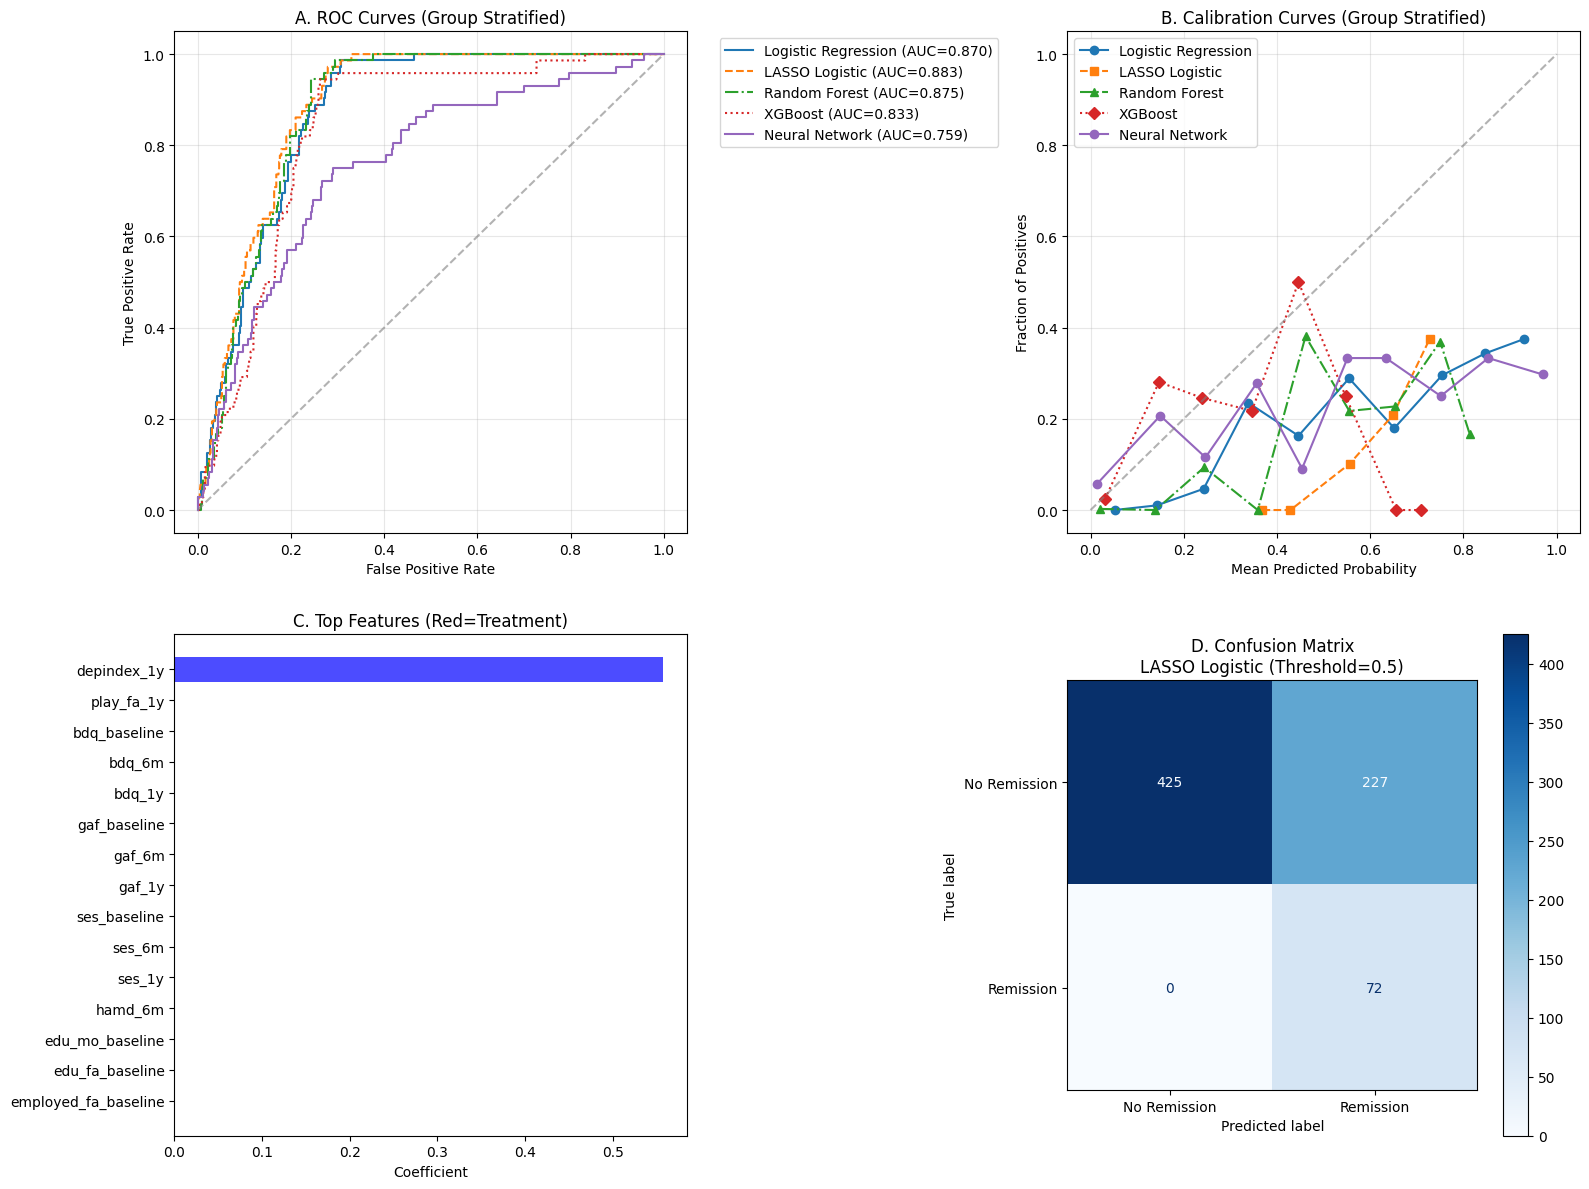

2025-07-27 23:16:20,842 - INFO - Refitted best: LASSO Logistic
2025-07-27 23:16:20,938 - INFO - Calibration on train completed


Spearman correlation between calibrated and uncalibrated probabilities: 0.9752

Hold-out Performance:
Uncalibrated: AUC=0.820, F1=0.429
Calibrated:   AUC=0.801, F1=0.000


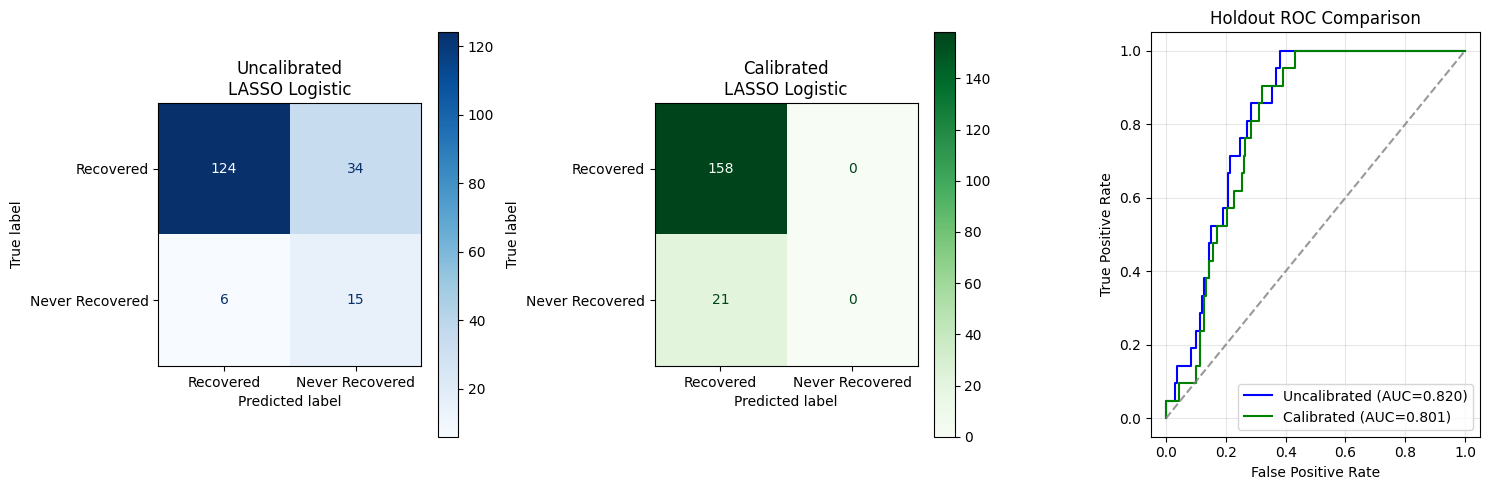

2025-07-27 23:16:21,111 - INFO - Performing SHAP analysis...
2025-07-27 23:16:21,112 - INFO - Treatment variable included in SHAP: True



Detailed Holdout Metrics:
Metric          Uncalibrated Calibrated  
---------------------------------------
Accuracy        0.777        0.883       
Precision       0.306        0.000       
Recall          0.714        0.000       
F1 Score        0.429        0.000       
AUC             0.820        0.801       
Specificity     0.785        1.000       
Sensitivity     0.714        0.000       

Confusion Matrix Components:
Component       Uncalibrated Calibrated  
---------------------------------------
True Positives  15           0           
False Positives 34           0           
True Negatives  124          158         
False Negatives 6            21          


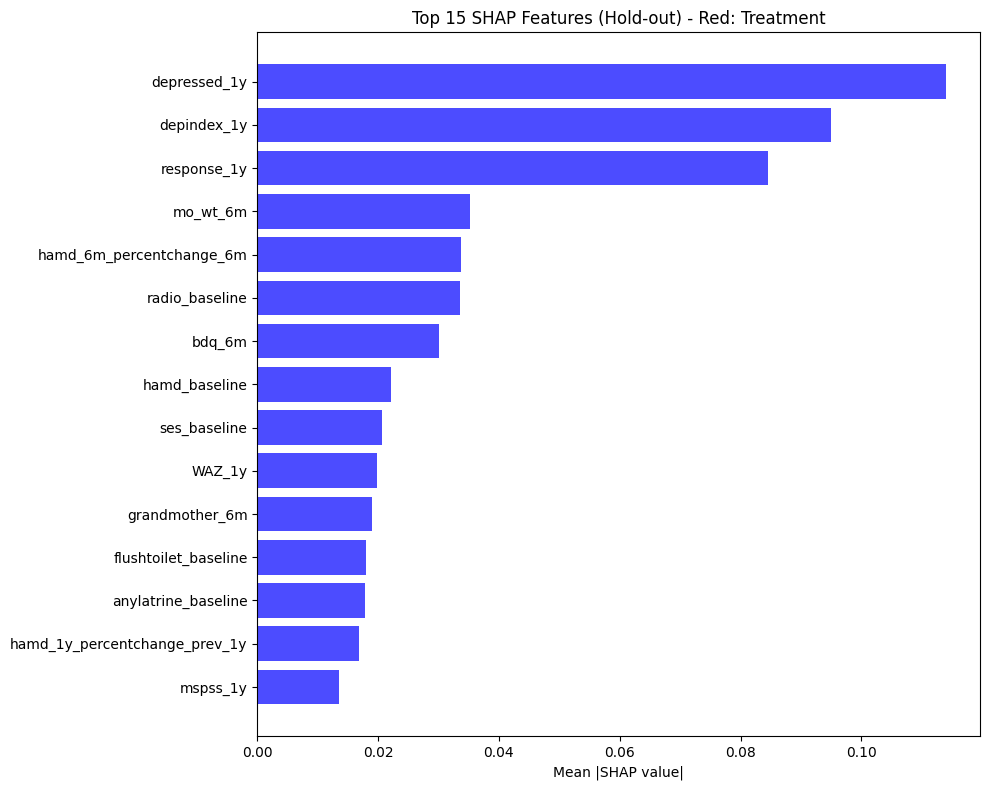

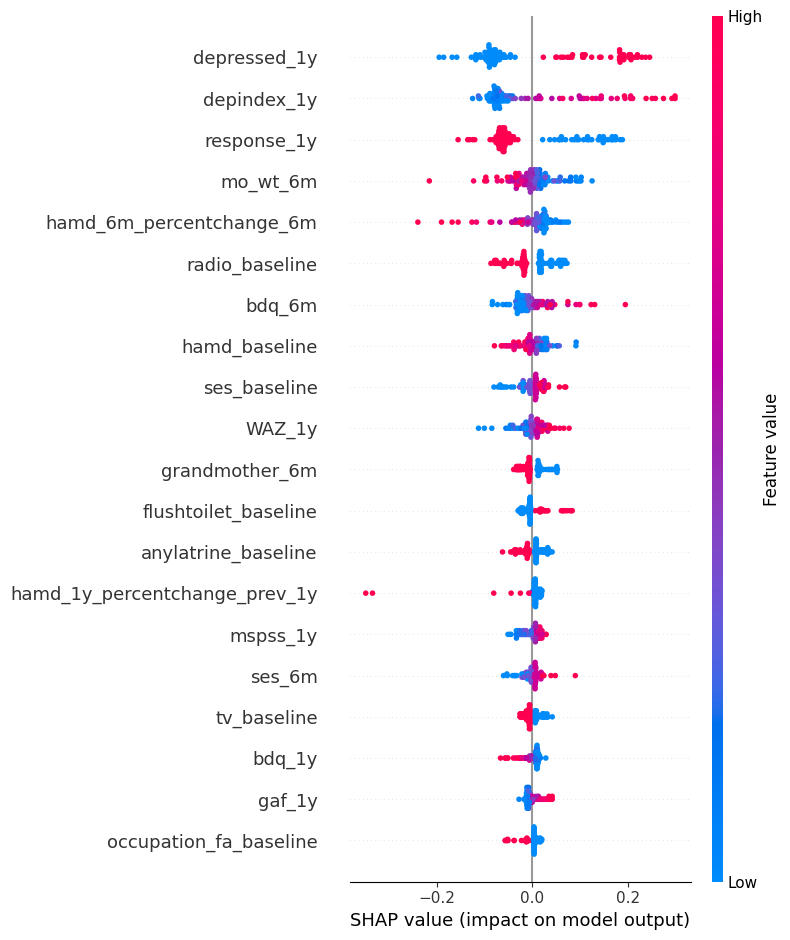


Generating SHAP Personas...
Top 3 SHAP features: ['response_1y', 'depindex_1y', 'depressed_1y']

Top-3 SHAP Personas:
                                                Profile  P(never recovered)
   response_1y=low & depindex_1y=low & depressed_1y=low               0.051
  response_1y=low & depindex_1y=low & depressed_1y=high               0.100
  response_1y=low & depindex_1y=high & depressed_1y=low               0.099
 response_1y=low & depindex_1y=high & depressed_1y=high               0.197
  response_1y=high & depindex_1y=low & depressed_1y=low               0.033
 response_1y=high & depindex_1y=low & depressed_1y=high               0.063
 response_1y=high & depindex_1y=high & depressed_1y=low               0.062
response_1y=high & depindex_1y=high & depressed_1y=high               0.123


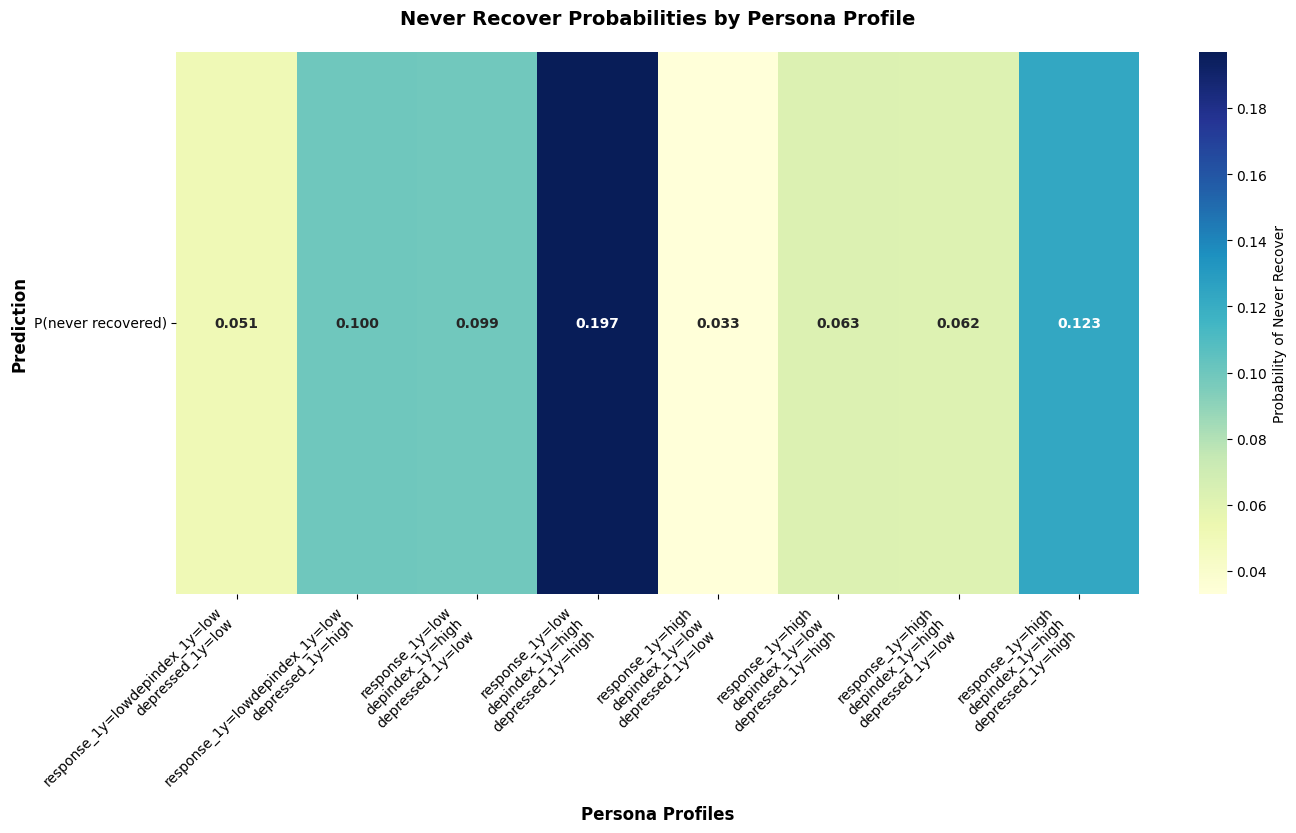

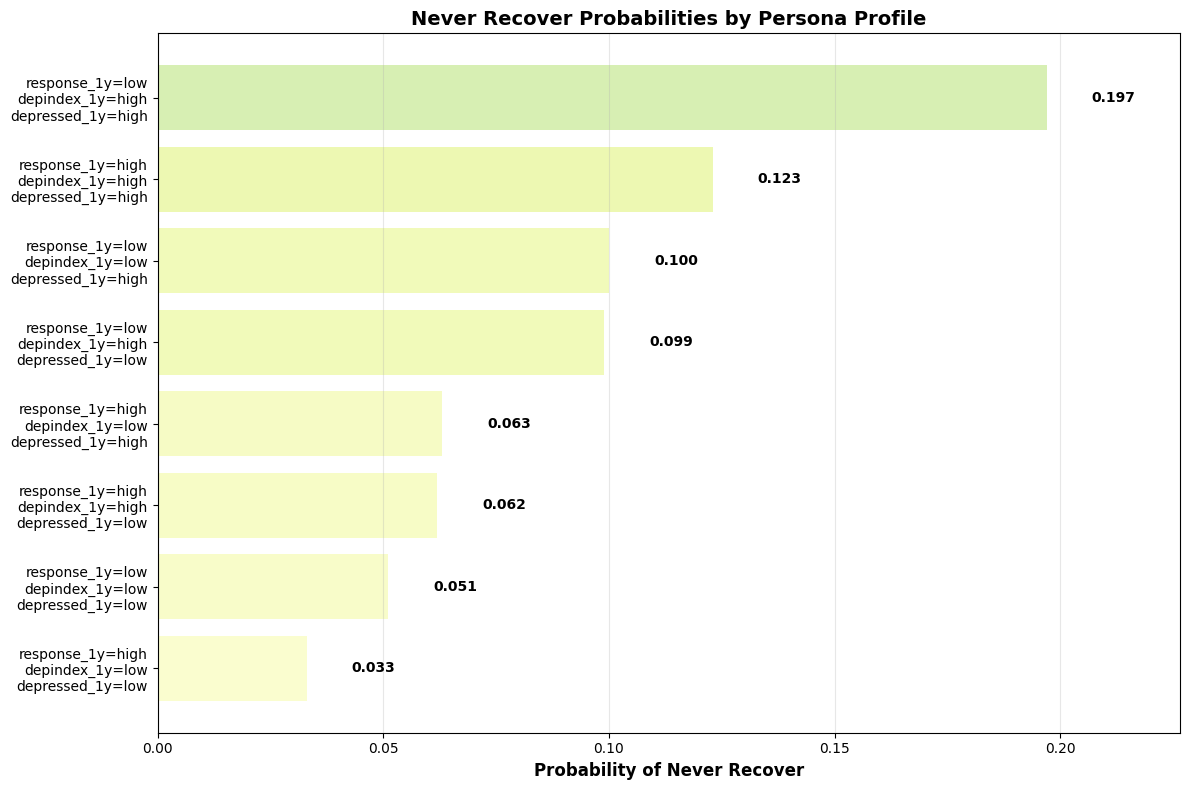


Debugging - Horizontal bar chart data:
Original proto_df:
                                             Profile  P(never recovered)
0  response_1y=low & depindex_1y=low & depressed_...               0.051
1  response_1y=low & depindex_1y=low & depressed_...               0.100
2  response_1y=low & depindex_1y=high & depressed...               0.099
3  response_1y=low & depindex_1y=high & depressed...               0.197
4  response_1y=high & depindex_1y=low & depressed...               0.033
5  response_1y=high & depindex_1y=low & depressed...               0.063
6  response_1y=high & depindex_1y=high & depresse...               0.062
7  response_1y=high & depindex_1y=high & depresse...               0.123

Sorted data for horizontal chart:
                                             Profile  P(never recovered)
4  response_1y=high & depindex_1y=low & depressed...               0.033
0  response_1y=low & depindex_1y=low & depressed_...               0.051
6  response_1y=high & depindex

In [ ]:
# Never recovered at 7 years - no SMOTE, no univariate selection, cluster-stratified CV

# ========= Imports =========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import tensorflow as tf 
import logging
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GroupKFold, StratifiedGroupKFold
from skopt import BayesSearchCV

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from tabulate import tabulate
from itertools import product
import warnings
warnings.filterwarnings("ignore")

# ========= Configuration =========
@dataclass
class Config:
    RANDOM_STATE: int = 123
    N_FEATURES: int = 15
    OUTER_SPLITS: int = 5
    INNER_SPLITS: int = 3
    N_ITER: int = 20
    TEST_SIZE: float = 0.2
    TARGET_COL: str = "recover_never"
    CLUSTER_COL: str = "uc"  # cluster column for stratification
    ID_COL: str = "newid"
    EXCLUDE_COLS: List[str] = None
    MIN_CLUSTER_SIZE: int = 2  # Minimum samples per cluster for valid splits
    
    def __post_init__(self):
        if self.EXCLUDE_COLS is None:
            self.EXCLUDE_COLS = ["recover_never", "recurrence_7y", "remission_1y", 
"remission_6mo", "recovery_1y", "uc"]  # Exclude cluster from features

config = Config()

# ========= Logging Setup =========
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ========= Data Validation =========
def validate_data(df: pd.DataFrame, target_col: str, cluster_col: str, required_cols: List[str]) -> None:
    """Validate input data quality"""
    assert not df.empty, "DataFrame is empty"
    assert target_col in df.columns, f"Target column '{target_col}' not found"
    assert cluster_col in df.columns, f"Cluster column '{cluster_col}' not found"
    
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    assert df[target_col].nunique() > 1, "Target has only one class"
    
    # Validate cluster distribution
    cluster_sizes = df[cluster_col].value_counts()
    min_cluster_size = cluster_sizes.min()
    logger.info(f"Data validation passed. Shape: {df.shape}")
    logger.info(f"Clusters: {sorted(df[cluster_col].unique())}")
    logger.info(f"Cluster sizes: min={min_cluster_size}, max={cluster_sizes.max()}, mean={cluster_sizes.mean():.1f}")
    logger.info(f"Target distribution: {df[target_col].value_counts().to_dict()}")
    
    if min_cluster_size < config.MIN_CLUSTER_SIZE:
        logger.warning(f"Some clusters have <{config.MIN_CLUSTER_SIZE} samples, which may cause CV issues")

def validate_cluster_separation(train_clusters: np.ndarray, test_clusters: np.ndarray, 
                              fold_num: int = None) -> bool:
    """Validate that train and test clusters are completely separated"""
    train_set = set(train_clusters)
    test_set = set(test_clusters)
    overlap = train_set & test_set
    
    if overlap:
        logger.error(f"Fold {fold_num}: Cluster overlap detected: {overlap}")
        return False
    
    logger.info(f"Fold {fold_num}: Cluster separation validated. "
                f"Train clusters: {len(train_set)}, Test clusters: {len(test_set)}")
    return True

# ========= FIXED: Stratified Group Train/Test Split =========
def create_stratified_group_split(df: pd.DataFrame, target_col: str, cluster_col: str, 
                                test_size: float, random_state: int) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Create train/test split that maintains complete cluster separation while balancing target distribution
    """
    np.random.seed(random_state)
    
    # Calculate target distribution within each cluster
    cluster_stats = df.groupby(cluster_col)[target_col].agg(['count', 'mean']).reset_index()
    cluster_stats['target_ratio'] = cluster_stats['mean']
    cluster_stats = cluster_stats.sort_values('target_ratio')
    
    logger.info(f"Cluster target distribution:\n{cluster_stats}")
    
    # Stratified sampling of clusters based on target ratio
    total_clusters = len(cluster_stats)
    n_test_clusters = max(1, int(total_clusters * test_size))
    
    # Divide clusters into strata based on target ratio quartiles
    cluster_stats['stratum'] = pd.qcut(cluster_stats['target_ratio'], 
                                     q=min(4, total_clusters), 
                                     labels=False, 
                                     duplicates='drop')
    
    test_clusters = []
    for stratum in cluster_stats['stratum'].unique():
        stratum_clusters = cluster_stats[cluster_stats['stratum'] == stratum][cluster_col].values
        n_from_stratum = max(1, int(len(stratum_clusters) * test_size))
        selected = np.random.choice(stratum_clusters, n_from_stratum, replace=False)
        test_clusters.extend(selected)
    
    # Ensure we have the right number of test clusters
    if len(test_clusters) < n_test_clusters:
        remaining_clusters = cluster_stats[~cluster_stats[cluster_col].isin(test_clusters)][cluster_col].values
        additional = np.random.choice(remaining_clusters, 
                                    n_test_clusters - len(test_clusters), 
                                    replace=False)
        test_clusters.extend(additional)
    elif len(test_clusters) > n_test_clusters:
        test_clusters = np.random.choice(test_clusters, n_test_clusters, replace=False)
    
    test_clusters = list(test_clusters)
    train_clusters = [c for c in df[cluster_col].unique() if c not in test_clusters]
    
    # Create splits
    train_df = df[df[cluster_col].isin(train_clusters)].copy()
    test_df = df[df[cluster_col].isin(test_clusters)].copy()
    
    # Validate separation
    if not validate_cluster_separation(train_df[cluster_col].values, test_df[cluster_col].values, "HOLDOUT"):
        raise ValueError("Failed to create properly separated train/test split")
    
    # Log distributions
    logger.info(f"Train: {len(train_df)} samples, {len(train_clusters)} clusters")
    logger.info(f"Test: {len(test_df)} samples, {len(test_clusters)} clusters")
    logger.info(f"Train target dist: {train_df[target_col].value_counts().to_dict()}")
    logger.info(f"Test target dist: {test_df[target_col].value_counts().to_dict()}")
    
    return train_df, test_df

# ========= FIXED: Custom CV Class with Proper Validation =========
class ValidatedGroupKFold:
    """
    GroupKFold wrapper with validation and fallback mechanisms
    """
    def __init__(self, n_splits: int = 5, shuffle: bool = True, random_state: int = None):
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state
        self.group_kfold = GroupKFold(n_splits=n_splits)
    
    def split(self, X, y, groups):
        """Generate validated group-based splits"""
        if groups is None:
            raise ValueError("Groups cannot be None for GroupKFold")
        
        # Convert to numpy arrays for consistency
        if hasattr(X, 'shape'):
            n_samples = X.shape[0]
        else:
            n_samples = len(X)
        
        y = np.asarray(y)
        groups = np.asarray(groups)
        
        # Check if we have enough unique groups
        unique_groups = np.unique(groups)
        if len(unique_groups) < self.n_splits:
            logger.warning(f"Only {len(unique_groups)} groups for {self.n_splits} splits. "
                         f"Falling back to StratifiedKFold")
            skf = StratifiedKFold(n_splits=min(self.n_splits, len(unique_groups)), 
                                shuffle=self.shuffle, random_state=self.random_state)
            yield from skf.split(X, y)
            return
        
        # Use StratifiedGroupKFold for better target distribution balance
        try:
            sgkf = StratifiedGroupKFold(n_splits=self.n_splits, shuffle=self.shuffle, 
                                      random_state=self.random_state)
            splits = list(sgkf.split(X, y, groups))
        except (ValueError, Exception) as e:
            logger.warning(f"StratifiedGroupKFold failed: {e}. Falling back to GroupKFold")
            splits = list(self.group_kfold.split(X, y, groups))
        
        # Validate each split
        valid_splits = []
        for fold_idx, (train_idx, test_idx) in enumerate(splits):
            train_groups = groups[train_idx]
            test_groups = groups[test_idx]
            
            # Validate cluster separation
            if validate_cluster_separation(train_groups, test_groups, fold_idx + 1):
                # Additional validation: ensure both train and test have samples
                if len(train_idx) > 0 and len(test_idx) > 0:
                    # Check target distribution in both sets
                    train_targets = y[train_idx]
                    test_targets = y[test_idx]
                    
                    if len(np.unique(train_targets)) > 1 and len(np.unique(test_targets)) > 1:
                        valid_splits.append((train_idx, test_idx))
                        logger.info(f"Fold {fold_idx + 1}: Train={len(train_idx)}, Test={len(test_idx)}, "
                                  f"Train target ratio={train_targets.mean():.3f}, "
                                  f"Test target ratio={test_targets.mean():.3f}")
                    else:
                        logger.warning(f"Fold {fold_idx + 1}: Insufficient target diversity, skipping")
                else:
                    logger.warning(f"Fold {fold_idx + 1}: Empty train or test set, skipping")
            else:
                logger.warning(f"Fold {fold_idx + 1}: Failed cluster separation validation, skipping")
        
        if len(valid_splits) < 2:
            raise ValueError(f"Only {len(valid_splits)} valid folds generated, need at least 2")
        
        logger.info(f"Generated {len(valid_splits)} valid folds out of {len(splits)} attempted")
        yield from valid_splits
    
    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

# ========= FIXED: Simple Pipeline Builder =========
def build_simple_pipeline(base_model, config: Config):
    """Build a simple pipeline with only preprocessing and model"""
    pipeline = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('model', base_model)
    ])
    return pipeline

# ========= FIXED: Nested CV with Proper GroupKFold =========
def run_nested_cv_group_stratified(model, param_distributions: Dict, X: pd.DataFrame, y: np.ndarray, 
                                  groups: np.ndarray, config: Config) -> Dict[str, Any]:
    """
    FIXED: Nested CV with proper GroupKFold implementation
    """
    # Initialize CV splitters
    outer_cv = ValidatedGroupKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                                  random_state=config.RANDOM_STATE)
    inner_cv = ValidatedGroupKFold(n_splits=config.INNER_SPLITS, shuffle=True, 
                                  random_state=config.RANDOM_STATE + 1)

    # Convert DataFrame to numpy for consistent indexing
    X_values = X.values if hasattr(X, 'values') else X
    y = np.asarray(y)
    groups = np.asarray(groups)
    
    # Initialize results arrays
    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    outer_scores = []
    successful_folds = 0
    treatment_scores = []

    try:
        # Generate outer CV splits
        outer_splits = list(outer_cv.split(X_values, y, groups))
        logger.info(f"Generated {len(outer_splits)} outer CV folds")
        
        for fold, (train_idx, test_idx) in enumerate(outer_splits):
            logger.info(f"Processing outer fold {fold + 1}/{len(outer_splits)}")
            
            try:
                # Extract fold data
                X_train_fold = X.iloc[train_idx] if hasattr(X, 'iloc') else X_values[train_idx]
                y_train_fold = y[train_idx]
                groups_train_fold = groups[train_idx]
                X_test_fold = X.iloc[test_idx] if hasattr(X, 'iloc') else X_values[test_idx]
                y_test_fold = y[test_idx]

                # Log fold statistics
                logger.info(f"Fold {fold+1}: Train={len(train_idx)}, Test={len(test_idx)}")
                if hasattr(X, 'columns') and 'treat' in X.columns:
                    treat_col_idx = X.columns.get_loc('treat')
                    if hasattr(X, 'iloc'):
                        treat_dist = X.iloc[train_idx, treat_col_idx].value_counts()
                    else:
                        treat_dist = pd.Series(X_values[train_idx, treat_col_idx]).value_counts()
                    logger.info(f"Fold {fold+1} treatment distribution: {treat_dist.to_dict()}")

                # Build pipeline
                pipe = build_simple_pipeline(model, config)
                
                # FIXED: Properly configure BayesSearchCV with explicit CV
                search_space = {f'model__{k}': v for k, v in param_distributions.items()}
                
                # Generate inner CV splits for this fold
                try:
                    inner_splits = list(inner_cv.split(X_train_fold, y_train_fold, groups_train_fold))
                    logger.info(f"Fold {fold+1}: Generated {len(inner_splits)} inner CV splits")
                except Exception as e:
                    logger.warning(f"Fold {fold+1}: Inner CV failed: {e}. Using 3-fold StratifiedKFold")
                    inner_splits = list(StratifiedKFold(n_splits=3, shuffle=True, 
                                                      random_state=config.RANDOM_STATE).split(X_train_fold, y_train_fold))
                
                search = BayesSearchCV(
                    pipe,
                    search_spaces=search_space,
                    n_iter=config.N_ITER,
                    scoring='roc_auc',
                    cv=inner_splits,  # FIXED: Pass list of splits, not generator
                    n_jobs=1,
                    random_state=config.RANDOM_STATE,
                    error_score='raise'
                )
                
                # Fit hyperparameter search
                if hasattr(X_train_fold, 'values'):
                    search.fit(X_train_fold, y_train_fold)
                else:
                    # Convert back to DataFrame for proper feature handling
                    X_train_df = pd.DataFrame(X_train_fold, columns=X.columns)
                    search.fit(X_train_df, y_train_fold)
                
                best_model = search.best_estimator_

                # Extract treatment information
                model_obj = best_model.named_steps['model']
                treat_info = {'fold': fold + 1, 'treat_coef': 0, 'treat_importance': 0}
                
                if hasattr(model_obj, 'coef_') and hasattr(X, 'columns') and 'treat' in X.columns:
                    treat_idx = X.columns.get_loc('treat')
                    treat_coef = model_obj.coef_[0][treat_idx]
                    treat_info['treat_coef'] = treat_coef
                    logger.info(f"Fold {fold+1}: Treatment coefficient = {treat_coef:.3f}")
                elif hasattr(model_obj, 'feature_importances_') and hasattr(X, 'columns') and 'treat' in X.columns:
                    treat_idx = X.columns.get_loc('treat')
                    treat_importance = model_obj.feature_importances_[treat_idx]
                    treat_info['treat_importance'] = treat_importance
                    logger.info(f"Fold {fold+1}: Treatment importance = {treat_importance:.3f}")
                
                treatment_scores.append(treat_info)

                # Make predictions
                if hasattr(X_test_fold, 'values'):
                    prob = best_model.predict_proba(X_test_fold)[:, 1]
                else:
                    X_test_df = pd.DataFrame(X_test_fold, columns=X.columns)
                    prob = best_model.predict_proba(X_test_df)[:, 1]
                
                pred = (prob > 0.5).astype(int)
                
                # Store results
                y_probs[test_idx] = prob
                y_preds[test_idx] = pred
                auc_score = roc_auc_score(y_test_fold, prob)
                outer_scores.append(auc_score)
                successful_folds += 1
                
                logger.info(f"Fold {fold+1} AUC: {auc_score:.3f}")
                
            except Exception as e:
                logger.error(f"Error in fold {fold + 1}: {e}")
                # For failed folds, use neutral predictions
                y_probs[test_idx] = 0.5
                y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
                outer_scores.append(0.5)

    except Exception as e:
        logger.error(f"Critical error in nested CV: {e}")
        raise

    # Validate results
    if successful_folds < max(1, config.OUTER_SPLITS // 2):
        raise RuntimeError(f"Too many folds failed: {successful_folds}/{len(outer_splits)}")

    # Calculate metrics on valid predictions only
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    # Log treatment importance summary
    if treatment_scores:
        avg_treat_coef = np.mean([t.get('treat_coef', 0) for t in treatment_scores])
        avg_treat_importance = np.mean([t.get('treat_importance', 0) for t in treatment_scores])
        logger.info(f"Average treatment coefficient: {avg_treat_coef:.3f}")
        logger.info(f"Average treatment importance: {avg_treat_importance:.3f}")

    return {
        "model": search.best_estimator_ if 'search' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(outer_scores),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": 0,  # Legacy compatibility
        "treatment_scores": treatment_scores
    }

# ========= FIXED: Neural Network CV =========
def run_nn_cv_group_stratified(X: pd.DataFrame, y: np.ndarray, groups: np.ndarray, config: Config) -> Dict[str, Any]:
    """FIXED: Neural network CV with proper GroupKFold"""
    outer_cv = ValidatedGroupKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                                  random_state=config.RANDOM_STATE)
    
    # Convert to numpy for consistent indexing
    X_values = X.values if hasattr(X, 'values') else X
    y = np.asarray(y)
    groups = np.asarray(groups)
    
    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    aucs = []
    successful_folds = 0
    feature_names = X.columns.tolist() if hasattr(X, 'columns') else None
    treatment_scores = []

    try:
        outer_splits = list(outer_cv.split(X_values, y, groups))
        logger.info(f"NN: Generated {len(outer_splits)} outer CV folds")
        
        for fold, (train_idx, test_idx) in enumerate(outer_splits):
            logger.info(f"Processing NN fold {fold + 1}/{len(outer_splits)}")
            
            try:
                # Extract fold data
                X_train_fold = X.iloc[train_idx] if hasattr(X, 'iloc') else X_values[train_idx]
                y_train_fold = y[train_idx]
                X_test_fold = X.iloc[test_idx] if hasattr(X, 'iloc') else X_values[test_idx]
                y_test_fold = y[test_idx]

                # Apply preprocessing
                imputer = SimpleImputer(strategy='median')
                scaler = StandardScaler()
                
                X_train_processed = imputer.fit_transform(X_train_fold)
                X_train_scaled = scaler.fit_transform(X_train_processed)
                
                logger.info(f"NN Fold {fold+1}: Training on {len(X_train_scaled)} samples, "
                           f"class distribution: {np.bincount(y_train_fold)}")

                # Track treatment info
                treat_info = {'fold': fold + 1, 'treat_coef': 0, 'treat_importance': 0}
                treatment_scores.append(treat_info)
                
                # Build and train model
                model = build_nn_model(input_dim=X_train_scaled.shape[1])
                
                # Compute class weights
                unique_classes = np.unique(y_train_fold)
                if len(unique_classes) > 1:
                    cw_vals = compute_class_weight('balanced', classes=unique_classes, y=y_train_fold)
                    class_weights = {i: w for i, w in enumerate(cw_vals)}
                else:
                    class_weights = None
                
                batch_size = max(8, min(32, len(X_train_scaled) // 4))
                
                model.fit(
                    X_train_scaled, y_train_fold,
                    validation_split=0.2,
                    epochs=100,
                    batch_size=batch_size,
                    callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
                    class_weight=class_weights,
                    verbose=0
                )

                # Transform test data and predict
                X_test_processed = imputer.transform(X_test_fold)
                X_test_scaled = scaler.transform(X_test_processed)
                
                prob = model.predict(X_test_scaled, verbose=0).ravel()
                pred = (prob > 0.5).astype(int)
                
                y_probs[test_idx] = prob
                y_preds[test_idx] = pred
                auc_score = roc_auc_score(y_test_fold, prob)
                aucs.append(auc_score)
                successful_folds += 1
                
                logger.info(f"NN Fold {fold+1} AUC: {auc_score:.3f}")
                
            except Exception as e:
                logger.error(f"Error in NN fold {fold + 1}: {e}")
                y_probs[test_idx] = 0.5
                y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
                aucs.append(0.5)

    except Exception as e:
        logger.error(f"Critical error in NN CV: {e}")
        raise

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid NN predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    logger.info(f"NN: Completed {successful_folds}/{len(outer_splits)} folds")

    return {
        "model": model if 'model' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(aucs),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": 0,
        "treatment_scores": treatment_scores
    }

# ========= Leak-Free Preprocessor (No changes needed) =========
class LeakFreePreprocessor:
    """Preprocessing that prevents data leakage by fitting only on training folds"""
    
    def __init__(self, config: Config):
        self.config = config
        self.imputer = None
        self.scaler = None
        self.label_encoder = None
        self.feature_names = None
        
    def fit(self, X: pd.DataFrame, y: pd.Series) -> 'LeakFreePreprocessor':
        """Fit preprocessor components separately to allow proper CV"""
        self.feature_names = X.columns.tolist()
        
        # Fit components
        self.imputer = SimpleImputer(strategy='median')
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        
        # Fit on training data
        X_imputed = self.imputer.fit_transform(X)
        self.scaler.fit(X_imputed)
        self.label_encoder.fit(y)
        
        logger.info(f"Preprocessor fitted on {X.shape[0]} samples, {X.shape[1]} features")
        return self
    
    def transform_features(self, X):
        """Transform features using fitted preprocessor"""
        if isinstance(X, pd.DataFrame):
            X_ordered = X.reindex(columns=self.feature_names, fill_value=np.nan)
            X_values = X_ordered.values
        else:
            X_values = X
            
        X_imputed = self.imputer.transform(X_values)
        X_scaled = self.scaler.transform(X_imputed)
        return X_scaled
    
    def transform_target(self, y: pd.Series) -> np.ndarray:
        """Transform target using fitted label encoder"""
        return self.label_encoder.transform(y)
    
    def get_feature_names(self) -> List[str]:
        """Get original feature names"""
        return self.feature_names.copy()

# ========= Neural Network Builder (No changes) =========
def build_nn_model(input_dim: int, neurons1: int = 64, neurons2: int = 32, 
                   dropout: float = 0.3, learning_rate: float = 1e-3) -> tf.keras.Model:
    """Build neural network with improved architecture"""
    model = Sequential([
        Dense(neurons1, activation='relu', input_dim=input_dim,
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(neurons2, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model

# ========= Utility Functions =========
def calculate_holdout_metrics(y_true: np.ndarray, y_pred: np.ndarray, 
                            y_proba: np.ndarray) -> Dict[str, float]:
    """Calculate comprehensive holdout metrics including confusion matrix components"""
    cm = confusion_matrix(y_true, y_pred)
    
    # Extract confusion matrix components
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true, y_proba),
        'Brier Score': brier_score_loss(y_true, y_proba),
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0
    }

# ========= Enhanced plot_performance_curves Function =========
def plot_performance_curves(results: Dict, y_true: np.ndarray, feature_names, title_suffix: str = "", threshold: float = 0.5):
    """Generate annotated ROC, calibration curves, feature importance, and confusion matrix with enhanced readability."""
    import matplotlib.pyplot as plt
    import numpy as np
    from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
    from sklearn.calibration import calibration_curve

    plt.figure(figsize=(16, 12))
    line_styles = ['-', '--', '-.', ':']
    markers = ['o', 's', '^', 'D']
    colors = plt.cm.tab10.colors
    model_names = list(results.keys())

    # ROC Curves
    plt.subplot(2, 2, 1)
    for idx, name in enumerate(model_names):
        res = results[name]
        if res and 'y_probs' in res:
            valid_mask = res['y_probs'] >= 0
            if np.any(valid_mask):
                y_valid = y_true[valid_mask]
                probs_valid = res['y_probs'][valid_mask]
                fpr, tpr, _ = roc_curve(y_valid, probs_valid)
                auc = roc_auc_score(y_valid, probs_valid)
                label = f"{name} (AUC={auc:.3f})"
                plt.plot(fpr, tpr, label=label,
                         linestyle=line_styles[idx % len(line_styles)],
                         color=colors[idx % len(colors)])
    plt.plot([0, 1], [0, 1], '--', color='gray', alpha=0.6)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"A. ROC Curves {title_suffix}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)

    # Calibration Curves
    plt.subplot(2, 2, 2)
    for idx, name in enumerate(model_names):
        res = results[name]
        if res and 'y_probs' in res:
            valid_mask = res['y_probs'] >= 0
            if np.any(valid_mask):
                y_valid = y_true[valid_mask]
                probs_valid = res['y_probs'][valid_mask]
                frac_pos, mean_pred = calibration_curve(y_valid, probs_valid, n_bins=10)
                plt.plot(mean_pred, frac_pos,
                         marker=markers[idx % len(markers)],
                         linestyle=line_styles[idx % len(line_styles)],
                         color=colors[idx % len(colors)],
                         label=name)
    plt.plot([0, 1], [0, 1], '--', color='gray', alpha=0.6)
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title(f"B. Calibration Curves {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Feature Importance
    plt.subplot(2, 2, 3)
    try:
        best_model_name = max(results.keys(), key=lambda k: results[k]['metrics']['AUC'] if results[k] else 0)
        best_model = results[best_model_name]['model']
        if hasattr(best_model, 'named_steps'):
            model_obj = best_model.named_steps['model']
            if hasattr(model_obj, 'coef_'):
                coeffs = model_obj.coef_[0]
                top_idx = np.argsort(np.abs(coeffs))[-15:]
                top_feats = [feature_names[i] for i in top_idx]
                colors_bar = ['red' if feat == 'treat' else 'blue' for feat in top_feats]
                plt.barh(range(len(top_idx)), coeffs[top_idx], color=colors_bar, alpha=0.7)
                plt.yticks(range(len(top_idx)), top_feats)
                plt.xlabel("Coefficient")
                plt.title("C. Top Features (Red=Treatment)")
            elif hasattr(model_obj, 'feature_importances_'):
                importances = model_obj.feature_importances_
                top_idx = np.argsort(importances)[-15:]
                top_feats = [feature_names[i] for i in top_idx]
                colors_bar = ['red' if feat == 'treat' else 'blue' for feat in top_feats]
                plt.barh(range(len(top_idx)), importances[top_idx], color=colors_bar, alpha=0.7)
                plt.yticks(range(len(top_idx)), top_feats)
                plt.xlabel("Importance")
                plt.title("C. Top Features (Red=Treatment)")
            else:
                plt.text(0.5, 0.5, "Feature importance\nnot available",
                         ha='center', va='center', transform=plt.gca().transAxes)
    except Exception as e:
        print(f"Error plotting feature importance: {e}")
        plt.text(0.5, 0.5, "Feature importance\nnot available",
                 ha='center', va='center', transform=plt.gca().transAxes)

    # Confusion Matrix
    plt.subplot(2, 2, 4)
    try:
        res = results[best_model_name]
        valid_mask = res['y_probs'] >= 0
        if np.any(valid_mask):
            y_valid = y_true[valid_mask]
            y_pred_valid = (res['y_probs'][valid_mask] >= threshold).astype(int)
            cm = confusion_matrix(y_valid, y_pred_valid)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Reovered', 'Never Recovered'])
            disp.plot(ax=plt.gca(), cmap='Blues', values_format='d')
            plt.title(f"D. Confusion Matrix\n{best_model_name} (Threshold={threshold})")
    except Exception as e:
        print(f"Error plotting confusion matrix: {e}")
        plt.text(0.5, 0.5, "Confusion Matrix\nnot available",
                 ha='center', va='center', transform=plt.gca().transAxes)

    plt.tight_layout()
    plt.show()

# ========= Holdout Confusion Matrix Function =========
def plot_holdout_confusion_matrices(y_true, preds_unc, preds_cal, probs_unc, probs_cal, best_name):
    """Plot confusion matrices for holdout predictions"""
    plt.figure(figsize=(15, 5))
    
    # Uncalibrated Confusion Matrix
    plt.subplot(1, 3, 1)
    cm_unc = confusion_matrix(y_true, preds_unc)
    disp_unc = ConfusionMatrixDisplay(confusion_matrix=cm_unc, 
                                     display_labels=['Recovered', 'Never Recovered'])
    disp_unc.plot(ax=plt.gca(), cmap='Blues', values_format='d')
    plt.title(f"Uncalibrated\n{best_name}")
    
    # Calibrated Confusion Matrix
    plt.subplot(1, 3, 2)
    cm_cal = confusion_matrix(y_true, preds_cal)
    disp_cal = ConfusionMatrixDisplay(confusion_matrix=cm_cal, 
                                     display_labels=['Recovered', 'Never Recovered'])
    disp_cal.plot(ax=plt.gca(), cmap='Greens', values_format='d')
    plt.title(f"Calibrated\n{best_name}")
    
    # ROC Comparison
    plt.subplot(1, 3, 3)
    fpr_unc, tpr_unc, _ = roc_curve(y_true, probs_unc)
    fpr_cal, tpr_cal, _ = roc_curve(y_true, probs_cal)
    
    auc_unc = roc_auc_score(y_true, probs_unc)
    auc_cal = roc_auc_score(y_true, probs_cal)
    
    plt.plot(fpr_unc, tpr_unc, label=f'Uncalibrated (AUC={auc_unc:.3f})', color='blue')
    plt.plot(fpr_cal, tpr_cal, label=f'Calibrated (AUC={auc_cal:.3f})', color='green')
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Holdout ROC Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ========= SHAP Feature Analysis =========
def perform_shap_analysis(best_model, X_holdout: np.ndarray, feature_names: List[str],
                         preprocessor: LeakFreePreprocessor, holdout_raw: pd.DataFrame):
    """Perform SHAP analysis with proper error handling"""
    try:
        logger.info("Performing SHAP analysis...")
        
        model_obj = best_model.named_steps['model']
        if not hasattr(model_obj, 'predict_proba'):
            logger.warning("Model doesn't support probability prediction, skipping SHAP")
            return None
        
        # Use all features - no feature selection
        X_for_shap = X_holdout
        shap_feature_names = feature_names
        
        # Highlight if treatment is included
        treat_included = 'treat' in shap_feature_names
        logger.info(f"Treatment variable included in SHAP: {treat_included}")
        
        n_background = min(100, X_for_shap.shape[0])
        background_data = X_for_shap[:n_background]  # Use this as "features" for SHAP summary plot
        
        if hasattr(model_obj, 'tree_'):
            explainer = shap.TreeExplainer(model_obj)
            shap_values = explainer.shap_values(background_data)
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        else:
            explainer = shap.Explainer(model_obj.predict_proba, background_data)
            shap_values = explainer(background_data)
            if hasattr(shap_values, 'values'):
                shap_values = shap_values.values[:, :, 1]
        
        shap_abs = np.abs(shap_values).mean(axis=0)
        top_n = min(15, len(shap_feature_names))
        top_idx = np.argsort(shap_abs)[-top_n:]
        
        plt.figure(figsize=(10, 8))
        colors = ['red' if shap_feature_names[i] == 'treat' else 'blue' for i in top_idx]
        plt.barh(range(len(top_idx)), shap_abs[top_idx], color=colors, alpha=0.7)
        plt.yticks(range(len(top_idx)), [shap_feature_names[i] for i in top_idx])
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"Top {top_n} SHAP Features (Hold-out) - Red: Treatment")
        plt.tight_layout()
        plt.show()
        
        try:
            shap.summary_plot(
                shap_values, 
                features=background_data, 
                feature_names=shap_feature_names,
                show=False
            )
            plt.tight_layout()
            plt.show()
        except Exception as e:
            logger.warning(f"Error creating SHAP summary plot: {e}")
            
    except Exception as e:
        logger.error(f"Error in SHAP analysis: {e}")
        return None

    return {
    'shap_values': shap_values,
    'feature_names': shap_feature_names,
    'features_used': background_data
}

# ========= UPDATED: Main Pipeline with Fixed GroupKFold =========
def main():
    """UPDATED: Main execution pipeline with fixed GroupKFold implementation"""

    # 1. Load & validate
    try:
        df = imputed_datasets["dat_ml_7y_never"]
        logger.info(f"Data loaded: {df.shape}")
        required = [config.TARGET_COL, config.CLUSTER_COL, config.ID_COL] + config.EXCLUDE_COLS + ['treat']
        validate_data(df, config.TARGET_COL, config.CLUSTER_COL, required)
    except Exception as e:
        logger.error(f"Loading/validation error: {e}")
        return

    # 2. Quick QC
    logger.info(f"Target counts:\n{df[config.TARGET_COL].value_counts()}")
    logger.info(f"Cluster counts:\n{df[config.CLUSTER_COL].value_counts()}")
    logger.info(f"Missing values: {df.isnull().sum().sum()}")

    # 3. FIXED: Improved cluster-stratified train/hold-out split
    train_df, holdout_df = create_stratified_group_split(
        df, config.TARGET_COL, config.CLUSTER_COL, config.TEST_SIZE, config.RANDOM_STATE
    )
    logger.info(f"Train={len(train_df)}, Hold-out={len(holdout_df)}")

    # 4. Prepare training data (preserve DataFrame structure)
    X_train = train_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    y_train = train_df[config.TARGET_COL].values
    groups_train = train_df[config.CLUSTER_COL].values  # Fixed: use groups instead of clusters
    feature_names = X_train.columns.tolist()
    
    logger.info(f"Training features: {len(feature_names)}")
    logger.info(f"Treatment variable included: {'treat' in feature_names}")
    logger.info(f"Unique groups in training: {len(np.unique(groups_train))}")

    # 5. Define models & parameters
    models_and_params = {
        "Logistic Regression": (
            LogisticRegression(max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.01, 0.1, 1.0, 10.0]}
        ),
        "LASSO Logistic": (
            LogisticRegression(penalty='l1', solver='liblinear',
                               max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.001, 0.01, 0.1, 1, 10]}
        ),
        "Random Forest": (
            RandomForestClassifier(class_weight='balanced',
                                   random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "max_depth": [3, 5, 10],
             "min_samples_split": [5, 10],
             "min_samples_leaf": [2, 5]}
        ),
        "XGBoost": (
            XGBClassifier(use_label_encoder=False,
                          eval_metric='logloss',
                          random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "learning_rate": [0.01, 0.1],
             "max_depth": [3, 6],
             "subsample": [0.8, 1.0]}
        )
    }

    # 6. FIXED: Run nested CV with proper GroupKFold
    results = {}
    for name, (model, params) in models_and_params.items():
        logger.info(f"→ Nested CV: {name}")
        try:
            results[name] = run_nested_cv_group_stratified(
                model, params, X_train, y_train, groups_train, config
            )
            logger.info(f"   AUC={results[name]['metrics']['AUC']:.3f}")
        except Exception as e:
            logger.error(f"   {name} failed: {e}")

    # 7. FIXED: Neural network with GroupKFold
    try:
        logger.info("→ Nested CV: Neural Network")
        results['Neural Network'] = run_nn_cv_group_stratified(X_train, y_train, groups_train, config)
        logger.info(f"   AUC={results['Neural Network']['metrics']['AUC']:.3f}")
    except Exception as e:
        logger.error(f"   NN failed: {e}")

    # 8. Show performance table
    perf_rows = []
    for m, res in results.items():
        if res and 'metrics' in res:
            row = {"Model": m}
            row.update({k: round(v, 3) for k, v in res['metrics'].items()})
            row["Folds"] = res.get('successful_folds', 'N/A')
            perf_rows.append(row)
    
    if not perf_rows:
        logger.error("No successful models to display")
        return
        
    perf_df = pd.DataFrame(perf_rows)
    print("\nNested CV Performance (Group Stratified)")
    print(tabulate(perf_df, headers='keys', tablefmt='grid', showindex=False))

    # 9. Fit preprocessor on full training data
    preprocessor = LeakFreePreprocessor(config)
    preprocessor.fit(X_train, train_df[config.TARGET_COL])
    
    # Transform training data
    X_train_proc = preprocessor.transform_features(X_train)
    y_train_processed = preprocessor.transform_target(train_df[config.TARGET_COL])
    
    logger.info(f"Final training data: {X_train_proc.shape}, class distribution: {np.bincount(y_train_processed)}")

    # 10. Plot OOF performance
    plot_performance_curves(results, y_train, feature_names, title_suffix="(Group Stratified)")

    # 11. Refit best pipeline on full training data
    if not results:
        logger.error("No successful models to select from")
        return

    best_name = max(results, key=lambda k: results[k]['metrics']['AUC'] if results[k] else 0)
    best_result = results[best_name]

    if not best_result or 'model' not in best_result:
        logger.error(f"Best model {best_name} has no trained model")
        return

    # Build and fit new pipeline on full processed data
    best_base_model = models_and_params[best_name][0]
    best_pipe = results[best_name]['model']           
    best_pipe.fit(X_train, y_train)
    logger.info(f"Refitted best: {best_name}")

    # 12. Calibrate via Platt scaling
    calibrator = CalibratedClassifierCV(
        estimator=best_pipe.named_steps['model'],
        method='sigmoid',
        cv=3
    )
    calibrator.fit(X_train_proc, y_train_processed)
    logger.info("Calibration on train completed")

    # 13. Prepare hold-out
    X_hold = holdout_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    X_hold_proc = preprocessor.transform_features(X_hold)
    y_hold = preprocessor.transform_target(holdout_df[config.TARGET_COL])

    # 14. Make predictions
    probs_unc = best_pipe.predict_proba(X_hold_proc)[:,1]
    probs_cal = calibrator.predict_proba(X_hold_proc)[:, 1]

    # Verify calibration preserves ranking
    spearman_corr = pd.Series(probs_unc).corr(pd.Series(probs_cal), method='spearman')
    print(f"Spearman correlation between calibrated and uncalibrated probabilities: {spearman_corr:.4f}")

    # 15. Calculate metrics
    preds_unc = (probs_unc > 0.5).astype(int)
    preds_cal = (probs_cal > 0.5).astype(int)
    hold_unc = calculate_holdout_metrics(y_hold, preds_unc, probs_unc)
    hold_cal = calculate_holdout_metrics(y_hold, preds_cal, probs_cal)

    print(f"\nHold-out Performance:")
    print(f"Uncalibrated: AUC={hold_unc['AUC']:.3f}, F1={hold_unc['F1 Score']:.3f}")
    print(f"Calibrated:   AUC={hold_cal['AUC']:.3f}, F1={hold_cal['F1 Score']:.3f}")

    # Plot holdout results
    plot_holdout_confusion_matrices(y_hold, preds_unc, preds_cal, probs_unc, probs_cal, best_name)
    
    # Print detailed metrics
    print(f"\nDetailed Holdout Metrics:")
    print(f"{'Metric':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC', 'Specificity', 'Sensitivity']:
        print(f"{metric:<15} {hold_unc[metric]:<12.3f} {hold_cal[metric]:<12.3f}")
    
    print(f"\nConfusion Matrix Components:")
    print(f"{'Component':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for component in ['True Positives', 'False Positives', 'True Negatives', 'False Negatives']:
        print(f"{component:<15} {hold_unc[component]:<12} {hold_cal[component]:<12}")

    # 16. SHAP & Personas
    shap_info = perform_shap_analysis(
        best_pipe,
        X_hold_proc,
        feature_names,
        preprocessor,
        holdout_df
    )

    if shap_info and shap_info['shap_values'] is not None:
        sv = shap_info['shap_values']
        feats = shap_info['feature_names']
        abs_mean = np.abs(sv).mean(axis=0)

        if len(feats) >= 3:
            print("\nGenerating SHAP Personas...")
            raw_df = train_df.drop(columns=config.EXCLUDE_COLS + [config.ID_COL])
            raw_median = raw_df.median()
            raw_min = raw_df.min()
            raw_max = raw_df.max()

            X_shap_used = shap_info['features_used']  # same 100 rows used for shap_values

            fig_shap_never = plt.figure(figsize=(10, 8))

            shap.summary_plot(
                sv,
                features=X_shap_used,
                feature_names=feats,
                show=False
            )

            plt.title("SHAP Summary Plot: Top Predictors of Never Recover at 7 Years")
            plt.tight_layout()
            fig_shap_never = plt.gcf()

            # Pick top-3 by |SHAP|
            top3_idx = np.argsort(abs_mean)[-3:]
            top3_feats = [feats[i] for i in top3_idx]

            print(f"Top 3 SHAP features: {top3_feats}")

             # Save components with variant suffix
            globals()[f"shap_values_{VARIANT}"] = sv
            globals()[f"X_{VARIANT}"] = X_shap_used
            globals()[f"fig_shap_{VARIANT}"] = fig_shap_remission
            globals()[f"feature_names_{VARIANT}"] = feats
            
            # Create pipeline for personas
            class PersonaPipeline:
                def __init__(self, preprocessor, calibrator):
                    self.preprocessor = preprocessor
                    self.calibrator = calibrator
                
                def predict_proba(self, X_raw):
                    X_proc = self.preprocessor.transform_features(X_raw)
                    return self.calibrator.predict_proba(X_proc)
            
            final_pipe = PersonaPipeline(preprocessor, calibrator)
            
            prototypes = []
            for combo in product(['low','high'], repeat=3):
                row = raw_median.copy()
                desc = []
                for feat, lvl in zip(top3_feats, combo):
                    row[feat] = raw_min[feat] if lvl=='low' else raw_max[feat]
                    desc.append(f"{feat}={lvl}")
                
                arr_df = pd.DataFrame([row.reindex(feature_names)])
                try:
                    p = final_pipe.predict_proba(arr_df)[0,1]
                    prototypes.append({
                        'Profile': ' & '.join(desc),
                        'P(never recover)': round(p, 3)
                    })
                except Exception as e:
                    logger.warning(f"Error generating persona for {desc}: {e}")
            
            if prototypes:
                proto_df = pd.DataFrame(prototypes)
                print("\nTop-3 SHAP Personas:")
                print(proto_df.to_string(index=False))
                
                try:
                    # Create persona visualizations
                    plt.figure(figsize=(14, 8))
                    
                    def format_label(label, max_chars_per_line=30):
                        parts = label.split(' & ')
                        formatted_parts = []
                        current_line = ""
                        
                        for part in parts:
                            if len(current_line + part) <= max_chars_per_line:
                                current_line += part + " & " if current_line else part
                            else:
                                if current_line:
                                    formatted_parts.append(current_line.rstrip(" & "))
                                current_line = part + " & "
                        
                        if current_line:
                            formatted_parts.append(current_line.rstrip(" & "))
                        
                        return '\n'.join(formatted_parts)
                    
                    formatted_labels = [format_label(profile) for profile in proto_df['Profile']]
                    
                    heatmap_data = proto_df.set_index('Profile')[['P(never recover)']].T
                    heatmap_data.columns = formatted_labels
                    
                    ax = sns.heatmap(
                        heatmap_data,
                        annot=True, 
                        cmap='YlGnBu', 
                        fmt='.3f',
                        cbar_kws={'label': 'Probability of Depression'},
                        annot_kws={'size': 10, 'weight': 'bold'}
                    )
                    
                    plt.xticks(rotation=45, ha='right')
                    plt.yticks(rotation=0)
                    plt.title("Never Recover Probabilities by Persona Profile", 
                            fontsize=14, fontweight='bold', pad=20)
                    plt.xlabel("Persona Profiles", fontsize=12, fontweight='bold')
                    plt.ylabel("Prediction", fontsize=12, fontweight='bold')
                    plt.tight_layout()
                    plt.subplots_adjust(bottom=0.25)
                    plt.show()

                    # Function to split label into exactly 3 lines
                    def format_label_three_lines(label):
                        """Split a persona profile label into exactly 3 lines (one per variable)."""
                        parts = label.split(' & ')
                        return '\n'.join(parts[:3])  # Ensures only 3 lines

                    # Alternative horizontal bar chart - with three-line labels
                    fig_persona_barplot_never = plt.figure(figsize=(12, 8))

                    # Create a copy to avoid modifying the original dataframe
                    chart_df = proto_df.copy()
                    sorted_df = chart_df.sort_values('P(never recover)', ascending=True)

                    # Format labels into 3 lines each
                    formatted_labels_sorted = [format_label_three_lines(profile) for profile in sorted_df['Profile']]

                    # Create the bar chart using the correctly sorted probabilities
                    probabilities = sorted_df['P(never recover)'].values
                    bars = plt.barh(range(len(sorted_df)), probabilities, 
                    color=plt.cm.YlGnBu(probabilities))
                    for i, (bar, prob) in enumerate(zip(bars, probabilities)):
                        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                                f'{prob:.3f}', va='center', fontweight='bold')
                    plt.yticks(range(len(sorted_df)), formatted_labels_sorted)
                    plt.xlabel('Probability of Never Recover', fontsize=12, fontweight='bold')
                    plt.title('Never Recover Probabilities by Persona Profile', fontsize=14, fontweight='bold')
                    plt.grid(axis='x', alpha=0.3)
                    plt.xlim(0, max(probabilities) * 1.15)
                    plt.tight_layout()
                    fig_persona_barplot_never = plt.gcf()

                    # Optional: Add debugging print statements to verify the data
                    print("\nDebugging - Horizontal bar chart data:")
                    print("Original proto_df:")
                    print(proto_df[['Profile', 'P(never recover)']])
                    print("\nSorted data for horizontal chart:")
                    print(sorted_df[['Profile', 'P(never recover)']])
                    print(f"\nProbabilities being plotted: {probabilities}")
                    
                except Exception as e:
                    logger.warning(f"Error creating persona visualizations: {e}")
    else:
        logger.warning("SHAP analysis failed. Skipping persona generation.")


    # 17. Treatment analysis summary
    print(f"\n{'='*60}")
    print("TREATMENT VARIABLE ANALYSIS")
    print(f"{'='*60}")
    
    for model_name, result in results.items():
        if result and 'treatment_scores' in result:
            treat_scores = result.get('treatment_scores', [])
            total_folds = result.get('successful_folds', 0)
            
            if treat_scores:
                avg_coef = np.mean([t.get('treat_coef', 0) for t in treat_scores])
                avg_importance = np.mean([t.get('treat_importance', 0) for t in treat_scores])
                print(f"{model_name}:")
                print(f"  Total folds: {total_folds}")
                print(f"  Average coefficient: {avg_coef:.3f}")
                print(f"  Average importance: {avg_importance:.3f}")
    
    # 18. Final summary
    print(f"\n{'='*60}")
    print("FINAL RESULTS SUMMARY")
    print(f"{'='*60}")
    print(f"Best Model: {best_name}")
    print(f"Hold-out Performance (Calibrated):")
    for metric, value in hold_cal.items():
        print(f"  {metric}: {value:.3f}")
    
    # Check if treatment was included
    if 'treat' in feature_names:
        print("✓ Treatment variable was included in the model")
        
        # Show treatment coefficient/importance for best model
        best_model_obj = best_pipe.named_steps['model']
        if hasattr(best_model_obj, 'coef_') and 'treat' in feature_names:
            treat_idx = feature_names.index('treat')
            treat_coef = best_model_obj.coef_[0][treat_idx]
            print(f"  Treatment coefficient: {treat_coef:.3f}")
        elif hasattr(best_model_obj, 'feature_importances_') and 'treat' in feature_names:
            treat_idx = feature_names.index('treat')
            treat_importance = best_model_obj.feature_importances_[treat_idx]
            print(f"  Treatment importance: {treat_importance:.3f}")
    else:
        print("⚠ Treatment variable was NOT included in the model")
    
    print(f"Training method: Cluster-stratified CV (no SMOTE, no feature selection)")
    print(f"Number of features used: {len(feature_names)}")
    print(f"{'='*60}")

if __name__ == "__main__":
    main()

Trying subplot approach...
Subplot approach failed: Axes has not been added yet
Trying image combination approach...


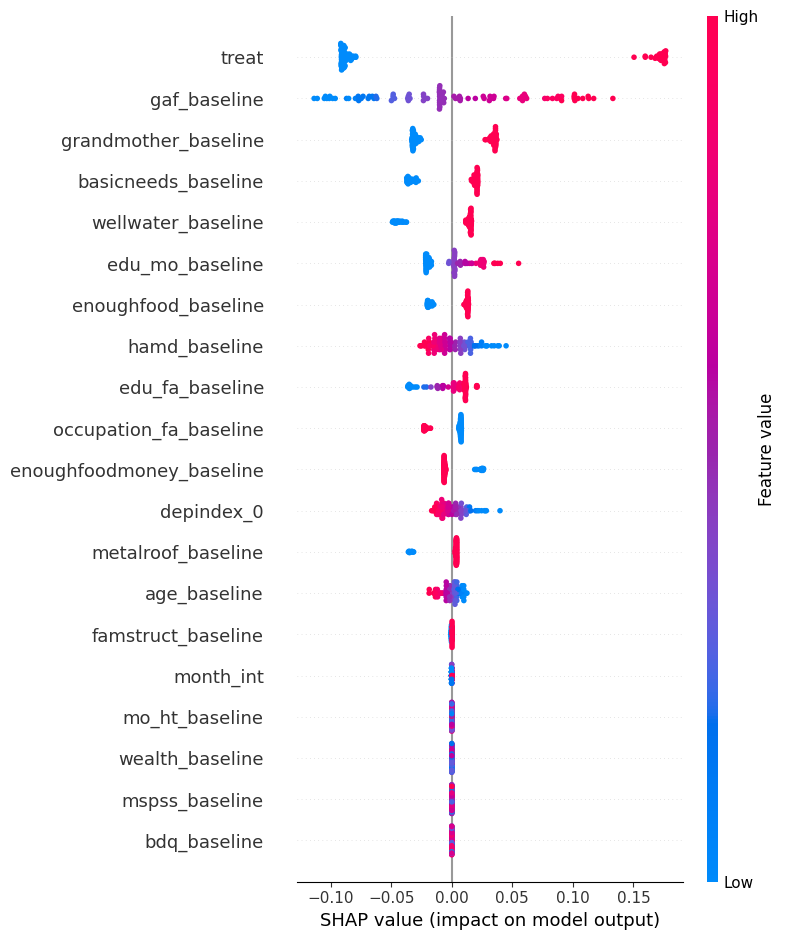

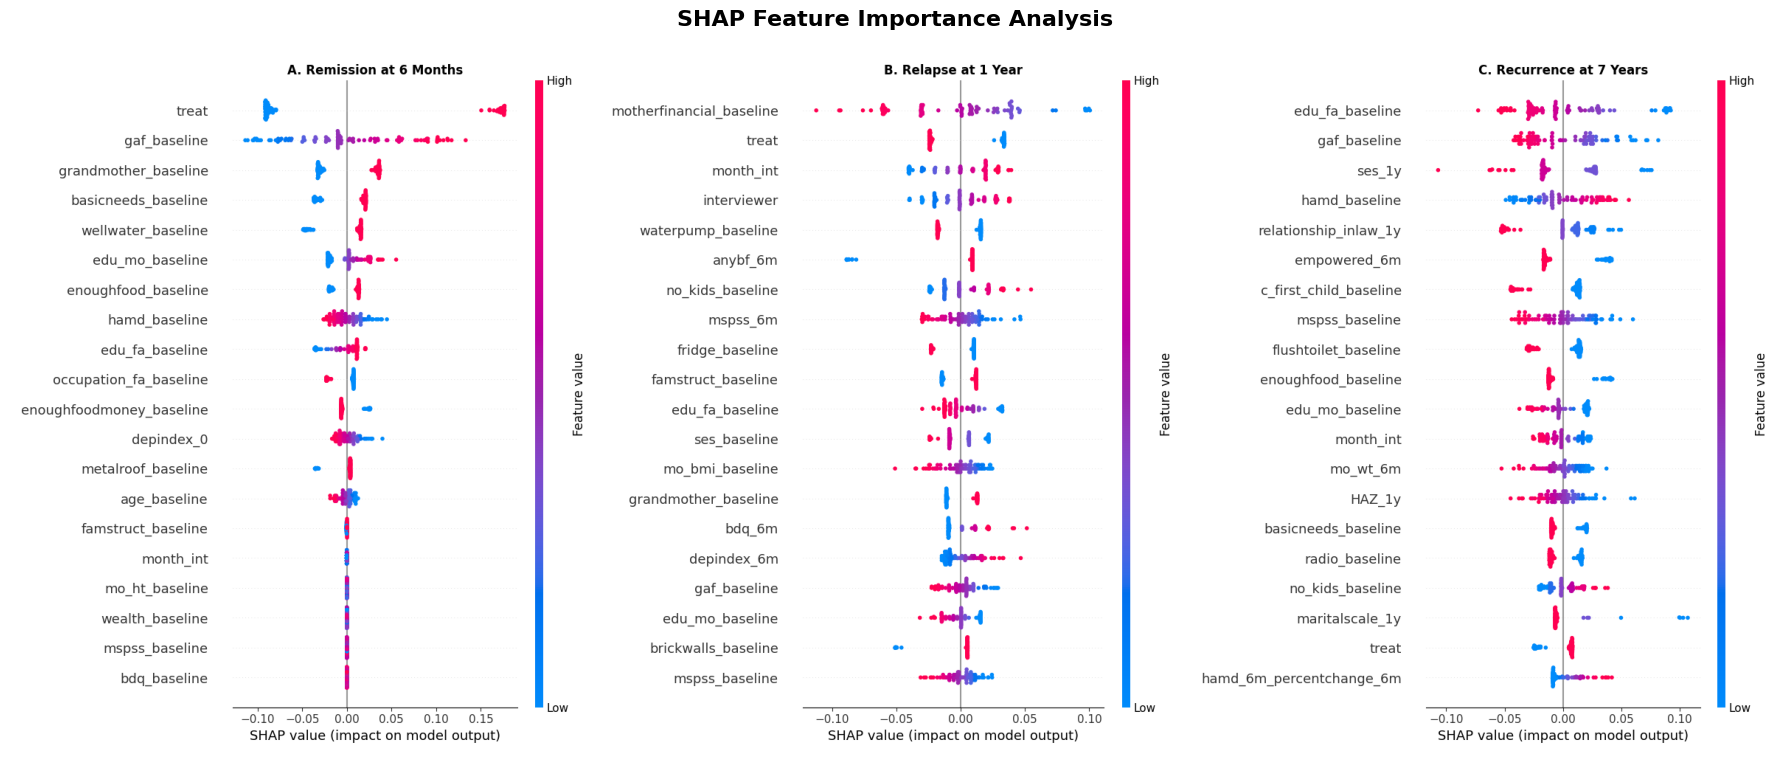

✓ Image combination approach successful!

Checking available variables:
✓ shap_values_remission is available
✓ shap_values_relapse is available
✓ shap_values_recurrence is available
✓ X_remission is available
✓ X_relapse is available
✓ X_recurrence is available
✓ feature_names_remission is available
✓ feature_names_relapse is available
✓ feature_names_recurrence is available


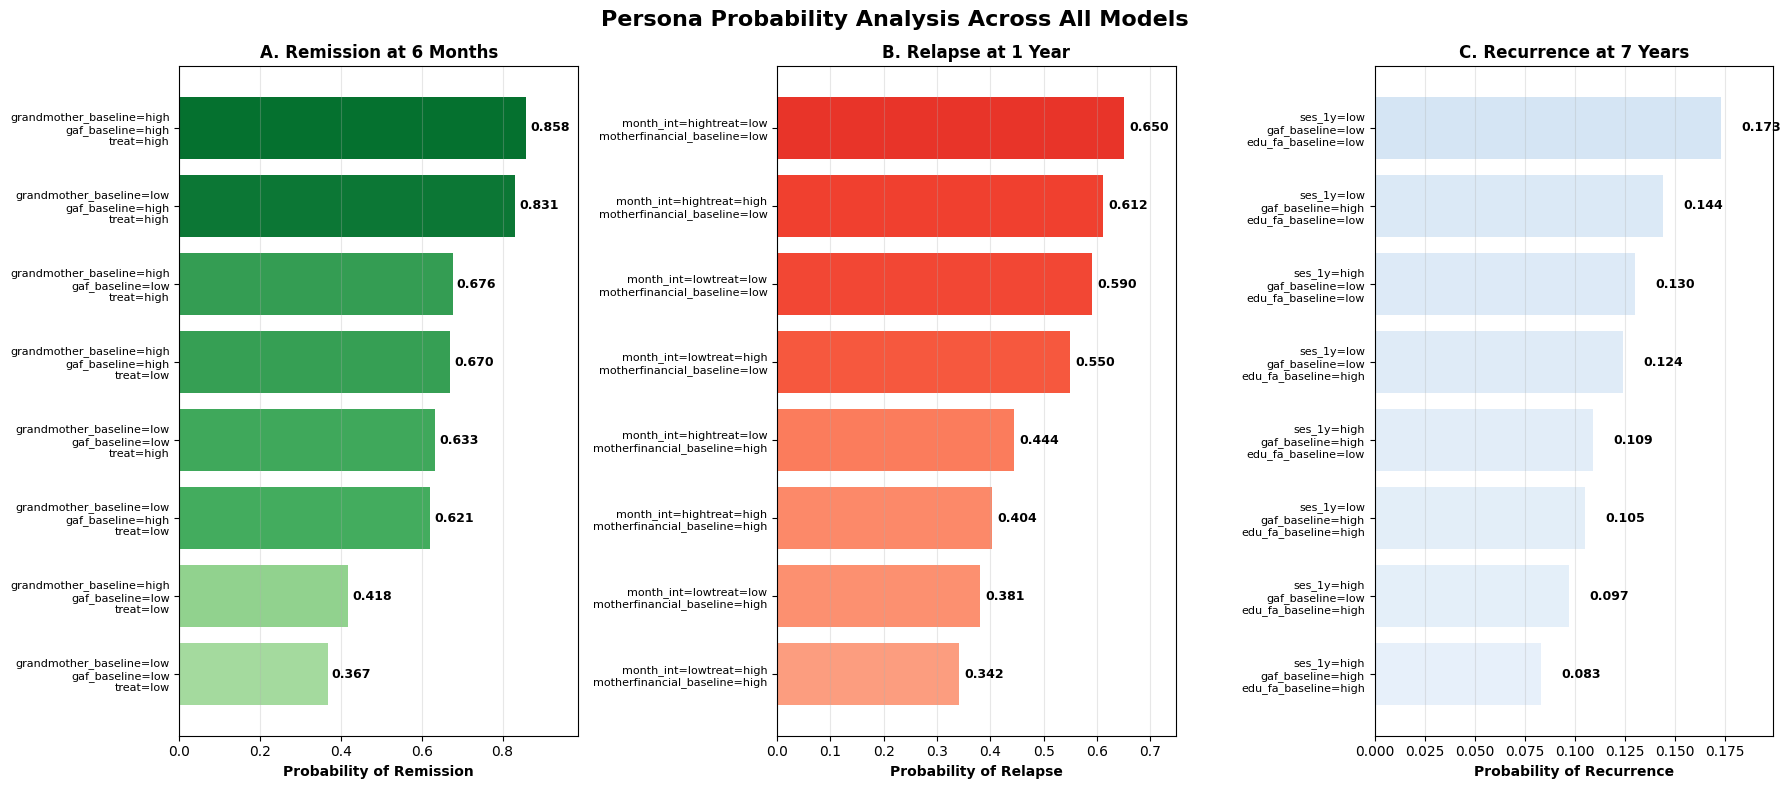

In [108]:
# Combined plots for SHAP feature importance and personas

import matplotlib.pyplot as plt
import numpy as np
import shap  # Missing import
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas

# ========= SHAP =========
def simple_combine_existing_figures():
    """
    Create individual SHAP plots and combine them using subplot positioning
    """
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Create each SHAP plot individually by setting current axes
    plt.sca(axes[0])
    shap.summary_plot(shap_values_remission, features=X_remission, 
                     feature_names=feature_names_remission, show=False)
    axes[0].set_title("A. Remission at 6 Months", fontweight='bold')
    
    plt.sca(axes[1])
    shap.summary_plot(shap_values_relapse, features=X_relapse, 
                     feature_names=feature_names_relapse, show=False)
    axes[1].set_title("B. Relapse at 1 Year", fontweight='bold')
    
    plt.sca(axes[2])
    shap.summary_plot(shap_values_recurrence, features=X_recurrence, 
                     feature_names=feature_names_recurrence, show=False)
    axes[2].set_title("C. Recurrence at 7 Years", fontweight='bold')
    
    plt.suptitle("SHAP Feature Importance Analysis", fontsize=16, fontweight='bold')
    plt.tight_layout()
    return fig

# Alternative approach using individual figures and image combination
def combine_using_figure_conversion():
    """
    Alternative: Create individual figures and combine as images
    """
    # Create individual SHAP plots
    fig1 = plt.figure(figsize=(6, 8))
    shap.summary_plot(shap_values_remission, features=X_remission, 
                     feature_names=feature_names_remission, show=False)
    plt.title("A. Remission at 6 Months", fontweight='bold')
    plt.tight_layout()
    
    fig2 = plt.figure(figsize=(6, 8))
    shap.summary_plot(shap_values_relapse, features=X_relapse, 
                     feature_names=feature_names_relapse, show=False)
    plt.title("B. Relapse at 1 Year", fontweight='bold')
    plt.tight_layout()
    
    fig3 = plt.figure(figsize=(6, 8))
    shap.summary_plot(shap_values_recurrence, features=X_recurrence, 
                     feature_names=feature_names_recurrence, show=False)
    plt.title("C. Recurrence at 7 Years", fontweight='bold')
    plt.tight_layout()
    
    # Convert to arrays and combine
    def fig_to_array(fig):
        canvas = FigureCanvas(fig)
        canvas.draw()
        return np.array(canvas.buffer_rgba())
    
    img1 = fig_to_array(fig1)
    img2 = fig_to_array(fig2)
    img3 = fig_to_array(fig3)
    
    # Close individual figures
    plt.close(fig1)
    plt.close(fig2) 
    plt.close(fig3)
    
    # Match heights
    min_height = min(img1.shape[0], img2.shape[0], img3.shape[0])
    img1 = img1[:min_height, :, :]
    img2 = img2[:min_height, :, :]
    img3 = img3[:min_height, :, :]
    
    # Combine horizontally
    combined_image = np.hstack([img1, img2, img3])
    
    # Create final figure
    fig_combined = plt.figure(figsize=(18, 8))
    plt.imshow(combined_image)
    plt.axis('off')
    plt.title("SHAP Feature Importance Analysis", fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    
    return fig_combined

# Try the first approach
try:
    print("Trying subplot approach...")
    combined_fig = simple_combine_existing_figures()
    plt.show()
    print("✓ Subplot approach successful!")
except Exception as e:
    print(f"Subplot approach failed: {e}")
    print("Trying image combination approach...")
    
    try:
        combined_fig = combine_using_figure_conversion()
        plt.show()
        print("✓ Image combination approach successful!")
    except Exception as e2:
        print(f"Image combination also failed: {e2}")
        print("Manual approach needed - create plots individually")

# Alternative: Check what variables are available
print("\nChecking available variables:")
required_vars = [
    'shap_values_remission', 'shap_values_relapse', 'shap_values_recurrence',
    'X_remission', 'X_relapse', 'X_recurrence',
    'feature_names_remission', 'feature_names_relapse', 'feature_names_recurrence'
]

for var in required_vars:
    if var in globals():
        print(f"✓ {var} is available")
    else:
        print(f"✗ {var} is missing")

# Save combined figure
# combined_fig.savefig("combined_shap_analysis.png", dpi=300, bbox_inches='tight')




# ========= PERSONAS =========

data_dict = {
    "proto_df_remission": proto_df_remission,
    "proto_df_relapse": proto_df_relapse,
    "proto_df_recurrence": proto_df_recurrence
}

for k, v in data_dict.items():
    assert v is not None and isinstance(v, pd.DataFrame), f"{k} is missing or not a DataFrame"

def combine_persona_bar_charts(data_dict):
    """
    Create combined persona bar charts for remission, relapse, and recurrence
    using explicitly passed data_dict rather than globals().
    
    Parameters:
    -----------
    data_dict : dict
        A dictionary with keys: 'proto_df_remission', 'proto_df_relapse', 'proto_df_recurrence'
        and values as corresponding DataFrames with 'Profile' and 'P(...)' columns.
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        Combined horizontal bar chart with 3 panels.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    fig, axes = plt.subplots(1, 3, figsize=(18, 8))

    variants = ["remission", "relapse", "recurrence"]
    titles = {
        "remission": "A. Remission at 6 Months",
        "relapse": "B. Relapse at 1 Year", 
        "recurrence": "C. Recurrence at 7 Years"
    }
    color_maps = {
        "remission": plt.cm.Greens,
        "relapse": plt.cm.Reds,
        "recurrence": plt.cm.Blues
    }

    def format_label(label, max_chars_per_line=25):
        parts = label.split(' & ')
        formatted_parts = []
        current_line = ""
        for part in parts:
            if len(current_line + part) <= max_chars_per_line:
                current_line += part + " & " if current_line else part
            else:
                if current_line:
                    formatted_parts.append(current_line.rstrip(" & "))
                current_line = part + " & "
        if current_line:
            formatted_parts.append(current_line.rstrip(" & "))
        return '\n'.join(formatted_parts)

    for i, variant in enumerate(variants):
        try:
            proto_df = data_dict.get(f"proto_df_{variant}")
            if proto_df is None:
                axes[i].text(0.5, 0.5, f"No data for {variant}",
                             ha='center', va='center', transform=axes[i].transAxes)
                axes[i].set_title(titles[variant], fontweight='bold')
                continue

            prob_col = [col for col in proto_df.columns if 'P(' in col]
            if not prob_col:
                axes[i].text(0.5, 0.5, f"No probability column found for {variant}",
                             ha='center', va='center', transform=axes[i].transAxes)
                axes[i].set_title(titles[variant], fontweight='bold')
                continue

            prob_col = prob_col[0]  # Get the column name like 'P(recurrence)'

            sorted_df = proto_df.sort_values(prob_col, ascending=True)
            formatted_labels = [format_label(profile) for profile in sorted_df['Profile']]
            probs = sorted_df[prob_col].values

            bars = axes[i].barh(range(len(sorted_df)), probs,
                                color=color_maps[variant](probs))

            for j, (bar, prob) in enumerate(zip(bars, probs)):
                axes[i].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                             f'{prob:.3f}', va='center', fontweight='bold', fontsize=9)

            axes[i].set_yticks(range(len(sorted_df)))
            axes[i].set_yticklabels(formatted_labels, fontsize=8)
            axes[i].set_xlabel(f'Probability of {variant.title()}', fontsize=10, fontweight='bold')
            axes[i].set_title(titles[variant], fontsize=12, fontweight='bold')
            axes[i].grid(axis='x', alpha=0.3)
            axes[i].set_xlim(0, max(probs) * 1.15)

        except Exception as e:
            print(f"Error plotting {variant}: {e}")
            axes[i].text(0.5, 0.5, f"Error: {variant}", 
                         ha='center', va='center', transform=axes[i].transAxes)
            axes[i].set_title(titles[variant], fontweight='bold')

    plt.suptitle("Persona Probability Analysis Across All Models", fontsize=16, fontweight='bold')
    plt.tight_layout()
    return fig

fig = combine_persona_bar_charts(data_dict)
plt.show()